In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import sys
import os
import glob
import pandas as pd
import astropy.units as u
from datetime import date
from random import choices, seed
from math import factorial, erf
from astroquery.simbad import Simbad
import matplotlib.gridspec as gridspec
from scipy.ndimage import gaussian_filter1d
from scipy.stats import norm, uniform, truncnorm
from scipy.special import erfinv, comb
from scipy.special import comb
import h5py
from sklearn.neighbors import KernelDensity
# from scipy.integrate import simps
from scipy import stats
from matplotlib.ticker import AutoMinorLocator
from astropy.io import ascii
from IPython.display import clear_output
import time
from scipy.signal import find_peaks


In [2]:
def make_cmap(colors, position, bit=False):
    '''
    make_cmap takes a list of tuples which contain RGB values. The RGB
    values may either be in 8-bit [0 to 255] (in which bit must be set to
    True when called) or arithmetic [0 to 1] (default). make_cmap returns
    a cmap with equally spaced colors.
    Arrange your tuples so that the first color is the lowest value for the
    colorbar and the last is the highest.
    position contains values from 0 to 1 to dictate the location of each color.
    '''
    bit_rgb = np.linspace(0,1,256)
    # if position == None:
    #     position = np.linspace(0,1,len(colors))
    # else:
    if len(position) != len(colors):
        sys.exit("position length must be the same as colors")
    elif position[0] != 0 or position[-1] != 1:
        sys.exit("position must start with 0 and end with 1")
    if bit:
        for i in range(len(colors)):
            colors[i] = (bit_rgb[colors[i][0]],
                         bit_rgb[colors[i][1]],
                         bit_rgb[colors[i][2]])
    cdict = {'red':[], 'green':[], 'blue':[]}
    for pos, color in zip(position, colors):
        cdict['red'].append((pos, color[0], color[0]))
        cdict['green'].append((pos, color[1], color[1]))
        cdict['blue'].append((pos, color[2], color[2]))

    cmap = mpl.colors.LinearSegmentedColormap('my_colormap',cdict,256)
    return cmap
def choose_cmap(custom_cmap, reverse_cmap=False):

    custom_cmaps = {'my diverging red blue': [(204/255, 230/255, 255/255),
                                              (0/255, 102/255, 204/255),
                                              (51/255, 0/255, 102/255),
                                              (255/255, 0/255, 102/255),
                                              (255/255, 230/255, 243/255)],
                    'my blue yellow red': [(0 / 255, 74 / 255, 171 / 255),
                                        (255 / 255, 209 / 255, 26 / 255),
                                        (178 / 255, 0 / 255, 3 / 255)],
                    'McLaren 2022': [(0/255, 38/255, 77/255),
                                    (211/255, 0/255, 87/255),
                                    (255/255, 153/255, 0/255),
                                    (191/255, 217/255, 217/255)],
                    'vibrant candy': [(0/255, 26/255, 77/255),
                                    (204/255, 0/255, 102/255),
                                    (255/255, 204/255, 0/255),
                                    (153/255, 255/255, 153/255)],
                    'ice queen': [(37/255, 0/255, 51/255),
                                  (0/255, 155/255, 153/255),
                                  (214/255, 255/255, 214/255)],
                    'ice queen2': [(0/255, 0/255, 0/255),
                                   (0/255, 134/255, 179/255),
                                   (255/255, 255/255, 200/255)],
                    'amazon queen': [(0/255, 0/255, 0/255),
                                     (25/255, 103/255, 103/255),
                                     (119/255, 179/255, 105/255),
                                     (255/255, 234/255, 0/255),
                                     (255/255, 255/255, 255/255)],
                    'amazon queen2': [(0/255, 34/255, 51/255),
                                      (25/255, 103/255, 103/255),
                                    #   (119/255, 179/255, 105/255),
                                    #   (63/255, 211/255, 146/255),
                                      (255/255, 234/255, 0/255)],
                    'colorado sunrise': [(0/255, 17/255, 51/255),
                                         (234/255, 74/255, 104/255),
                                         (255/255, 224/255, 102/255)],
                    'muted rbg': [(102/255, 0/255, 51/255),
                                  (0/255, 85/255, 128/255),
                                  (140/255, 153/255, 0/255)],
                    'perceptual rbg': [(102/255, 0/255, 51/255),
                                       (60/255, 40/255, 90/255),
                                       (0/255, 102/255, 153/255),
                                       (134/255, 179/255, 0/255),
                                       (255/255, 200/255, 50/255),
                                       (255/255, 255/255, 160/255)],
                    'mclaren livery': [(0/255, 119/255, 179/255),
                                       (204/255, 0/255, 102/255),
                                    #    (255/255, 128/255, 0/255),
                                       (255/255, 153/255, 0/255),
                                       (207/255, 226/255, 226/255)],
                    'volcanic sunrise': [(0/255, 51/255, 77/255),
                                  (153/255, 0/255, 77/255),
                                  (255/255, 80/255, 80/255),
                                  (255/255, 255/255, 153/255)],
                    'cyber grape': [(51/255, 0/255, 51/255),
                                    (128/255, 0/255, 128/255),
                                    (153/255, 102/255, 255/255),
                                    (204/255, 255/255, 255/255)],
                    'cyber grape2': [(51/255, 0/255, 51/255),
                                     (128/255, 0/255, 128/255),
                                     (255/255, 153/255, 204/255),
                                     (204/255, 255/255, 255/255)],
                    'black limeaid': [(0/255, 0/255, 77/255),
                                      (102/255, 153/255, 153/255),
                                      (204/255, 255/255, 51/255)],
                    'raspberry punch1': [(51/255, 0/255, 102/255),
                                        (51/255, 204/255, 224/255),
                                        (248/255, 255/255, 230/255)],
                    'raspberry punch2': [(70/255, 0/255, 0/255),
                                        (89/255, 0/255, 179/255),
                                        (51/255, 204/255, 224/255),
                                        (255/255, 255/255, 200/255)],
                    'raspberry punch': [(51/255, 0/255, 102/255),
                                        # (89/255, 0/255, 179/255),
                                        (51/255, 204/255, 224/255),
                                        (255/255, 255/255, 200/255)],
                    }

    chosen_cmap = custom_cmaps[custom_cmap]
    pos_diff = 1./(len(chosen_cmap)-1)
    positions = np.arange(0, 1+pos_diff, pos_diff)
    if reverse_cmap == True:
        chosen_cmap = chosen_cmap[::-1]
    mycolormap = make_cmap(chosen_cmap, position=positions)

    return mycolormap

plt.style.use('/Users/lb8137/Projects/mpl_stylefiles/mystyle.mplstyle')
# plt.rcParams.keys()

Duplicate key in file '/Users/lb8137/Projects/mpl_stylefiles/mystyle.mplstyle', line 40 ('figure.dpi: 150')
Bad value in file '/Users/lb8137/Projects/mpl_stylefiles/mystyle.mplstyle', line 19 ('mathtext.fallback: dejavusans'): Key mathtext.fallback: dejavusans is not a valid fallback font name. Valid fallback font names are cm,stix,stixsans. Passing 'None' will turn fallback off.


In [3]:
def unique(list_of_values):
    unique_values = []
    for _, value in enumerate(list_of_values):
        if value in unique_values:
            pass
        else:
            unique_values.append(value)
    return unique_values

def savitzky_golay(y, window_size, order, deriv=0, rate=1):
    r"""Smooth (and optionally differentiate) data with a Savitzky-Golay filter.
    The Savitzky-Golay filter removes high frequency noise from data.
    It has the advantage of preserving the original shape and
    features of the signal better than other types of filtering
    approaches, such as moving averages techniques.
    Parameters
    ----------
    y : array_like, shape (N,)
        the values of the time history of the signal.
    window_size : int
        the length of the window. Must be an odd integer number.
    order : int
        the order of the polynomial used in the filtering.
        Must be less then `window_size` - 1.
    deriv: int
        the order of the derivative to compute (default = 0 means only smoothing)
    Returns
    -------
    ys : ndarray, shape (N)
        the smoothed signal (or it's n-th derivative).
    Notes
    -----
    The Savitzky-Golay is a type of low-pass filter, particularly
    suited for smoothing noisy data. The main idea behind this
    approach is to make for each point a least-square fit with a
    polynomial of high order over a odd-sized window centered at
    the point.
    Examples
    --------
    t = np.linspace(-4, 4, 500)
    y = np.exp( -t**2 ) + np.random.normal(0, 0.05, t.shape)
    ysg = savitzky_golay(y, window_size=31, order=4)
    import matplotlib.pyplot as plt
    plt.plot(t, y, label='Noisy signal')
    plt.plot(t, np.exp(-t**2), 'k', lw=1.5, label='Original signal')
    plt.plot(t, ysg, 'r', label='Filtered signal')
    plt.legend()
    plt.show()
    References
    ----------
    .. [1] A. Savitzky, M. J. E. Golay, Smoothing and Differentiation of
       Data by Simplified Least Squares Procedures. Analytical
       Chemistry, 1964, 36 (8), pp 1627-1639.
    .. [2] Numerical Recipes 3rd Edition: The Art of Scientific Computing
       W.H. Press, S.A. Teukolsky, W.T. Vetterling, B.P. Flannery
       Cambridge University Press ISBN-13: 9780521880688
    """
    
    try:
        window_size = np.abs(int(window_size))
        order = np.abs(int(order))
    except:
        raise ValueError("window_size and order have to be of type int")
    if window_size % 2 != 1 or window_size < 1:
        raise TypeError("window_size size must be a positive odd number")
    if window_size < order + 2:
        raise TypeError("window_size is too small for the polynomials order")
    order_range = range(order+1)
    half_window = (window_size -1) // 2
    # precompute coefficients
    b = np.mat([[k**i for i in order_range] for k in range(-half_window, half_window+1)])
    m = np.linalg.pinv(b).A[deriv] * rate**deriv * factorial(deriv)
    # pad the signal at the extremes with
    # values taken from the signal itself
    firstvals = y[0] - np.abs( y[1:half_window+1][::-1] - y[0] )
    lastvals = y[-1] + np.abs(y[-half_window-1:-1][::-1] - y[-1])
    y = np.concatenate((firstvals, y, lastvals))
    return np.convolve( m[::-1], y, mode='valid')

def factorial(number):
    fact = 1
    for i in range(1, number+1):
        fact = fact * i
    return fact

def weighted_mean(meas, meas_err):
    try:
        weight = 1./(np.array(meas_err)**2)
    except:
        print('Error calculating weighted mean!')
        print(meas, ',', meas_err)
    else:
        w_mean = sum(weight * np.array(meas)) / sum(weight)
        w_mean_err = 1./np.sqrt(sum(weight))

    return w_mean, w_mean_err

def i_unc(x, PDF):
    CDF = []
    for x_i in range(len(x)):
        CDF.append(np.trapz(PDF[0:x_i], x[0:x_i]))

    # plt.plot(x, CDF)

    where_peak = np.where(PDF == max(PDF))[0][0]
    sig1_perc = 1 - 0.6826
    sig2_perc = 1 - 0.9544
    sig1_sub = abs(np.array(CDF) - sig1_perc)
    sig2_sub = abs(np.array(CDF) - sig2_perc)

    where_sig1 = np.where(sig1_sub == min(sig1_sub))[0]
    where_sig2 = np.where(sig2_sub == min(sig2_sub))[0]
    sig1 = x[where_peak] - x[where_sig1]
    sig2 = x[where_peak] - x[where_sig2]

    if len(sig1) > 1:
        sig1 = float('nan')
        sig2 = float('nan')
    else:
        sig1 = sig1[0]
        sig2 = sig2[0]

    return sig1, sig2

def sigfig(value, uncertainty, return_uncertainty=True, cutoff=35):
    exp = np.floor(np.log10(uncertainty))
    if uncertainty / 10**(exp - 1) < cutoff:
        exp -= 1
    
    exp *= -1
    exp = int(exp)

    value_rounded = round(value, exp)

    # needed to avoid -0.0 being printed in table
    value_rounded_str = str(value_rounded)
    value_rounded_str_only_digits = value_rounded_str.replace('.', '').replace('-', '')
    if value_rounded_str.find('-') != -1 and value_rounded_str_only_digits == len(value_rounded_str_only_digits) * '0':
        value_rounded *= -1

    uncertainty_rounded = round(uncertainty, exp)
    
    if uncertainty_rounded < cutoff / 10:
        # in this case, exp represents number of decimal places to include
        output_tuple = f"{value_rounded:.{exp}f}", f"{uncertainty_rounded:.{exp}f}"
        return output_tuple if return_uncertainty else output_tuple[0]
    else:
        output_tuple = f"{int(value_rounded)}", f"{int(uncertainty_rounded)}"
        return output_tuple if return_uncertainty else output_tuple[0]

def quantile(x, q, weights=None):
    """
    Compute sample quantiles with support for weighted samples.
    Note
    ----
    When ``weights`` is ``None``, this method simply calls numpy's percentile
    function with the values of ``q`` multiplied by 100.
    Parameters
    ----------
    x : array_like[nsamples,]
       The samples.
    q : array_like[nquantiles,]
       The list of quantiles to compute. These should all be in the range
       ``[0, 1]``.
    weights : Optional[array_like[nsamples,]]
        An optional weight corresponding to each sample. These
    Returns
    -------
    quantiles : array_like[nquantiles,]
        The sample quantiles computed at ``q``.
    Raises
    ------
    ValueError
        For invalid quantiles; ``q`` not in ``[0, 1]`` or dimension mismatch
        between ``x`` and ``weights``.
    """
    x = np.atleast_1d(x)
    q = np.atleast_1d(q)

    if np.any(q < 0.0) or np.any(q > 1.0):
        raise ValueError("Quantiles must be between 0 and 1")
    
    if weights is None:
        return np.percentile(x, list(100.0 * q))
    else:
        weights = np.atleast_1d(weights)
        if len(x) != len(weights):
            raise ValueError("Dimension mismatch: len(weights) != len(x)")
        idx = np.argsort(x)
        sw = weights[idx]
        cdf = np.cumsum(sw)[:-1]
        cdf /= cdf[-1]
        cdf = np.append(0, cdf)
        return np.interp(q, cdf, x[idx]).tolist()

def median_pm_confidence_interval(x, pdf_y, sigma=0.6826):
    """
    Calculates output for median +- 1 sigma column.
    Parameters
    ----------
    par_chain : array_like
        Array of parameter
    sigma_per : float, optional
        Area under +- 1 sigma
    
    Returns
    -------
    str : Latex expression to go in final table
    """
    lower_bound, median, upper_bound = quantile(x, [0.5 - sigma / 2, 0.5, 0.5 + sigma / 2], pdf_y)

    if np.isnan(median) == False:
        lower_sig = abs(median - lower_bound)
        upper_sig = abs(upper_bound - median)
    else:
        median = float('nan')
        lower_sig = float('nan')
        upper_sig = float('nan')

    # if median == 0.:
    #     lower_sig = 0
    # elif lower_sig > mode:
    #     lower_sig = mode
    # if median == 90:
    #     upper_sig = 0
    # elif upper_sig > 90 - mode:
    #     upper_sig = 90 - mode

    return median, lower_sig, upper_sig

def highest_density_interval(x, pdf_y, sigma, type='mode', return_pdf=False):
    # 1sigma makes sigma = 0.6826

    x_interp = np.arange(0, 90+0.01, 0.001)
    pdf_y = np.interp(x=x_interp, xp=x, fp=pdf_y)
    x = x_interp

    cdf_y = np.cumsum(pdf_y)
    cdf_y = cdf_y / cdf_y[-1]  # Normalize the cdf so that it sums to 1.

    sub_cdf = abs(cdf_y - 0.5)
    where_med = np.where(sub_cdf == min(sub_cdf))[0]
    median = np.mean(x[where_med])

    delta_xlist = []
    xlower = []
    xupper = []

    sigma_lower = 0
    delta = 1e-6

    for _ in range(0,round((1 - sigma)/delta)):
        x1 = np.interp(sigma_lower,cdf_y,x)
        xu = np.interp(sigma,cdf_y,x)
        delta_xlist.append(xu-x1)
        xlower.append(x1)
        xupper.append(xu)
        sigma += delta
        sigma_lower += delta

    index = delta_xlist.index(min(delta_xlist))
    mode = np.mean(x[pdf_y == max(pdf_y)]).round(1)
    mode = x[pdf_y == max(pdf_y)]
    if len(mode) > 1:
        mode = np.mean(mode)
    else:
        mode = mode[0]
    # print('The lower x value (for minimum credible interval) is ', xlower[index])
    # print('The upper x value (for minimum credible interval) is ', xupper[index])

    lower = mode - xlower[index]
    upper = xupper[index] - mode

    if type == 'mode':
        report_val = mode
    if type == 'median':
        report_val = median

    if return_pdf == True:
        return report_val, lower, upper, x, pdf_y
    if return_pdf == False:
        return report_val, lower, upper

def SpType_num_to_str(sptype_num, sptype_num_err):

    sptype_base_num = int(np.floor(sptype_num))

    if sptype_base_num == 3:
        sptype_str_letter = 'G'
    if sptype_base_num == 4:
        sptype_str_letter = 'K'
    if sptype_base_num == 5:
        sptype_str_letter = 'M'

    sptype_cat_num = np.round((sptype_num - sptype_base_num) * 10, 1)
    sptype_cat_str = str(sptype_cat_num)

    sptype_str = sptype_str_letter + sptype_cat_str

    sptype_num_err = np.round(sptype_num_err * 10, 1)
    if sptype_num_err == 0.0:
        sptype_num_err = 0.01
    sptype_str_err = str(sptype_num_err)

    return sptype_str, sptype_str_err

def determine_sptype(let_val, num_val):

    possible_letters = {'B': 0,
                        'A': 1,
                        'F': 2,
                        'G': 3,
                        'K': 4,
                        'M':5,
                        }

    temp_val = []
    if '-' in let_val:
        let_val_split = str(let_val).replace(' ', '').split('-')
        num_val_split = str(num_val).replace(' ', '').split('-')
        val1 = possible_letters[let_val_split[0]] + 0.1*float(num_val_split[0])
        val2 = possible_letters[let_val_split[1]] + 0.1*float(num_val_split[1])
        temp_val = [val1, val2]
    else:
        temp_val.append(possible_letters[let_val] + 0.1*float(num_val))
    
    if len(temp_val) > 1:
        adopted_val = np.mean(temp_val)
        adopted_val_err = np.std(temp_val, ddof=1)
    if len(temp_val) == 1:
        adopted_val = temp_val[0]
        adopted_val_err = 0.1

    
    return adopted_val, adopted_val_err

def clean_dataframe(df, dataset):
    keep_columns = ['Target', 'RA', 'DEC',
                    'SpType', 'SpType Letter', 'SpType Number', 'SpType Decimal', 'SpType Decimal Unc',
                    'Teff (K)', 'Teff Unc',
                    'Mstar (Msun)', 'Mstar Unc',
                    'Rstar (Rsun)', 'Rstar Unc',
                    'Prot (d)', 'Prot Unc',
                    'vsini (km/s)', 'vsini Unc',
                    'i disk (deg)', 'i disk Unc',
                    ]
    dict_clean = {}
    for _, key in enumerate(keep_columns):
        dict_clean[key] = []
    for _, col in enumerate(df.columns):
        if col == 'Target':
            targets = df['Target'].values
            for _, targ in enumerate(targets):
                dict_clean['Target'].append(targ)
        elif col == 'RA':
            RAs = df['RA'].values
            for _, RA in enumerate(RAs):
                dict_clean['RA'].append(RA)
        elif col == 'DEC':
            Decs = df['DEC'].values
            for _, Dec in enumerate(Decs):
                if Dec[0] == '-':
                    Dec = Dec.replace('-', '$-$')
                elif Dec[0] != '-':
                    Dec = '+' + Dec
                dict_clean['DEC'].append(Dec)
        elif col in ['i disk Unc', 'SpType Letter', 'SpType Number', 'SpType Decimal', 'SpType Decimal Unc', 'vsini Unc']:
            if dataset != 'PD':
                continue
            else:
                if col == 'i disk Unc' or col == 'vsini Unc':
                    continue
        elif col == 'SpType':
            dict_clean['SpType'] = df['SpType'].values
            dict_clean['SpType Letter'] = df['SpType Letter'].values
            for indx in range(len(df['SpType Letter'].values)):
                dict_clean['SpType Number'].append(df['SpType Number'].values[indx])
                updated_val, _ = determine_sptype(df['SpType Letter'].values[indx], df['SpType Number'].values[indx])
                dict_clean['SpType Decimal'].append(updated_val)
                dict_clean['SpType Decimal Unc'].append(0.001)
        elif col == 'i disk (deg)':
            idisk_strings = df['i disk (deg)'].values
            idisk_err_strings = df['i disk Unc'].values
            for indx2 in range(len(idisk_strings)):
                idisk_str = idisk_strings[indx2]
                idisk_err_str = idisk_err_strings[indx2]
                if type(idisk_str) == str:
                    if '[' in idisk_str:
                        val1 = float(idisk_str.replace('[', '').replace(']', '').split(',')[0])
                        val2 = float(idisk_str.replace('[', '').replace(']', '').split(',')[1])
                        val = np.mean([val1, val2])
                        val_err = abs(val - val1)
                        val = idisk_str
                        val_err = 0
                    else:
                        val = float(idisk_str)
                        val_err = float(idisk_err_str)
                else:
                    val = idisk_str
                    val_err = idisk_err_str
                dict_clean['i disk (deg)'].append(val)
                dict_clean['i disk Unc'].append(val_err)
        elif col == 'vsini (km/s)':
            vsini_strings = df['vsini (km/s)'].values
            vsini_err_strings = df['vsini Unc'].values
            for indx3 in range(len(vsini_strings)):
                vsini_str = vsini_strings[indx3]
                vsini_err_str = vsini_err_strings[indx3]
                if type(vsini_str) == str:
                    if '<' in vsini_str:
                        val = float(vsini_str.replace('<', ''))
                        val_err = 'ulimit'
                    else:
                        val = float(vsini_str)
                        val_err = float(vsini_err_str)
                else:
                    val = float(vsini_str)
                    val_err = float(vsini_err_str)
                dict_clean['vsini (km/s)'].append(val)
                dict_clean['vsini Unc'].append(val_err)
        elif col == 'Prot Unc':
            absolute_shear = 0.07  # rad / day
            err_tracker = []
            for indx in range(len(df['Prot Unc'].values)):
                err_val = df['Prot Unc'].values[indx]
                if dataset == 'DD':
                    mean_val = df['Prot (d)'].values[indx]
                    err_shear = 0.5*(mean_val - ((absolute_shear/(2*np.pi)) + (1./mean_val))**-1)
                    Prot_err = np.sqrt(err_val**2 + err_shear**2)
                    dict_clean['Prot Unc'].append(Prot_err)
                    # print(err_val, Prot_err)
                    err_tracker.append(Prot_err/err_val)
                    if indx == len(df['Prot Unc'].values)-1:
                        print(err_tracker)
                        print(np.mean(err_tracker))
                else:
                    dict_clean['Prot Unc'].append(err_val)
        elif col in keep_columns:
            vals = df[col].values
            for _, val_str in enumerate(vals):
                val = float(val_str)
                dict_clean[col].append(val)
        else:
            continue

    # if dataset == 'DD':
    #     for _, key in enumerate(dict_clean.keys()):
    #         print(key, len(dict_clean[key]))
    
    df_clean = pd.DataFrame(dict_clean)
    
    return df_clean

def bb_binomial_ppd(x, k, n, normapprox=False):
    # Convert inputs to float for consistency
    n = float(n)
    k = float(k)
    
    if not normapprox:
        # Exact binomial computation using comb from scipy.special
        nchoosek = comb(int(n), int(k), exact=True)
        ppd = nchoosek * (x**k) * ((1.0 - x)**(n - k)) * (n + 1.0)
    else:
        # Normal approximation
        # mean = n*x, variance = n*x*(1-x), std = sqrt(variance)
        mean = n * x
        var = n * x * (1.0 - x)
        sd = np.sqrt(var)
        
        # Normal PDF at k with mean and std
        ppd = (1.0 / (sd * np.sqrt(2.0 * np.pi))) * np.exp(-0.5 * ((k - mean)**2 / var))
    
    return ppd

def mode_pm_highest_density_interval(x, pdf_y, sigma, return_pdf=False):
    # 1sigma makes sigma = 0.6826

    x_interp = np.arange(np.nanmin(x), np.nanmax(x)+0.001, 0.001)
    pdf_y = np.interp(x=x_interp, xp=x, fp=pdf_y)
    x = x_interp

    cdf_y = np.cumsum(pdf_y)
    cdf_y = cdf_y / cdf_y[-1]  # Normalize the cdf so that it sums to 1.

    delta_xlist = []
    xlower = []
    xupper = []

    sigma_lower = 0
    delta = 1e-6

    for _ in range(0,round((1 - sigma)/delta)):
        x1 = np.interp(sigma_lower,cdf_y,x)
        xu = np.interp(sigma,cdf_y,x)
        delta_xlist.append(xu-x1)
        xlower.append(x1)
        xupper.append(xu)
        sigma += delta
        sigma_lower += delta

    index = delta_xlist.index(min(delta_xlist))
    mode = np.mean(x[pdf_y == max(pdf_y)]).round(1)
    mode = x[pdf_y == max(pdf_y)]
    if len(mode) > 1:
        print('BAP', min(mode), max(mode), np.mean(mode))
        mode = np.mean(mode)
    else:
        mode = mode[0]
    # print('The lower x value (for minimum credible interval) is ', xlower[index])
    # print('The upper x value (for minimum credible interval) is ', xupper[index])

    lower = mode - xlower[index]
    upper = xupper[index] - mode

    if return_pdf == True:
        return mode, lower, upper, x, pdf_y
    if return_pdf == False:
        return mode, lower, upper





In [4]:
# customSimbad = Simbad()
# customSimbad.add_votable_fields('ra(2;A;ICRS;J2017.5;2000)', 'dec(2;D;ICRS;J2017.5;2000)',
#                                 'sp', 'sp_nature', 'sp_bibcode',
#                                 'flux(R)', 'flux(I)', 'flux(V)', 'flux(K)')
# customSimbad.remove_votable_fields('coordinates')
# customSimbad.TIMEOUT = 4 * 60 # sets the timeout to 4 min
# customSimbad.ROW_LIMIT = -1

In [5]:
main_directory = '/Users/lb8137/Projects/OBLIQUITY_SYNTHESIS/'
data_directory = main_directory+'Tables/Sample_Weighted_Mean/'
tables_directory = main_directory+'Tables/'
test_figures_directory = main_directory + 'Test_Figures/'
probability_distributions_dir = main_directory + 'Tables/Probability_Distributions/'





In [6]:
read_local = False

if read_local != True:
    today = date.today()
    date_str = today.strftime("%Y-%b-%d")

    PD_properties_sheet_url = "https://docs.google.com/spreadsheets/d/1Xjpm2m3hxQACorlvKcwqjBnBKssgK8MCFyijPfVseFg/edit#gid=0"
    DD_properties_sheet_url = "https://docs.google.com/spreadsheets/d/1Lz2p6EdhytAR2_HvcPY543MrRbRoB7d7Hj5yp1E8XsM/edit#gid=0"
    WJ_properties_sheet_url = "https://docs.google.com/spreadsheets/d/1B8ep95z7EaXZ6x-fRjntDTN3i8LQUmNRGMBrc5G6bV4/edit#gid=0"
    HJ_properties_sheet_url = "https://docs.google.com/spreadsheets/d/1k5oKAUum9d-s5JaD3HDRDlMZqn_pPGvRyFvB4kw8WE0/edit#gid=0"

    DD_NEA_sheet_url = "https://docs.google.com/spreadsheets/d/1udcwcYq_V1K8klSsJhh5LU7DcI-HKDcx1XvD9GM1sCQ/edit#gid=1605229114&fvid=90870798"
    WJ_NEA_sheet_url = "https://docs.google.com/spreadsheets/d/1udcwcYq_V1K8klSsJhh5LU7DcI-HKDcx1XvD9GM1sCQ/edit#gid=208039490&fvid=453681374"
    HJ_NEA_sheet_url = "https://docs.google.com/spreadsheets/d/1udcwcYq_V1K8klSsJhh5LU7DcI-HKDcx1XvD9GM1sCQ/edit#gid=169409426"


    url_PD_properties = PD_properties_sheet_url.replace('/edit#gid=', '/export?format=csv&gid=')
    url_DD_properties = DD_properties_sheet_url.replace('/edit#gid=', '/export?format=csv&gid=')
    url_WJ_properties = WJ_properties_sheet_url.replace('/edit#gid=', '/export?format=csv&gid=')
    url_HJ_properties = HJ_properties_sheet_url.replace('/edit#gid=', '/export?format=csv&gid=')

    url_DD_NEA = DD_NEA_sheet_url.replace('/edit#gid=', '/export?format=csv&gid=')
    url_WJ_NEA = WJ_NEA_sheet_url.replace('/edit#gid=', '/export?format=csv&gid=')
    url_HJ_NEA = HJ_NEA_sheet_url.replace('/edit#gid=', '/export?format=csv&gid=')

    df_PD_goog = pd.read_csv(url_PD_properties)
    df_DD_goog = pd.read_csv(url_DD_properties)
    df_HJ_goog = pd.read_csv(url_HJ_properties)
    df_WJ_goog = pd.read_csv(url_WJ_properties)

    df_DD_NEA = pd.read_csv(url_DD_NEA)
    df_HJ_NEA = pd.read_csv(url_HJ_NEA)
    df_WJ_NEA = pd.read_csv(url_WJ_NEA)

    


else:
    date_str = '2023-Dec-9'
    raw_df = pd.read_excel(main_directory + 'Primordial_Disks_9-Dec-2023.xlsx')

In [7]:
compute_new_posteriors = False



if compute_new_posteriors == False:
    # date_str = '2024-Dec-04'
    date_str = '2025-Oct-24'


skip_PD = False
skip_DD = False
skip_WJ = False
skip_HJ = False

sampling_resolution = 'high'
resolution_text = sampling_resolution + 'Res'



do_save_probability_distributions = True
do_save_plots = True

plot_lightfigure = False
plot_transparent = False


hist_linecolor = '#2f0431'  # Histogram
zeroline_color = '#404040'  # veq - vsini
point_color = '#003366'   # veq - vsini
edge_color = '#005580'  # par vs. Delta i 
point_color_no_z = '#0086b3'  # par vs. Delta i 
kde_color = '#6fdcdc'

pd_color = '#00cccc'  
pd_linecolor = pd_color  
dd_color = '#336b4f'  # '#859d00'  
dd_linecolor = dd_color  
WJ_color = '#ffb800'  
WJ_linecolor = WJ_color  
HJ_color = '#9000a3'  
HJ_linecolor = HJ_color  

plt.style.use('/Users/lb8137/Projects/mpl_stylefiles/mystyle.mplstyle')

if plot_transparent == True:
    transparent_text = 'transparent'
else:
    transparent_text = 'opaque'

if plot_lightfigure == True:
    light_or_dark_dext = 'light'
else:
    light_or_dark_dext = 'dark'

print('\nUsing date_str = ' + date_str + '\n')

do_modified = False
# selection_function = 'Nominal'  # 'Nominal'  # 'Modified3'
# date_str_modified = '2025-Mar-29'

save_csv_filepath_PD = data_directory + 'adopted_' + resolution_text + '_PD_' + date_str + '.csv'
save_csv_filepath_DD = data_directory + 'adopted_' + resolution_text + '_DD_' + date_str + '.csv'
save_csv_filepath_WJ = data_directory + 'adopted_' + resolution_text + '_WJ_' + date_str + '.csv'
save_csv_filepath_HJ = data_directory + 'adopted_' + resolution_text + '_HJ_' + date_str + '.csv'


Duplicate key in file '/Users/lb8137/Projects/mpl_stylefiles/mystyle.mplstyle', line 40 ('figure.dpi: 150')
Bad value in file '/Users/lb8137/Projects/mpl_stylefiles/mystyle.mplstyle', line 19 ('mathtext.fallback: dejavusans'): Key mathtext.fallback: dejavusans is not a valid fallback font name. Valid fallback font names are cm,stix,stixsans. Passing 'None' will turn fallback off.



Using date_str = 2025-Oct-24



### Compute or Read In Obliquities

In [8]:
def read_datafiles(PD_path=save_csv_filepath_PD, DD_path=save_csv_filepath_DD, WJ_path=save_csv_filepath_WJ, HJ_path=save_csv_filepath_HJ,
                   skip_PD=False, skip_DD=False, skip_WJ=False, skip_HJ=False):
    
    print('OPENING FILES...')

    if skip_PD!= True:
        print(PD_path)
        df_PD = pd.read_csv(PD_path)
        # df_PD['vsini Unc'].replace('ulimit', 0.0000, inplace=True)
        df_PD['vsini Unc'] = df_PD['vsini Unc'].replace('ulimit', 0.0000)
        df_PD['vsini Unc'] = df_PD['vsini Unc'].astype(float)
        df_PD = df_PD.sort_values('Target')
        df_PD.loc[df_PD['i star (deg)'] > 90., 'i star (deg)'] = 90.
        df_PD.loc[df_PD['i star +Unc'] < 0, 'i star +Unc'] = 0

    # DD PROPERTIES 
    if skip_DD != True:
        print(DD_path)
        df_DD = pd.read_csv(DD_path)
        # df_DD['vsini Unc'].replace('ulimit', 0.0000, inplace=True)
        df_DD['vsini Unc'] = df_DD['vsini Unc'].replace('ulimit', 0.0000)
        df_DD['vsini Unc'] = df_DD['vsini Unc'].astype(float)
        df_DD = df_DD.sort_values('Target')
        df_DD.loc[df_DD['i star (deg)'] > 90., 'i star (deg)'] = 90.
        df_DD.loc[df_DD['i star +Unc'] < 0, 'i star +Unc'] = 0
        
    # WJ PROPERTIES 
    if skip_WJ != True:
        print(WJ_path)
        df_WJ = pd.read_csv(WJ_path)
        # df_WJ['vsini Unc'].replace('ulimit', 0.0000, inplace=True)
        df_WJ['vsini Unc'] = df_WJ['vsini Unc'].replace('ulimit', 0.0000)
        df_WJ['vsini Unc'] = df_WJ['vsini Unc'].astype(float)
        df_WJ = df_WJ.sort_values('Target')
        df_WJ.loc[df_WJ['i star (deg)'] > 90., 'i star (deg)'] = 90.
        df_WJ.loc[df_WJ['i star +Unc'] < 0, 'i star +Unc'] = 0

    # HJ PROPERTIES
    if skip_HJ != True:
        print(HJ_path)
        df_HJ = pd.read_csv(HJ_path)
        # df_HJ['vsini Unc'].replace('ulimit', 0.0000, inplace=True)
        df_HJ['vsini Unc'] = df_HJ['vsini Unc'].replace('ulimit', 0.0000)
        df_HJ['vsini Unc'] = df_HJ['vsini Unc'].astype(float)
        df_HJ = df_HJ.sort_values('Target')
        df_HJ.loc[df_HJ['i star (deg)'] > 90., 'i star (deg)'] = 90.
        df_HJ.loc[df_HJ['i star +Unc'] < 0, 'i star +Unc'] = 0

    exclude_PD = []  # ['DE Tau']
    exclude_DD = ['HD 129590', 'CP-72 2713', 'GJ 581', 'HD 166', 'tau Ceti', 'HD 38529', 'GSC 07396-00759', 'HD 377']
    exclude_WJ = ['Kepler-486'] # , 'Kepler-28', 'K2-77'] # 'Neither Kepler-28 b nor c is a warm Jupiter. Same with K2-77.
    exclude_HJ = ['TOI-4201', 'HD 118203', 'WASP-106', 'WASP-85A']

    offline = False

    if len(exclude_PD) > 0:
        for object_i in exclude_PD:
            df_PD = df_PD[df_PD['Target'] != object_i]
    if len(exclude_DD) > 0:
        for object_i in exclude_DD:
            df_DD = df_DD[df_DD['Target'] != object_i]
    if len(exclude_WJ) > 0:
        for object_i in exclude_WJ:
            df_WJ = df_WJ[df_WJ['Target'] != object_i]
    if len(exclude_HJ) > 0:
        for object_i in exclude_HJ:
            df_HJ = df_HJ[df_HJ['Target'] != object_i]

    return df_PD, df_DD, df_WJ, df_HJ 



In [9]:

df_PD, df_DD, df_WJ, df_HJ = read_datafiles()


OPENING FILES...
/Users/lb8137/Projects/OBLIQUITY_SYNTHESIS/Tables/Sample_Weighted_Mean/adopted_highRes_PD_2025-Oct-24.csv
/Users/lb8137/Projects/OBLIQUITY_SYNTHESIS/Tables/Sample_Weighted_Mean/adopted_highRes_DD_2025-Oct-24.csv
/Users/lb8137/Projects/OBLIQUITY_SYNTHESIS/Tables/Sample_Weighted_Mean/adopted_highRes_WJ_2025-Oct-24.csv
/Users/lb8137/Projects/OBLIQUITY_SYNTHESIS/Tables/Sample_Weighted_Mean/adopted_highRes_HJ_2025-Oct-24.csv


In [10]:
only_multis_PD = False
only_nonmultis_PD = False

only_multis_DD = False
only_nonmultis_DD = False

only_multis_WJ = False
only_nonmultis_WJ = False

only_multis_HJ = False
only_nonmultis_HJ = False

# PLOT STUFF

In [11]:
print(len(df_PD))
print(len(df_DD))
print(len(df_WJ))
print(len(df_HJ))

49
23
21
20


In [12]:
df_DD_NEA_multis = df_DD_NEA[df_DD_NEA['Nplanets'] > 1]
df_WJ_NEA_multis = df_WJ_NEA[df_WJ_NEA['Nplanets'] > 1]
df_HJ_NEA_multis = df_HJ_NEA[df_HJ_NEA['Nplanets'] > 1]

df_DD_NEA_nonmultis = df_DD_NEA[df_DD_NEA['Nplanets'] <= 1]
df_WJ_NEA_nonmultis = df_WJ_NEA[df_WJ_NEA['Nplanets'] <= 1]
df_HJ_NEA_nonmultis = df_HJ_NEA[df_HJ_NEA['Nplanets'] <= 1]

PD_multis = ['PDS 70']
DD_multis = unique(df_DD_NEA_multis['Star Name'].values)
WJ_multis = unique(df_WJ_NEA_multis['Star Name'].values)
HJ_multis = unique(df_HJ_NEA_multis['Star Name'].values)

PD_nonmultis = df_PD['Target'].values[df_PD['Target'].values != 'PDS 70']
DD_nonmultis = unique(df_DD_NEA_nonmultis['Star Name'].values)
WJ_nonmultis = unique(df_WJ_NEA_nonmultis['Star Name'].values)
HJ_nonmultis = unique(df_HJ_NEA_nonmultis['Star Name'].values)

In [13]:
# df_DD[['Simbad Name', 'i disk (deg)', 'i disk Unc', 'i star (deg)', 'i star +Unc', 'i star -Unc', 'disk diff', 'disk diff +Unc', 'disk diff -Unc']]

In [14]:
print(np.average(df_PD['disk diff'].values))
print(np.average(df_DD['disk diff'].values))
print(np.average(df_WJ['disk diff'].values))
print(np.average(df_HJ['disk diff'].values))

16.622448979591837
10.086956521739129
15.761904761904763
15.25


# Monte Carlo Distributions

In [15]:

def MC_distributions(df, which_list, iternum, max_targets, targets_completed_so_far, max_iternum, n_parameter_draws,
                     test_object, sample_type, save_csv=True, do_test_object_only=False, do_limit_target_list=False, append_nominal=True):

    if do_limit_target_list == True:
        target_list = df['Target'].values[0:4]
    else:
        target_list = []
        for targ_name in df['Target'].values:
            if type(targ_name) == str:
                target_list.append(targ_name)

    n_draws = int(5e5) # 5e6 
    sampling_res = 0.01
    smooth_over_deg = 0.5

    idiskx = np.arange(0, 90+sampling_res, sampling_res)

    iternum_str = 'ITERNUM ' + str(iternum)
    print_every = 1

    save_dx = 0.1
    istars = np.arange(0, 90+save_dx, save_dx)

    individual_target_times_sec = []

    # start_total_time = time.time()

    if do_test_object_only == True:
        target_list = [test_object]

    for target_i, target in enumerate(target_list):

        start_target_time = time.time()

        Deltai_dict = {}

        len_which_list_str = len(which_list)
        len_target_str = len(target)
        len_iternum_str = len(iternum_str)

        if len_which_list_str % 2 == 0 and len_target_str % 2 == 0 and len_iternum_str % 2 == 0:
            print_len = 60
        else:
            print_len = 61
        

        which_list_flare_len = int((print_len - len_which_list_str - 2)/2)
        which_list_flair_1 = '~' * which_list_flare_len + ' '
        which_list_flair_2 = ' ' + '~' * which_list_flare_len
        which_list_print = which_list_flair_1 + which_list + which_list_flair_2

        target_flare_len = int((print_len - len_target_str - 2)/2)
        target_flair_1 = ' ' * target_flare_len + ' '
        target_flair_2 = ' ' + ' ' * target_flare_len
        target_print = target_flair_1 + target + target_flair_2

        iter_target_flare_len = int((print_len - len_target_str - 2)/2)
        iter_target_flair_1 = '~' * iter_target_flare_len + ' '
        iter_target_flair_2 = ' ' + '~' * iter_target_flare_len
        iter_target_print = iter_target_flair_1 + target + iter_target_flair_2

        iternum_flare_len = int((print_len - len_iternum_str - 2)/2)
        iternum_flair_1 = ' ' * iternum_flare_len + ' '
        iternum_flair_2 = ' ' + ' ' * iternum_flare_len
        iternum_print = iternum_flair_1 + iternum_str + iternum_flair_2


        if do_test_object_only == False:
            print(which_list_print)
            print(target_print)
        else:
            if iternum == 0:
                print(iter_target_print)
            if iternum == 0 or np.mod(iternum + 1, print_every) == 0:
                print(iternum_print)

        # print(df['Target'])
        targ_df = df[df['Target'] == target]

        nominal_vsini = targ_df['vsini (km/s)'].values[0]
        sigma_vsini = targ_df['vsini Unc'].values[0]

        nominal_Prot = (targ_df['Prot (d)'].values[0] * u.d).to(u.s).value
        sigma_Prot = (targ_df['Prot Unc'].values[0] * u.d).to(u.s).value
        
        nominal_Rstar = (targ_df['Rstar (Rsun)'].values[0] * u.Rsun).to(u.km).value
        sigma_Rstar = (targ_df['Rstar Unc'].values[0] * u.Rsun).to(u.km).value

        nominal_idisk = targ_df['i disk (deg)'].values[0]
        sigma_idisk = targ_df['i disk Unc'].values[0]
        uniflag = False
        if type(nominal_idisk) == str:
            if '[' in nominal_idisk:
                uniflag = True
                nominal_idisk = nominal_idisk.replace('[', '')
                nominal_idisk = nominal_idisk.replace(']', '')
                nominal_idisk_min = float(nominal_idisk.split(',')[0])
                nominal_idisk_max = float(nominal_idisk.split(',')[1])
                nominal_idisk_width = nominal_idisk_max-nominal_idisk_min
                nominal_idisk_dist = uniform.pdf(x=idiskx, loc=nominal_idisk_min, scale=nominal_idisk_width)
            else:
                nominal_idisk = float(nominal_idisk)
                sigma_idisk = float(sigma_idisk)
                nominal_idisk_dist = norm.pdf(x=idiskx, loc=nominal_idisk, scale=sigma_idisk)
        else:
            nominal_idisk_dist = norm.pdf(x=idiskx, loc=nominal_idisk, scale=sigma_idisk)


        # distributions_dict[target] = {}

        istar_distributions = []
        idisk_distributions = []
        Deltai_distributions = []

        # ------------------------------------------------------------------------------------- #
        # ---------------------- COMPUTE i STAR PROBABILITY DISTRIBUTION ---------------------- #
        # ------------------------------------------------------------------------------------- #

        vsini_list = []
        draw = 0
        while draw < n_parameter_draws:
            if sigma_vsini != 0:
                vsini_draw = np.random.normal(nominal_vsini, sigma_vsini, 1)[0]
            if sigma_vsini == 0:
                vsini_draw = np.random.uniform(0, nominal_vsini, 1)[0]
            infinity_flag = 0
            while vsini_draw <= 0:
                if sigma_vsini != 0:
                    vsini_draw = np.random.normal(nominal_vsini, sigma_vsini, 1)[0]
                if sigma_vsini == 0:
                    vsini_draw = np.random.uniform(0, nominal_vsini, 1)[0]
                infinity_flag += 1
                if infinity_flag > 100:
                    print('infinity vsini draws. cut it off.', end="\r")
            if infinity_flag < 100:
                vsini_list.append(vsini_draw)
                draw += 1

        if append_nominal == True:
            vsini_list.append(nominal_vsini)

        Prot_list = []
        draw = 0
        while draw < n_parameter_draws:
            Prot_draw = np.random.normal(nominal_Prot, sigma_Prot, 1)[0]
            infinity_flag = 0
            while Prot_draw <= 0:
                Prot_draw = np.random.normal(nominal_Prot, sigma_Prot, 1)[0]
                infinity_flag += 1
                if infinity_flag > 100:
                    print('infinity Prot draws. cut it off.', end="\r")
            if infinity_flag < 100:
                Prot_list.append(Prot_draw)
                draw += 1

        if append_nominal == True:
            Prot_list.append(nominal_Prot)

        Rstar_list = []
        draw = 0
        while draw < n_parameter_draws:
            Rstar_draw = np.random.normal(nominal_Rstar, sigma_Rstar, 1)[0]
            infinity_flag = 0
            while Rstar_draw <= 0:
                Rstar_draw = np.random.normal(nominal_Rstar, sigma_Rstar, 1)[0]
                infinity_flag += 1
                if infinity_flag > 100:
                    print('infinity Rstar draws. cut it off.', end="\r")
            if infinity_flag < 100:
                Rstar_list.append(Rstar_draw)
                draw += 1

        if append_nominal == True:
            Rstar_list.append(nominal_Rstar)

        for draw_i in range(len(Prot_list)):
            vsini = vsini_list[draw_i]
            Prot = Prot_list[draw_i]
            Rstar = Rstar_list[draw_i]


            veq = (2 * np.pi * Rstar)/(Prot)
            sigma_veq = veq * np.sqrt((sigma_Rstar/Rstar)**2 + (sigma_Prot/Prot)**2)

            sini = np.sin(np.radians(istars))

            if sigma_vsini != 0:
                part1 = vsini - veq * sini
                part2 = 2 * (sigma_vsini**2 + sigma_veq**2 * sini**2)
                i_star_dist = sini * (np.exp(-(part1**2)/part2))/np.sqrt(part2)
            else:
                i_star_dist_list = []
                for sini_element in range(len(sini)):
                    part1 = vsini - veq * sini[sini_element]
                    part2 = np.sqrt(2) * sigma_veq * sini[sini_element]
                    part3 = np.sqrt(2) * np.pi * Rstar
                    part4 = sigma_veq * Prot
                    istar_element = sini[sini_element] * (erf(part1/part2) + erf(part3/part4))
                    i_star_dist_list.append(istar_element)
                i_star_dist = np.array(i_star_dist_list)

            nan_elements = np.where(np.isnan(i_star_dist) == True)[0]

            if len(nan_elements) > 0:
                print('REPLACED NAN ELEMENTS IN ISTAR DIST')
                print(nan_elements)
                i_star_dist[nan_elements] = 0
            
            i_star_dist = i_star_dist / (sum(i_star_dist) * sampling_res)


            istar_distributions.append(i_star_dist)

        # distributions_dict[target]['istar'] = istar_distributions



        # ------------------------------------------------------------------------------------- #
        # ---------------------- COMPUTE i DISK PROBABILITY DISTRIBUTION ---------------------- #
        # ------------------------------------------------------------------------------------- #

        idisk_list = []
        # draw = 0
        # while draw < n_parameter_draws:
        for draw in range(n_parameter_draws):
            # idisk_draw = np.random.normal(nominal_idisk, sigma_idisk, 1)[0]
            idisk_draw = choices(idiskx, nominal_idisk_dist, k=1)[0]
            infinity_flag = 0
            if uniflag == False:
                idisk_draw_upper_lim = 90.0
            if uniflag == True:
                idisk_draw_upper_lim = 89.9

            if idisk_draw < 0:
                idisk_draw *= -1.
            if idisk_draw > 90:
                idisk_draw = 90 - (idisk_draw - 90)
            
            # while (idisk_draw < 0) or (idisk_draw > idisk_draw_upper_lim):
            #     # idisk_draw = np.random.normal(nominal_idisk, sigma_idisk, 1)[0]
            #     idisk_draw = choices(idiskx, nominal_idisk_dist, k=1)[0]
            #     infinity_flag += 1
            #     if infinity_flag > 100:
            #         print('infinity idisk draws. cut it off.', end="\r")
            # if infinity_flag < 100:
            #     idisk_list.append(idisk_draw)
            #     draw += 1

            idisk_list.append(idisk_draw)
            # draw += 1

        if append_nominal == True:
            if type(nominal_idisk) == str:
                if ',' in nominal_idisk:
                    idisk_list.append(nominal_idisk_min)
            else:
                idisk_list.append(nominal_idisk)

        for draw in range(len(idisk_list)):
            idisk = float(idisk_list[draw])
            if uniflag == False:
                i_disk_dist = norm.pdf(x=idiskx, loc=idisk, scale=sigma_idisk)
            if uniflag == True:
                i_disk_dist = uniform.pdf(x=idiskx, loc=idisk, scale=nominal_idisk_width)

            i_disk_dist_save = np.interp(istars, idiskx, i_disk_dist)
            i_disk_dist_save = i_disk_dist_save / (sum(i_disk_dist_save * np.diff(istars)[0]))

            idisk_distributions.append(i_disk_dist_save)

            # plt.plot(istars, i_disk_dist)
            # plt.show()

        # distributions_dict[target]['idisk'] = idisk_distributions





        # ------------------------------------------------------------------------------------- #
        # ------------------ COMPUTE DELTAi PROBABILITY DISTRIBUTION ------------------ #
        # ------------------------------------------------------------------------------------- #

        for draw in range(len(Prot_list)):
            try:
                i_star_rand = choices(istars, istar_distributions[draw], k=n_draws)
            except:
                print(istar_distributions[draw])
            i_disk_rand = choices(istars, idisk_distributions[draw], k=n_draws)
            
            # ----------------------------------------#
            # --------------- DELTA i --------------- #
            # ----------------------------------------#
            Deltai_rand = abs(np.array(i_disk_rand) - i_star_rand)

            bin_dx = sampling_res # 0.1
            # i_bins = np.arange(0, 90 + bin_dx, bin_dx)
            i_bins = np.concatenate((istars, np.array([istars[-1] + bin_dx])))
            bin_vals_Deltai, _ = np.histogram(Deltai_rand, bins=i_bins, density=True)

            Deltai_dist = np.interp(istars, i_bins[:-1], bin_vals_Deltai)

            smooth_over_deltai = smooth_over_deg/bin_dx
            smooth_vals_Deltai = gaussian_filter1d(bin_vals_Deltai, smooth_over_deltai)

            smooth_on = True
            if smooth_on == True:
                Deltai_dist = smooth_vals_Deltai / (sum(smooth_vals_Deltai) * bin_dx)
            else:
                Deltai_dist = bin_vals_Deltai / (sum(bin_vals_Deltai) * bin_dx)
                

            Deltai_distributions.append(Deltai_dist)

            Deltai_dict[str(draw)] = Deltai_dist

    



        



        if save_csv == True:
            Deltai_df = pd.DataFrame(Deltai_dict)

            target = target.replace(' ', '')
            if '/' in target:
                target = target.replace('/', '-')
            if '(' in target:
                target = target.split('(')[0]

            Deltai_file_list = glob.glob(tables_directory + 'MonteCarlo_Deltai_' + sample_type + '/' + target + '_MC_Deltai*.csv')

            if len(Deltai_file_list) > 0:
                numerics = []
                for file_i in Deltai_file_list:
                    file_name = file_i.split('/')[-1]

                    interesting_char1 = file_name[-5]
                    interesting_char2 = file_name[-6]

                    if (interesting_char1.isnumeric() == True) and (interesting_char2.isnumeric() == False):
                        numerics.append(int(interesting_char1))
                    if (interesting_char1.isnumeric() == True) and (interesting_char2.isnumeric() == True):
                        numerics.append(int(interesting_char2 + interesting_char1))

                if len(numerics) > 0:
                    numerics = sorted(numerics)
                    max_numeric = max(numerics)
                    next_numeric = str(int(max_numeric + 1))
                    csv_save_filepath = tables_directory + 'MonteCarlo_Deltai_' + sample_type + '/' + target + '_MC_Deltai_' + next_numeric + '.csv'
                if len(numerics) == 0:
                    csv_save_filepath = tables_directory + 'MonteCarlo_Deltai_' + sample_type + '/' + target + '_MC_Deltai_1.csv'
            else:
                csv_save_filepath = tables_directory + 'MonteCarlo_Deltai_' + sample_type + '/' + target + '_MC_Deltai_1.csv'
            
            Deltai_df.to_csv(csv_save_filepath, index=False)





        targets_completed_so_far += 1
        total_remaining_targets = max_targets - targets_completed_so_far


        end_target_time = time.time()

        elapsed_target_time_sec = end_target_time - start_target_time
        individual_target_times_sec.append(elapsed_target_time_sec)
        average_individual_target_times_sec = np.mean(individual_target_times_sec)
        average_individual_target_times_min = average_individual_target_times_sec / 60

        if do_test_object_only == False:
            estimated_time_remaining_sec = average_individual_target_times_sec * total_remaining_targets
        else:
            estimated_time_remaining_sec = average_individual_target_times_sec * (max_iternum - (iternum + 1))
        estimated_time_remaining_min = estimated_time_remaining_sec / 60
        estimated_time_remaining_hrs = estimated_time_remaining_min / 60


        if average_individual_target_times_sec < 60:
            average_print = np.copy(average_individual_target_times_sec)
            average_unit = 'sec'
        else:
            average_print = np.copy(average_individual_target_times_min)
            average_unit = 'min'

        if estimated_time_remaining_sec < 60:
            remaining_print = np.copy(estimated_time_remaining_sec)
            remaining_unit = 'sec'
        if (estimated_time_remaining_min < 60) and (estimated_time_remaining_min >=1):
            remaining_print = np.copy(estimated_time_remaining_min)
            remaining_unit = 'min'
        if estimated_time_remaining_min >= 60:
            remaining_print = np.copy(estimated_time_remaining_hrs)
            remaining_unit = 'hrs'

        clear_output(wait=True)
        # print('targets_completed_so_far: ', targets_completed_so_far)
        # print('total_remaining_targets: ', total_remaining_targets)
        # print(' ')
        average_time_elapsed_str = 'Average Time Per Target: {:.2f}'.format(average_print) + ' ' + average_unit + '    ||||    Estimated Time Remaining: {:.2f}'.format(remaining_print) + ' ' + remaining_unit + '.'

        if do_test_object_only == True:
            if iternum == 0 or np.mod(iternum + 1, print_every) == 0:
                print(average_time_elapsed_str)
        else:
            print(average_time_elapsed_str)

    # end_total_time = time.time()



    # if do_test_object_only == True:
    #     test_iter = iternum
    # else:
    #     test_iter = 1

    # elapsed_total_time_sec = (end_total_time - start_total_time) * test_iter
    # elapsed_total_time_min = elapsed_total_time_sec / 60
    # elapsed_total_time_hrs = elapsed_total_time_min / 60

    # if (elapsed_total_time_min < 60):
    #     if (elapsed_total_time_sec > 60):
    #         total_elapsed_str = 'Total Elapsed Time: {:.2f} min'.format(elapsed_total_time_min)
    #     else:
    #         total_elapsed_str = 'Total Elapsed Time: {:.2f} sec'.format(elapsed_total_time_sec)
    # else:
    #     total_elapsed_str = 'Total Elapsed Time: {:.2f} hrs'.format(elapsed_total_time_hrs)

    # if do_test_object_only == False:
    #     if iternum + 1 == max_iternum:
    #         print('\n' + total_elapsed_str + '\n')
    # else:
    #     print('\n' + total_elapsed_str + '\n')



In [16]:
do_kde_montecarlo_test = True

sample_type_list = ['PD', 'DD', 'WJ', 'HJ']
# sample_type_list = ['WJ', 'HJ'] 
# sample_type_list = ['DD']
# sample_type_list = ['PD']
# sample_type_list = ['WJ']
# sample_type_list = ['HJ']


In [ ]:

do_new_MC = False
do_test_object_only = False
test_targ = 'K2-77'

# if do_new_MC == False:
#     do_test_object_only = False

append_nominal = True

if do_new_MC == True:
    num_iterations = 20

    n_par_draws = 100

    # print('Drawing ' + str(n_par_draws) + ' samples per target.\n')

    np.random.seed(80085)
    seed(80085)

    if do_test_object_only == False:
        targets_per_iter = 0
        if 'PD' in sample_type_list:
            targets_per_iter += len(df_PD)
        if 'DD' in sample_type_list:
            targets_per_iter += len(df_DD)
        if 'WJ' in sample_type_list:
            targets_per_iter += len(df_WJ)
        if 'HJ' in sample_type_list:
            targets_per_iter += len(df_HJ)
    else:
        targets_per_iter = 1

    
    targets_per_iter = len(df_PD) + len(df_DD) + len(df_WJ) + len(df_HJ)
    total_number_of_targets = targets_per_iter * num_iterations

    if do_kde_montecarlo_test == True:

        for iter_num in range(num_iterations):

            for sample_type in sample_type_list:

                if sample_type == 'PD':
                    df_MC = df_PD
                    targets_completed = targets_per_iter * iter_num
                if sample_type == 'DD':
                    df_MC = df_DD
                    targets_completed = targets_per_iter * iter_num
                    if 'PD' in sample_type_list:
                        targets_completed += len(df_PD)
                if sample_type == 'WJ':
                    df_MC = df_WJ
                    targets_completed = targets_per_iter * iter_num
                    if 'PD' in sample_type_list:
                        targets_completed += len(df_PD)
                    if 'DD' in sample_type_list:
                        targets_completed += len(df_DD)
                if sample_type == 'HJ':
                    df_MC = df_HJ
                    targets_completed = targets_per_iter * iter_num
                    if 'PD' in sample_type_list:
                        targets_completed += len(df_PD)
                    if 'DD' in sample_type_list:
                        targets_completed += len(df_DD)
                    if 'WJ' in sample_type_list:
                        targets_completed += len(df_WJ)

                MC_distributions(df=df_MC, which_list=sample_type, iternum=iter_num,
                                 max_targets=total_number_of_targets,
                                 max_iternum=num_iterations, targets_completed_so_far=targets_completed,
                                 n_parameter_draws=n_par_draws, test_object=test_targ,
                                 sample_type=sample_type, save_csv=True,
                                 do_test_object_only=do_test_object_only,
                                 do_limit_target_list=False, append_nominal=append_nominal)


Average Time Per Target: 29.86 sec    ||||    Estimated Time Remaining: 7.37 hrs.
~~~~~~~~~~~~~~~~~~~~~~~~~~~~ PD ~~~~~~~~~~~~~~~~~~~~~~~~~~~~
                           DN Tau                           


In [374]:
if do_kde_montecarlo_test == True:

    test_distribution = 'Deltai'

    numerics_list_per_sample_type = {}

    for sample_type in sample_type_list:

        if sample_type == 'PD':
            df_MC = df_PD
        if sample_type == 'DD':
            df_MC = df_DD
        if sample_type == 'WJ':
            df_MC = df_WJ
        if sample_type == 'HJ':
            df_MC = df_HJ

        print('\n' + sample_type)
        
        if do_test_object_only == True:
            target_list = [test_targ]
        else:
            target_list = []
            for targ_name in df_MC['Target'].values:
                if type(targ_name) == str:
                    target_str = targ_name.replace(' ', '')
                    if '/' in target_str:
                        target_str = target_str.replace('/', '-')
                    if '(' in target_str:
                        target_str = target_str.split('(')[0]
                    target_list.append(target_str)
        target_list = sorted(target_list)

        print(target_list)

        glob_path = tables_directory + 'MonteCarlo_' + test_distribution + '_' + sample_type + '/' + target_list[0].replace(' ', '') + '_MC_' + test_distribution + '*.csv'
        file_list = glob.glob(glob_path)
        file_list = file_list[::-1]
        print(glob_path)
        print('len(file_list): ' + str(len(file_list)))
        if len(file_list) > 0:
            numerics = []
            for file_num, file_i in enumerate(file_list):
                file_name = file_i.split('/')[-1]

                interesting_char1 = file_name[-5]
                interesting_char2 = file_name[-6]

                if (interesting_char1.isnumeric() == True) and (interesting_char2.isnumeric() == False):
                    numerics.append(int(interesting_char1))
                if (interesting_char1.isnumeric() == True) and (interesting_char2.isnumeric() == True):
                    numerics.append(int(interesting_char2 + interesting_char1))

                if file_num + 1 == len(file_list):
                    print('interesting_char: ' + str(numerics[-1]))
            if len(numerics) > 0:
                numerics = sorted(numerics)
                print('numerics list: ', numerics)
                max_numeric = int(max(numerics))
                next_numeric = int(max_numeric + 1)
                print('max_numeric: ' + str(max_numeric))
                print('next_numeric: ' + str(next_numeric))
        
        numerics_list_per_sample_type[sample_type] = numerics


PD
['2MASSJ04124068+2438157', '2MASSJ04202555+2700355', '2MASSJ04334465+2615005', '2MASSJ04343128+1722201', '2MASSJ04360131+1726120', '2MASSJ11004022-7619280', '2MASSJ16083070-3828268', 'AATau', 'AS209', 'BPTau', 'CIDA-7', 'CITau', 'CRCha', 'CXTau', 'DETau', 'DNTau', 'DoAr25', 'DoAr44', 'EXLup', 'Elias2-24', 'FPTau', 'FTTau', 'GMAur', 'GWLup', 'IMLup', 'IPTau', 'IQTau', 'LkCa15', 'MHO6', 'MPMus', 'MYLup', 'PDS111', 'PDS70', 'RULup', 'RXJ1615.3-3255', 'RXJ1842.9-3532', 'RXJ1852.3-3700', 'RYLup', 'SUAur', 'SYCha', 'Sz114', 'Sz73', 'Sz90', 'TCha', 'TWHya', 'V1094Sco', 'V836Tau', 'WSB52', 'WSB63']
/Users/lb8137/Projects/OBLIQUITY_SYNTHESIS/Tables/MonteCarlo_Deltai_PD/2MASSJ04124068+2438157_MC_Deltai*.csv
len(file_list): 25
interesting_char: 19
numerics list:  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
max_numeric: 25
next_numeric: 26

DD
['61Virginis', 'AUMic', 'BD+45598', 'FomalhautC', 'GJ14', 'HD104860', 'HD105', 'HD10647', 'HD107146', 'H

In [375]:
if do_kde_montecarlo_test == True:

    exclude_last_col = True

    max_num_distributions = 9999  # min([])

    plot_distributions = {}
    
    for sample_type in sample_type_list:

        if sample_type == 'PD':
            df_MC = df_PD
        if sample_type == 'DD':
            df_MC = df_DD
        if sample_type == 'WJ':
            df_MC = df_WJ
        if sample_type == 'HJ':
            df_MC = df_HJ

        plot_distributions[sample_type] = {}

        if do_test_object_only == True:
            target_list = [test_targ]
        else:
            target_list = []
            for targ_name in df_MC['Target'].values:
                if type(targ_name) == str:
                    target_str = targ_name.replace(' ', '')
                    if '/' in target_str:
                        target_str = target_str.replace('/', '-')
                    if '(' in target_str:
                        target_str = target_str.split('(')[0]
                    target_list.append(target_str)
        target_list = sorted(target_list)
        print(sample_type)
        print(target_list)
        print(' ')

        for target_i, target in enumerate(target_list):

            target_plot_distributions = []
            
            for numeric in numerics_list_per_sample_type[sample_type]:

                # if test_distribution == 'Deltai':
                filepath_iternum = glob.glob(tables_directory + 'MonteCarlo_' + test_distribution + '_' + sample_type + '/' + target.replace(' ', '') + '_MC_' + test_distribution + '_' + str(int(numeric)) + '.csv')
                # if test_distribution == 'Psi':
                #     filepath_iternum = glob.glob(tables_directory + 'MonteCarlo_Psi_' + sample_type + '/' + target.replace(' ', '') + '_MC_Psi_' + str(int(numeric)) + '.csv')
                if len(filepath_iternum) > 0:
                    filepath_iternum = filepath_iternum[0]
                    df_num = pd.read_csv(filepath_iternum)

                    if exclude_last_col == True:
                        if numeric != max(numerics_list_per_sample_type[sample_type]):
                            df_cols = list(df_num.columns)[0:-1]
                        if numeric == max(numerics_list_per_sample_type[sample_type]):
                            df_cols = list(df_num.columns)
                        # if target_i == 0:
                        #     print(numeric, df_cols)
                    else:
                        df_cols = list(df_num.columns)
                    
                    for column in df_cols:
                        col_dat = df_num[column].values
                        if len(target_plot_distributions) < max_num_distributions:
                            target_plot_distributions.append(col_dat)
                        else:
                            break
                    # print(len(target_plot_distributions))

            plot_distributions[sample_type][target] = target_plot_distributions



PD
['2MASSJ04124068+2438157', '2MASSJ04202555+2700355', '2MASSJ04334465+2615005', '2MASSJ04343128+1722201', '2MASSJ04360131+1726120', '2MASSJ11004022-7619280', '2MASSJ16083070-3828268', 'AATau', 'AS209', 'BPTau', 'CIDA-7', 'CITau', 'CRCha', 'CXTau', 'DETau', 'DNTau', 'DoAr25', 'DoAr44', 'EXLup', 'Elias2-24', 'FPTau', 'FTTau', 'GMAur', 'GWLup', 'IMLup', 'IPTau', 'IQTau', 'LkCa15', 'MHO6', 'MPMus', 'MYLup', 'PDS111', 'PDS70', 'RULup', 'RXJ1615.3-3255', 'RXJ1842.9-3532', 'RXJ1852.3-3700', 'RYLup', 'SUAur', 'SYCha', 'Sz114', 'Sz73', 'Sz90', 'TCha', 'TWHya', 'V1094Sco', 'V836Tau', 'WSB52', 'WSB63']
 
DD
['61Virginis', 'AUMic', 'BD+45598', 'FomalhautC', 'GJ14', 'HD104860', 'HD105', 'HD10647', 'HD107146', 'HD141943', 'HD202628', 'HD202917', 'HD207129', 'HD23484', 'HD35650', 'HD38858', 'HD53143', 'HD61005', 'HD92945', 'TWA20', 'TWA25', 'TWA7', 'epsilonEridani']
 
WJ
['K2-139', 'K2-281', 'K2-329', 'K2-77', 'Kepler-1654', 'Kepler-27', 'Kepler-28', 'Kepler-289', 'Kepler-30', 'Kepler-447', 'Kepler

In [376]:
def draw_data_for_kde(distributions, prob_i, target_list, posterior_i_values, kde_n_draws):

    # ------------------ GENERATE ARRAY OF DRAWS FROM ALL PROBABILITY DISTRIBUTIONS ------------------ #

    data_for_kde = []
    
    for target in distributions.keys():

        if target in target_list:
            # print('hey')

            Deltai_distributions = distributions[target]

            if prob_i < len(Deltai_distributions):
                # print('you')
                P_Delta_i_target = np.array(Deltai_distributions[prob_i])
                if len(P_Delta_i_target) > 0:
                    # print('there')

                    if len(np.where(P_Delta_i_target > 0)[0]) > 0:
                        # print('right right oooo oooo')
                        
                        if len(posterior_i_values) != len(P_Delta_i_target):
                            dx_bep = np.round(90/len(P_Delta_i_target), 1)
                            # print(dx_bep)
                            x_grid_bep = np.arange(0, 90+dx_bep, dx_bep)
                            P_Delta_i_target = np.interp(posterior_i_values, x_grid_bep, P_Delta_i_target)

                        data_for_kde.extend(choices(posterior_i_values, P_Delta_i_target, k=kde_n_draws))
            # else:
            #     print('issue with ', target)

    data_for_kde = np.array(data_for_kde).reshape(-1, 1)

    return data_for_kde

def generate_kde(data_for_kde, posterior_i_values, dx, kde_bandwidth):

    bep1 = np.array(posterior_i_values)
    bep2 = bep1[-1] + bep1[1::]
    i_values = np.concatenate((bep1, bep2))
    # print('original_i_values: ', bep1[0:3], bep1[-3::], '\n')
    # print(bep2[0:10], bep2[-10::])
    # print('long_i_values:', i_values[0:3], i_values[-3::], '\n')

    reverse_negative_i_values = -i_values[::-1][:-1]
    i_values_mirrored_across_zero = np.concatenate((np.array(reverse_negative_i_values), np.array(i_values)))
    # print('i_values_mirrored_across_zero: ', i_values_mirrored_across_zero[0:3], i_values_mirrored_across_zero[-3::], '\n')
    x_grid_all = np.array(i_values_mirrored_across_zero).reshape(-1, 1)

    kde = KernelDensity(kernel='gaussian', bandwidth=kde_bandwidth).fit(data_for_kde)
    log_density = kde.score_samples(x_grid_all)

    density_estimation = np.array(np.exp(log_density))

    density_estimation_mirrored_across_zero = density_estimation[::-1]
    density_estimation_total_across_zero = density_estimation + density_estimation_mirrored_across_zero


    density_estimation_total_across_zero_positive_ivalues = density_estimation_total_across_zero[i_values_mirrored_across_zero >= 0]
    positive_i_values = i_values_mirrored_across_zero[i_values_mirrored_across_zero >= 0]
    # print('positive_i_values: ', positive_i_values[0:3], positive_i_values[-3::], '\n')

    density_estimation_mirrored_across_max = density_estimation_total_across_zero_positive_ivalues[::-1]
    density_estimation_total_across_max = density_estimation_total_across_zero_positive_ivalues + density_estimation_mirrored_across_max


    density_estimation_total = density_estimation_total_across_max[positive_i_values <= max(posterior_i_values)]
    original_i_values = positive_i_values[positive_i_values <= max(posterior_i_values)]
    # print('original_i_values: ', original_i_values[0:3], original_i_values[-3::], '\n')
    # print(' ')

    density_estimation_total = density_estimation_total / (sum(density_estimation_total) * dx)
    
    return density_estimation_total



In [377]:
# same_bandwidth = True
# band_width_same = 10.1  # 12.4

# mean_Deltai = (df_PD['disk diff +Unc'].values + df_PD['disk diff -Unc'].values) / 2.
# deviation_Deltai = abs(df_PD['disk diff +Unc'].values - mean_Deltai)
# band_width_PD = np.mean(deviation_Deltai)
# # band_width_PD = np.mean(mean_Deltai)
# mean_Deltai = (df_DD['disk diff +Unc'].values + df_DD['disk diff -Unc'].values) / 2.
# deviation_Deltai = abs(df_DD['disk diff +Unc'].values - mean_Deltai)
# band_width_DD = np.mean(deviation_Deltai)
# # band_width_DD = np.mean(mean_Deltai)
# mean_Deltai = (df_WJ['disk diff +Unc'].values + df_WJ['disk diff -Unc'].values) / 2.
# deviation_Deltai = abs(df_WJ['disk diff +Unc'].values - mean_Deltai)
# band_width_WJ = np.mean(deviation_Deltai)
# # band_width_WJ = np.mean(mean_Deltai)
# mean_Deltai = (df_HJ['disk diff +Unc'].values + df_HJ['disk diff -Unc'].values) / 2.
# deviation_Deltai = abs(df_HJ['disk diff +Unc'].values - mean_Deltai)
# band_width_HJ = np.mean(deviation_Deltai)
# # band_width_HJ = np.mean(mean_Deltai)

# print('band_width_PD:', band_width_PD)
# print('band_width_DD:', band_width_DD)
# print('band_width_WJ:', band_width_WJ)
# print('band_width_HJ:', band_width_HJ)

In [378]:


# mean_Deltai = (df_PD['disk diff +Unc'].values + df_PD['disk diff -Unc'].values) / 2.
# deviation_Deltai = [abs(max([df_PD['disk diff +Unc'].values[fleeb], df_PD['disk diff -Unc'].values[fleeb]]) - mean_Deltai[fleeb]) for fleeb in range(len(mean_Deltai))]
# band_width_PD = np.mean(deviation_Deltai)

# mean_Deltai = (df_DD['disk diff +Unc'].values + df_DD['disk diff -Unc'].values) / 2.
# deviation_Deltai = [abs(max([df_DD['disk diff +Unc'].values[fleeb], df_DD['disk diff -Unc'].values[fleeb]]) - mean_Deltai[fleeb]) for fleeb in range(len(mean_Deltai))]
# band_width_DD = np.mean(deviation_Deltai)

# mean_Deltai = (df_WJ['disk diff +Unc'].values + df_WJ['disk diff -Unc'].values) / 2.
# deviation_Deltai = [abs(max([df_WJ['disk diff +Unc'].values[fleeb], df_WJ['disk diff -Unc'].values[fleeb]]) - mean_Deltai[fleeb]) for fleeb in range(len(mean_Deltai))]
# band_width_WJ = np.mean(deviation_Deltai)

# mean_Deltai = (df_HJ['disk diff +Unc'].values + df_HJ['disk diff -Unc'].values) / 2.
# deviation_Deltai = [abs(max([df_HJ['disk diff +Unc'].values[fleeb], df_HJ['disk diff -Unc'].values[fleeb]]) - mean_Deltai[fleeb]) for fleeb in range(len(mean_Deltai))]
# band_width_HJ = np.mean(deviation_Deltai)


# print('band_width_PD:', band_width_PD)
# print('band_width_DD:', band_width_DD)
# print('band_width_WJ:', band_width_WJ)
# print('band_width_HJ:', band_width_HJ)

In [401]:
same_bandwidth = True
band_width_same = 12.4

mean_Deltai = (df_PD['disk diff +Unc'].values + df_PD['disk diff -Unc'].values) / 2.
band_width_PD = np.mean(mean_Deltai)

mean_Deltai = (df_DD['disk diff +Unc'].values + df_DD['disk diff -Unc'].values) / 2.
band_width_DD = np.mean(mean_Deltai)

mean_Deltai = (df_WJ['disk diff +Unc'].values + df_WJ['disk diff -Unc'].values) / 2.
band_width_WJ = np.mean(mean_Deltai)

mean_Deltai = (df_HJ['disk diff +Unc'].values + df_HJ['disk diff -Unc'].values) / 2.
band_width_HJ = np.mean(mean_Deltai)


print('band_width_PD:', band_width_PD)
print('band_width_DD:', band_width_DD)
print('band_width_WJ:', band_width_WJ)
print('band_width_HJ:', band_width_HJ)

print('mean band_width:', np.mean([band_width_PD, band_width_DD, band_width_WJ, band_width_HJ]))

band_width_PD: 9.646476067520407
band_width_DD: 7.2608858014347835
band_width_WJ: 11.246671484452381
band_width_HJ: 12.422191297800001
mean band_width: 10.144056162801894


In [402]:
if do_kde_montecarlo_test == True:

    construct_new_KDE = True


    # if test_distribution == 'Psi':
    #     # Posteriors = pd.read_csv(probability_distributions_dir+ 'Posteriors_Psi_tauCeti_DD.csv')
    #     # x_grid_plot = Posteriors['Psi (deg)'].values
    #     # dx = np.diff(x_grid_plot)[0]
          # dx = 0.1
          # x_grid_plot = np.arange(0, 180+dx, dx)

    dx = 0.1
    x_grid_plot = np.arange(0, 90+dx, dx)

    np.random.seed(4)
    seed(4)


    kde_n_draws = 10


    KDE_sample_type_dict = {}

    n_plot_distributions = 1000000
    for sample_type in sample_type_list:
        for targ_i in plot_distributions[sample_type].keys():
            if len(plot_distributions[sample_type][targ_i]) < n_plot_distributions:
                n_plot_distributions = len(plot_distributions[sample_type][targ_i])

    print('n_plot_distributions', n_plot_distributions)

    start_total_time = time.time()


    for sample_type in sample_type_list:

        KDE_filepath = '/Users/lb8137/PROJECTS/OBLIQUITY_SYNTHESIS/Tables/Sample_Weighted_Mean/KDE_' + test_distribution + '_' + sample_type + '_' + resolution_text + '_'+ date_str + '.csv'
        KDE_filepath_draws = '/Users/lb8137/PROJECTS/OBLIQUITY_SYNTHESIS/Tables/Sample_Weighted_Mean/KDE_draws_' + test_distribution + '_' + sample_type + '_' + resolution_text + '_'+ date_str + '.csv'

        if sample_type == 'PD':
            df_MC = df_PD
            which_dataset = 'PD'
            target_list = list(plot_distributions['PD'].keys())
            sample_bandwidth = band_width_PD
        if sample_type == 'DD':
            df_MC = df_DD
            which_dataset = 'DD'
            target_list = list(plot_distributions['DD'].keys())
            sample_bandwidth = band_width_DD
        if sample_type == 'WJ':
            df_MC = df_WJ
            which_dataset = 'WJ'
            target_list = list(plot_distributions['WJ'].keys())
            sample_bandwidth = band_width_WJ
        if sample_type == 'HJ':
            df_MC = df_HJ
            which_dataset = 'HJ'
            target_list = list(plot_distributions['HJ'].keys())
            sample_bandwidth = band_width_HJ



        if same_bandwidth == False:
            kde_bandwidth = sample_bandwidth
        else:
            kde_bandwidth = band_width_same
        
        if test_distribution == 'Psi':
            kde_bandwidth = 3 * kde_bandwidth


        if do_test_object_only == True:
            target_list = [test_targ]
        target_list = sorted(target_list)



        if construct_new_KDE == True:

            kdes = []

            KDE_draws_dict = {}

            iter_times_sec = []

            for prob_i in range(n_plot_distributions):

                start_time = time.time()

                data_for_kde_i = draw_data_for_kde(distributions=plot_distributions[sample_type], prob_i=prob_i, target_list=target_list, posterior_i_values=x_grid_plot, kde_n_draws=kde_n_draws)
                # print(data_for_kde_i)
                density_estimation_i = generate_kde(data_for_kde=data_for_kde_i, posterior_i_values=x_grid_plot, dx=dx, kde_bandwidth=kde_bandwidth)
                kdes.append(density_estimation_i)

                KDE_draws_dict[str(prob_i)] = density_estimation_i

                end_time = time.time()

                elapsed_time_sec = abs(end_time - start_time)

                iter_times_sec.append(elapsed_time_sec)

                average_iter_time_sec = np.mean(iter_times_sec)
                average_iter_time_min = average_iter_time_sec / 60

                estimated_time_remaining_sec = average_iter_time_sec * (n_plot_distributions - (prob_i + 1))
                estimated_time_remaining_min = estimated_time_remaining_sec / 60
                estimated_time_remaining_hrs = estimated_time_remaining_min / 60

                if estimated_time_remaining_min < 1:
                    print(sample_type)
                    print('Average Time Per Target: {:.2f} sec    ||||    Estimated Time Remaining: {:.1f} sec'.format(average_iter_time_sec, 2*estimated_time_remaining_sec)) # x 1.2 because it takes time to print things
                    clear_output(wait=True)
                elif (estimated_time_remaining_min < 60) and (estimated_time_remaining_min >=1):
                    print(sample_type)
                    print('Average Time Per Target: {:.2f} sec    ||||    Estimated Time Remaining: {:.2f} min'.format(average_iter_time_sec, estimated_time_remaining_min))
                    clear_output(wait=True)
                elif estimated_time_remaining_min >= 60:
                    print(sample_type)
                    print('Average Time Per Target: {:.2f} min    ||||    Estimated Time Remaining: {:.2f} hrs'.format(average_iter_time_min, estimated_time_remaining_hrs))
                    clear_output(wait=True)


            # nominal_data_for_kde = draw_data_for_kde(distributions=plot_distributions[sample_type], prob_i=-1, posterior_i_values=x_grid_plot, kde_n_draws=kde_n_draws, target_list=target_list)
            # nominal_density_estimation = generate_kde(data_for_kde=nominal_data_for_kde, posterior_i_values=x_grid_plot, dx=dx, kde_bandwidth=kde_bandwidth)

            kde_025 = np.percentile(kdes, 2.5, axis=0)
            kde_16 = np.percentile(kdes, 16, axis=0)
            kde_50 = np.percentile(kdes, 50, axis=0)
            kde_84 = np.percentile(kdes, 84, axis=0)
            kde_975 = np.percentile(kdes, 97.5, axis=0)

            KDE_dict = {'2.5': kde_025,
                        '16': kde_16,
                        '50': kde_50,
                        '84': kde_84,
                        '97.5': kde_975,
                        }
            KDE_df = pd.DataFrame(KDE_dict)
            KDE_df.to_csv(KDE_filepath, index=False)

            KDE_draws_df = pd.DataFrame(KDE_draws_dict)
            KDE_draws_df.to_csv(KDE_filepath_draws, index=False)

            KDE_sample_type_dict[sample_type] = KDE_dict

        else:


            KDE_df = pd.read_csv(KDE_filepath)
            kde_025 = np.array(KDE_df['2.5'].values)
            kde_16 = np.array(KDE_df['16'].values)
            kde_50 = np.array(KDE_df['50'].values)
            kde_84 = np.array(KDE_df['84'].values)
            kde_975 = np.array(KDE_df['97.5'].values)

            KDE_dict = {'2.5': kde_025,
                        '16': kde_16,
                        '50': kde_50,
                        '84': kde_84,
                        '97.5': kde_975,
                        }
            KDE_sample_type_dict[sample_type] = KDE_dict

    if construct_new_KDE == True:   
        end_total_time = time.time()
        elapsed_total_time_sec = end_total_time - start_total_time
        elapsed_total_time_min = elapsed_total_time_sec / 60
        elapsed_total_time_hrs = elapsed_total_time_min / 60
        if elapsed_total_time_min < 60:
            print('\n\nTotal Elapsed Time: {:.2f} min\n'.format(elapsed_total_time_min))
        elif elapsed_total_time_min < 1:
            print('\n\nTotal Elapsed Time: {:.2f} sec\n'.format(elapsed_total_time_sec))
        else:
            print('\n\nTotal Elapsed Time: {:.2f} hrs\n'.format(elapsed_total_time_hrs))

# print('dx: ', dx, '\n')
# print('KDE Bandwidth ' + which_dataset + ' = ', kde_bandwidth)

print('n_plot_distributions', n_plot_distributions)




Total Elapsed Time: 19.94 min

n_plot_distributions 2200


In [403]:
if do_kde_montecarlo_test == True:
    plot_smooth = False

    sigma_smooth_kde = 1
    smooth_over_points = sigma_smooth_kde/dx

    kdes_plot = {}
    kde_025_plot = {}
    kde_16_plot = {}
    kde_84_plot = {}
    kde_975_plot = {}

    for sample_type in sample_type_list:

        KDE_filepath = '/Users/lb8137/PROJECTS/OBLIQUITY_SYNTHESIS/Tables/Sample_Weighted_Mean/KDE_' + test_distribution + '_' + sample_type + '_' + resolution_text + '_'+ date_str + '.csv'
        KDE_filepath_draws = '/Users/lb8137/PROJECTS/OBLIQUITY_SYNTHESIS/Tables/Sample_Weighted_Mean/KDE_draws_' + test_distribution + '_' + sample_type + '_' + resolution_text + '_'+ date_str + '.csv'

        KDE_draws_df = pd.read_csv(KDE_filepath_draws)

        kde_025 = np.array(KDE_sample_type_dict[sample_type]['2.5'])
        kde_16 = np.array(KDE_sample_type_dict[sample_type]['16'])
        kde_50 = np.array(KDE_sample_type_dict[sample_type]['50'])
        kde_84 = np.array(KDE_sample_type_dict[sample_type]['84'])
        kde_975 = np.array(KDE_sample_type_dict[sample_type]['97.5'])

        if plot_smooth == True:
            kde_025_sm = gaussian_filter1d(kde_025, smooth_over_points)
            kde_16_sm = gaussian_filter1d(kde_16, smooth_over_points)
            kde_50_sm = gaussian_filter1d(kde_50, smooth_over_points)
            kde_84_sm = gaussian_filter1d(kde_84, smooth_over_points)
            kde_975_sm = gaussian_filter1d(kde_975, smooth_over_points)
            kde_025_plot[sample_type] = kde_025_sm
            kde_16_plot[sample_type] = kde_16_sm
            kde_84_plot[sample_type] = kde_84_sm
            kde_975_plot[sample_type] = kde_975_sm
        else:
            kde_025_plot[sample_type] = kde_025
            kde_16_plot[sample_type] = kde_16
            kde_84_plot[sample_type] = kde_84
            kde_975_plot[sample_type] = kde_975

        kdes_plot[sample_type] = []
        for kdes_i in KDE_draws_df.columns:
            kde_i_plot = np.array(KDE_draws_df[kdes_i].values)
            if plot_smooth == True:
                kde_i_plot_sm = gaussian_filter1d(kde_i_plot, smooth_over_points)
                kdes_plot[sample_type].append(np.array(kde_i_plot_sm))
            else:
                kdes_plot[sample_type].append(np.array(kde_i_plot))

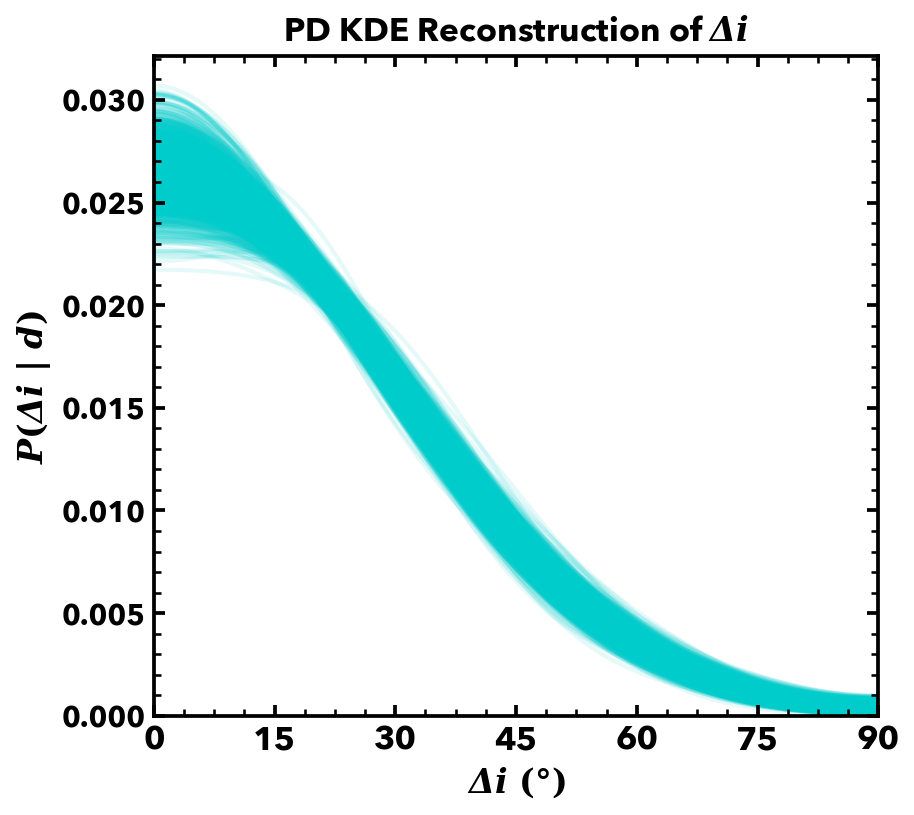

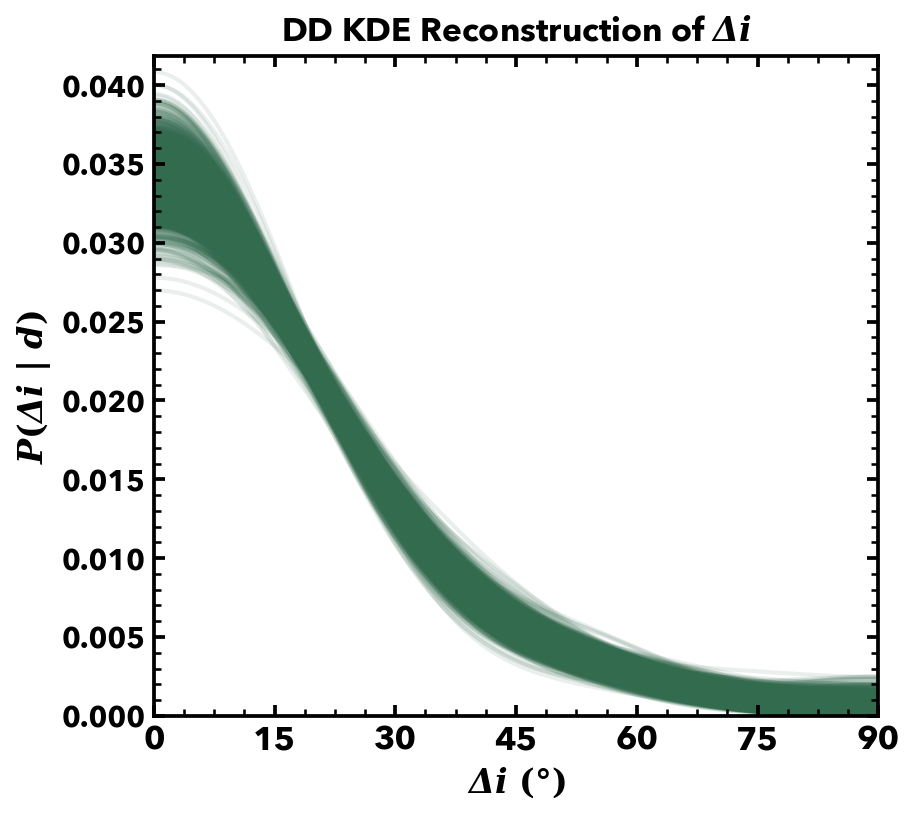

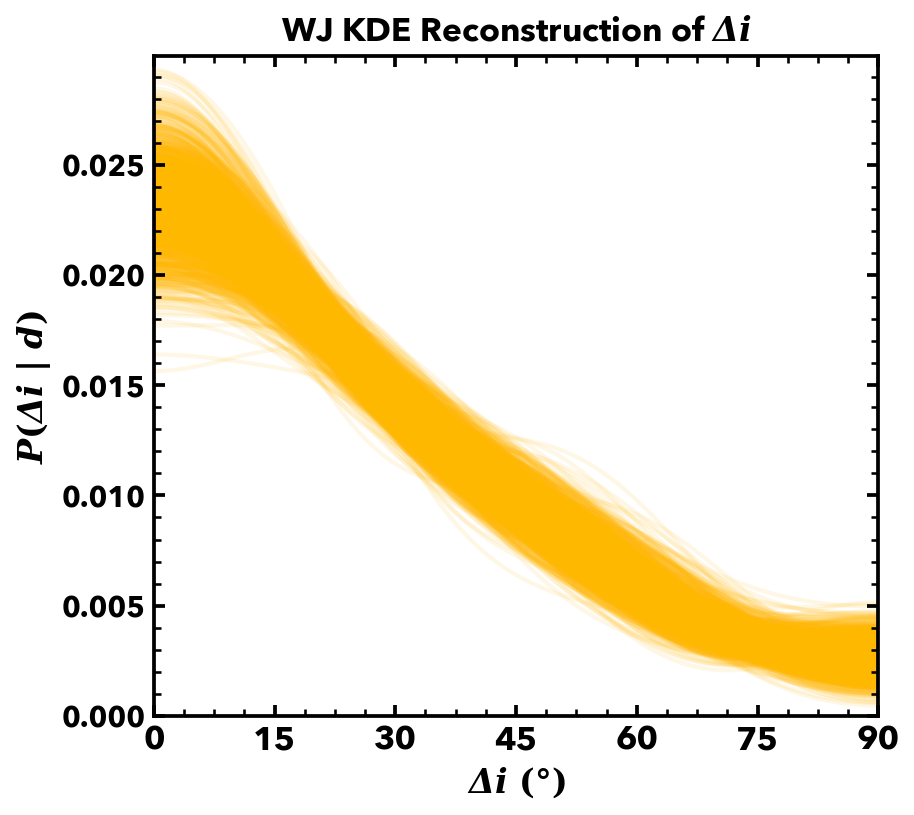

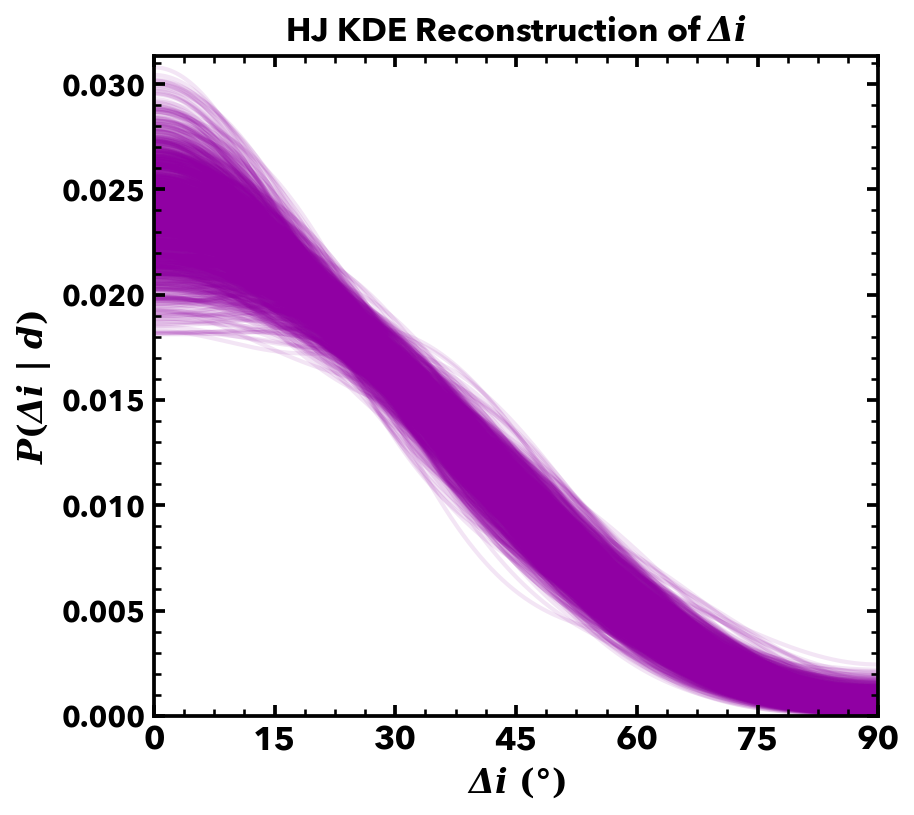

In [404]:
if do_kde_montecarlo_test == True:

    do_fill_between_KDE = False
    draw_alpha = 0.10
    draw_lw = 2

    # max_displayed = 150
    max_displayed = n_plot_distributions

    for sample_type in sample_type_list:

        kde_025 = np.array(KDE_sample_type_dict[sample_type]['2.5'])
        kde_16 = np.array(KDE_sample_type_dict[sample_type]['16'])
        kde_50 = np.array(KDE_sample_type_dict[sample_type]['50'])
        kde_84 = np.array(KDE_sample_type_dict[sample_type]['84'])
        kde_975 = np.array(KDE_sample_type_dict[sample_type]['97.5'])

        xmin_test, xmax_test = 0, 90
        ymin_test, ymax_test = 0, 1.10 * max(kde_975)
        MC_kde_fontsize=16

        fig = plt.figure(figsize=(6, 5.5), dpi=150)
        ax = fig.add_subplot(111)
        ax.minorticks_on()
        # ax.plot(x_grid_plot, nominal_kde, ls=':', dashes=(1, 1), color='#000000', lw=4, alpha=0.5, label='Nominal KDE', zorder=-3)
        
        if sample_type == 'PD':
            which_dataset = 'PD'
            line_color = pd_color
        if sample_type == 'DD':
            which_dataset = 'DD'
            line_color = dd_color
        if sample_type == 'WJ':
            which_dataset = 'WJ'
            line_color = WJ_color
        if sample_type == 'HJ':
            which_dataset = 'HJ'
            line_color = HJ_color

        plot_kde_nums = choices(np.arange(0, len(kdes_plot[sample_type]), 1), k=max_displayed)

        if do_fill_between_KDE == True:
            ax.fill_between(x_grid_plot, kde_975_plot[sample_type], kde_025_plot[sample_type], lw=0, color=line_color, alpha=0.3, zorder=-6)
            ax.fill_between(x_grid_plot, kde_84_plot[sample_type], kde_16_plot[sample_type], lw=0, color=line_color, alpha=1, zorder=-5)
        else:
            for kde_i, kde_i_plot in enumerate(kdes_plot[sample_type]):
                if kde_i in plot_kde_nums:
                    ax.plot(x_grid_plot, kde_i_plot, lw=draw_lw, linestyle='-', color=line_color, alpha=draw_alpha, zorder=-5)

        ax.set_xlim(xmin_test, xmax_test)
        ax.set_ylim(ymin_test, ymax_test)
        if test_distribution == 'Deltai':
            ax.set_title(sample_type.replace('_', ' ') + r' KDE Reconstruction of $\Delta i$', size=MC_kde_fontsize, pad=8)
            ax.set_xlabel(r'$\Delta i~\mathrm{(}\degree\mathrm{)}$', fontsize=MC_kde_fontsize)
            ax.set_ylabel(r'$P\mathrm{(}\Delta i~|~d\mathrm{)}$', fontsize=MC_kde_fontsize)
            ax.set_xlim(0, 90)
            xtickvals = [0, 15, 30, 45, 60, 75, 90]
        if test_distribution == 'Psi':
            ax.set_title(sample_type.replace('_', ' ') + r' KDE Reconstruction of $\Psi$', size=MC_kde_fontsize, pad=8)
            ax.set_xlabel(r'$\Psi~\mathrm{(}\degree\mathrm{)}$', fontsize=MC_kde_fontsize)
            ax.set_ylabel(r'$P\mathrm{(}\Psi~|~d\mathrm{)}$', fontsize=MC_kde_fontsize)
            ax.set_xlim(0, 180)
            xtickvals = [0, 30, 60, 90, 120, 150, 180]
        ax.set_xticks(xtickvals)
        ax.set_xticklabels(xtickvals, fontsize=MC_kde_fontsize)

        fig.subplots_adjust(left=0.17, bottom=0.14, right=0.975, top=0.94, wspace=0.08, hspace=0.50)

        # if test_distribution == 'Deltai':
        #     fig.savefig(test_figures_directory + 'MonteCarlo_Deltai_' + sample_type + '/MC_Deltai.pdf', dpi=300)
        # if test_distribution == 'Psi':
        #     fig.savefig(test_figures_directory + 'MonteCarlo_Psi_' + sample_type + '/MC_Psi.pdf', dpi=300)
        plt.show() 

# Next

In [405]:
# ------------------ DETERMINE X_GRID ------------------ #
Posteriors = pd.read_csv(probability_distributions_dir+ 'Prob_61Virginis.csv')
posterior_i_values = Posteriors['i (deg)'].values
x_grid = np.array(posterior_i_values).reshape(-1, 1)

reverse_posterior_i_values = -posterior_i_values[::-1][:-1]
all_posterior_i_values = np.concatenate((np.array(reverse_posterior_i_values), np.array(posterior_i_values)))
x_grid_all = np.array(all_posterior_i_values).reshape(-1, 1)

x_grid_plot = np.copy(posterior_i_values)


np.random.seed(4)
seed(4)


KDE_filepath = save_csv_filepath_PD  + 'KDE_' + resolution_text + '_'+ date_str + '.csv'


do_mirror = True

track_posteriors = []


data_for_kde_PD = []
data_for_kde_DD = []
data_for_kde_WJ = []
data_for_kde_HJ = []

kde_n_draws = 10

# kde_bandwidth = 5  # 5, 2.5, 7.5, 10

PD_target_list = df_PD['Target'].values
DD_target_list = df_DD['Target'].values
WJ_target_list = df_WJ['Target'].values
HJ_target_list = df_HJ['Target'].values

if do_test_object_only == True:
    if 'PD' in sample_type_list:
        PD_target_list = [test_targ]
    if 'DD' in sample_type_list:
        DD_target_list = [test_targ]
    if 'WJ' in sample_type_list:
        WJ_target_list = [test_targ]
    if 'HJ' in sample_type_list:
        HJ_target_list = [test_targ]



# ------------------ COMPUTE KDE FROM DRAWS ------------------ #

# --------------------------- PD -------------------------- #
if same_bandwidth == True:
    kde_bandwidth_PD = band_width_same
else:
    kde_bandwidth_PD = band_width_PD
print('KDE Bandwidth PD = ', kde_bandwidth_PD)
for targetnum in range(len(PD_target_list)):

    target_str = df_PD['Target'].values[targetnum].replace(' ', '')
    if '/' in df_PD['Target'].values[targetnum]:
        target_str = target_str.replace('/', '-')
    if '(' in target_str:
        target_str = target_str.split('(')[0]

    Posteriors = pd.read_csv('/Users/lb8137/PROJECTS/PRIMORDIAL_OBLIQUITY/Backup/Tables/Probability_Distributions/High/' + 'Prob_' + target_str + '_Nominal.csv')
    P_Delta_i_target = np.array(Posteriors['P(Delta i | d)'].values)
    posterior_i_values_PD = np.array(Posteriors['i (deg)'].values)

    P_Delta_i_target = np.interp(x=posterior_i_values, xp=posterior_i_values_PD, fp=P_Delta_i_target)

    track_posteriors.append(P_Delta_i_target)

    data_for_kde_PD.extend(choices(posterior_i_values, P_Delta_i_target, k=kde_n_draws))

# --------------------------- DD --------------------------- #
if same_bandwidth == True:
    kde_bandwidth_DD = band_width_same
else:
    kde_bandwidth_DD = band_width_DD
print('KDE Bandwidth DD = ', kde_bandwidth_DD)
for targetnum in range(len(DD_target_list)):

    target_str = df_DD['Target'].values[targetnum].replace(' ', '')
    if '/' in df_DD['Target'].values[targetnum]:
        target_str = target_str.replace('/', '-')

    Posteriors = pd.read_csv(probability_distributions_dir + 'Prob_' + target_str + '.csv')
    P_Delta_i_target = np.array(Posteriors['P(Delta i | d)'].values)
    posterior_i_values_DD = np.array(Posteriors['i (deg)'].values)

    P_Delta_i_target = np.interp(x=posterior_i_values, xp=posterior_i_values_DD, fp=P_Delta_i_target)

    track_posteriors.append(P_Delta_i_target)

    data_for_kde_DD.extend(choices(posterior_i_values, P_Delta_i_target, k=kde_n_draws))


# ------------------------- WJ ------------------------ #
if same_bandwidth == True:
    kde_bandwidth_WJ = band_width_same
else:
    kde_bandwidth_WJ = band_width_WJ
print('KDE Bandwidth WJ = ', kde_bandwidth_WJ)
for targetnum in range(len(WJ_target_list)):

    target_str = df_WJ['Target'].values[targetnum].replace(' ', '')
    if '/' in df_WJ['Target'].values[targetnum]:
        target_str = target_str.replace('/', '-')

    Posteriors = pd.read_csv(probability_distributions_dir + 'Posteriors_' + target_str + '_WJ.csv')
    P_Delta_i_target = np.array(Posteriors['P(Delta i | d)'].values)
    posterior_i_values_WJ = np.array(Posteriors['i (deg)'].values)

    P_Delta_i_target = np.interp(x=posterior_i_values, xp=posterior_i_values_WJ, fp=P_Delta_i_target)

    track_posteriors.append(P_Delta_i_target)

    data_for_kde_WJ.extend(choices(posterior_i_values, P_Delta_i_target, k=kde_n_draws))


# ------------------------- HJ ------------------------ #
if same_bandwidth == True:
    kde_bandwidth_HJ = band_width_same
else:
    kde_bandwidth_HJ = band_width_HJ
print('KDE Bandwidth HJ = ', kde_bandwidth_HJ)
for targetnum in range(len(HJ_target_list)):

    target_str = df_HJ['Target'].values[targetnum].replace(' ', '')
    if '/' in df_HJ['Target'].values[targetnum]:
        target_str = target_str.replace('/', '-')

    Posteriors = pd.read_csv(probability_distributions_dir + 'Posteriors_' + target_str + '_HJ.csv')
    P_Delta_i_target = np.array(Posteriors['P(Delta i | d)'].values)
    posterior_i_values_HJ = np.array(Posteriors['i (deg)'].values)

    P_Delta_i_target = np.interp(x=posterior_i_values, xp=posterior_i_values_HJ, fp=P_Delta_i_target)

    track_posteriors.append(P_Delta_i_target)

    data_for_kde_HJ.extend(choices(posterior_i_values, P_Delta_i_target, k=kde_n_draws))

    



data_for_kde_PD = np.array(data_for_kde_PD).reshape(-1, 1)
data_for_kde_DD = np.array(data_for_kde_DD).reshape(-1, 1)
data_for_kde_HJ = np.array(data_for_kde_HJ).reshape(-1, 1)
data_for_kde_WJ = np.array(data_for_kde_WJ).reshape(-1, 1)

kde_PD = KernelDensity(kernel='gaussian', bandwidth=kde_bandwidth_PD).fit(data_for_kde_PD)
kde_DD = KernelDensity(kernel='gaussian', bandwidth=kde_bandwidth_DD).fit(data_for_kde_DD)
kde_WJ = KernelDensity(kernel='gaussian', bandwidth=kde_bandwidth_WJ).fit(data_for_kde_WJ)
kde_HJ = KernelDensity(kernel='gaussian', bandwidth=kde_bandwidth_HJ).fit(data_for_kde_HJ)

log_density_PD = kde_PD.score_samples(x_grid_all)
log_density_DD = kde_DD.score_samples(x_grid_all)
log_density_WJ = kde_WJ.score_samples(x_grid_all)
log_density_HJ = kde_HJ.score_samples(x_grid_all)

density_estimation_PD = np.array(np.exp(log_density_PD))
density_estimation_DD = np.array(np.exp(log_density_DD))
density_estimation_WJ = np.array(np.exp(log_density_WJ))
density_estimation_HJ = np.array(np.exp(log_density_HJ))

density_estimation_mirrored_PD = density_estimation_PD[::-1]
density_estimation_mirrored_DD = density_estimation_DD[::-1]
density_estimation_mirrored_WJ = density_estimation_WJ[::-1]
density_estimation_mirrored_HJ = density_estimation_HJ[::-1]

density_estimation_total_PD = density_estimation_PD + density_estimation_mirrored_PD
density_estimation_total_DD = density_estimation_DD + density_estimation_mirrored_DD
density_estimation_total_WJ = density_estimation_WJ + density_estimation_mirrored_WJ
density_estimation_total_HJ = density_estimation_HJ + density_estimation_mirrored_HJ

KDE_dict = {'all_posterior_i_values': all_posterior_i_values,
            'density_estimation_PD': density_estimation_PD,
            'density_estimation_DD': density_estimation_DD,
            'density_estimation_WJ': density_estimation_WJ,
            'density_estimation_HJ': density_estimation_HJ,
            'density_estimation_mirrored_PD': density_estimation_mirrored_PD,
            'density_estimation_mirrored_DD': density_estimation_mirrored_DD,
            'density_estimation_mirrored_WJ': density_estimation_mirrored_WJ,
            'density_estimation_mirrored_HJ': density_estimation_mirrored_HJ,
            'density_estimation_total_PD': density_estimation_total_PD,
            'density_estimation_total_DD': density_estimation_total_DD,
            'density_estimation_total_WJ': density_estimation_total_WJ,
            'density_estimation_total_HJ': density_estimation_total_HJ,
            'kde_n_draws': [kde_n_draws]*len(density_estimation_PD),
            'band_width_PD': [kde_bandwidth_PD]*len(density_estimation_PD),
            'band_width_DD': [kde_bandwidth_DD]*len(density_estimation_DD),
            'band_width_WJ': [kde_bandwidth_WJ]*len(density_estimation_WJ),
            'band_width_HJ': [kde_bandwidth_HJ]*len(density_estimation_HJ),
            }
KDE_df = pd.DataFrame(KDE_dict)
# print(KDE_df)
KDE_df.to_csv(KDE_filepath, index=False)


density_estimation_total_positive_x_PD = density_estimation_total_PD[all_posterior_i_values >= 0]
density_estimation_total_positive_x_DD = density_estimation_total_DD[all_posterior_i_values >= 0]
density_estimation_total_positive_x_WJ = density_estimation_total_WJ[all_posterior_i_values >= 0]
density_estimation_total_positive_x_HJ = density_estimation_total_HJ[all_posterior_i_values >= 0]

dx = np.diff(x_grid_plot)[0]
print('dx: ', dx)

density_estimation_total_positive_x_PD = density_estimation_total_positive_x_PD / (sum(density_estimation_total_positive_x_PD) * dx)
density_estimation_total_positive_x_DD = density_estimation_total_positive_x_DD / (sum(density_estimation_total_positive_x_DD) * dx)
density_estimation_total_positive_x_WJ = density_estimation_total_positive_x_WJ / (sum(density_estimation_total_positive_x_WJ) * dx)
density_estimation_total_positive_x_HJ = density_estimation_total_positive_x_HJ / (sum(density_estimation_total_positive_x_HJ) * dx)


KDE Bandwidth PD =  12.4
KDE Bandwidth DD =  12.4
KDE Bandwidth WJ =  12.4
KDE Bandwidth HJ =  12.4
dx:  0.5


In [406]:
density_estimation_uncorrected_PD = density_estimation_PD[all_posterior_i_values >= 0]
density_estimation_uncorrected_DD = density_estimation_DD[all_posterior_i_values >= 0]
density_estimation_uncorrected_WJ = density_estimation_WJ[all_posterior_i_values >= 0]
density_estimation_uncorrected_HJ = density_estimation_HJ[all_posterior_i_values >= 0]

density_estimation_uncorrected_PD = density_estimation_uncorrected_PD / (sum(density_estimation_uncorrected_PD) * dx)
density_estimation_uncorrected_DD = density_estimation_uncorrected_DD / (sum(density_estimation_uncorrected_DD) * dx)
density_estimation_uncorrected_WJ = density_estimation_uncorrected_WJ / (sum(density_estimation_uncorrected_WJ) * dx)
density_estimation_uncorrected_HJ = density_estimation_uncorrected_HJ / (sum(density_estimation_uncorrected_HJ) * dx)


In [407]:
kde_MAP_PD, sig1_kde_m_PD, sig1_kde_p_PD, fraction_values_PD, posterior_kde_fractions_PD = highest_density_interval(x=x_grid_plot, pdf_y=density_estimation_total_positive_x_PD, sigma=0.6826, return_pdf=True)
kde_MAP_DD, sig1_kde_m_DD, sig1_kde_p_DD, fraction_values_DD, posterior_kde_fractions_DD = highest_density_interval(x=x_grid_plot, pdf_y=density_estimation_total_positive_x_DD, sigma=0.6826, return_pdf=True)
kde_MAP_WJ, sig1_kde_m_WJ, sig1_kde_p_WJ, fraction_values_WJ, posterior_kde_fractions_WJ = highest_density_interval(x=x_grid_plot, pdf_y=density_estimation_total_positive_x_WJ, sigma=0.6826, return_pdf=True)
kde_MAP_HJ, sig1_kde_m_HJ, sig1_kde_p_HJ, fraction_values_HJ, posterior_kde_fractions_HJ = highest_density_interval(x=x_grid_plot, pdf_y=density_estimation_total_positive_x_HJ, sigma=0.6826, return_pdf=True)

print('PD KDE MAP AND 1sigma Confidence: {:.2f} +{:.2f} -{:.2f}'.format(kde_MAP_PD, sig1_kde_p_PD, sig1_kde_m_PD))
print('DD KDE MAP AND 1sigma Confidence: {:.2f} +{:.2f} -{:.2f}'.format(kde_MAP_DD, sig1_kde_p_DD, sig1_kde_m_DD))
print('WJ KDE MAP AND 1sigma Confidence: {:.2f} +{:.2f} -{:.2f}'.format(kde_MAP_WJ, sig1_kde_p_WJ, sig1_kde_m_WJ))
print('HJ KDE MAP AND 1sigma Confidence: {:.2f} +{:.2f} -{:.2f}'.format(kde_MAP_HJ, sig1_kde_p_HJ, sig1_kde_m_HJ))

PD KDE MAP AND 1sigma Confidence: 0.00 +28.51 -0.00
DD KDE MAP AND 1sigma Confidence: 0.00 +21.84 -0.00
WJ KDE MAP AND 1sigma Confidence: 0.00 +36.10 -0.00
HJ KDE MAP AND 1sigma Confidence: 0.00 +31.26 -0.00


mean_PD: 44.654164149165624
mean_DD: 35.83524372865951
mean_WJ: 55.57127020963719
mean_HJ: 49.0067544383443


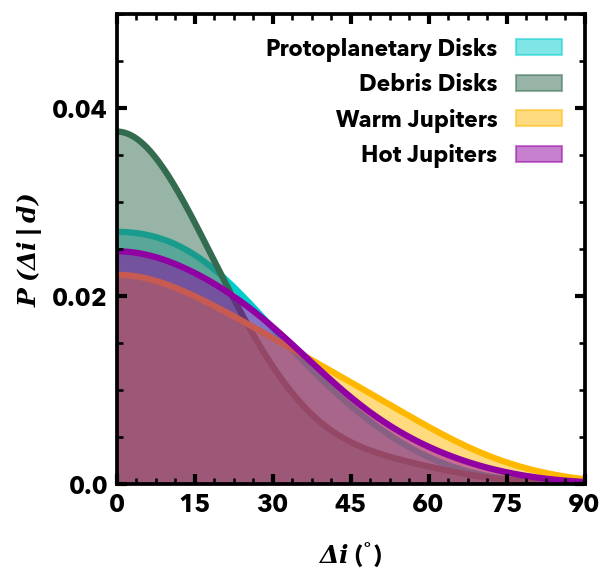

In [408]:

mpl.rcParams['hatch.linewidth'] = 2


fig = plt.figure(figsize=(4, 3.75), dpi=150)
ax = fig.add_subplot(111)

ax.minorticks_on()

Delta_i_hist_fontsize = 12

ax.set_xlabel(r'$\Delta i$ ($^\degree$)', fontsize=Delta_i_hist_fontsize, labelpad=10)
ax.set_ylabel(r'$P$ $(\Delta i$ | $d)$', fontsize=Delta_i_hist_fontsize)

zorder_shift = 10

mean_PD = np.sum(x_grid_plot * density_estimation_total_positive_x_PD)
mean_DD = np.sum(x_grid_plot * density_estimation_total_positive_x_DD)
mean_WJ = np.sum(x_grid_plot * density_estimation_total_positive_x_WJ)
mean_HJ = np.sum(x_grid_plot * density_estimation_total_positive_x_HJ)

print('mean_PD: ' + str(mean_PD))
print('mean_DD: ' + str(mean_DD))
print('mean_WJ: ' + str(mean_WJ))
print('mean_HJ: ' + str(mean_HJ))

ax.plot(x_grid_plot, density_estimation_total_positive_x_PD, color=pd_color, alpha=1, lw=3, zorder=-11)
ax.fill_between(x_grid_plot, density_estimation_total_positive_x_PD, color=pd_color, alpha=0.5, label='Protoplanetary Disks', zorder=-12)
ax.plot(x_grid_plot, density_estimation_total_positive_x_DD, color=dd_color, alpha=1, lw=3, zorder=-10)
ax.fill_between(x_grid_plot, density_estimation_total_positive_x_DD, color=dd_color, alpha=0.5, label='Debris Disks', zorder=-10)
ax.plot(x_grid_plot, density_estimation_total_positive_x_WJ, color=WJ_color, lw=3, alpha=1, zorder=-9)
ax.fill_between(x_grid_plot, density_estimation_total_positive_x_WJ, color=WJ_color, alpha=0.5, label='Warm Jupiters', zorder=-9)
ax.plot(x_grid_plot, density_estimation_total_positive_x_HJ, color=HJ_color, lw=3, alpha=1, zorder=-8)
ax.fill_between(x_grid_plot, density_estimation_total_positive_x_HJ, color=HJ_color, alpha=0.5, label='Hot Jupiters', zorder=-8)


# ax.plot(x_grid_plot, density_estimation_total_positive_x_HJ, color=HJ_color, lw=3, alpha=1, zorder=-4)


xticks_major = [0, 15, 30, 45, 60, 75, 90]
ax.set_xticks(xticks_major, minor=False)
ax.set_xticklabels(xticks_major, fontsize=Delta_i_hist_fontsize)
# ax.set_xticklabels(xticks_hist_minor, fontsize=Delta_i_hist_fontsize)
# minor_locator = AutoMinorLocator(3)
# ax.xaxis.set_minor_locator(minor_locator)
ax.set_xlim(0, 90)

yticks_hist = np.arange(0, 0.07 + 0.02, 0.02)
ax.set_yticks(yticks_hist)
ax.set_yticklabels(yticks_hist)
ax.set_ylim(0, 0.05)

ax.legend(loc='upper right', prop={'size': 11}, ncol=1, markerfirst=False)  # , bbox_to_anchor=(0.24, 0.90, 0.5, 0.10))

for spine in ax.spines.values():
    spine.set_zorder(100)

ax.tick_params(which='minor', length=3, width=1.25, labelsize=Delta_i_hist_fontsize)
ax.tick_params(which='major', length=5, width=2.0, labelsize=Delta_i_hist_fontsize)

fig.subplots_adjust(left=0.19, bottom=0.145, right=0.97, top=0.98, wspace=0.12, hspace=0.35)


save_kde_string = 'KDEs_' + resolution_text + '_' + light_or_dark_dext + '_' + transparent_text + '_' + date_str + '.pdf'

fig.savefig(test_figures_directory + save_kde_string, dpi=300, transparent=False)

plt.show()
plt.close()


In [409]:
def combine_hex_values(hex_dict):
    d_items = sorted(hex_dict.items())
    tot_weight = sum(hex_dict.values())
    red = int(sum([int(w[:2], 16)*v for w, v in d_items])/tot_weight)
    green = int(sum([int(w[2:4], 16)*v for w, v in d_items])/tot_weight)
    blue = int(sum([int(w[4:6], 16)*v for w, v in d_items])/tot_weight)
    zpad = lambda u: u if len(u)==2 else '0' + u
    return '#' + zpad(hex(red)[2:]) + zpad(hex(green)[2:]) + zpad(hex(blue)[2:])


kde_i 2199


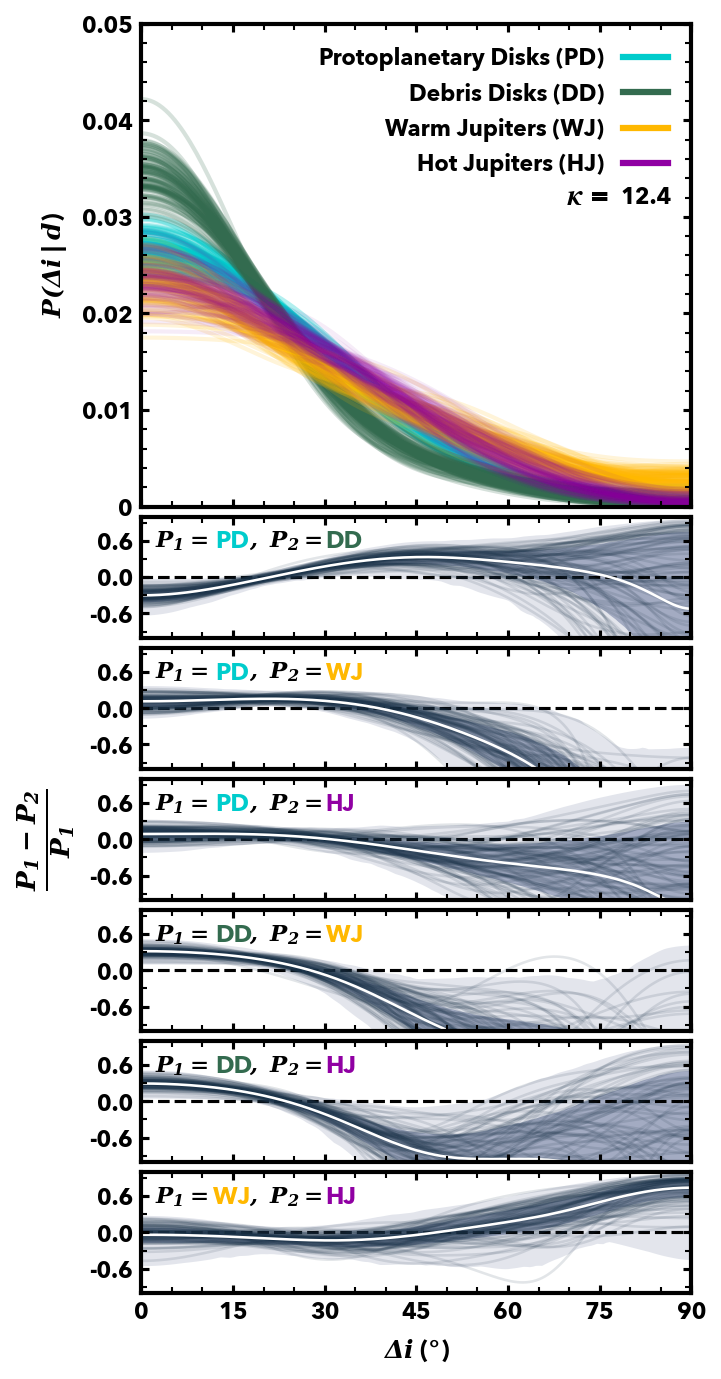

In [410]:
residual_stacked_plots_width = 4.5
residual_stacked_plots_height = 9.0

residual_stacked_plots_suptitlepad = 10
residual_stacked_plots_suptitle_fontsize = 10

residual_stacked_plots_labelpad = 6
residual_stacked_plots_label_fontsize = 11

residual_stacked_plots_tick_fontsize = 11

residual_text_fontsize = 12

# max_displayed = 100
max_displayed = 100  # n_plot_distributions

x_grid_plot = np.arange(0, 90+dx, dx)

# dd_color = '#336b4f'

fig = plt.figure(figsize=(residual_stacked_plots_width, residual_stacked_plots_height), dpi=150)
axes = fig.subplot_mosaic(
    """
    k
    j
    i
    h
    l
    m
    n
    """,
    gridspec_kw={'height_ratios': [1, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25], 'width_ratios': [1], "bottom": 0.05, "top": 0.99, "left": 0.16, "right": 0.975, "wspace": 0.10, "hspace": 0.06}
)

# axes['k'].set_title('KDEs Computed Using Random Draws From\nMeasurement Probability Distributions', fontsize=residual_stacked_plots_label_fontsize, pad=residual_stacked_plots_labelpad)
# ax.yaxis.label.set_family("DejaVu Serif")
# ax.xaxis.label.set_family("DejaVu Serif")
axes['k'].set_ylabel(r'$P(\Delta i$ | $d$)', fontsize=residual_stacked_plots_label_fontsize+1, labelpad=residual_stacked_plots_labelpad)
axes['n'].set_xlabel(r'$\Delta i$ ($\degree$)', fontsize=residual_stacked_plots_label_fontsize+1, labelpad=residual_stacked_plots_labelpad)
# axes['h'].set_ylabel(r'$\frac{P_1(\Delta i) - P_2(\Delta i)}{P_1(\Delta i)}$', fontsize=residual_stacked_plots_label_fontsize+8, labelpad=residual_stacked_plots_labelpad)  # , y=0)
axes['h'].set_ylabel(r'$\frac{P_1 - P_2}{P_1}$', fontsize=residual_stacked_plots_label_fontsize+7, labelpad=residual_stacked_plots_labelpad)  # , y=0)


# PD_HJ_color = combine_hex_values({"ffffff": 1.0, HJ_color[1:]: 0.5, pd_color[1:]: 0.05})
PD_HJ_color = combine_hex_values({HJ_color[1:]: 0.5, pd_color[1:]: 0.5})
PD_WJ_color = combine_hex_values({WJ_color[1:]: 0.2, pd_color[1:]: 0.2, "604020": 0.6})
PD_DD_color = combine_hex_values({dd_color[1:]: 0.3, pd_color[1:]: 0.7})
DD_HJ_color = combine_hex_values({dd_color[1:]: 0.5, HJ_color[1:]: 0.5})
DD_WJ_color = combine_hex_values({dd_color[1:]: 0.4, WJ_color[1:]: 0.6})
WJ_HJ_color = combine_hex_values({WJ_color[1:]: 0.35, HJ_color[1:]: 0.65})


for sample_type in sample_type_list:
    if sample_type == 'PD':
        line_color = pd_color
        draw_alpha = 0.3
        PD_kdes = []
        plot_zorder = -10
    if sample_type == 'DD':
        line_color = dd_color
        draw_alpha = 0.2
        DD_kdes = []
        plot_zorder = -8
    if sample_type == 'WJ':
        line_color = WJ_color
        draw_alpha = 0.15
        WJ_kdes = []
        plot_zorder = -6
    if sample_type == 'HJ':
        line_color = HJ_color
        draw_alpha = 0.075
        HJ_kdes = []
        plot_zorder = -4
    do_fill_between_KDE = False
    if do_fill_between_KDE == True:
        axes['k'].fill_between(x_grid_plot, kde_975_plot[sample_type], kde_025_plot[sample_type], lw=0, color=line_color, alpha=0.2, zorder=plot_zorder)
        axes['k'].fill_between(x_grid_plot, kde_84_plot[sample_type], kde_16_plot[sample_type], lw=0, color=line_color, alpha=0.7, zorder=plot_zorder+1)
        
    plot_kde_nums = choices(np.arange(0, len(kdes_plot[sample_type]), 1), k=max_displayed)

    for kde_i, kde_i_plot in enumerate(kdes_plot[sample_type]):

        if len(kde_i_plot) > len(x_grid_plot):
            x_grid_bep = np.arange(0, 90 + 0.1, 0.1)
            kde_i_plot = np.interp(x_grid_plot, x_grid_bep, kde_i_plot)

        if do_fill_between_KDE == False:
            if kde_i in plot_kde_nums:
                # print(x_grid_plot)
                axes['k'].plot(x_grid_plot, kde_i_plot, lw=draw_lw, linestyle='-', color=line_color, alpha=draw_alpha, zorder=-20)
        if sample_type == 'PD':
            PD_kdes.append(kde_i_plot)
        if sample_type == 'DD':
            DD_kdes.append(kde_i_plot)
        if sample_type == 'WJ':
            WJ_kdes.append(kde_i_plot)
        if sample_type == 'HJ':
            HJ_kdes.append(kde_i_plot)


PD_minus_HJ_residuals = []
PD_minus_WJ_residuals = []
PD_minus_DD_residuals = []
DD_minus_WJ_residuals = []
DD_minus_HJ_residuals = []
WJ_minus_HJ_residuals = []


residual_color_dark = '#1c344a'
residual_color_light = '#d9e6f2'

residual_alpha_dark = 0.125
residual_alpha_light = 0.075

for kde_i in range(min([len(PD_kdes), len(DD_kdes), len(WJ_kdes), len(HJ_kdes)])):

    PD_minus_HJ_residual = (PD_kdes[kde_i] - HJ_kdes[kde_i])/(PD_kdes[kde_i])
    PD_minus_WJ_residual = (PD_kdes[kde_i] - WJ_kdes[kde_i])/(PD_kdes[kde_i])
    PD_minus_DD_residual = (PD_kdes[kde_i] - DD_kdes[kde_i])/(PD_kdes[kde_i])
    DD_minus_WJ_residual = (DD_kdes[kde_i] - WJ_kdes[kde_i])/(DD_kdes[kde_i])
    DD_minus_HJ_residual = (DD_kdes[kde_i] - HJ_kdes[kde_i])/(DD_kdes[kde_i])
    WJ_minus_HJ_residual = (WJ_kdes[kde_i] - HJ_kdes[kde_i])/(WJ_kdes[kde_i])

    PD_minus_HJ_residuals.append(PD_minus_HJ_residual)
    PD_minus_WJ_residuals.append(PD_minus_WJ_residual)
    PD_minus_DD_residuals.append(PD_minus_DD_residual)
    DD_minus_WJ_residuals.append(DD_minus_WJ_residual)
    DD_minus_HJ_residuals.append(DD_minus_HJ_residual)
    WJ_minus_HJ_residuals.append(WJ_minus_HJ_residual)
    
    if kde_i in plot_kde_nums:
        axes['h'].plot(x_grid_plot, PD_minus_HJ_residual, color=residual_color_dark, alpha=residual_alpha_dark, lw=1.25, zorder=-11)
        axes['i'].plot(x_grid_plot, PD_minus_WJ_residual, color=residual_color_dark, alpha=residual_alpha_dark, lw=1.25, zorder=-11)
        axes['j'].plot(x_grid_plot, PD_minus_DD_residual, color=residual_color_dark, alpha=residual_alpha_dark, lw=1.25, zorder=-11)
        axes['l'].plot(x_grid_plot, DD_minus_WJ_residual, color=residual_color_dark, alpha=residual_alpha_dark, lw=1.25, zorder=-11)
        axes['m'].plot(x_grid_plot, DD_minus_HJ_residual, color=residual_color_dark, alpha=residual_alpha_dark, lw=1.25, zorder=-11)
        axes['n'].plot(x_grid_plot, WJ_minus_HJ_residual, color=residual_color_dark, alpha=residual_alpha_dark, lw=1.25, zorder=-11)

print("kde_i", kde_i)

mean_PD_minus_HJ_residuals = np.mean(PD_minus_HJ_residuals, axis=0)
mean_PD_minus_WJ_residuals = np.mean(PD_minus_WJ_residuals, axis=0)
mean_PD_minus_DD_residuals = np.mean(PD_minus_DD_residuals, axis=0)
mean_DD_minus_WJ_residuals = np.mean(DD_minus_WJ_residuals, axis=0)
mean_DD_minus_HJ_residuals = np.mean(DD_minus_HJ_residuals, axis=0)
mean_WJ_minus_HJ_residuals = np.mean(WJ_minus_HJ_residuals, axis=0)

std_PD_minus_HJ_residuals = np.std(PD_minus_HJ_residuals, axis=0)
std_PD_minus_WJ_residuals = np.std(PD_minus_WJ_residuals, axis=0)
std_PD_minus_DD_residuals = np.std(PD_minus_DD_residuals, axis=0)
std_DD_minus_WJ_residuals = np.std(DD_minus_WJ_residuals, axis=0)
std_DD_minus_HJ_residuals = np.std(DD_minus_HJ_residuals, axis=0)
std_WJ_minus_HJ_residuals = np.std(WJ_minus_HJ_residuals, axis=0)

p50_PD_minus_HJ_residuals = np.percentile(PD_minus_HJ_residuals, 50, axis=0)
p50_PD_minus_WJ_residuals = np.percentile(PD_minus_WJ_residuals, 50, axis=0)
p50_PD_minus_DD_residuals = np.percentile(PD_minus_DD_residuals, 50, axis=0)
p50_DD_minus_WJ_residuals = np.percentile(DD_minus_WJ_residuals, 50, axis=0)
p50_DD_minus_HJ_residuals = np.percentile(DD_minus_HJ_residuals, 50, axis=0)
p50_WJ_minus_HJ_residuals = np.percentile(WJ_minus_HJ_residuals, 50, axis=0)

p84_PD_minus_HJ_residuals = np.percentile(PD_minus_HJ_residuals, 84, axis=0)
p84_PD_minus_WJ_residuals = np.percentile(PD_minus_WJ_residuals, 84, axis=0)
p84_PD_minus_DD_residuals = np.percentile(PD_minus_DD_residuals, 84, axis=0)
p84_DD_minus_WJ_residuals = np.percentile(DD_minus_WJ_residuals, 84, axis=0)
p84_DD_minus_HJ_residuals = np.percentile(DD_minus_HJ_residuals, 84, axis=0)
p84_WJ_minus_HJ_residuals = np.percentile(WJ_minus_HJ_residuals, 84, axis=0)

p16_PD_minus_HJ_residuals = np.percentile(PD_minus_HJ_residuals, 16, axis=0)
p16_PD_minus_WJ_residuals = np.percentile(PD_minus_WJ_residuals, 16, axis=0)
p16_PD_minus_DD_residuals = np.percentile(PD_minus_DD_residuals, 16, axis=0)
p16_DD_minus_WJ_residuals = np.percentile(DD_minus_WJ_residuals, 16, axis=0)
p16_DD_minus_HJ_residuals = np.percentile(DD_minus_HJ_residuals, 16, axis=0)
p16_WJ_minus_HJ_residuals = np.percentile(WJ_minus_HJ_residuals, 16, axis=0)

p015_PD_minus_HJ_residuals = np.percentile(PD_minus_HJ_residuals, 0.15, axis=0)
p015_PD_minus_WJ_residuals = np.percentile(PD_minus_WJ_residuals, 0.15, axis=0)
p015_PD_minus_DD_residuals = np.percentile(PD_minus_DD_residuals, 0.15, axis=0)
p015_DD_minus_WJ_residuals = np.percentile(DD_minus_WJ_residuals, 0.15, axis=0)
p015_DD_minus_HJ_residuals = np.percentile(DD_minus_HJ_residuals, 0.15, axis=0)
p015_WJ_minus_HJ_residuals = np.percentile(WJ_minus_HJ_residuals, 0.15, axis=0)

p9985_PD_minus_HJ_residuals = np.percentile(PD_minus_HJ_residuals, 99.85, axis=0)
p9985_PD_minus_WJ_residuals = np.percentile(PD_minus_WJ_residuals, 99.85, axis=0)
p9985_PD_minus_DD_residuals = np.percentile(PD_minus_DD_residuals, 99.85, axis=0)
p9985_DD_minus_WJ_residuals = np.percentile(DD_minus_WJ_residuals, 99.85, axis=0)
p9985_DD_minus_HJ_residuals = np.percentile(DD_minus_HJ_residuals, 99.85, axis=0)
p9985_WJ_minus_HJ_residuals = np.percentile(WJ_minus_HJ_residuals, 99.85, axis=0)



p50_color = '#ffffff'
# p50_color = '#000000'
# p50_color = '#6600cc'
# axes['h'].plot(x_grid_plot, p50_PD_minus_HJ_residuals, color=p50_color, alpha=1, lw=1.5, zorder=-11)
# axes['i'].plot(x_grid_plot, p50_PD_minus_WJ_residuals, color=p50_color, alpha=1, lw=1.5, zorder=-11)
# axes['j'].plot(x_grid_plot, p50_PD_minus_DD_residuals, color=p50_color, alpha=1, lw=1.5, zorder=-11)
# axes['l'].plot(x_grid_plot, p50_DD_minus_WJ_residuals, color=p50_color, alpha=1, lw=1.5, zorder=-11)
# axes['m'].plot(x_grid_plot, p50_DD_minus_HJ_residuals, color=p50_color, alpha=1, lw=1.5, zorder=-11)
# axes['n'].plot(x_grid_plot, p50_WJ_minus_HJ_residuals, color=p50_color, alpha=1, lw=1.5, zorder=-11)

axes['h'].plot(x_grid_plot, mean_PD_minus_HJ_residuals, color=p50_color, alpha=1, lw=1.25, zorder=-11)
axes['i'].plot(x_grid_plot, mean_PD_minus_WJ_residuals, color=p50_color, alpha=1, lw=1.25, zorder=-11)
axes['j'].plot(x_grid_plot, mean_PD_minus_DD_residuals, color=p50_color, alpha=1, lw=1.25, zorder=-11)
axes['l'].plot(x_grid_plot, mean_DD_minus_WJ_residuals, color=p50_color, alpha=1, lw=1.25, zorder=-11)
axes['m'].plot(x_grid_plot, mean_DD_minus_HJ_residuals, color=p50_color, alpha=1, lw=1.25, zorder=-11)
axes['n'].plot(x_grid_plot, mean_WJ_minus_HJ_residuals, color=p50_color, alpha=1, lw=1.25, zorder=-11)








    


# p84_color = '#568ec2'
# axes['h'].plot(x_grid_plot, p84_PD_minus_HJ_residuals, color=p84_color, alpha=1, lw=1.5, zorder=-900)
# axes['i'].plot(x_grid_plot, p84_PD_minus_WJ_residuals, color=p84_color, alpha=1, lw=1.5, zorder=-900)
# axes['j'].plot(x_grid_plot, p84_PD_minus_DD_residuals, color=p84_color, alpha=1, lw=1.5, zorder=-900)
# axes['l'].plot(x_grid_plot, p84_DD_minus_WJ_residuals, color=p84_color, alpha=1, lw=1.5, zorder=-900)
# axes['m'].plot(x_grid_plot, p84_DD_minus_HJ_residuals, color=p84_color, alpha=1, lw=1.5, zorder=-900)
# axes['n'].plot(x_grid_plot, p84_WJ_minus_HJ_residuals, color=p84_color, alpha=1, lw=1.5, zorder=-900)

# p16_color = '#568ec2'
# axes['h'].plot(x_grid_plot, p16_PD_minus_HJ_residuals, color=p16_color, alpha=1, lw=1.5, zorder=-900)
# axes['i'].plot(x_grid_plot, p16_PD_minus_WJ_residuals, color=p16_color, alpha=1, lw=1.5, zorder=-900)
# axes['j'].plot(x_grid_plot, p16_PD_minus_DD_residuals, color=p16_color, alpha=1, lw=1.5, zorder=-900)
# axes['l'].plot(x_grid_plot, p16_DD_minus_WJ_residuals, color=p16_color, alpha=1, lw=1.5, zorder=-900)
# axes['m'].plot(x_grid_plot, p16_DD_minus_HJ_residuals, color=p16_color, alpha=1, lw=1.5, zorder=-900)
# axes['n'].plot(x_grid_plot, p16_WJ_minus_HJ_residuals, color=p16_color, alpha=1, lw=1.5, zorder=-900)

fill_color = '#a3abc2'  # '#d9e6f2'
fill_color_9985 = '#a3abc2' # "#9fb6fa"
# fill_color = '#1c344a'
axes['h'].fill_between(x_grid_plot, p84_PD_minus_HJ_residuals, p16_PD_minus_HJ_residuals, color=fill_color, alpha=1, lw=0, zorder=-1000)
axes['i'].fill_between(x_grid_plot, p84_PD_minus_WJ_residuals, p16_PD_minus_WJ_residuals, color=fill_color, alpha=1, lw=0, zorder=-1000)
axes['j'].fill_between(x_grid_plot, p84_PD_minus_DD_residuals, p16_PD_minus_DD_residuals, color=fill_color, alpha=1, lw=0, zorder=-1000)
axes['l'].fill_between(x_grid_plot, p84_DD_minus_WJ_residuals, p16_DD_minus_WJ_residuals, color=fill_color, alpha=1, lw=0, zorder=-1000)
axes['m'].fill_between(x_grid_plot, p84_DD_minus_HJ_residuals, p16_DD_minus_HJ_residuals, color=fill_color, alpha=1, lw=0, zorder=-1000)
axes['n'].fill_between(x_grid_plot, p84_WJ_minus_HJ_residuals, p16_WJ_minus_HJ_residuals, color=fill_color, alpha=1, lw=0, zorder=-1000)

axes['h'].fill_between(x_grid_plot, p9985_PD_minus_HJ_residuals, p015_PD_minus_HJ_residuals, color=fill_color_9985, alpha=0.3, lw=0, zorder=-1000)
axes['i'].fill_between(x_grid_plot, p9985_PD_minus_WJ_residuals, p015_PD_minus_WJ_residuals, color=fill_color_9985, alpha=0.3, lw=0, zorder=-1000)
axes['j'].fill_between(x_grid_plot, p9985_PD_minus_DD_residuals, p015_PD_minus_DD_residuals, color=fill_color_9985, alpha=0.3, lw=0, zorder=-1000)
axes['l'].fill_between(x_grid_plot, p9985_DD_minus_WJ_residuals, p015_DD_minus_WJ_residuals, color=fill_color_9985, alpha=0.3, lw=0, zorder=-1000)
axes['m'].fill_between(x_grid_plot, p9985_DD_minus_HJ_residuals, p015_DD_minus_HJ_residuals, color=fill_color_9985, alpha=0.3, lw=0, zorder=-1000)
axes['n'].fill_between(x_grid_plot, p9985_WJ_minus_HJ_residuals, p015_WJ_minus_HJ_residuals, color=fill_color_9985, alpha=0.3, lw=0, zorder=-1000)


# axes['h'].fill_between(x_grid_plot, mean_PD_minus_HJ_residuals + std_PD_minus_HJ_residuals, mean_PD_minus_HJ_residuals - std_PD_minus_HJ_residuals, color=fill_color, alpha=1, lw=1.5, zorder=-1000)
# axes['i'].fill_between(x_grid_plot, mean_PD_minus_WJ_residuals + std_PD_minus_WJ_residuals, mean_PD_minus_WJ_residuals - std_PD_minus_WJ_residuals, color=fill_color, alpha=1, lw=1.5, zorder=-1000)
# axes['j'].fill_between(x_grid_plot, mean_PD_minus_DD_residuals + std_PD_minus_DD_residuals, mean_PD_minus_DD_residuals - std_PD_minus_DD_residuals, color=fill_color, alpha=1, lw=1.5, zorder=-1000)
# axes['l'].fill_between(x_grid_plot, mean_DD_minus_WJ_residuals + std_DD_minus_WJ_residuals, mean_DD_minus_WJ_residuals - std_DD_minus_WJ_residuals, color=fill_color, alpha=1, lw=1.5, zorder=-1000)
# axes['m'].fill_between(x_grid_plot, mean_DD_minus_HJ_residuals + std_DD_minus_HJ_residuals, mean_DD_minus_HJ_residuals - std_DD_minus_HJ_residuals, color=fill_color, alpha=1, lw=1.5, zorder=-1000)
# axes['n'].fill_between(x_grid_plot, mean_WJ_minus_HJ_residuals + std_WJ_minus_HJ_residuals, mean_WJ_minus_HJ_residuals - std_WJ_minus_HJ_residuals, color=fill_color, alpha=1, lw=1.5, zorder=-1000)

# axes['h'].fill_between(x_grid_plot, mean_PD_minus_HJ_residuals + 3*std_PD_minus_HJ_residuals, mean_PD_minus_HJ_residuals - 3*std_PD_minus_HJ_residuals, color=fill_color, alpha=0.3, lw=1.5, zorder=-2000)
# axes['i'].fill_between(x_grid_plot, mean_PD_minus_WJ_residuals + 3*std_PD_minus_WJ_residuals, mean_PD_minus_WJ_residuals - 3*std_PD_minus_WJ_residuals, color=fill_color, alpha=0.3, lw=1.5, zorder=-2000)
# axes['j'].fill_between(x_grid_plot, mean_PD_minus_DD_residuals + 3*std_PD_minus_DD_residuals, mean_PD_minus_DD_residuals - 3*std_PD_minus_DD_residuals, color=fill_color, alpha=0.3, lw=1.5, zorder=-2000)
# axes['l'].fill_between(x_grid_plot, mean_DD_minus_WJ_residuals + 3*std_DD_minus_WJ_residuals, mean_DD_minus_WJ_residuals - 3*std_DD_minus_WJ_residuals, color=fill_color, alpha=0.3, lw=1.5, zorder=-2000)
# axes['m'].fill_between(x_grid_plot, mean_DD_minus_HJ_residuals + 3*std_DD_minus_HJ_residuals, mean_DD_minus_HJ_residuals - 3*std_DD_minus_HJ_residuals, color=fill_color, alpha=0.3, lw=1.5, zorder=-2000)
# axes['n'].fill_between(x_grid_plot, mean_WJ_minus_HJ_residuals + 3*std_WJ_minus_HJ_residuals, mean_WJ_minus_HJ_residuals - 3*std_WJ_minus_HJ_residuals, color=fill_color, alpha=0.3, lw=1.5, zorder=-2000)

axes['h'].plot([min(x_grid_plot),max(x_grid_plot)], [0, 0], ls='--', color='#000000', lw=1.5, alpha=1, zorder=-21)
axes['i'].plot([min(x_grid_plot),max(x_grid_plot)], [0, 0], ls='--', color='#000000', lw=1.5, alpha=1, zorder=-21)
axes['j'].plot([min(x_grid_plot),max(x_grid_plot)], [0, 0], ls='--', color='#000000', lw=1.5, alpha=1, zorder=-21)
axes['l'].plot([min(x_grid_plot),max(x_grid_plot)], [0, 0], ls='--', color='#000000', lw=1.5, alpha=1, zorder=-21)
axes['m'].plot([min(x_grid_plot),max(x_grid_plot)], [0, 0], ls='--', color='#000000', lw=1.5, alpha=1, zorder=-21)
axes['n'].plot([min(x_grid_plot),max(x_grid_plot)], [0, 0], ls='--', color='#000000', lw=1.5, alpha=1, zorder=-21)

axes['k'].plot([], [], color=pd_color, alpha=1, lw=3, label='Protoplanetary Disks (PD)', zorder=-11)
axes['k'].plot([], [], color=dd_color, alpha=1, lw=3, label='Debris Disks (DD)', zorder=-10)
axes['k'].plot([], [], color=WJ_color, lw=3, alpha=1, label='Warm Jupiters (WJ)', zorder=-9)
axes['k'].plot([], [], color=HJ_color, lw=3, alpha=1, label='Hot Jupiters (HJ)', zorder=-8)

# residual_ylim = [-0.02, 0.02]
residual_ylim = [-1, 1]

hatch_x = [0, 10]
hatch_y1 = [residual_ylim[1], residual_ylim[1]]
hatch_y2 = [residual_ylim[0], residual_ylim[0]]
hatch_color = '#28288a'
hatch_design = '///'
hatch_alpha = 0.2
plt.rcParams['hatch.linewidth'] = 1
# axes['k'].fill_between(hatch_x, [0.5, 0.5], [0, 0], hatch=hatch_design, color=hatch_color, facecolor="None", alpha=hatch_alpha, lw=1, zorder=-1)
# axes['h'].fill_between(hatch_x, hatch_y1, hatch_y2, hatch=hatch_design, color=hatch_color, facecolor="None", alpha=hatch_alpha, lw=1, zorder=-1)
# axes['i'].fill_between(hatch_x, hatch_y1, hatch_y2, hatch=hatch_design, color=hatch_color, facecolor="None", alpha=hatch_alpha, lw=1, zorder=-1)
# axes['j'].fill_between(hatch_x, hatch_y1, hatch_y2, hatch=hatch_design, color=hatch_color, facecolor="None", alpha=hatch_alpha, lw=1, zorder=-1)
# axes['l'].fill_between(hatch_x, hatch_y1, hatch_y2, hatch=hatch_design, color=hatch_color, facecolor="None", alpha=hatch_alpha, lw=1, zorder=-1)
# axes['m'].fill_between(hatch_x, hatch_y1, hatch_y2, hatch=hatch_design, color=hatch_color, facecolor="None", alpha=hatch_alpha, lw=1, zorder=-1)
# axes['n'].fill_between(hatch_x, hatch_y1, hatch_y2, hatch=hatch_design, color=hatch_color, facecolor="None", alpha=hatch_alpha, lw=1, zorder=-1)

mpl.rcParams['mathtext.fontset'] = 'stix'
axes['k'].text(0.85, 0.64, r'$\kappa$ =', horizontalalignment='right', verticalalignment='center', fontsize=14, transform=axes['k'].transAxes, color='#000000')
mpl.rcParams['mathtext.fontset'] = 'dejavuserif'
axes['k'].text(0.965, 0.64, str(band_width_same), horizontalalignment='right', verticalalignment='center', fontsize=residual_stacked_plots_label_fontsize, transform=axes['k'].transAxes, weight='semibold', color='#000000')

text_x_shift = 0  # 8./90.
text_y_shift = 0.025

face_text_size = 11


axes['h'].text(0.90*(2.5/90)+text_x_shift, 0.77+text_y_shift, r'$P_1=$', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size, transform=axes['h'].transAxes, color='#000000')
axes['h'].text(0.90*(13.5/90)+text_x_shift, 0.765+text_y_shift, r'PD', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size+0.5, transform=axes['h'].transAxes, color=pd_color)
axes['h'].text(0.90*(19.5/90)+text_x_shift, 0.77+text_y_shift, r'$,~P_2=$', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size, transform=axes['h'].transAxes, weight='heavy')
axes['h'].text(0.90*(33.5/90)+text_x_shift, 0.765+text_y_shift, r'HJ', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size+0., transform=axes['h'].transAxes, color=HJ_color)

axes['i'].text(0.90*(2.5/90)+text_x_shift, 0.77+text_y_shift, r'$P_1=$', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size, transform=axes['i'].transAxes, color='#000000')
axes['i'].text(0.90*(13.5/90)+text_x_shift, 0.765+text_y_shift, r'PD', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size+0.5, transform=axes['i'].transAxes, color=pd_color)
axes['i'].text(0.90*(19.5/90)+text_x_shift, 0.77+text_y_shift, r'$,~P_2=$', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size, transform=axes['i'].transAxes, weight='heavy')
axes['i'].text(0.90*(33.5/90)+text_x_shift, 0.765+text_y_shift, r'WJ', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size+0.5, transform=axes['i'].transAxes, color=WJ_color)

axes['j'].text(0.90*(2.5/90)+text_x_shift, 0.77+text_y_shift, r'$P_1=$', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size, transform=axes['j'].transAxes, color='#000000')
axes['j'].text(0.90*(13.5/90)+text_x_shift, 0.765+text_y_shift, r'PD', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size+0.5, transform=axes['j'].transAxes, color=pd_color)
axes['j'].text(0.90*(19.5/90)+text_x_shift, 0.77+text_y_shift, r'$,~P_2=$', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size, transform=axes['j'].transAxes, weight='heavy')
axes['j'].text(0.90*(33.5/90)+text_x_shift, 0.765+text_y_shift, r'DD', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size+0.5, transform=axes['j'].transAxes, color=dd_color)

axes['l'].text(0.90*(2.5/90)+text_x_shift, 0.77+text_y_shift, r'$P_1=$', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size, transform=axes['l'].transAxes, color='#000000')
axes['l'].text(0.90*(13.5/90)+text_x_shift, 0.765+text_y_shift, r'DD', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size+0.5, transform=axes['l'].transAxes, color=dd_color)
axes['l'].text(0.90*(19.5/90)+text_x_shift, 0.77+text_y_shift, r'$,~P_2=$', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size, transform=axes['l'].transAxes, weight='heavy')
axes['l'].text(0.90*(33.5/90)+text_x_shift, 0.765+text_y_shift, r'WJ', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size+0.5, transform=axes['l'].transAxes, color=WJ_color)

axes['m'].text(0.90*(2.5/90)+text_x_shift, 0.77+text_y_shift, r'$P_1=$', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size, transform=axes['m'].transAxes, color='#000000')
axes['m'].text(0.90*(13.5/90)+text_x_shift, 0.765+text_y_shift, r'DD', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size+0.5, transform=axes['m'].transAxes, color=dd_color)
axes['m'].text(0.90*(19.5/90)+text_x_shift, 0.77+text_y_shift, r'$,~P_2=$', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size, transform=axes['m'].transAxes, weight='heavy')
axes['m'].text(0.90*(33.5/90)+text_x_shift, 0.765+text_y_shift, r'HJ', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size+0.5, transform=axes['m'].transAxes, color=HJ_color)

axes['n'].text(0.90*(2.5/90)+text_x_shift, 0.77+text_y_shift, r'$P_1=$', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size, transform=axes['n'].transAxes, color='#000000')
axes['n'].text(0.90*(13./90)+text_x_shift, 0.765+text_y_shift, r'WJ', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size+0.5, transform=axes['n'].transAxes, color=WJ_color)
axes['n'].text(0.90*(19.5/90)+text_x_shift, 0.77+text_y_shift, r'$,~P_2=$', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size, transform=axes['n'].transAxes, weight='heavy')
axes['n'].text(0.90*(33.5/90)+text_x_shift, 0.765+text_y_shift, r'HJ', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size+0.5, transform=axes['n'].transAxes, color=HJ_color)

axes['h'].tick_params(which='minor', length=4.5, width=2, labelsize=residual_stacked_plots_label_fontsize)
axes['h'].tick_params(which='major', length=7.5, width=3, labelsize=residual_stacked_plots_label_fontsize)
axes['n'].tick_params(which='minor', length=4.5, width=2, labelsize=residual_stacked_plots_label_fontsize)
axes['n'].tick_params(which='major', length=7.5, width=3, labelsize=residual_stacked_plots_label_fontsize)


for ax in axes.keys():
    axes[ax].minorticks_on()
    axes[ax].set_rasterized(True)

    for spine in axes[ax].spines.values():
        spine.set_linewidth(2)

    # SPECIFY THE X TICKS
    xticks = [0, 15, 30, 45, 60, 75, 90]
    xticklabels = [str(int(xtick)) for xtick in xticks]
    axes[ax].set_xticks(xticks)
    if (ax == 'n'):
        axes[ax].set_xticklabels(xticklabels, fontsize=residual_stacked_plots_tick_fontsize, zorder=10)
    else:
        axes[ax].set_xticklabels([])

    axes[ax].set_xlim(0, 90)
    axes['h'].set_ylim(residual_ylim)
    axes['i'].set_ylim(residual_ylim)
    axes['j'].set_ylim(residual_ylim)
    axes['k'].set_ylim(0, 0.05)
    axes['l'].set_ylim(residual_ylim)
    axes['m'].set_ylim(residual_ylim)
    axes['n'].set_ylim(residual_ylim)

    yticks = [0, 0.01, 0.02, 0.03, 0.04, 0.05]
    axes['k'].set_yticks(yticks)
    axes['k'].set_yticklabels(yticks, fontsize=residual_stacked_plots_tick_fontsize)

    # yticks = np.array([-0.01, 0, 0.01])
    yticks = np.array([-0.6, 0, 0.6])
    axes['h'].set_yticks(yticks) #, fontsize=residual_stacked_plots_tick_fontsize)
    axes['h'].set_yticklabels(yticks, fontsize=residual_stacked_plots_tick_fontsize)
    axes['i'].set_yticks(yticks) #, fontsize=residual_stacked_plots_tick_fontsize)
    axes['i'].set_yticklabels(yticks, fontsize=residual_stacked_plots_tick_fontsize)
    axes['j'].set_yticks(yticks) #, fontsize=residual_stacked_plots_tick_fontsize)
    axes['j'].set_yticklabels(yticks, fontsize=residual_stacked_plots_tick_fontsize)
    axes['l'].set_yticks(yticks) #, fontsize=residual_stacked_plots_tick_fontsize)
    axes['l'].set_yticklabels(yticks, fontsize=residual_stacked_plots_tick_fontsize)
    axes['m'].set_yticks(yticks) #, fontsize=residual_stacked_plots_tick_fontsize)
    axes['m'].set_yticklabels(yticks, fontsize=residual_stacked_plots_tick_fontsize)
    axes['n'].set_yticks(yticks) #, fontsize=residual_stacked_plots_tick_fontsize)
    axes['n'].set_yticklabels(yticks, fontsize=residual_stacked_plots_tick_fontsize)

    yticks_minor = AutoMinorLocator(2) 
    axes['h'].yaxis.set_minor_locator(yticks_minor)
    axes['i'].yaxis.set_minor_locator(yticks_minor)
    axes['j'].yaxis.set_minor_locator(yticks_minor)
    axes['l'].yaxis.set_minor_locator(yticks_minor)
    axes['m'].yaxis.set_minor_locator(yticks_minor)
    axes['n'].yaxis.set_minor_locator(yticks_minor)

    xticks_minor = AutoMinorLocator(3) 
    axes['k'].xaxis.set_minor_locator(xticks_minor)
    axes['h'].xaxis.set_minor_locator(xticks_minor)
    axes['i'].xaxis.set_minor_locator(xticks_minor)
    axes['j'].xaxis.set_minor_locator(xticks_minor)
    axes['l'].xaxis.set_minor_locator(xticks_minor)
    axes['m'].xaxis.set_minor_locator(xticks_minor)
    axes['n'].xaxis.set_minor_locator(xticks_minor)

    axes['h'].tick_params(axis='both', which='major', length=4, width=1.5, pad=4)
    axes['h'].tick_params(axis='both', which='minor', length=3, width=1)
    axes['i'].tick_params(axis='both', which='major', length=4, width=1.5, pad=4)
    axes['i'].tick_params(axis='both', which='minor', length=3, width=1)
    axes['j'].tick_params(axis='both', which='major', length=4, width=1.5, pad=4)
    axes['j'].tick_params(axis='both', which='minor', length=3, width=1)
    axes['k'].tick_params(axis='both', which='major', length=4, width=1.5, pad=4)
    axes['k'].tick_params(axis='both', which='minor', length=3, width=1)
    axes['l'].tick_params(axis='both', which='major', length=4, width=1.5, pad=4)
    axes['l'].tick_params(axis='both', which='minor', length=3, width=1)
    axes['m'].tick_params(axis='both', which='major', length=4, width=1.5, pad=4)
    axes['m'].tick_params(axis='both', which='minor', length=3, width=1)
    axes['n'].tick_params(axis='both', which='major', length=4, width=1.5, pad=4)
    axes['n'].tick_params(axis='both', which='minor', length=3, width=1)

    # axes['h'].tick_params(axis='x', which='major', pad=4)
    # axes['i'].tick_params(axis='x', which='major', pad=4)
    # axes['j'].tick_params(axis='x', which='major', pad=4)
    # axes['k'].tick_params(axis='x', which='major', pad=4)
    # axes['l'].tick_params(axis='x', which='major', pad=4)
    # axes['m'].tick_params(axis='x', which='major', pad=4)
    # axes['n'].tick_params(axis='x', which='major', pad=4)

axes['k'].legend(loc='upper right', fontsize=residual_stacked_plots_tick_fontsize, markerfirst=False)


# SAVE THE FIGURE
save_par_vs_stacked_residuals = 'Residuals_draws_' + light_or_dark_dext + '_' + transparent_text + '_' + date_str + '.pdf'

fig.savefig('/Users/lb8137/PROJECTS/OBLIQUITY_SYNTHESIS/Test_Figures/' + save_par_vs_stacked_residuals, dpi=300, transparent=False)



In [411]:
test_ranges = [[0, 10], [10, 20], [20, 30], [30, 40], [40, 50], [50, 60], [60, 70], [70, 80], [80, 90]]

# xrange_test = np.array(x_grid_plot[(x_grid_plot >= test_range[0]) & (x_grid_plot <= test_range[1])])

residual_average_PD_DD = []
residual_average_PD_WJ = []
residual_average_PD_HJ = []
residual_average_DD_WJ = []
residual_average_DD_HJ = []
residual_average_WJ_HJ = []

residual_std_PD_DD = []
residual_std_PD_WJ = []
residual_std_PD_HJ = []
residual_std_DD_WJ = []
residual_std_DD_HJ = []
residual_std_WJ_HJ = []

residual_significance_PD_DD = []
residual_significance_PD_WJ = []
residual_significance_PD_HJ = []
residual_significance_DD_WJ = []
residual_significance_DD_HJ = []
residual_significance_WJ_HJ = []

for test_range in test_ranges:

    yrange_test_mean_PD_DD = abs(np.array(mean_PD_minus_DD_residuals[(x_grid_plot >= test_range[0]) & (x_grid_plot <= test_range[1])]))
    yrange_test_std_PD_DD = np.array(std_PD_minus_DD_residuals[(x_grid_plot >= test_range[0]) & (x_grid_plot <= test_range[1])])

    yrange_test_mean_PD_WJ = abs(np.array(mean_PD_minus_WJ_residuals[(x_grid_plot >= test_range[0]) & (x_grid_plot <= test_range[1])]))
    yrange_test_std_PD_WJ = np.array(std_PD_minus_WJ_residuals[(x_grid_plot >= test_range[0]) & (x_grid_plot <= test_range[1])])

    yrange_test_mean_PD_HJ = abs(np.array(mean_PD_minus_HJ_residuals[(x_grid_plot >= test_range[0]) & (x_grid_plot <= test_range[1])]))
    yrange_test_std_PD_HJ = np.array(std_PD_minus_HJ_residuals[(x_grid_plot >= test_range[0]) & (x_grid_plot <= test_range[1])])

    yrange_test_mean_DD_WJ = abs(np.array(mean_DD_minus_WJ_residuals[(x_grid_plot >= test_range[0]) & (x_grid_plot <= test_range[1])]))
    yrange_test_std_DD_WJ = np.array(std_DD_minus_WJ_residuals[(x_grid_plot >= test_range[0]) & (x_grid_plot <= test_range[1])])

    yrange_test_mean_DD_HJ = abs(np.array(mean_DD_minus_HJ_residuals[(x_grid_plot >= test_range[0]) & (x_grid_plot <= test_range[1])]))
    yrange_test_std_DD_HJ = np.array(std_DD_minus_HJ_residuals[(x_grid_plot >= test_range[0]) & (x_grid_plot <= test_range[1])])

    yrange_test_mean_WJ_HJ = abs(np.array(mean_WJ_minus_HJ_residuals[(x_grid_plot >= test_range[0]) & (x_grid_plot <= test_range[1])]))
    yrange_test_std_WJ_HJ = np.array(std_WJ_minus_HJ_residuals[(x_grid_plot >= test_range[0]) & (x_grid_plot <= test_range[1])])

    test_mean_over_std_PD_DD = yrange_test_mean_PD_DD / yrange_test_std_PD_DD
    test_mean_over_std_PD_WJ = yrange_test_mean_PD_WJ / yrange_test_std_PD_WJ
    test_mean_over_std_PD_HJ = yrange_test_mean_PD_HJ / yrange_test_std_PD_HJ
    test_mean_over_std_DD_WJ = yrange_test_mean_DD_WJ / yrange_test_std_DD_WJ
    test_mean_over_std_DD_HJ = yrange_test_mean_DD_HJ / yrange_test_std_DD_HJ
    test_mean_over_std_WJ_HJ = yrange_test_mean_WJ_HJ / yrange_test_std_WJ_HJ

    residual_average_PD_DD.append(np.round(np.mean(yrange_test_mean_PD_DD),2))
    residual_average_PD_WJ.append(np.round(np.mean(yrange_test_mean_PD_WJ),2))
    residual_average_PD_HJ.append(np.round(np.mean(yrange_test_mean_PD_HJ),2))
    residual_average_DD_WJ.append(np.round(np.mean(yrange_test_mean_DD_WJ),2))
    residual_average_DD_HJ.append(np.round(np.mean(yrange_test_mean_DD_HJ),2))
    residual_average_WJ_HJ.append(np.round(np.mean(yrange_test_mean_WJ_HJ),2))

    residual_std_PD_DD.append(np.round(np.mean(yrange_test_std_PD_DD),2))
    residual_std_PD_WJ.append(np.round(np.mean(yrange_test_std_PD_WJ),2))
    residual_std_PD_HJ.append(np.round(np.mean(yrange_test_std_PD_HJ),2))
    residual_std_DD_WJ.append(np.round(np.mean(yrange_test_std_DD_WJ),2))
    residual_std_DD_HJ.append(np.round(np.mean(yrange_test_std_DD_HJ),2))
    residual_std_WJ_HJ.append(np.round(np.mean(yrange_test_std_WJ_HJ),2))

    residual_significance_PD_DD.append(np.round(np.mean(test_mean_over_std_PD_DD),2))
    residual_significance_PD_WJ.append(np.round(np.mean(test_mean_over_std_PD_WJ),2))
    residual_significance_PD_HJ.append(np.round(np.mean(test_mean_over_std_PD_HJ),2))
    residual_significance_DD_WJ.append(np.round(np.mean(test_mean_over_std_DD_WJ),2))
    residual_significance_DD_HJ.append(np.round(np.mean(test_mean_over_std_DD_HJ),2))
    residual_significance_WJ_HJ.append(np.round(np.mean(test_mean_over_std_WJ_HJ),2))

In [412]:
print('(PD - DD) / PD: ')
print(test_ranges)
print('Average: ', residual_average_PD_DD)
print('Stddev: ', residual_std_PD_DD)
print(residual_significance_PD_DD)
print(' ')

print('(PD - WJ) / PD: ')
print(test_ranges)
print('Average: ', residual_average_PD_WJ)
print('Stddev: ', residual_std_PD_WJ)
print(residual_significance_PD_WJ)
print(' ')

print('(PD - HJ) / PD: ')
print(test_ranges)
print('Average: ', residual_average_PD_HJ)
print('Stddev: ', residual_std_PD_HJ)
print(residual_significance_PD_HJ)
print(' ')

print('(DD - WJ) / DD: ')
print(test_ranges)
print('Average: ', residual_average_DD_WJ)
print('Stddev: ', residual_std_DD_WJ)
print(residual_significance_DD_WJ)
print(' ')

print('(DD - HJ) / DD: ')
print(test_ranges)
print('Average: ', residual_average_DD_HJ)
print('Stddev: ', residual_std_DD_HJ)
print(residual_significance_DD_HJ)
print(' ')

print('(WJ - HJ) / WJ: ')
print(test_ranges)
print('Average: ', residual_average_WJ_HJ)
print('Stddev: ', residual_std_WJ_HJ)
print(residual_significance_WJ_HJ)
print(' ')

(PD - DD) / PD: 
[[0, 10], [10, 20], [20, 30], [30, 40], [40, 50], [50, 60], [60, 70], [70, 80], [80, 90]]
Average:  [np.float64(0.27), np.float64(0.12), np.float64(0.08), np.float64(0.25), np.float64(0.33), np.float64(0.29), np.float64(0.2), np.float64(0.07), np.float64(0.34)]
Stddev:  [np.float64(0.1), np.float64(0.05), np.float64(0.05), np.float64(0.07), np.float64(0.1), np.float64(0.15), np.float64(0.26), np.float64(0.57), np.float64(1.42)]
[np.float64(2.85), np.float64(2.13), np.float64(1.65), np.float64(3.37), np.float64(3.24), np.float64(2.08), np.float64(0.84), np.float64(0.15), np.float64(0.23)]
 
(PD - WJ) / PD: 
[[0, 10], [10, 20], [20, 30], [30, 40], [40, 50], [50, 60], [60, 70], [70, 80], [80, 90]]
Average:  [np.float64(0.12), np.float64(0.15), np.float64(0.15), np.float64(0.06), np.float64(0.16), np.float64(0.51), np.float64(1.05), np.float64(2.42), np.float64(6.26)]
Stddev:  [np.float64(0.09), np.float64(0.06), np.float64(0.05), np.float64(0.08), np.float64(0.14), np.flo

In [413]:
dataset_pairs = [['PD','DD'], ['PD','WJ'], ['PD','HJ'], ['DD','WJ'], ['DD','HJ'], ['WJ','HJ']]
pair_colors = [[pd_color,dd_color], [pd_color,WJ_color], [pd_color,HJ_color], [dd_color,WJ_color], [dd_color,HJ_color], [WJ_color,HJ_color]]

Gaussian_Equivalences = []

for pair_i, which_pair in enumerate(dataset_pairs):
    print(which_pair)

    if which_pair[0] == 'PD':
        plot_df1 = df_PD
        kde1 = density_estimation_total_positive_x_PD
        kde1s = PD_kdes
    if which_pair[0] == 'DD':
        plot_df1 = df_DD
        kde1 = density_estimation_total_positive_x_DD
        kde1s = DD_kdes
    if which_pair[0] == 'WJ':
        plot_df1 = df_WJ
        kde1 = density_estimation_total_positive_x_WJ
        kde1s = WJ_kdes
    if which_pair[0] == 'HJ':
        plot_df1 = df_HJ
        kde1 = density_estimation_total_positive_x_HJ
        kde1s = HJ_kdes

    test_scale = 5
    test_loc = 0
    
    if which_pair[1] == 'PD':
        plot_df2 = df_PD
        kde2 = density_estimation_total_positive_x_PD  # [::-1]
        # kde2 = norm.pdf(x=x_grid_plot, loc=test_loc, scale=test_scale)
        # kde2 = kde2 / ((sum(kde2) * np.diff(x_grid_plot)[0]))
        kde2s = PD_kdes
    if which_pair[1] == 'DD':
        plot_df2 = df_DD
        kde2 = density_estimation_total_positive_x_DD  # [::-1]
        # kde2 = norm.pdf(x=x_grid_plot, loc=test_loc, scale=test_scale)
        # kde2 = kde2 / ((sum(kde2) * np.diff(x_grid_plot)[0]))
        kde2s = DD_kdes
    if which_pair[1] == 'WJ':
        plot_df2 = df_WJ
        kde2 = density_estimation_total_positive_x_WJ  # [::-1]
        # kde2 = norm.pdf(x=x_grid_plot, loc=test_loc, scale=test_scale)
        # kde2 = kde2 / ((sum(kde2) * np.diff(x_grid_plot)[0]))
        kde2s = WJ_kdes
    if which_pair[1] == 'HJ':
        plot_df2 = df_HJ
        kde2 = density_estimation_total_positive_x_HJ  # [::-1]
        # kde2 = norm.pdf(x=x_grid_plot, loc=test_loc, scale=test_scale)
        # kde2 = kde2 / ((sum(kde2) * np.diff(x_grid_plot)[0]))
        kde2s = HJ_kdes

    dbin = 0.5

    n_draws = int(5e6)
    rand1 = choices(x_grid_plot, kde1, k=n_draws)
    rand2 = choices(x_grid_plot, kde2, k=n_draws)

    rand_diff = np.array(rand1) - np.array(rand2)

    i_bins = np.arange(-90, 90 + 2*dbin, dbin)
    rand_diff_hist, _ = np.histogram(rand_diff, bins=i_bins)

    x_diff_dist = i_bins[:-1]
    y_diff_hist = rand_diff_hist / (sum(rand_diff_hist) * dbin)

    difference = np.mean(x_diff_dist[y_diff_hist == max(y_diff_hist)])

    x_postitive = x_diff_dist[x_diff_dist >= 0]
    y_positive = y_diff_hist[x_diff_dist >= 0]

    x_negative = x_diff_dist[x_diff_dist <= 0]
    y_negative = y_diff_hist[x_diff_dist <= 0]

    area_positive = np.trapezoid(y=y_positive, x=x_postitive)
    area_negative = np.trapezoid(y=y_negative, x=x_negative)

    if area_positive < area_negative:
        significance = erfinv(1 - 2 * area_positive) * np.sqrt(2)
    if area_negative < area_positive:
        significance = erfinv(1 - 2 * area_negative) * np.sqrt(2)



    print('difference: ', difference)
    print('significance: ', significance)
    Gaussian_Equivalences.append(significance)


    data_savepath = '/Users/lb8137/PROJECTS/OBLIQUITY_SYNTHESIS/Tables/Distribution_Differences/' + which_pair[0] + '_' + which_pair[1] + '.csv'

    difference_dict = {'Difference':i_bins[:-1],
                        'Nominal': rand_diff_hist,
                        }

    difference_df = pd.DataFrame(difference_dict)
    difference_df.to_csv(data_savepath, index=False)




    

['PD', 'DD']
difference:  0.0
significance:  0.21102546573419803
['PD', 'WJ']
difference:  0.0
significance:  0.18144844027277607
['PD', 'HJ']
difference:  0.0
significance:  0.07536035701424904
['DD', 'WJ']
difference:  0.0
significance:  0.3764198381181872
['DD', 'HJ']
difference:  0.0
significance:  0.2812818893442734
['WJ', 'HJ']
difference:  0.0
significance:  0.10760251738952029


In [392]:
difference_data = {}

for pair_i, which_pair in enumerate(dataset_pairs):
    data_savepath = '/Users/lb8137/PROJECTS/OBLIQUITY_SYNTHESIS/Tables/Distribution_Differences/' + which_pair[0] + '_' + which_pair[1] + '.csv'
    saved_differences = pd.read_csv(data_savepath)
    difference_data[which_pair[0] + '_' + which_pair[1]] = saved_differences


0.29436108491602936
-0.20165301053721926
-0.10374237207267376
-0.46750949561708455
-0.38500326031375043
0.09967644696504935


/var/folders/pg/0b1t4t0s1vn5zbtl748n1dhh0000gn/T/ipykernel_87543/3643992396.py:65: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_negative = np.trapz(y=y_negative, x=x_negative)
/var/folders/pg/0b1t4t0s1vn5zbtl748n1dhh0000gn/T/ipykernel_87543/3643992396.py:65: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_negative = np.trapz(y=y_negative, x=x_negative)
/var/folders/pg/0b1t4t0s1vn5zbtl748n1dhh0000gn/T/ipykernel_87543/3643992396.py:65: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_negative = np.trapz(y=y_negative, x=x_negative)
/var/folders/pg/0b1t4t0s1vn5zbtl748n1dhh0000gn/T/ipykernel_87543/3643992396.py:65: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical int

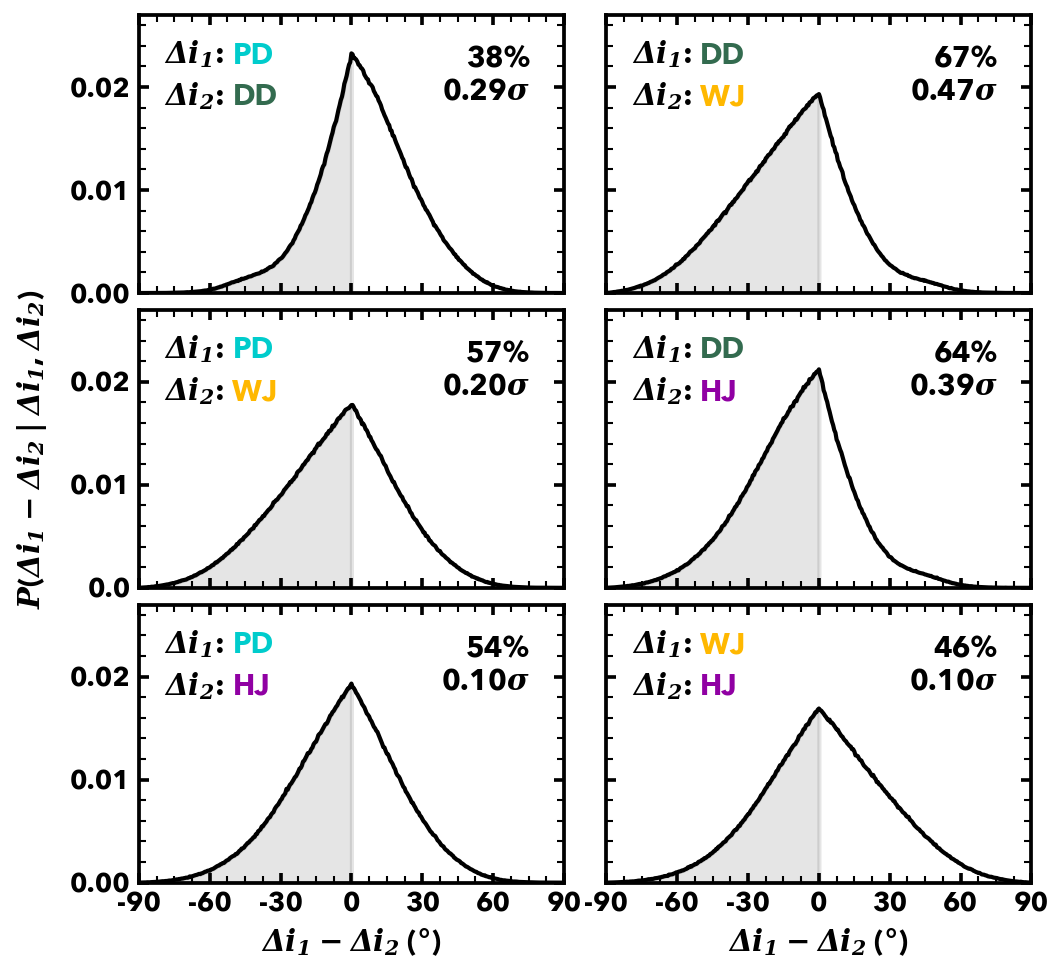

In [393]:
difference_fontsize = 14

fig = plt.figure(figsize=(7, 6.5))
axes = fig.subplot_mosaic(
    """
    ad
    be
    cf
    """,
    gridspec_kw={'height_ratios': [1, 1, 1], 'width_ratios': [1, 1], "bottom": 0.08, "top": 0.97, "left": 0.13, "right": 0.98, "wspace": 0.10, "hspace": 0.060}
)

for axis_i, panel in enumerate(['a', 'b', 'c', 'd', 'e', 'f']):

    Deltai_1 = dataset_pairs[axis_i][0]
    Deltai_2 = dataset_pairs[axis_i][1]

    Color1 = pair_colors[axis_i][0]
    Color2 = pair_colors[axis_i][1]

    difference_bins = difference_data[Deltai_1 + '_' + Deltai_2]['Difference']
    pair_differences = difference_data[Deltai_1 + '_' + Deltai_2]['Nominal']
    pair_differences = pair_differences / (np.sum(pair_differences) * np.diff(difference_bins)[0])

    draw_differences = []
    draw_columns = list(difference_data[Deltai_1 + '_' + Deltai_2].columns)[2:]
    for draw_col in draw_columns:
        draw_distribution = difference_data[Deltai_1 + '_' + Deltai_2][draw_col]
        draw_differences.append(draw_distribution / (np.sum(draw_distribution) * np.diff(difference_bins)[0]))

    axes[panel].minorticks_on()

    # xticks = [-90, -45, 0, 45, 90]
    xticks = [-90, -60, -30, 0, 30, 60, 90]
    yticks = [0.0, 0.01, 0.02]

    xlims = [-90, 90]
    ylims = [0, 0.027]

    # axes[panel].set_title(Deltai_1 + ' - ' + Deltai_2)
    if panel == 'c' or panel == 'f':
        axes[panel].set_xlabel(r'$\Delta i_{1}$ $-$ $\Delta i_{2}$ ($\degree$)', fontsize=difference_fontsize)
        axes[panel].set_xticks(xticks)
        axes[panel].set_xticklabels(xticks, fontsize=difference_fontsize)
    else:
        axes[panel].set_xticks(xticks)
        axes[panel].set_xticklabels([])

    if panel == 'b':
        axes[panel].set_ylabel(r'$P$($\Delta i_{1}$ $-$ $\Delta i_{2}$ $|$ $\Delta i_{1}$, $\Delta i_{2}$)', fontsize=difference_fontsize, labelpad=10)
        axes[panel].set_yticks(yticks)
        axes[panel].set_yticklabels(yticks, fontsize=difference_fontsize)
    if panel == 'd' or panel == 'e' or panel == 'f':
        axes[panel].set_yticks(yticks)
        axes[panel].set_yticklabels([])

    # axes[panel].plot([0, 0], [ylims[0], ylims[1]], color='#000000', lw=1, alpha=0.3, zorder=-100)
    axes[panel].plot(difference_bins, pair_differences, color='#000000', lw=2, zorder=-1)
    axes[panel].fill_between(difference_bins, pair_differences, where=(difference_bins>=-90)&(difference_bins<=0), color='#000000', lw=2, alpha=0.1, zorder=-2)

    # for beps in range(len(draw_differences)):
    #     axes[panel].plot(difference_bins, draw_differences[beps], color='#000000', lw=1, alpha=0.04, zorder=-10)

    y_negative = pair_differences[difference_bins <= 0]
    area_negative = np.trapz(y=y_negative, x=x_negative)
    sig = erfinv(1 - 2 * area_negative) * np.sqrt(2)
    print(sig)

    axes[panel].text(0.06, 0.80, r'$\Delta i_{1}$:', horizontalalignment='left', verticalalignment='bottom', fontsize=difference_fontsize, transform=axes[panel].transAxes)
    axes[panel].text(0.22, 0.80, Deltai_1, horizontalalignment='left', verticalalignment='bottom', fontsize=difference_fontsize, transform=axes[panel].transAxes, color=Color1)
    axes[panel].text(0.06, 0.65, r'$\Delta i_{2}$:', horizontalalignment='left', verticalalignment='bottom', fontsize=difference_fontsize, transform=axes[panel].transAxes)
    axes[panel].text(0.22, 0.65, Deltai_2, horizontalalignment='left', verticalalignment='bottom', fontsize=difference_fontsize, transform=axes[panel].transAxes, color=Color2)

    # axes[panel].text(0.92, 0.75, '{:.2f}'.format(Gaussian_Equivalences[axis_i]) + r'$\sigma$', horizontalalignment='right', verticalalignment='bottom', fontsize=difference_fontsize, transform=axes[panel].transAxes)  # , color=WJ_color)
    # if panel == 'f':
    #     axes[panel].text(0.92, 0.60, '{0}%\n{1:.3f}'.format(int(area_negative*100), Gaussian_Equivalences[axis_i]) + r'$\sigma$', horizontalalignment='right', verticalalignment='bottom', fontsize=difference_fontsize, transform=axes[panel].transAxes)  # , color=WJ_color)
    # else:
    axes[panel].text(0.92, 0.67, '{0}%\n{1:.2f}'.format(int(area_negative*100), Gaussian_Equivalences[axis_i]) + r'$\sigma$', horizontalalignment='right', verticalalignment='bottom', fontsize=difference_fontsize, transform=axes[panel].transAxes)  # , color=WJ_color)
    # axes[panel].text(0.92, 0.60, '{0}%\n{1:.3f}'.format(int(area_negative*100), Gaussian_Equivalences[axis_i]) + r'$\sigma$', horizontalalignment='right', verticalalignment='bottom', fontsize=difference_fontsize, transform=axes[panel].transAxes)  # , color=WJ_color)

    axes[panel].tick_params(which='minor', length=3.25, width=1)
    axes[panel].tick_params(which='major', length=5, width=1.75, labelsize=residual_stacked_plots_label_fontsize+2)

    axes[panel].set_xlim(xlims)
    axes[panel].set_ylim(ylims)

    axes[panel].set_yticks([0, 0.01, 0.02])

# plt.tight_layout()
plt.savefig('/Users/lb8137/PROJECTS/OBLIQUITY_SYNTHESIS/Test_Figures/One-Tail.pdf', dpi=300)
plt.show()

# for pair_i, which_pair in enumerate(dataset_pairs):
#     difference_bins = difference_data[which_pair[0] + '_' + which_pair[1]]['Difference']
#     pair_differences = difference_data[which_pair[0] + '_' + which_pair[1]]['Nominal']

    

In [394]:
dataset_pairs = [['PD','DD'], ['PD','WJ'], ['PD','HJ'], ['DD','WJ'], ['DD','HJ'], ['WJ','HJ']]
pair_colors = [[pd_color,dd_color], [pd_color,WJ_color], [pd_color,HJ_color], [dd_color,WJ_color], [dd_color,HJ_color], [WJ_color,HJ_color]]

Gaussian_Equivalences = []

for pair_i, which_pair in enumerate(dataset_pairs):
    print(which_pair)

    if which_pair[0] == 'PD':
        plot_df1 = df_PD
        kde1 = density_estimation_total_positive_x_PD
        kde1s = PD_kdes
    if which_pair[0] == 'DD':
        plot_df1 = df_DD
        kde1 = density_estimation_total_positive_x_DD
        kde1s = DD_kdes
    if which_pair[0] == 'WJ':
        plot_df1 = df_WJ
        kde1 = density_estimation_total_positive_x_WJ
        kde1s = WJ_kdes
    if which_pair[0] == 'HJ':
        plot_df1 = df_HJ
        kde1 = density_estimation_total_positive_x_HJ
        kde1s = HJ_kdes

    test_scale = 5
    test_loc = 0
    
    if which_pair[1] == 'PD':
        plot_df2 = df_PD
        kde2 = density_estimation_total_positive_x_PD
        kde2s = PD_kdes
    if which_pair[1] == 'DD':
        plot_df2 = df_DD
        kde2 = density_estimation_total_positive_x_DD
        kde2s = DD_kdes
    if which_pair[1] == 'WJ':
        plot_df2 = df_WJ
        kde2 = density_estimation_total_positive_x_WJ
        kde2s = WJ_kdes
    if which_pair[1] == 'HJ':
        plot_df2 = df_HJ
        kde2 = density_estimation_total_positive_x_HJ
        kde2s = HJ_kdes

    n_draws = 100 #  int(5e6)
    rand1 = choices(x_grid_plot, kde1, k=n_draws)
    rand2 = choices(x_grid_plot, kde2, k=n_draws)

    from scipy.stats import mannwhitneyu

    # Perform the Mann-Whitney U test
    # The 'alternative' parameter can be 'two-sided', 'less', or 'greater'
    # 'two-sided' tests if the distributions are different
    # 'less' tests if group1 is stochastically less than group2
    # 'greater' tests if group1 is stochastically greater than group2
    u_statistic, p_value = mannwhitneyu(rand1, rand2, alternative='greater', method='exact')

    # Print the results
    print(f"Mann-Whitney U statistic: {u_statistic:.2f}")
    print(f"P-value: {p_value:.4f}")

    # Interpret the result
    alpha = 0.05
    if p_value < alpha:
        print("Reject the null hypothesis: There is a significant difference between the groups.\n")
    else:
        print("Fail to reject the null hypothesis: There is no significant difference between the groups.\n")

    

['PD', 'DD']
Mann-Whitney U statistic: 6334.50
P-value: 0.0005
Reject the null hypothesis: There is a significant difference between the groups.

['PD', 'WJ']
Mann-Whitney U statistic: 4454.50
P-value: 0.9089
Fail to reject the null hypothesis: There is no significant difference between the groups.

['PD', 'HJ']
Mann-Whitney U statistic: 4394.00
P-value: 0.9307
Fail to reject the null hypothesis: There is no significant difference between the groups.

['DD', 'WJ']
Mann-Whitney U statistic: 3331.00
P-value: 1.0000
Fail to reject the null hypothesis: There is no significant difference between the groups.

['DD', 'HJ']
Mann-Whitney U statistic: 3244.00
P-value: 1.0000
Fail to reject the null hypothesis: There is no significant difference between the groups.

['WJ', 'HJ']
Mann-Whitney U statistic: 5713.50
P-value: 0.0408
Reject the null hypothesis: There is a significant difference between the groups.



In [395]:
do_HBM_plot = False

if do_kde_montecarlo_test == True and do_HBM_plot == True:
    HBM_directory = '/Users/lb8137/PROJECTS/PRIMORDIAL_OBLIQUITY/Backup/HBM/Lauren_epop_analysis_2024-Nov-10/Final_HBM_Files/'


    Delta_i_Rayleigh_logUniformPrior_file = HBM_directory + 'Delta_inclination_rayleigh_log-uniform.h5'
    Delta_i_Rayleigh_gaussianPrior_file = HBM_directory + 'Delta_inclination_rayleigh_gaussian.h5'
    Delta_i_Gaussian_logUniformPrior_file = HBM_directory + 'Delta_inclination_gaussian_log-uniform.h5'
    Delta_i_Gaussian_gaussianPrior_file = HBM_directory + 'Delta_inclination_gaussian_gaussian.h5'
    Delta_i_Truncated_Gaussian_UniformPrior_file = HBM_directory + 'Delta_inclination_truncated_gaussian-uniform.h5'

    R_lU_label = r'Rayleigh (log-U Pr)'
    R_G_label = r'Rayleigh (TG Pr)'
    G_lU_label = r'Gaussian (log-U Pr)'
    G_G_label = r'Gaussian (TG Pr)'
    TG_U_label = r'Truncated Gaussian (U Pr)'

    Delta_i_HBM_files = {R_lU_label: {'File Path': Delta_i_Rayleigh_logUniformPrior_file,
                                    },
                        R_G_label: {'File Path': Delta_i_Rayleigh_gaussianPrior_file,
                                    },
                        G_lU_label: {'File Path': Delta_i_Gaussian_logUniformPrior_file,
                                    },
                        G_G_label: {'File Path': Delta_i_Gaussian_gaussianPrior_file,
                                    },
                        TG_U_label: {'File Path': Delta_i_Truncated_Gaussian_UniformPrior_file,
                                    },
                        }

In [396]:
def list_datasets(hdf5_file):
    def traverse_datasets(hdf_object):
        """Traverse HDF5 structure and print datasets."""
        if isinstance(hdf_object, h5py.Dataset):
            datasets.append(hdf_object.name)

        elif isinstance(hdf_object, h5py.Group):
            for key in hdf_object:
                traverse_datasets(hdf_object[key])

    datasets = []
    with h5py.File(hdf5_file, 'r') as file:
        traverse_datasets(file)
    return datasets

if do_kde_montecarlo_test == True and do_HBM_plot == True:
    all_datasets = list_datasets(Delta_i_Truncated_Gaussian_UniformPrior_file)
    all_datasets

In [397]:
if do_kde_montecarlo_test == True and do_HBM_plot == True:
    with h5py.File(Delta_i_Truncated_Gaussian_UniformPrior_file, 'r') as file:
        data_accepted = file['/mcmc/accepted'][()]
        data_chain = file['/mcmc/chain'][()]
        data_logprob = file['/mcmc/log_prob'][()]
        # data_mcmc = file['/mcmc']

    # import scipy
    # help(data_mcmc)
    # data_mcmc['accepted']
    print(data_accepted.shape)
    print(data_chain.shape)
    print(data_logprob.shape)

    data_accepted = [int(bep) for bep in data_accepted]
    print(sorted(data_accepted))
    print(' ')

In [398]:
if do_kde_montecarlo_test == True and do_HBM_plot == True:
    # np.random.seed(44)
    random_HBM_models = {}
    dival = 0.1
    ivals2 = np.arange(0, 90 + 2*dival, dival)

    # ivals = np.arange(0, 90 + 0.1, 0.1)
    x_model = x_grid_plot / 90.



    for HBM_key in list(Delta_i_HBM_files.keys()):
        print(HBM_key)

        with h5py.File(Delta_i_HBM_files[HBM_key]['File Path'], 'r') as file:
            data_accepted = file['/mcmc/accepted'][()]
            data_chain = file['/mcmc/chain'][()]
            data_logprob = file['/mcmc/log_prob'][()]

        random_choices = choices(np.arange(0, data_chain.shape[0], 1), k=100)

        chosen_chain = 'random'  # 'accepted'  # 'random'
        if chosen_chain == 'accepted':
            which_chains = np.copy(data_accepted)  # np.copy(random_choices)  # np.copy(data_accepted)
        if chosen_chain == 'random':
            which_chains = np.copy(random_choices)
        
        selected_chains = [int(bep) for bep in which_chains]

        random_models = []

        # if 'Rayleigh ' in HBM_key:
        #     print('Data Chain Shape: ', data_chain.shape)
        #     chosen_chains = data_chain[selected_chains, :, 0]
        #     for chain_i in range(len(chosen_chains)):
        #         draw = int(choices(np.arange(0, len(chosen_chains[chain_i]), 1), k=1)[0])
        #         random_draw = chosen_chains[chain_i][draw]
        #         model_profile = x_model/(random_draw**2) * np.exp((-x_model**2)/(2*random_draw**2))
        #         model_profile = model_profile/(sum(model_profile) * np.diff(x_grid_plot)[0])
        #         random_models.append(model_profile)

        # if 'Gaussian ' in HBM_key:
        #     print('Data Chain Shape: ', data_chain.shape)
        #     random_chains_mu = data_chain[selected_chains, :, 0]
        #     random_chains_sigma = data_chain[selected_chains, :, 1]
        #     for chain_j in range(len(random_chains_mu)):
        #         draw = int(choices(np.arange(0, len(chosen_chains[chain_j]), 1), k=1)[0])
        #         random_draw_mu = chosen_chains[chain_j][draw]
        #         random_draw_sigma = chosen_chains[chain_j][draw]
        #         model_profile = norm.pdf(x=x_model, loc=random_draw_mu, scale=random_draw_sigma)
        #         model_profile = model_profile/(sum(model_profile) * np.diff(x_grid_plot)[0])
        #         random_models.append(model_profile)

        if 'Rayleigh ' in HBM_key:
            print('Data Chain Shape: ', data_chain.shape)
            chosen_chains = data_chain[selected_chains, :, 0]
            for chain_i in range(len(chosen_chains)):
                random_draw = np.mean(chosen_chains[chain_i])
                model_profile = x_model/(random_draw**2) * np.exp((-x_model**2)/(2*random_draw**2))
                model_profile = model_profile/(sum(model_profile) * np.diff(x_grid_plot)[0])
                random_models.append(model_profile)

        if 'Gaussian ' in HBM_key and 'Truncated' not in HBM_key:
            print('Data Chain Shape: ', data_chain.shape)
            random_chains_mu = data_chain[selected_chains, :, 0]
            random_chains_sigma = data_chain[selected_chains, :, 1]
            for chain_j in range(len(random_chains_mu)):
                random_draw_mu = np.mean(random_chains_mu[chain_j])
                random_draw_sigma = np.mean(random_chains_sigma[chain_j])
                model_profile = norm.pdf(x=x_model, loc=random_draw_mu, scale=random_draw_sigma)
                model_profile = model_profile/(sum(model_profile) * np.diff(x_grid_plot)[0])
                random_models.append(model_profile)


        if 'Gaussian ' in HBM_key and 'Truncated' in HBM_key:
            print('Data Chain Shape: ', data_chain.shape)
            random_chains_mu = data_chain[selected_chains, :, 0]
            print(random_chains_mu)
            random_chains_sigma = data_chain[selected_chains, :, 1]
            print(random_chains_sigma)
            for chain_j in range(len(random_chains_mu)):
                random_draw_mu = np.mean(random_chains_mu[chain_j])
                random_draw_sigma = np.mean(random_chains_sigma[chain_j])
                lower_bound =( 0 - random_draw_mu ) / random_draw_sigma
                upper_bound = (1 - random_draw_mu ) / random_draw_sigma
                model_profile = truncnorm.pdf(x=x_model, a=lower_bound, b=upper_bound, loc=random_draw_mu, scale=random_draw_sigma)
                model_profile = model_profile/(sum(model_profile) * np.diff(x_grid_plot)[0])
                random_models.append(model_profile)

        
        random_HBM_models[HBM_key] = random_models


In [399]:
if do_kde_montecarlo_test == True and do_HBM_plot == True:
    print(random_HBM_models.keys())

    Rayleigh_lU_025 = np.percentile(random_HBM_models['Rayleigh (log-U Pr)'], 2.5, axis=0)
    Rayleigh_lU_16 = np.percentile(random_HBM_models['Rayleigh (log-U Pr)'], 16, axis=0)
    Rayleigh_lU_50 = np.percentile(random_HBM_models['Rayleigh (log-U Pr)'], 50, axis=0)
    Rayleigh_lU_84 = np.percentile(random_HBM_models['Rayleigh (log-U Pr)'], 84, axis=0)
    Rayleigh_lU_975 = np.percentile(random_HBM_models['Rayleigh (log-U Pr)'], 97.5, axis=0)

    Rayleigh_G_025 = np.percentile(random_HBM_models['Rayleigh (TG Pr)'], 2.5, axis=0)
    Rayleigh_G_16 = np.percentile(random_HBM_models['Rayleigh (TG Pr)'], 16, axis=0)
    Rayleigh_G_50 = np.percentile(random_HBM_models['Rayleigh (TG Pr)'], 50, axis=0)
    Rayleigh_G_84 = np.percentile(random_HBM_models['Rayleigh (TG Pr)'], 84, axis=0)
    Rayleigh_G_975 = np.percentile(random_HBM_models['Rayleigh (TG Pr)'], 97.5, axis=0)

    Gaussian_lU_025 = np.percentile(random_HBM_models['Gaussian (log-U Pr)'], 2.5, axis=0)
    Gaussian_lU_16 = np.percentile(random_HBM_models['Gaussian (log-U Pr)'], 16, axis=0)
    Gaussian_lU_50 = np.percentile(random_HBM_models['Gaussian (log-U Pr)'], 50, axis=0)
    Gaussian_lU_84 = np.percentile(random_HBM_models['Gaussian (log-U Pr)'], 84, axis=0)
    Gaussian_lU_975 = np.percentile(random_HBM_models['Gaussian (log-U Pr)'], 97.5, axis=0)

    Gaussian_G_025 = np.percentile(random_HBM_models['Gaussian (TG Pr)'], 2.5, axis=0)
    Gaussian_G_16 = np.percentile(random_HBM_models['Gaussian (TG Pr)'], 16, axis=0)
    Gaussian_G_50 = np.percentile(random_HBM_models['Gaussian (TG Pr)'], 50, axis=0)
    Gaussian_G_84 = np.percentile(random_HBM_models['Gaussian (TG Pr)'], 84, axis=0)
    Gaussian_G_975 = np.percentile(random_HBM_models['Gaussian (TG Pr)'], 97.5, axis=0)

    Truncated_Gaussian_U_025 = np.percentile(random_HBM_models['Truncated Gaussian (U Pr)'], 2.5, axis=0)
    Truncated_Gaussian_U_16 = np.percentile(random_HBM_models['Truncated Gaussian (U Pr)'], 16, axis=0)
    Truncated_Gaussian_U_50 = np.percentile(random_HBM_models['Truncated Gaussian (U Pr)'], 50, axis=0)
    Truncated_Gaussian_U_84 = np.percentile(random_HBM_models['Truncated Gaussian (U Pr)'], 84, axis=0)
    Truncated_Gaussian_U_975 = np.percentile(random_HBM_models['Truncated Gaussian (U Pr)'], 97.5, axis=0)


    # do_smooth = False
    # if do_smooth == True:

    #     Rayleigh_lU_025 = gaussian_filter1d(Rayleigh_lU_025, sigma_smooth)
    #     Rayleigh_lU_16 = gaussian_filter1d(Rayleigh_lU_16, sigma_smooth)
    #     Rayleigh_lU_50 = gaussian_filter1d(Rayleigh_lU_50, sigma_smooth)
    #     Rayleigh_lU_84 = gaussian_filter1d(Rayleigh_lU_84, sigma_smooth)
    #     Rayleigh_lU_975 = gaussian_filter1d(Rayleigh_lU_975, sigma_smooth)

    #     Rayleigh_G_025 = gaussian_filter1d(Rayleigh_G_025, sigma_smooth)
    #     Rayleigh_G_16 = gaussian_filter1d(Rayleigh_G_16, sigma_smooth)
    #     Rayleigh_G_50 = gaussian_filter1d(Rayleigh_G_50, sigma_smooth)
    #     Rayleigh_G_84 = gaussian_filter1d(Rayleigh_G_84, sigma_smooth)
    #     Rayleigh_G_975 = gaussian_filter1d(Rayleigh_G_975, sigma_smooth)

    #     Gaussian_lU_025 = gaussian_filter1d(Gaussian_lU_025, sigma_smooth)
    #     Gaussian_lU_16 = gaussian_filter1d(Gaussian_lU_16, sigma_smooth)
    #     Gaussian_lU_50 = gaussian_filter1d(Gaussian_lU_50, sigma_smooth)
    #     Gaussian_lU_84 = gaussian_filter1d(Gaussian_lU_84, sigma_smooth)
    #     Gaussian_lU_975 = gaussian_filter1d(Gaussian_lU_975, sigma_smooth)

    #     Gaussian_G_025 = gaussian_filter1d(Gaussian_G_025, sigma_smooth)
    #     Gaussian_G_16 = gaussian_filter1d(Gaussian_G_16, sigma_smooth)
    #     Gaussian_G_50 = gaussian_filter1d(Gaussian_G_50, sigma_smooth)
    #     Gaussian_G_84 = gaussian_filter1d(Gaussian_G_84, sigma_smooth)
    #     Gaussian_G_975 = gaussian_filter1d(Gaussian_G_975, sigma_smooth)

    #     Truncated_Gaussian_U_025 = gaussian_filter1d(Gaussian_G_025, sigma_smooth)
    #     Truncated_Gaussian_U_16 = gaussian_filter1d(Gaussian_G_16, sigma_smooth)
    #     Truncated_Gaussian_U_50 = gaussian_filter1d(Gaussian_G_50, sigma_smooth)
    #     Truncated_Gaussian_U_84 = gaussian_filter1d(Gaussian_G_84, sigma_smooth)
    #     Truncated_Gaussian_U_975 = gaussian_filter1d(Gaussian_G_975, sigma_smooth)

In [180]:
from scipy.stats import norm

def truncated_normal_pdf(x, mu, sigma, a, b):
    """
    Compute the PDF of the truncated normal distribution for an array x.

    Parameters:
    - x: array-like, the input values where the PDF should be evaluated.
    - mu: float, the mean of the original normal distribution.
    - sigma: float, the standard deviation of the original normal distribution.
    - a: float, the lower truncation bound.
    - b: float, the upper truncation bound.

    Returns:
    - pdf_values: array-like, the PDF values corresponding to x.
    """
    # Convert x to a NumPy array for efficient computation
    x = np.array(x, dtype=np.float64)

    # Standardize the bounds and input values
    alpha = (a - mu) / sigma
    beta = (b - mu) / sigma
    z = (x - mu) / sigma

    # Compute the normalization constant
    normalization_constant = norm.cdf(beta) - norm.cdf(alpha)

    # Initialize the PDF values array with zeros
    pdf_values = np.zeros_like(x, dtype=np.float64)

    # Create a mask for values within the truncation bounds
    within_bounds = (x >= a) & (x <= b)

    # Compute the PDF values only for x within [a, b]
    pdf_values[within_bounds] = (
        norm.pdf(z[within_bounds]) / (sigma * normalization_constant)
    )

    return pdf_values , normalization_constant


In [181]:

if do_kde_montecarlo_test == True and do_HBM_plot == True:
    kde_HBM_plots_width = 5.5
    kde_HBM_plots_height = 12.0  # 10.5  # 14.0

    kde_HBM_plots_suptitlepad = 10
    kde_HBM_plots_suptitle_fontsize = 14

    kde_HBM_plots_labelpad = 6
    kde_HBM_plots_label_fontsize = 16

    kde_HBM_plots_text_fontsize = 15

    kde_HBM_plots_titlepad = 6


    do_science_version = True


    HBM_key_b1 = 'log-U Pr'
    HBM_key_b2 = 'TG Pr'
    HBM_key_c1 = 'log-U Pr'
    HBM_key_c2 = 'TG Pr'
    model_linestyle_b1 = ':'
    model_color_b1 = '#004466'
    model_dashes_b1 = (2, 1)  # (0.05, 1.5)
    model_capstyle_b1 = 'butt'
    model_zorder_b1 = 6
    model_linestyle_b2 = '-'
    model_color_b2 = '#6699ff'
    model_dashes_b2 = (2, 0)  # (0.05, 1.5)
    model_capstyle_b2 = 'butt'
    model_zorder_b2 = 5
    model_linestyle_c1 = ':'
    model_color_c1 = '#990099'
    model_dashes_c1 = (2, 1)  # (0.05, 1.5)
    model_capstyle_c1 = 'butt'
    model_zorder_c1 = 4
    model_linestyle_c2 = '-'
    model_color_c2 = '#8c59e4'
    model_dashes_c2 = (2, 0)  # (0.05, 1.5)
    model_capstyle_c2 = 'butt'
    model_zorder_c2 = 3

    model_color_f = '#00665f'  # '#739900'
    kde_color = '#6fdcc1'  # '#6fdcc1'  # '#2eb8b8'

    sample_type_list_nature = ['PD']

    ED_Figure_4a_Source_Data = {}
    ED_Figure_4b_Source_Data = {}
    ED_Figure_4c_Source_Data = {}
    ED_Figure_4d_Source_Data = {}
    ED_Figure_4e_Source_Data = {}
    ED_Figure_4f_Source_Data = {}



    for sample_type in sample_type_list_nature:

        kde_025 = np.array(KDE_sample_type_dict[sample_type]['2.5'])
        kde_16 = np.array(KDE_sample_type_dict[sample_type]['16'])
        kde_50 = np.array(KDE_sample_type_dict[sample_type]['50'])
        kde_84 = np.array(KDE_sample_type_dict[sample_type]['84'])
        kde_975 = np.array(KDE_sample_type_dict[sample_type]['97.5'])

        fig = plt.figure(figsize=(kde_HBM_plots_width, kde_HBM_plots_height), dpi=150)
        axes = fig.subplot_mosaic(
            """
            aa
            ff
            bd
            ce
            """,
            gridspec_kw={'height_ratios': [0.6, 0.6, 0.4, 0.4], 'width_ratios': [0.5, 0.5], "bottom": 0.06, "top": 0.95, "left": 0.1775, "right": 0.972, "wspace": 0.025, "hspace": 0.35}
        )

        axes['a'].set_ylabel(r'$P(\Delta i$ | $d$)', fontsize=kde_HBM_plots_label_fontsize, labelpad=kde_HBM_plots_labelpad)
        axes['f'].set_ylabel(r'$P(\Delta i$ | $d$)', fontsize=kde_HBM_plots_label_fontsize, labelpad=kde_HBM_plots_labelpad)
        axes['b'].set_ylabel(r'$P(\Delta i$ | $d$)', fontsize=kde_HBM_plots_label_fontsize, labelpad=kde_HBM_plots_labelpad)
        axes['c'].set_ylabel(r'$P(\Delta i$ | $d$)', fontsize=kde_HBM_plots_label_fontsize, labelpad=kde_HBM_plots_labelpad)

        if do_science_version == True:
            axes['a'].set_title(r'KDE Reconstruction of $\Delta i$', fontsize=kde_HBM_plots_label_fontsize, pad=kde_HBM_plots_titlepad*0.75)
            axes['f'].set_title('Truncated Gaussian Distribution', fontsize=kde_HBM_plots_label_fontsize, pad=kde_HBM_plots_titlepad*0.75)
        axes['b'].set_title('Rayleigh Distribution', fontsize=kde_HBM_plots_label_fontsize, pad=kde_HBM_plots_titlepad, x=1.0)
        axes['c'].set_title('Gaussian Distribution', fontsize=kde_HBM_plots_label_fontsize, pad=kde_HBM_plots_titlepad, x=1.0)

        axes['c'].set_xlabel(r'$\Delta i$ ($\degree$)', fontsize=kde_HBM_plots_label_fontsize, labelpad=kde_HBM_plots_labelpad)
        axes['e'].set_xlabel(r'$\Delta i$ ($\degree$)', fontsize=kde_HBM_plots_label_fontsize, labelpad=kde_HBM_plots_labelpad)

        draw_alpha = 0.10
        draw_lw = 2

        axes['a'].plot(x_grid_plot, density_estimation_total_positive_x_PD, ls=':', dashes=(1, 1), color='#000000', lw=3, alpha=0.5, label='Nominal KDE', zorder=-3)

        do_fill_between_KDE = False
        if do_fill_between_KDE == True:
            axes['a'].fill_between(x_grid_plot, kde_975_plot[sample_type], kde_025_plot[sample_type], lw=0, color=kde_color, alpha=0.3, zorder=-6)
            axes['a'].fill_between(x_grid_plot, kde_84_plot[sample_type], kde_16_plot[sample_type], lw=0, color=kde_color, alpha=1, zorder=-5)
            # axes['f'].fill_between(x_grid_plot, kde_975_plot[sample_type], kde_025_plot[sample_type], lw=0, color=model_color_f, alpha=0.3, zorder=-6)
            # axes['f'].fill_between(x_grid_plot, kde_84_plot[sample_type], kde_16_plot[sample_type], lw=0, color=model_color_f, alpha=1, zorder=-5)
        else:
            for kde_i, kde_i_plot in enumerate(kdes_plot[sample_type]):
                axes['a'].plot(x_grid_plot, kde_i_plot, lw=draw_lw, linestyle='-', color=kde_color, alpha=draw_alpha, zorder=-5)
                # axes['f'].plot(x_grid_plot, kde_i_plot, lw=draw_lw, linestyle='-', color=model_color_f, alpha=draw_alpha, zorder=-5)

                ED_Figure_4a_Source_Data['Deltai (deg)'] = x_grid_plot
                ED_Figure_4a_Source_Data['KDE ' + str(kde_i)] = kde_i_plot


        do_fill_between_HBM = False
        if do_fill_between_HBM == True:
            axes['b'].fill_between(x_grid_plot, Rayleigh_lU_975, Rayleigh_lU_025, lw=0, color=model_color_b1, alpha=0.3, zorder=-6)
            axes['b'].fill_between(x_grid_plot, Rayleigh_lU_84, Rayleigh_lU_16, lw=0, color=model_color_b1, alpha=1, zorder=-5)

            axes['d'].fill_between(x_grid_plot, Rayleigh_G_975, Rayleigh_G_025, lw=0, color=model_color_b2, alpha=0.3, zorder=-6)
            axes['d'].fill_between(x_grid_plot, Rayleigh_G_84, Rayleigh_G_16, lw=0, color=model_color_b2, alpha=1, zorder=-5)

            axes['c'].fill_between(x_grid_plot, Gaussian_lU_975, Gaussian_lU_025, lw=0, color=model_color_c1, alpha=0.3, zorder=-6)
            axes['c'].fill_between(x_grid_plot, Gaussian_lU_84, Gaussian_lU_16, lw=0, color=model_color_c1, alpha=1, zorder=-5)

            axes['e'].fill_between(x_grid_plot, Gaussian_G_975, Gaussian_G_025, lw=0, color=model_color_c2, alpha=0.3, zorder=-6)
            axes['e'].fill_between(x_grid_plot, Gaussian_G_84, Gaussian_G_16, lw=0, color=model_color_c2, alpha=1, zorder=-5)

            axes['b'].text(0.89, 0.85, 'log-U Pr', horizontalalignment='right', verticalalignment='center', fontsize=kde_HBM_plots_text_fontsize, transform=axes['b'].transAxes)
            axes['d'].text(0.89, 0.85, 'TG Pr', horizontalalignment='right', verticalalignment='center', fontsize=kde_HBM_plots_text_fontsize, transform=axes['d'].transAxes)
            axes['c'].text(0.89, 0.85, 'log-U Pr', horizontalalignment='right', verticalalignment='center', fontsize=kde_HBM_plots_text_fontsize, transform=axes['c'].transAxes)  
            axes['e'].text(0.89, 0.85, 'TG Pr', horizontalalignment='right', verticalalignment='center', fontsize=kde_HBM_plots_text_fontsize, transform=axes['e'].transAxes)   
        else:
            for draw_i in range(len(random_HBM_models['Rayleigh (log-U Pr)'])):
                axes['f'].plot(x_grid_plot, random_HBM_models['Truncated Gaussian (U Pr)'][draw_i], lw=draw_lw*0.75, linestyle='-', color=model_color_f, alpha=draw_alpha, zorder=-6)
                if draw_i == 0:
                    print(random_HBM_models['Truncated Gaussian (U Pr)'][draw_i])
                axes['b'].plot(x_grid_plot, random_HBM_models['Rayleigh (log-U Pr)'][draw_i], lw=draw_lw*0.75, linestyle='-', color=model_color_b1, alpha=draw_alpha, zorder=-5)
                axes['d'].plot(x_grid_plot, random_HBM_models['Rayleigh (TG Pr)'][draw_i], lw=draw_lw*0.75, linestyle='-', color=model_color_b2, alpha=draw_alpha, zorder=-6)
                axes['c'].plot(x_grid_plot, random_HBM_models['Gaussian (log-U Pr)'][draw_i], lw=draw_lw*0.75, linestyle='-', color=model_color_c1, alpha=draw_alpha, zorder=-5)
                axes['e'].plot(x_grid_plot, random_HBM_models['Gaussian (TG Pr)'][draw_i], lw=draw_lw*0.75, linestyle='-', color=model_color_c2, alpha=draw_alpha, zorder=-6)

                ED_Figure_4b_Source_Data['Deltai (deg)'] = x_grid_plot
                ED_Figure_4b_Source_Data['b HBM ' + str(draw_i)] = random_HBM_models['Truncated Gaussian (U Pr)'][draw_i]
                ED_Figure_4c_Source_Data['Deltai (deg)'] = x_grid_plot
                ED_Figure_4c_Source_Data['c HBM ' + str(draw_i)] = random_HBM_models['Rayleigh (log-U Pr)'][draw_i]
                ED_Figure_4d_Source_Data['Deltai (deg)'] = x_grid_plot
                ED_Figure_4d_Source_Data['d HBM ' + str(draw_i)] = random_HBM_models['Rayleigh (TG Pr)'][draw_i]
                ED_Figure_4e_Source_Data['Deltai (deg)'] = x_grid_plot
                ED_Figure_4e_Source_Data['e HBM ' + str(draw_i)] = random_HBM_models['Gaussian (log-U Pr)'][draw_i]
                ED_Figure_4f_Source_Data['Deltai (deg)'] = x_grid_plot
                ED_Figure_4f_Source_Data['f HBM ' + str(draw_i)] = random_HBM_models['Gaussian (TG Pr)'][draw_i]


        if do_science_version == False:
            axes['a'].text(0.50, 0.90, r'KDE Reconstruction of $\Delta i$', horizontalalignment='center', verticalalignment='center', fontsize=kde_HBM_plots_text_fontsize, transform=axes['a'].transAxes)
            axes['f'].text(0.50, 0.90, 'Truncated Gaussian Distribution', horizontalalignment='center', verticalalignment='center', fontsize=kde_HBM_plots_text_fontsize, transform=axes['f'].transAxes)
            axes['b'].text(0.89, 0.85, 'log-U Pr', horizontalalignment='right', verticalalignment='center', fontsize=kde_HBM_plots_text_fontsize, transform=axes['b'].transAxes)
            axes['d'].text(0.89, 0.85, 'TG Pr', horizontalalignment='right', verticalalignment='center', fontsize=kde_HBM_plots_text_fontsize, transform=axes['d'].transAxes)
            axes['c'].text(0.89, 0.85, 'log-U Pr', horizontalalignment='right', verticalalignment='center', fontsize=kde_HBM_plots_text_fontsize, transform=axes['c'].transAxes)  
            axes['e'].text(0.89, 0.85, 'TG Pr', horizontalalignment='right', verticalalignment='center', fontsize=kde_HBM_plots_text_fontsize, transform=axes['e'].transAxes) 
        if do_science_version == True:
            axes['a'].text(0.89, 0.85, 'a', horizontalalignment='center', verticalalignment='center', fontsize=kde_HBM_plots_text_fontsize*1.25, transform=axes['a'].transAxes)
            axes['f'].text(0.89, 0.85, 'b', horizontalalignment='center', verticalalignment='center', fontsize=kde_HBM_plots_text_fontsize*1.25, transform=axes['f'].transAxes) 
            axes['b'].text(0.89, 0.85, 'c', horizontalalignment='right', verticalalignment='center', fontsize=kde_HBM_plots_text_fontsize*1.25, transform=axes['b'].transAxes)
            axes['d'].text(0.89, 0.85, 'd', horizontalalignment='right', verticalalignment='center', fontsize=kde_HBM_plots_text_fontsize*1.25, transform=axes['d'].transAxes)
            axes['c'].text(0.89, 0.85, 'e', horizontalalignment='right', verticalalignment='center', fontsize=kde_HBM_plots_text_fontsize*1.25, transform=axes['c'].transAxes)  
            axes['e'].text(0.89, 0.85, 'f', horizontalalignment='right', verticalalignment='center', fontsize=kde_HBM_plots_text_fontsize*1.25, transform=axes['e'].transAxes) 









        xmin, xmax = 0, 90

        for ax in axes.keys():
            axes[ax].minorticks_on()
            # axes[ax].set_rasterized(True)

            for spine in axes[ax].spines.values():
                spine.set_linewidth(2.5)

            # SPECIFY THE X TICKS
            if ax in ['a', 'f']:
                xticks = [0, 15, 30, 45, 60, 75, 90]
            elif ax in ['b', 'c']:
                xticks = [0, 20, 40, 60, 80]
            else:
                xticks = [20, 40, 60, 80]
            xticklabels = [str(int(xtick)) for xtick in xticks]
            axes[ax].set_xticks(xticks)
            axes[ax].set_xticklabels(xticklabels)

            if ax in ['a']:
                yticks = [0.0, 0.01, 0.02, 0.03, 0.04]
            elif ax in ['f']:
                yticks = [0.0, 0.03, 0.06, 0.09]
            elif ax in ['b', 'd']:
                yticks = [0.0, 0.01, 0.02, 0.03, 0.04, 0.05]
            else:
                yticks = [0.0, 0.03, 0.06, 0.09]
            axes[ax].set_yticks(yticks)
            yticklabels = ['{:.2f}'.format(ytick) for ytick in yticks]

            if ax in ['a', 'f', 'b', 'c']:
            # if ax in ['a', 'b', 'c']:
                axes[ax].set_yticklabels(yticklabels)
            else:
                axes[ax].set_yticklabels([])

            axes[ax].set_xlim(xmin, xmax)
            if ax in ['a']:
                axes[ax].set_ylim(0, 0.04)
            elif ax in ['f']:
                axes[ax].set_ylim(0, 0.09)
            elif ax in ['b', 'd']:
                axes[ax].set_ylim(0, 0.055)
            else:
                axes[ax].set_ylim(0, 0.10)

            axes[ax].tick_params(which='minor', length=4, width=1.5, labelsize=kde_HBM_plots_label_fontsize)
            axes[ax].tick_params(which='major', length=7, width=2.5, labelsize=kde_HBM_plots_label_fontsize)

        minor_locator_a = AutoMinorLocator(3)
        axes['a'].xaxis.set_minor_locator(minor_locator_a)
        # axes['f'].xaxis.set_minor_locator(minor_locator_a)

        minor_locator_b = AutoMinorLocator(4)
        axes['b'].xaxis.set_minor_locator(minor_locator_b)
        axes['d'].xaxis.set_minor_locator(minor_locator_b)
        axes['c'].xaxis.set_minor_locator(minor_locator_b)
        axes['e'].xaxis.set_minor_locator(minor_locator_b)

        date_str = '2024-Dec-03'

        # SAVE THE FIGURE
        save_par_vs_stacked_kde = 'Stacked_KDE_HBM_grid_' + light_or_dark_dext + '_' + transparent_text + '_' + date_str + '.pdf'
        # save_par_vs_stacked_kde = 'Stacked_KDE_HBM_grid_' + light_or_dark_dext + '_' + transparent_text + '_' + date_str + '.eps'

        if plot_transparent == True:
            fig.savefig(test_figures_directory + save_par_vs_stacked_kde, dpi=300, transparent=True)
        else:
            fig.savefig(test_figures_directory + save_par_vs_stacked_kde, dpi=300, transparent=False)

        print('Figure is saved in the following directory:')
        print(test_figures_directory + save_par_vs_stacked_kde)

        # ED_Figure_4a_Source_Data_df = pd.DataFrame(ED_Figure_4a_Source_Data)
        # ED_Figure_4a_Source_Data_df.to_csv('/Users/lb8137/PROJECTS/PRIMORDIAL_OBLIQUITY/Backup/Nature/Submission_3/Source_Data/Extended_Data_Figure_4a.csv', index=False)
        # ED_Figure_4b_Source_Data_df = pd.DataFrame(ED_Figure_4b_Source_Data)
        # ED_Figure_4b_Source_Data_df.to_csv('/Users/lb8137/PROJECTS/PRIMORDIAL_OBLIQUITY/Backup/Nature/Submission_3/Source_Data/Extended_Data_Figure_4b.csv', index=False)
        # ED_Figure_4c_Source_Data_df = pd.DataFrame(ED_Figure_4c_Source_Data)
        # ED_Figure_4c_Source_Data_df.to_csv('/Users/lb8137/PROJECTS/PRIMORDIAL_OBLIQUITY/Backup/Nature/Submission_3/Source_Data/Extended_Data_Figure_4c.csv', index=False)
        # ED_Figure_4d_Source_Data_df = pd.DataFrame(ED_Figure_4d_Source_Data)
        # ED_Figure_4d_Source_Data_df.to_csv('/Users/lb8137/PROJECTS/PRIMORDIAL_OBLIQUITY/Backup/Nature/Submission_3/Source_Data/Extended_Data_Figure_4d.csv', index=False)
        # ED_Figure_4e_Source_Data_df = pd.DataFrame(ED_Figure_4e_Source_Data)
        # ED_Figure_4e_Source_Data_df.to_csv('/Users/lb8137/PROJECTS/PRIMORDIAL_OBLIQUITY/Backup/Nature/Submission_3/Source_Data/Extended_Data_Figure_4e.csv', index=False)
        # ED_Figure_4f_Source_Data_df = pd.DataFrame(ED_Figure_4f_Source_Data)
        # ED_Figure_4f_Source_Data_df.to_csv('/Users/lb8137/PROJECTS/PRIMORDIAL_OBLIQUITY/Backup/Nature/Submission_3/Source_Data/Extended_Data_Figure_4f.csv', index=False)



# Distributions Mosaic

23


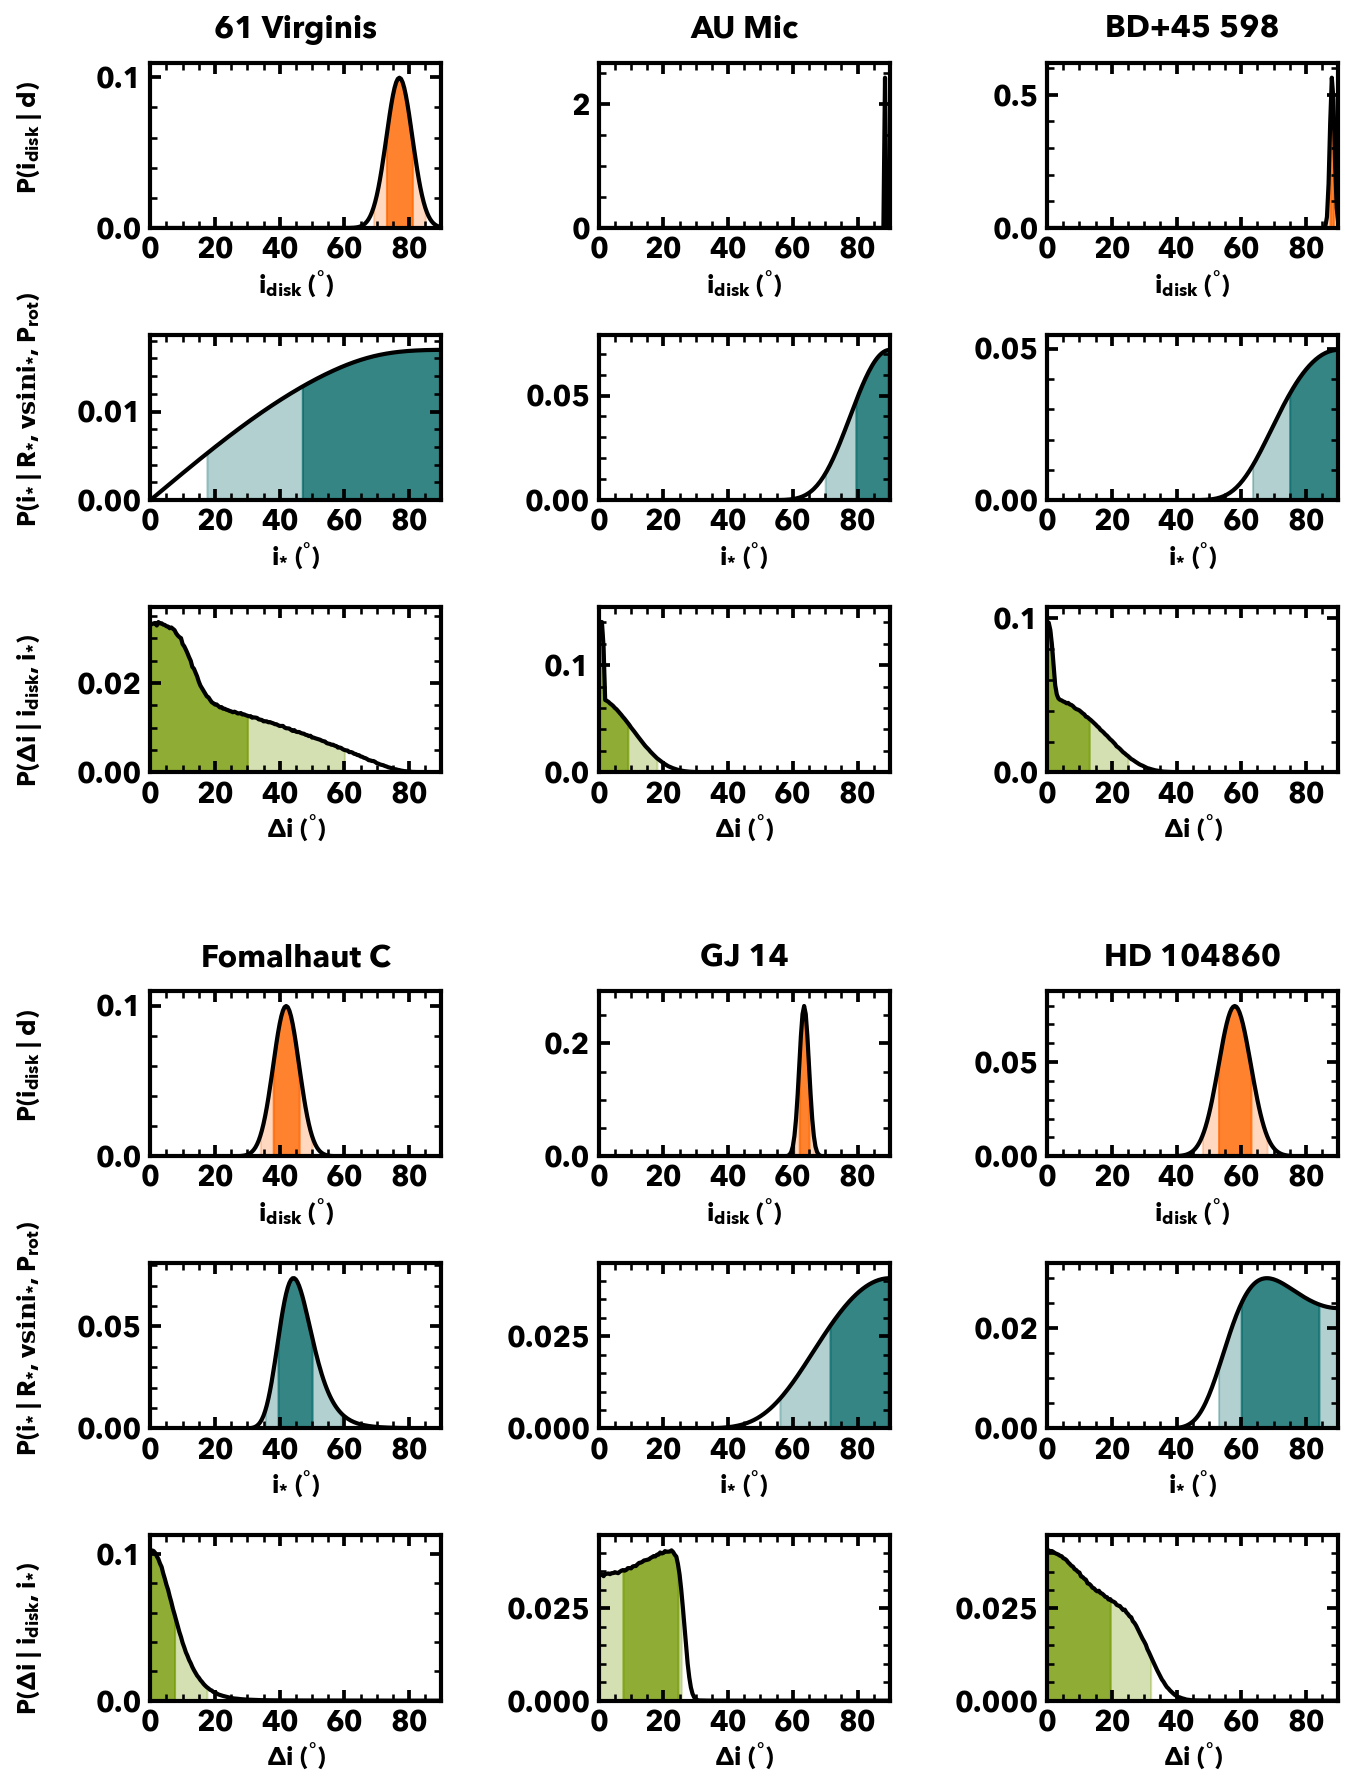

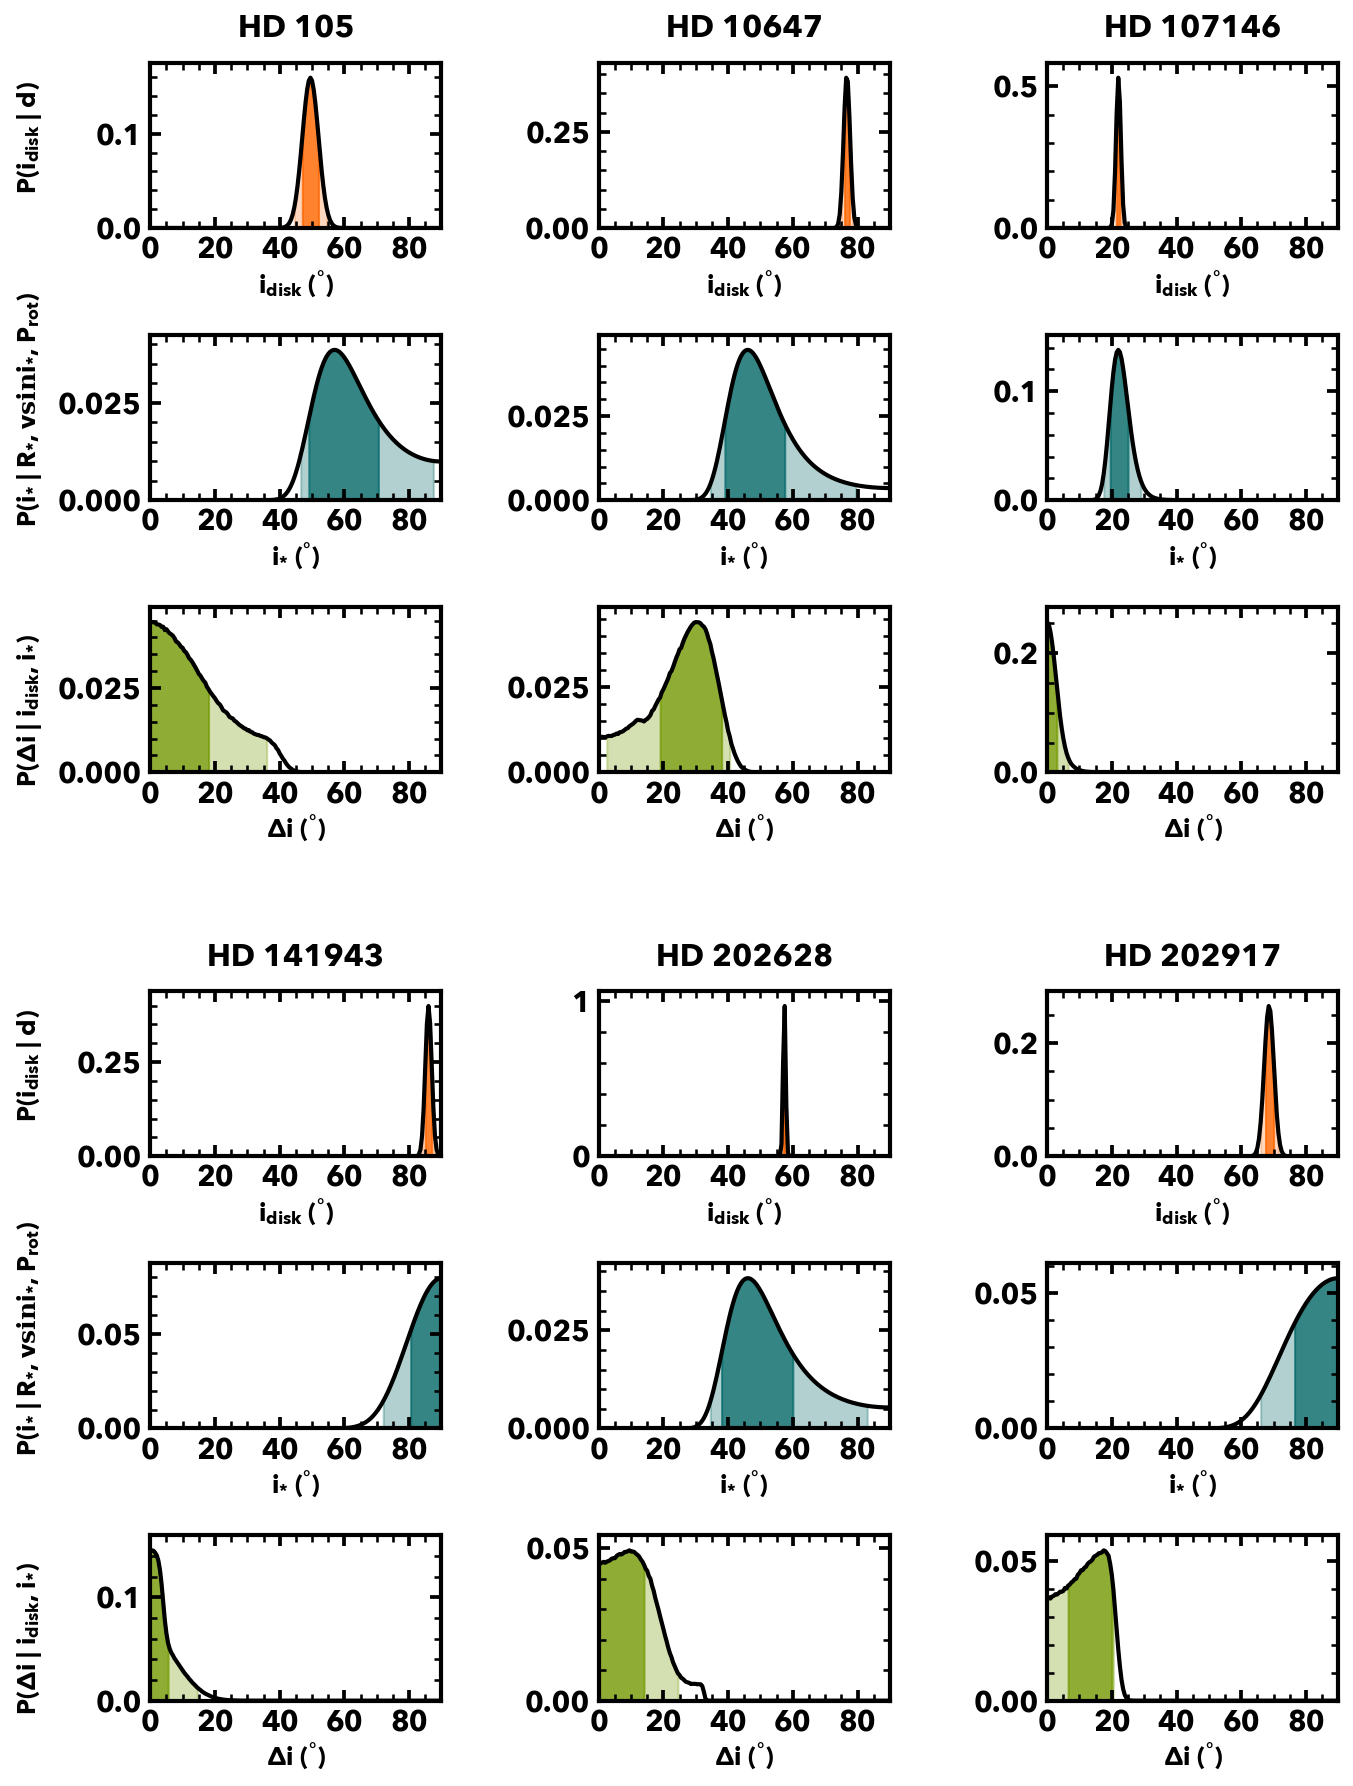

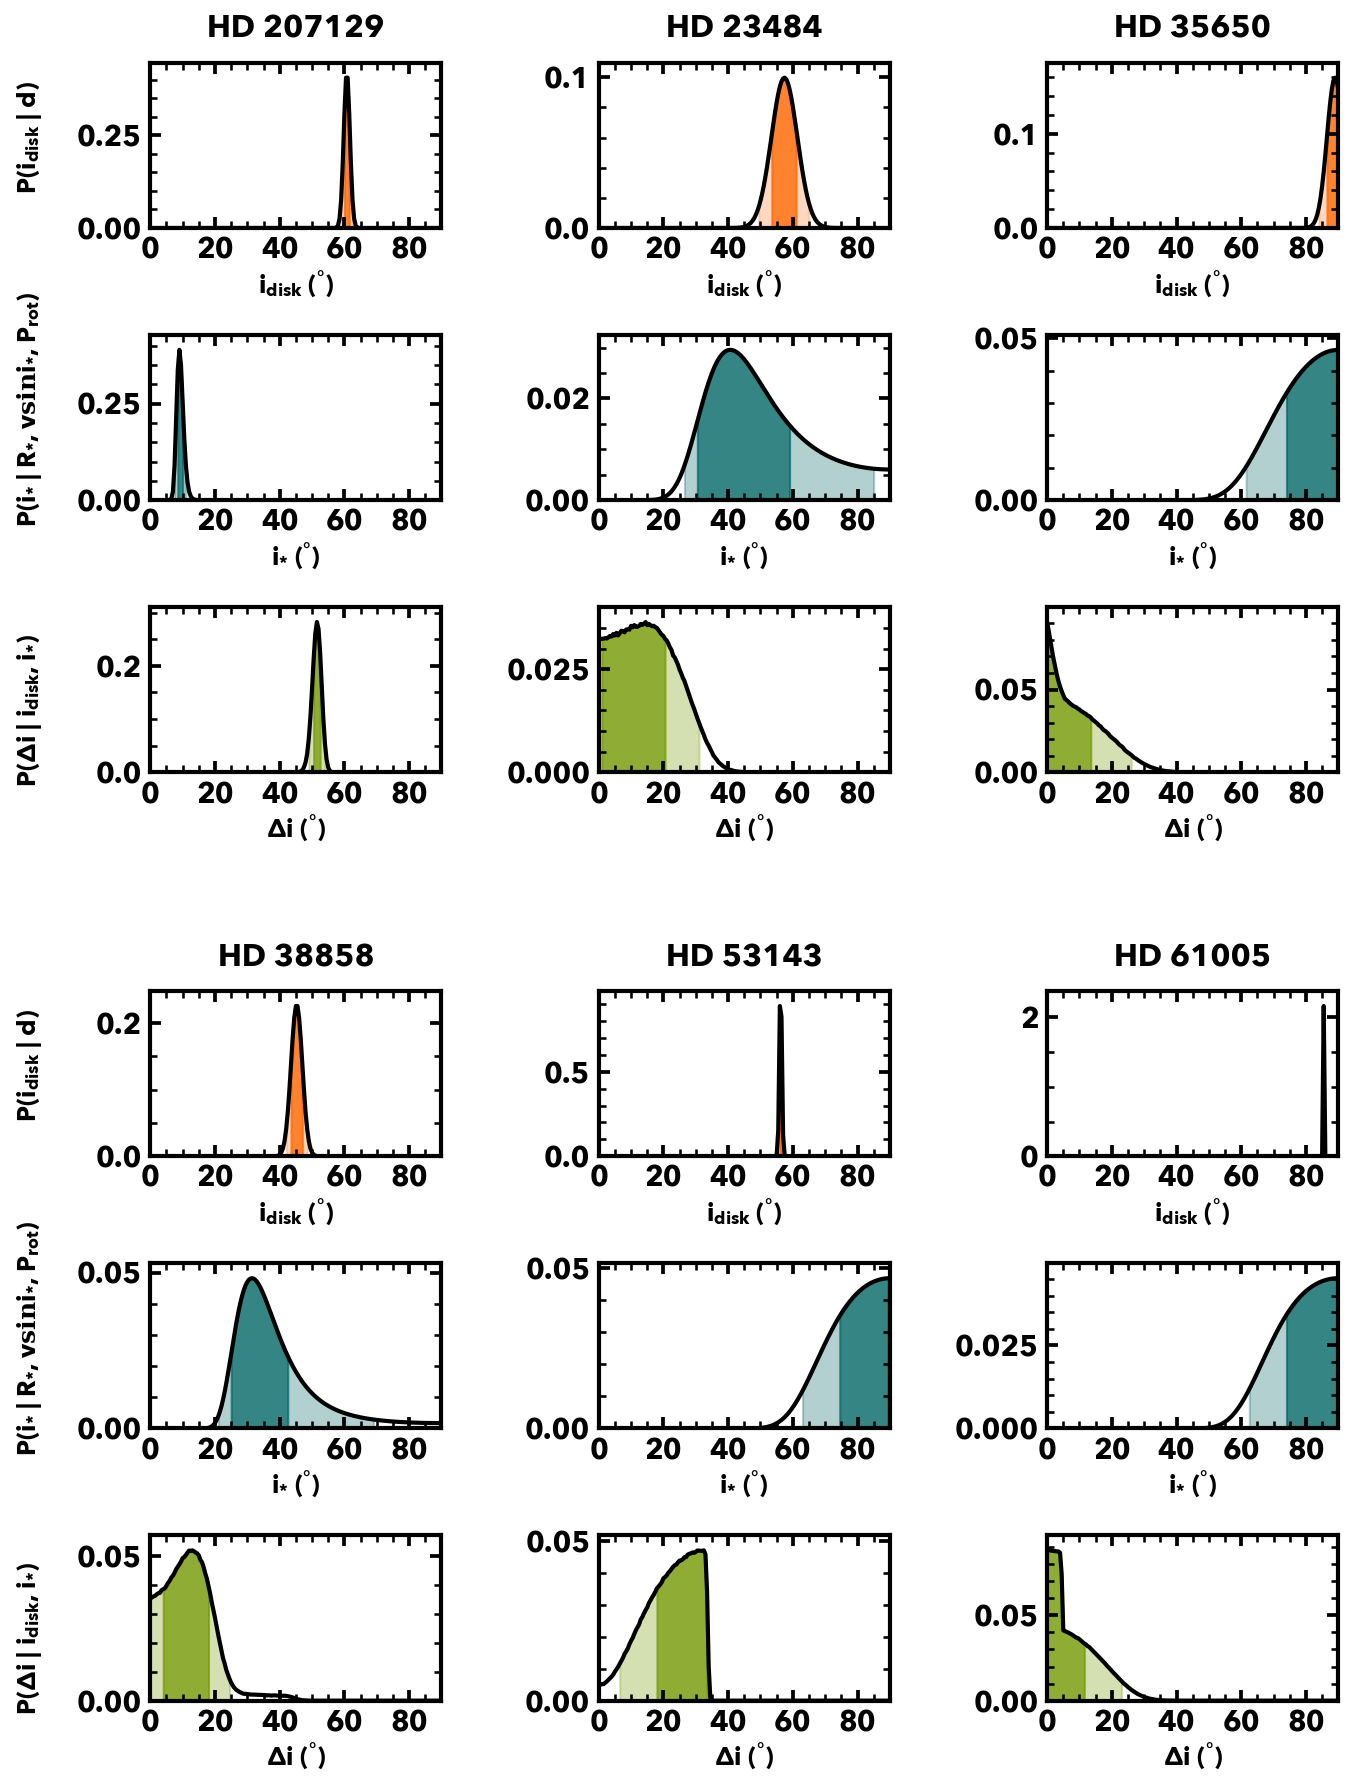

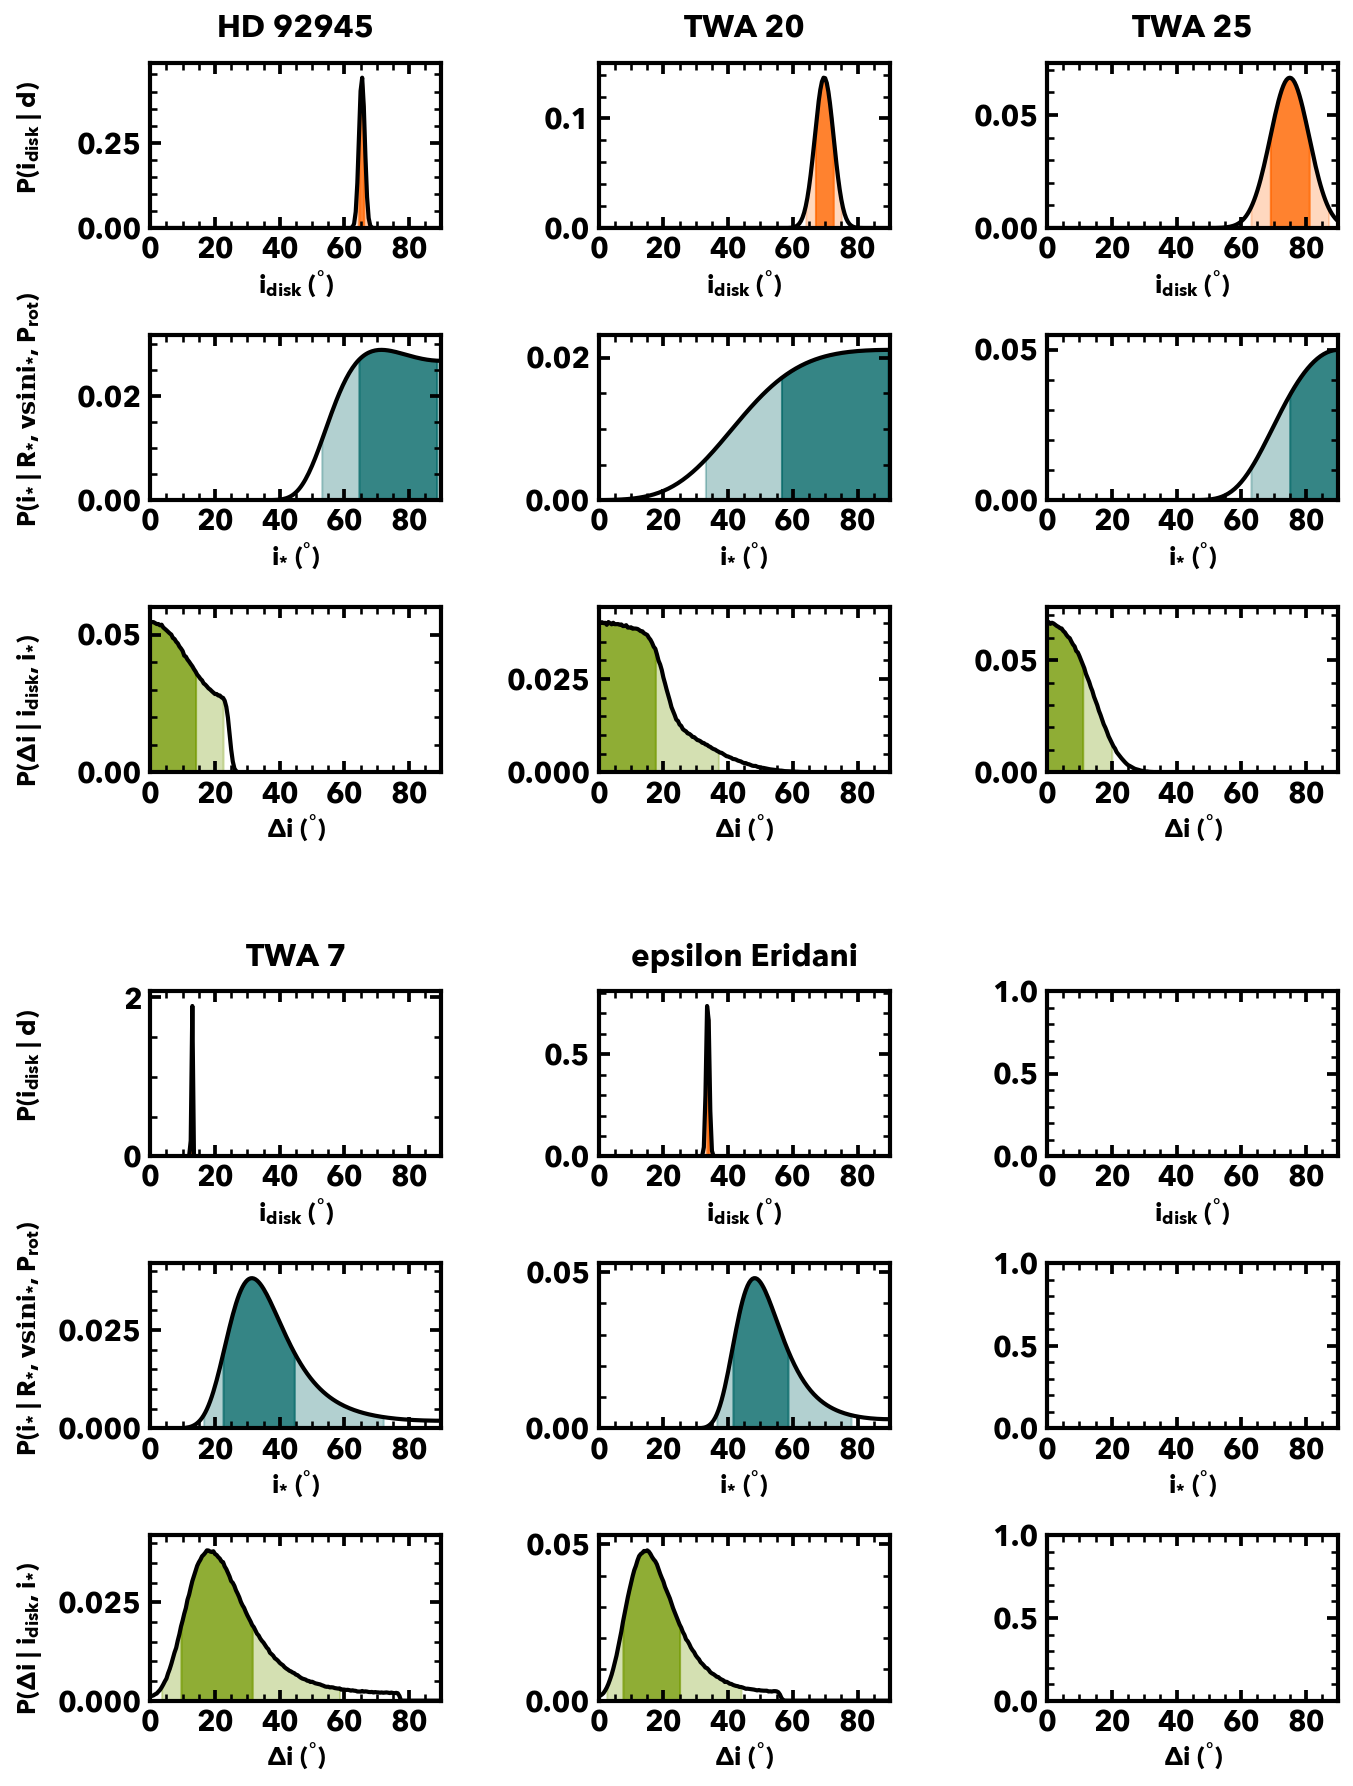

In [182]:

do_distributions_mosaic = True

# ----------------------------------------------
title_fontsize = 15 
label_fontsize = 12
tick_fontsize = 11
targetlabel_fontsize = 12

title_weight = 'semibold'

title_pad = 12  # 4
label_pad = 1.5  # 4

mosaic_datasets = ['DD']

if do_distributions_mosaic == True:

    for which_dataset in mosaic_datasets:


        if which_dataset == 'PD':
            plot_df = df_PD
            which_list = 'PD'
            ccombonum = 1
        if which_dataset == 'DD':
            plot_df = df_DD
            which_list = 'DD'
            ccombonum = 2
        if which_dataset == 'WJ':
            plot_df = df_WJ
            which_list = 'WJ'
            ccombonum = 3
        if which_dataset == 'HJ':
            plot_df = df_HJ
            which_list = 'HJ'
            ccombonum = 4

        if ccombonum == 1:
            ccombo = ['#008fc7', '#6a3dff', '#9000a3'] 
        elif ccombonum == 2:
            ccombo = ['#ff6600', '#006666', '#739900']
        elif ccombonum == 3:
            ccombo = ['#004080', '#351fff', '#7800cc'] 
        elif ccombonum == 4:
            ccombo = ['#0000cc', '#00cc90', '#808080'] 
        i_disk_fill_color = ccombo[0]
        i_star_fill_color = ccombo[1]
        Delta_i_fill_color = ccombo[2]


        setnum = 0


        frame_numbers_on = False


        sig1_widths = []

        misaligned10_90percent_confidence = []
        misaligned10_80percent_confidence = []

        misaligned20_90percent_confidence = []
        misaligned20_80percent_confidence = []


        fig_height = 12
        fig_width = 9.0

        distribution_linewidths = 2

        target_list = plot_df['Target'].values
        print(len(target_list))

        target_sets = []
        set_len = 6
        trgt_i = 0
        while trgt_i < len(target_list):
            if trgt_i + set_len < len(target_list):
                target_set = target_list[trgt_i:trgt_i + set_len]
            else:
                target_set = target_list[trgt_i::]
            target_sets.append(target_set)
            trgt_i += 6

        # print(target_sets)

        set_col_axes = [['a', 'b', 'c'], ['d', 'e', 'f'], ['g', 'h', 'i'],
                        ['j', 'k', 'l'], ['m', 'n', 'o'], ['p', 'q', 'r']]

        for targ_set_i in range(len(target_sets)):
        # for targ_set_i in range(1):

            targ_set = target_sets[targ_set_i]

            targ_titles = []
            for set_element in targ_set:
                if '(' in set_element:
                    set_element = set_element.split('(')[0]
                if '2MASS' in set_element:
                    if '+' in set_element[5:]:
                        split1 = set_element[5:].split('+')[0].replace(' ', '')[0:5]
                        split2 = '+' + set_element[5:].split('+')[1].replace(' ', '')[0:4]
                    if '-' in set_element[5:]:
                        split1 = set_element[5:].split('-')[0].replace(' ', '')[0:5]
                        split2 = '-' + set_element[5:].split('-')[1].replace(' ', '')[0:4]
                    targ_titles.append('2M ' + split1 + split2)
                else:
                    targ_titles.append(set_element)

            fig = plt.figure(figsize=(fig_width, fig_height), dpi=150)
            axes = fig.subplot_mosaic(
                """
                adg
                beh
                cfi
                ...
                jmp
                knq
                lor
                """,
                gridspec_kw={'height_ratios': [1, 1, 1, 0.03, 1, 1, 1], 'width_ratios': [1, 1, 1], "bottom": 0.05, "top": 0.96, "left": 0.11, "right": 0.99, "wspace": 0.54, "hspace": 0.75,}
            )

            # blank_axes = []
            for ax in axes.keys():
                # if len(targ_set) == 5:
                #     blank_axes = ['p', 'q', 'r']
                # if len(targ_set) == 4:
                #     blank_axes = ['p', 'q', 'r', 'm', 'n', 'o']
                # if len(targ_set) == 2:
                #     blank_axes = ['p', 'q', 'r', 'm', 'n', 'o', 'j', 'k', 'l', 'g', 'h', 'i']
                # if len(targ_set) == 1:
                #     blank_axes = ['p', 'q', 'r', 'm', 'n', 'o', 'j', 'k', 'l', 'g', 'h', 'i', 'd', 'e', 'f']
                    
                # if ax not in blank_axes:
                axes[ax].minorticks_on()
                axes[ax].set_rasterized(True)

                for spine in axes[ax].spines.values():
                    spine.set_linewidth(2.0)

                # SPECIFY THE X TICKS
                xticks = [0, 20, 40, 60, 80]
                xticklabels = [str(int(xtick)) for xtick in xticks]
                axes[ax].set_xticks(xticks)
                axes[ax].set_xticklabels(xticklabels)
                axes[ax].set_xlim(0, 90)

            axes['a'].set_ylabel(r'$P(i_{disk}$ | $d$)', fontsize=label_fontsize, labelpad=label_pad)
            axes['b'].set_ylabel(r'$P(i_{*}$ | $R_{*}, v\mathrm{sin}i_{*}, P_{rot}$)', fontsize=label_fontsize, labelpad=label_pad)
            axes['c'].set_ylabel(r'$P(\Delta i$ | $i_{disk}, i_{*}$)', fontsize=label_fontsize, labelpad=label_pad)
            axes['j'].set_ylabel(r'$P(i_{disk}$ | $d$)', fontsize=label_fontsize, labelpad=label_pad)
            axes['k'].set_ylabel(r'$P(i_{*}$ | $R_{*}, v\mathrm{sin}i_{*}, P_{rot}$)', fontsize=label_fontsize, labelpad=label_pad)
            axes['l'].set_ylabel(r'$P(\Delta i$ | $i_{disk}, i_{*}$)', fontsize=label_fontsize, labelpad=label_pad)

            axes['a'].yaxis.set_label_coords(-0.365, 0.55)
            axes['b'].yaxis.set_label_coords(-0.365, 0.55)
            axes['c'].yaxis.set_label_coords(-0.365, 0.38)
            axes['j'].yaxis.set_label_coords(-0.365, 0.55)
            axes['k'].yaxis.set_label_coords(-0.365, 0.55)
            axes['l'].yaxis.set_label_coords(-0.365, 0.38)

            axes['a'].set_xlabel(r'$i_{disk}$ ($^\degree$)', fontsize=label_fontsize, labelpad=label_pad)
            axes['d'].set_xlabel(r'$i_{disk}$ ($^\degree$)', fontsize=label_fontsize, labelpad=label_pad)
            axes['g'].set_xlabel(r'$i_{disk}$ ($^\degree$)', fontsize=label_fontsize, labelpad=label_pad)
            axes['j'].set_xlabel(r'$i_{disk}$ ($^\degree$)', fontsize=label_fontsize, labelpad=label_pad)
            axes['m'].set_xlabel(r'$i_{disk}$ ($^\degree$)', fontsize=label_fontsize, labelpad=label_pad)
            axes['p'].set_xlabel(r'$i_{disk}$ ($^\degree$)', fontsize=label_fontsize, labelpad=label_pad)

            axes['b'].set_xlabel(r'$i_{*}$ ($^\degree$)', fontsize=label_fontsize, labelpad=label_pad)
            axes['e'].set_xlabel(r'$i_{*}$ ($^\degree$)', fontsize=label_fontsize, labelpad=label_pad)
            axes['h'].set_xlabel(r'$i_{*}$ ($^\degree$)', fontsize=label_fontsize, labelpad=label_pad)
            axes['k'].set_xlabel(r'$i_{*}$ ($^\degree$)', fontsize=label_fontsize, labelpad=label_pad)
            axes['n'].set_xlabel(r'$i_{*}$ ($^\degree$)', fontsize=label_fontsize, labelpad=label_pad)
            axes['q'].set_xlabel(r'$i_{*}$ ($^\degree$)', fontsize=label_fontsize, labelpad=label_pad)

            axes['c'].set_xlabel(r'$\Delta i$ ($^\degree$)', fontsize=label_fontsize, labelpad=label_pad)
            axes['f'].set_xlabel(r'$\Delta i$ ($^\degree$)', fontsize=label_fontsize, labelpad=label_pad)
            axes['i'].set_xlabel(r'$\Delta i$ ($^\degree$)', fontsize=label_fontsize, labelpad=label_pad)
            axes['l'].set_xlabel(r'$\Delta i$ ($^\degree$)', fontsize=label_fontsize, labelpad=label_pad)
            axes['o'].set_xlabel(r'$\Delta i$ ($^\degree$)', fontsize=label_fontsize, labelpad=label_pad)
            axes['r'].set_xlabel(r'$\Delta i$ ($^\degree$)', fontsize=label_fontsize, labelpad=label_pad)


            if len(targ_titles) == 6:
                axes['a'].set_title(targ_titles[0], fontsize=title_fontsize, pad=title_pad, fontweight=title_weight)
                axes['d'].set_title(targ_titles[1], fontsize=title_fontsize, pad=title_pad, fontweight=title_weight)
                axes['g'].set_title(targ_titles[2], fontsize=title_fontsize, pad=title_pad, fontweight=title_weight)
                axes['j'].set_title(targ_titles[3], fontsize=title_fontsize, pad=title_pad, fontweight=title_weight)
                axes['m'].set_title(targ_titles[4], fontsize=title_fontsize, pad=title_pad, fontweight=title_weight)
                axes['p'].set_title(targ_titles[5], fontsize=title_fontsize, pad=title_pad, fontweight=title_weight)
            elif len(targ_titles) == 5:
                axes['a'].set_title(targ_titles[0], fontsize=title_fontsize, pad=title_pad, fontweight=title_weight)
                axes['d'].set_title(targ_titles[1], fontsize=title_fontsize, pad=title_pad, fontweight=title_weight)
                axes['g'].set_title(targ_titles[2], fontsize=title_fontsize, pad=title_pad, fontweight=title_weight)
                axes['j'].set_title(targ_titles[3], fontsize=title_fontsize, pad=title_pad, fontweight=title_weight)
                axes['m'].set_title(targ_titles[4], fontsize=title_fontsize, pad=title_pad, fontweight=title_weight)
            elif len(targ_titles) == 4:
                axes['a'].set_title(targ_titles[0], fontsize=title_fontsize, pad=title_pad, fontweight=title_weight)
                axes['d'].set_title(targ_titles[1], fontsize=title_fontsize, pad=title_pad, fontweight=title_weight)
                axes['g'].set_title(targ_titles[2], fontsize=title_fontsize, pad=title_pad, fontweight=title_weight)
                axes['j'].set_title(targ_titles[3], fontsize=title_fontsize, pad=title_pad, fontweight=title_weight)
            elif len(targ_titles) == 3:
                axes['a'].set_title(targ_titles[0], fontsize=title_fontsize, pad=title_pad, fontweight=title_weight)
                axes['d'].set_title(targ_titles[1], fontsize=title_fontsize, pad=title_pad, fontweight=title_weight)
                axes['g'].set_title(targ_titles[2], fontsize=title_fontsize, pad=title_pad, fontweight=title_weight)
            elif len(targ_titles) == 2:
                axes['a'].set_title(targ_titles[0], fontsize=title_fontsize, pad=title_pad, fontweight=title_weight)
                axes['d'].set_title(targ_titles[1], fontsize=title_fontsize, pad=title_pad, fontweight=title_weight)
            elif len(targ_titles) == 1:
                axes['a'].set_title(targ_titles[0], fontsize=title_fontsize, pad=title_pad, fontweight=title_weight)




            for set_element_i in range(len(targ_set)):

                simbad_name = targ_set[set_element_i]

                target_str = targ_set[set_element_i].replace(' ', '')
                if '/' in targ_set[set_element_i]:
                    target_str = target_str.replace('/', '-')
                if '(' in target_str:
                    target_str = target_str.split('(')[0]
                
                if which_list == 'PD':
                    Pdensity = pd.read_csv('/Users/lb8137/PROJECTS/PRIMORDIAL_OBLIQUITY/Backup/Tables/Probability_Distributions/High_Final/' + 'Prob_' + target_str + '.csv')
                else:
                    if which_list == 'DD':
                        Pdensity = pd.read_csv(probability_distributions_dir + 'Prob_' + target_str + '.csv')
                    else:
                        Pdensity = pd.read_csv(probability_distributions_dir + 'Posteriors_' + target_str + '_' + which_list + '.csv')
                i_values = Pdensity['i (deg)'].values

                P_i_disk = Pdensity['P(i Disk | d)'].values
                MAP_i_disk = Pdensity['i Disk MAP'].values[0]
                sig1_m_i_disk = Pdensity['i Disk -Unc1'].values[0]
                sig1_p_i_disk = Pdensity['i Disk +Unc1'].values[0]
                sig2_m_i_disk = Pdensity['i Disk -Unc2'].values[0]
                sig2_p_i_disk = Pdensity['i Disk +Unc2'].values[0]

                P_i_star = Pdensity['P(i Star | d)'].values
                MAP_i_star = Pdensity['i Star MAP'].values[0]
                sig1_m_i_star = Pdensity['i Star -Unc1'].values[0]
                sig1_p_i_star = Pdensity['i Star +Unc1'].values[0]
                sig2_m_i_star = Pdensity['i Star -Unc2'].values[0]
                sig2_p_i_star = Pdensity['i Star +Unc2'].values[0]

                P_Delta_i = Pdensity['P(Delta i | d)'].values
                MAP_Delta_i = Pdensity['Delta i MAP'].values[0]
                sig1_m_Delta_i = Pdensity['Delta i -Unc1'].values[0]
                sig1_p_Delta_i = Pdensity['Delta i +Unc1'].values[0]
                sig2_m_Delta_i = Pdensity['Delta i -Unc2'].values[0]
                sig2_p_Delta_i = Pdensity['Delta i +Unc2'].values[0]


                set_col_ax = set_col_axes[set_element_i]

                alpha_sig2 = 0.25
                alpha_sig1 = 1 - alpha_sig2

                axes[set_col_ax[0]].plot(i_values, P_i_disk, color='#000000', lw=distribution_linewidths, zorder=4)
                where_sig1 = np.where((i_values >= MAP_i_disk - sig1_m_i_disk) & (i_values <= MAP_i_disk + sig1_p_i_disk))[0]
                where_sig2 = np.where((i_values >= MAP_i_disk - sig2_m_i_disk) & (i_values <= MAP_i_disk + sig2_p_i_disk))[0]
                axes[set_col_ax[0]].fill_between(x=i_values[where_sig1], y1=P_i_disk[where_sig1], color=i_disk_fill_color, alpha=alpha_sig1, zorder=-1)
                axes[set_col_ax[0]].fill_between(x=i_values[where_sig2], y1=P_i_disk[where_sig2], color=i_disk_fill_color, alpha=alpha_sig2, zorder=-1)
                axes[set_col_ax[0]].set_ylim(0, 1.10*max(P_i_disk))

                alpha_sig2 = 0.3
                alpha_sig1 = 1 - alpha_sig2

                axes[set_col_ax[1]].plot(i_values, P_i_star, color='#000000', lw=distribution_linewidths, zorder=4)
                where_sig1 = np.where((i_values >= MAP_i_star - sig1_m_i_star) & (i_values <= MAP_i_star + sig1_p_i_star))[0]
                where_sig2 = np.where((i_values >= MAP_i_star - sig2_m_i_star) & (i_values <= MAP_i_star + sig2_p_i_star))[0]
                axes[set_col_ax[1]].fill_between(x=i_values[where_sig1], y1=P_i_star[where_sig1], color=i_star_fill_color, alpha=alpha_sig1, zorder=-1)
                axes[set_col_ax[1]].fill_between(x=i_values[where_sig2], y1=P_i_star[where_sig2], color=i_star_fill_color, alpha=alpha_sig2, zorder=-1)
                axes[set_col_ax[1]].set_ylim(0, 1.10*max(P_i_star))

                alpha_sig2 = 0.3
                alpha_sig1 = 1 - alpha_sig2

                axes[set_col_ax[2]].plot(i_values, P_Delta_i, color='#000000', lw=distribution_linewidths, zorder=4)
                where_sig1 = np.where((i_values >= MAP_Delta_i - sig1_m_Delta_i) & (i_values <= MAP_Delta_i + sig1_p_Delta_i))[0]
                where_sig2 = np.where((i_values >= MAP_Delta_i - sig2_m_Delta_i) & (i_values <= MAP_Delta_i + sig2_p_Delta_i))[0]
                i_MAP = i_values[P_Delta_i == max(P_Delta_i)]
                axes[set_col_ax[2]].fill_between(x=i_values[where_sig1], y1=P_Delta_i[where_sig1], color=Delta_i_fill_color, alpha=alpha_sig1, zorder=-1)
                axes[set_col_ax[2]].fill_between(x=i_values[where_sig2], y1=P_Delta_i[where_sig2], color=Delta_i_fill_color, alpha=alpha_sig2, zorder=-1)
                axes[set_col_ax[2]].set_ylim(0, 1.10*max(P_Delta_i))

            fig.savefig('/Users/lb8137/PROJECTS/OBLIQUITY_SYNTHESIS/Test_Figures/' + 'Distributions_' + which_list + '_' + str(targ_set_i+1) + '.pdf', dpi=300, transparent=False)
            plt.show()
            plt.close()


In [183]:
from scipy.special import comb

def bb_binomial_ppd(x, k, n, normapprox=False):
    # Convert inputs to float for consistency
    n = float(n)
    k = float(k)
    
    if not normapprox:
        # Exact binomial computation using comb from scipy.special
        nchoosek = comb(int(n), int(k), exact=True)
        ppd = nchoosek * (x**k) * ((1.0 - x)**(n - k)) * (n + 1.0)
    else:
        # Normal approximation
        # mean = n*x, variance = n*x*(1-x), std = sqrt(variance)
        mean = n * x
        var = n * x * (1.0 - x)
        sd = np.sqrt(var)
        
        # Normal PDF at k with mean and std
        ppd = (1.0 / (sd * np.sqrt(2.0 * np.pi))) * np.exp(-0.5 * ((k - mean)**2 / var))
    
    return ppd

In [210]:
def determine_misalignment(param_x, pdf_y, MAP, threshold, confidence_requirement, lower_sigma):

    # if MAP >= threshold:

    param_x_fine = np.linspace(min(param_x), max(param_x), 10000)
    pdf_y_fine = np.interp(x=param_x_fine, xp=param_x, fp=pdf_y)

    param_x_above = param_x_fine[param_x_fine >= threshold]
    pdf_y_above = pdf_y_fine[param_x_fine >= threshold]

    area_above_threshold = np.trapezoid(y=pdf_y_above, x=param_x_above, dx=np.diff(param_x_above)[0])
    # print('area_above_threshold: {:.2f}'.format(area_above_threshold))

    
    # # param_x_between = param_x_above[param_x_above <= MAP]
    # # pdf_y_between = pdf_y_above[pdf_y_above <= MAP]

    # # area_between = np.trapezoid(y=pdf_y_between, x=param_x_between, dx=np.diff(param_x_between)[0])
    # # print('area_between: {:.2f}'.format(area_between))


    # param_x_above_2sig = param_x_fine[param_x_fine >= MAP - 2*lower_sigma]
    # pdf_y_above_2sig = pdf_y_fine[param_x_fine >= MAP - 2*lower_sigma]

    # area_above_2sig = np.trapezoid(y=pdf_y_above_2sig, x=param_x_above_2sig, dx=np.diff(param_x_above_2sig)[0])
    # print('area_above_2sig: {:.2f}'.format(area_above_2sig))
    # print(' ')

    if area_above_threshold >= confidence_requirement:
        return True
    else:
        return False
    # else:
    #     return False



In [211]:
# exclude_PD = []  # ['DE Tau']
# exclude_DD = ['HD 129590', 'CP-72 2713', 'GJ 581', 'HD 166', 'tau Ceti', 'HD 38529', 'GSC 07396-00759', 'HD 377']
# exclude_WJ = ['Kepler-486', 'Kepler-28', 'K2-77'] # 'Neither Kepler-28 b nor c is a warm Jupiter. Same with K2-77.
# exclude_HJ = ['TOI-4201', 'HD 118203', 'WASP-106', 'WASP-85A']

# offline = False

# if len(exclude_PD) > 0:
#     for object_i in exclude_PD:
#         df_PD = df_PD[df_PD['Target'] != object_i]
# if len(exclude_DD) > 0:
#     for object_i in exclude_DD:
#         df_DD = df_DD[df_DD['Target'] != object_i]
# if len(exclude_WJ) > 0:
#     for object_i in exclude_WJ:
#         df_WJ = df_WJ[df_WJ['Target'] != object_i]
# if len(exclude_HJ) > 0:
#     for object_i in exclude_HJ:
#         df_HJ = df_HJ[df_HJ['Target'] != object_i]

In [ ]:
datasets = ['PD', 'DD', 'WJ', 'HJ']

mean_Deltai_err_PD = (df_PD['disk diff +Unc'].values + df_PD['disk diff -Unc'].values) / 2.
mean_Deltai_err_DD = (df_DD['disk diff +Unc'].values + df_DD['disk diff -Unc'].values) / 2.
mean_Deltai_err_WJ = (df_WJ['disk diff +Unc'].values + df_WJ['disk diff -Unc'].values) / 2.
mean_Deltai_err_HJ = (df_HJ['disk diff +Unc'].values + df_HJ['disk diff -Unc'].values) / 2.

print(np.mean(mean_Deltai_err_PD))
print(np.mean(mean_Deltai_err_DD))
print(np.mean(mean_Deltai_err_WJ))
print(np.mean(mean_Deltai_err_HJ))


lower_thres = [np.round(np.mean(mean_Deltai_err_PD)), np.round(np.mean(mean_Deltai_err_DD)), np.round(np.mean(mean_Deltai_err_WJ)), np.round(np.mean(mean_Deltai_err_HJ))]
# lower_thres = [mis_thres, mis_thres, mis_thres, mis_thres]

misalignment_thresholds = [10, 20, 40]
misalignment_thresholds = [10, 15, 20]

misaligned_lists = {}
misaligned_lists_multis = {}
misaligned_lists_nonmultis = {}

misaligned_lists_global_threshold = {}
misaligned_lists_multis_global_threshold = {}
misaligned_lists_nonmultis_global_threshold = {}

MAP_gt_10 = {}
MAP_gt_15 = {}
MAP_gt_20 = {}

MAP_gt_10_2sig = {}
MAP_gt_15_2sig = {}
MAP_gt_20_2sig = {}



for which_dataset in datasets:

    if which_dataset == 'PD':
        test_df = df_PD
        multis_list = PD_multis
        nonmultis_list = PD_nonmultis
        only_multis = only_multis_PD
        only_nonmultis = only_nonmultis_PD
    if which_dataset == 'DD':
        test_df = df_DD
        multis_list = DD_multis
        nonmultis_list = DD_nonmultis
        only_multis = only_multis_DD
        only_nonmultis = only_nonmultis_DD
    if which_dataset == 'WJ':
        test_df = df_WJ
        multis_list = WJ_multis
        nonmultis_list = WJ_nonmultis
        only_multis = only_multis_WJ
        only_nonmultis = only_nonmultis_WJ
    if which_dataset == 'HJ':
        test_df = df_HJ
        multis_list = HJ_multis
        nonmultis_list = HJ_nonmultis
        only_multis = only_multis_HJ
        only_nonmultis = only_nonmultis_HJ

    if only_multis == True:
        only_nonmultis = False

    sample_size = len(test_df['Target'].values)

    list_of_targets = []
    list_of_posteriors = []
    list_of_MAPS = []

    misaligned_90percent_confidence_all = []
    misaligned_90percent_confidence_all_multis = []
    misaligned_90percent_confidence_all_nonmultis = []

    misaligned10_90percent_confidence = []
    misaligned15_90percent_confidence = []
    misaligned20_90percent_confidence = []
    misaligned10_90percent_confidence_multis = []
    misaligned15_90percent_confidence_multis = []
    misaligned20_90percent_confidence_multis = []
    misaligned10_90percent_confidence_nonmultis = []
    misaligned15_90percent_confidence_nonmultis = []
    misaligned20_90percent_confidence_nonmultis = []

    misaligned_Delta_i_MAP_all = []
    misaligned10_Delta_i_MAP = []
    misaligned15_Delta_i_MAP = []
    misaligned20_Delta_i_MAP = []
    misaligned10_Delta_i_MAP_multis = []
    misaligned15_Delta_i_MAP_multis = []
    misaligned20_Delta_i_MAP_multis = []
    misaligned10_Delta_i_MAP_nonmultis = []
    misaligned15_Delta_i_MAP_nonmultis = []
    misaligned20_Delta_i_MAP_nonmultis = []

    print('COMPUTING MISALIGNMENTS BASED ON INDIVIDUAL PRECISON...')
    for target_i in range(sample_size):

        if only_multis == True:
            if test_df['Target'].values[target_i] not in multis_list:
                continue
        if only_nonmultis == True:
            if test_df['Target'].values[target_i] not in nonmultis_list:
                continue

        target_str = test_df['Target'].values[target_i].replace(' ', '')
        if '/' in test_df['Target'].values[target_i]:
            target_str = target_str.replace('/', '-')
        if '(' in target_str:
                target_str = target_str.split('(')[0]
            
        if which_dataset == 'PD':
            Pdensity = pd.read_csv('/Users/lb8137/PROJECTS/PRIMORDIAL_OBLIQUITY/Backup/Tables/Probability_Distributions/High_Final/' + 'Prob_' + target_str + '.csv')
        else:
            if which_dataset == 'DD':
                Pdensity = pd.read_csv('/Users/lb8137/PROJECTS/OBLIQUITY_SYNTHESIS/Tables/Probability_Distributions/'  + 'Prob_' + target_str + '.csv')
            else:
                Pdensity = pd.read_csv(probability_distributions_dir + 'Posteriors_' + target_str + '_' + which_dataset + '.csv')
        
        if which_dataset == 'PD':
            i_values_PD = Pdensity['i (deg)'].values

        i_values = Pdensity['i (deg)'].values
        P_Delta_i = Pdensity['P(Delta i | d)'].values
        MAP_Delta_i = Pdensity['Delta i MAP'].values[0]
        sig1_m_Delta_i = Pdensity['Delta i -Unc1'].values[0]
        sig1_p_Delta_i = Pdensity['Delta i +Unc1'].values[0]
        sig2_m_Delta_i = Pdensity['Delta i -Unc2'].values[0]
        sig2_p_Delta_i = Pdensity['Delta i +Unc2'].values[0]
        
        P_Delta_i = P_Delta_i/(sum(P_Delta_i)*np.diff(i_values)[0])

        if MAP_Delta_i > 2*np.diff(i_values)[0]:
            # if which_dataset == 'DD':
            #     print(target_str, MAP_Delta_i/sig1_m_Delta_i)

            if MAP_Delta_i/sig1_m_Delta_i >= 2.0:
                misaligned_90percent_confidence_all.append(target_str)
                misaligned_Delta_i_MAP_all.append(float(MAP_Delta_i))

                if test_df['Target'].values[target_i] in multis_list:
                    misaligned_90percent_confidence_all_multis.append(target_str)
                if test_df['Target'].values[target_i] in nonmultis_list:
                    misaligned_90percent_confidence_all_nonmultis.append(target_str)

                if MAP_Delta_i >= misalignment_thresholds[0]:
                    misaligned10_90percent_confidence.append(target_str)
                    misaligned10_Delta_i_MAP.append(float(MAP_Delta_i))
                    if test_df['Target'].values[target_i] in multis_list:
                        misaligned10_90percent_confidence_multis.append(target_str)
                        misaligned10_Delta_i_MAP_multis.append(float(MAP_Delta_i))
                    if test_df['Target'].values[target_i] in nonmultis_list:
                        misaligned10_90percent_confidence_nonmultis.append(target_str)
                        misaligned10_Delta_i_MAP_nonmultis.append(float(MAP_Delta_i))

                if MAP_Delta_i >= misalignment_thresholds[1]:
                    misaligned15_90percent_confidence.append(target_str)
                    misaligned15_Delta_i_MAP.append(float(MAP_Delta_i))
                    if test_df['Target'].values[target_i] in multis_list:
                        misaligned15_90percent_confidence_multis.append(target_str)
                        misaligned15_Delta_i_MAP_multis.append(float(MAP_Delta_i))
                    if test_df['Target'].values[target_i] in nonmultis_list:
                        misaligned15_90percent_confidence_nonmultis.append(target_str)
                        misaligned15_Delta_i_MAP_nonmultis.append(float(MAP_Delta_i))

                if MAP_Delta_i >= misalignment_thresholds[2]:
                    misaligned20_90percent_confidence.append(target_str)
                    misaligned20_Delta_i_MAP.append(float(MAP_Delta_i))
                    if test_df['Target'].values[target_i] in multis_list:
                        misaligned20_90percent_confidence_multis.append(target_str)
                        misaligned20_Delta_i_MAP_multis.append(float(MAP_Delta_i))
                    if test_df['Target'].values[target_i] in nonmultis_list:
                        misaligned20_90percent_confidence_nonmultis.append(target_str)
                        misaligned20_Delta_i_MAP_nonmultis.append(float(MAP_Delta_i))

    misaligned_list = {'ALL': misaligned_90percent_confidence_all,
                           '{:d} deg'.format(misalignment_thresholds[0]):misaligned10_90percent_confidence,
                           '{:d} deg'.format(misalignment_thresholds[1]):misaligned15_90percent_confidence,
                           '{:d} deg'.format(misalignment_thresholds[2]):misaligned20_90percent_confidence,
                           'ALL MAP': misaligned_Delta_i_MAP_all,
                           '{:d} deg MAP'.format(misalignment_thresholds[0]):misaligned10_Delta_i_MAP,
                           '{:d} deg MAP'.format(misalignment_thresholds[1]):misaligned15_Delta_i_MAP,
                           '{:d} deg MAP'.format(misalignment_thresholds[2]):misaligned20_Delta_i_MAP,
                           }
    misaligned_list_multis = {'ALL': misaligned_90percent_confidence_all_multis,
                           '{:d} deg'.format(misalignment_thresholds[0]):misaligned10_90percent_confidence_multis,
                           '{:d} deg'.format(misalignment_thresholds[1]):misaligned15_90percent_confidence_multis,
                           '{:d} deg'.format(misalignment_thresholds[2]):misaligned20_90percent_confidence_multis,
                           'ALL MAP': misaligned_Delta_i_MAP_all,
                           '{:d} deg MAP'.format(misalignment_thresholds[0]):misaligned10_Delta_i_MAP_multis,
                           '{:d} deg MAP'.format(misalignment_thresholds[1]):misaligned15_Delta_i_MAP_multis,
                           '{:d} deg MAP'.format(misalignment_thresholds[2]):misaligned20_Delta_i_MAP_multis,
                           }
    misaligned_list_nonmultis = {'ALL': misaligned_90percent_confidence_all_nonmultis,
                           '{:d} deg'.format(misalignment_thresholds[0]):misaligned10_90percent_confidence_nonmultis,
                           '{:d} deg'.format(misalignment_thresholds[1]):misaligned15_90percent_confidence_nonmultis,
                           '{:d} deg'.format(misalignment_thresholds[2]):misaligned20_90percent_confidence_nonmultis,
                           'ALL MAP': misaligned_Delta_i_MAP_all,
                           '{:d} deg MAP'.format(misalignment_thresholds[0]):misaligned10_Delta_i_MAP_nonmultis,
                           '{:d} deg MAP'.format(misalignment_thresholds[1]):misaligned15_Delta_i_MAP_nonmultis,
                           '{:d} deg MAP'.format(misalignment_thresholds[2]):misaligned20_Delta_i_MAP_nonmultis,
                           }
    
    misaligned_lists[which_dataset] = misaligned_list
    misaligned_lists_multis[which_dataset] = misaligned_list_multis
    misaligned_lists_nonmultis[which_dataset] = misaligned_list_nonmultis

    #------------------------------------------------------------------------
    #-------------------- GLOBAL THRESHOLD ----------------------------------
    #------------------------------------------------------------------------

    confidence_requirement = 0.954

    list_of_targets = []
    list_of_posteriors = []
    list_of_MAPS = []

    misaligned10_90percent_confidence = []
    misaligned15_90percent_confidence = []
    misaligned20_90percent_confidence = []
    misaligned10_90percent_confidence_multis = []
    misaligned15_90percent_confidence_multis = []
    misaligned20_90percent_confidence_multis = []
    misaligned10_90percent_confidence_nonmultis = []
    misaligned15_90percent_confidence_nonmultis = []
    misaligned20_90percent_confidence_nonmultis = []

    misaligned_Delta_i_MAP_all = []
    misaligned10_Delta_i_MAP = []
    misaligned15_Delta_i_MAP = []
    misaligned20_Delta_i_MAP = []
    misaligned10_Delta_i_MAP_multis = []
    misaligned15_Delta_i_MAP_multis = []
    misaligned20_Delta_i_MAP_multis = []
    misaligned10_Delta_i_MAP_nonmultis = []
    misaligned15_Delta_i_MAP_nonmultis = []
    misaligned20_Delta_i_MAP_nonmultis = []

    print('COMPUTING MISALIGNMENTS BASED ON A GLOBAL THRESHOLD...')

    for target_i in range(sample_size):

        if only_multis == True:
            if test_df['Target'].values[target_i] not in multis_list:
                continue
        if only_nonmultis == True:
            if test_df['Target'].values[target_i] not in nonmultis_list:
                continue

        target_str = test_df['Target'].values[target_i].replace(' ', '')
        if '/' in test_df['Target'].values[target_i]:
            target_str = target_str.replace('/', '-')
        if '(' in target_str:
                target_str = target_str.split('(')[0]
            
        if which_dataset == 'PD':
            Pdensity = pd.read_csv('/Users/lb8137/PROJECTS/PRIMORDIAL_OBLIQUITY/Backup/Tables/Probability_Distributions/High_Final/' + 'Prob_' + target_str + '.csv')
        else:
            if which_dataset == 'DD':
                Pdensity = pd.read_csv('/Users/lb8137/PROJECTS/OBLIQUITY_SYNTHESIS/Tables/Probability_Distributions/'  + 'Prob_' + target_str + '.csv')
            else:
                Pdensity = pd.read_csv(probability_distributions_dir + 'Posteriors_' + target_str + '_' + which_dataset + '.csv')
        
        if which_dataset == 'PD':
            i_values_PD = Pdensity['i (deg)'].values

        i_values = Pdensity['i (deg)'].values
        P_Delta_i = Pdensity['P(Delta i | d)'].values
        MAP_Delta_i = Pdensity['Delta i MAP'].values[0]
        sig1_m_Delta_i = Pdensity['Delta i -Unc1'].values[0]
        sig1_p_Delta_i = Pdensity['Delta i +Unc1'].values[0]
        sig2_m_Delta_i = Pdensity['Delta i -Unc2'].values[0]
        sig2_p_Delta_i = Pdensity['Delta i +Unc2'].values[0]
        
        P_Delta_i = P_Delta_i/(sum(P_Delta_i)*np.diff(i_values)[0])


        confidence_level10 = determine_misalignment(param_x=i_values, pdf_y=P_Delta_i, MAP=MAP_Delta_i, threshold=misalignment_thresholds[0], confidence_requirement=confidence_requirement, lower_sigma=sig1_m_Delta_i)
        confidence_level15 = determine_misalignment(param_x=i_values, pdf_y=P_Delta_i, MAP=MAP_Delta_i, threshold=misalignment_thresholds[1], confidence_requirement=confidence_requirement, lower_sigma=sig1_m_Delta_i)
        confidence_level20 = determine_misalignment(param_x=i_values, pdf_y=P_Delta_i, MAP=MAP_Delta_i, threshold=misalignment_thresholds[2], confidence_requirement=confidence_requirement, lower_sigma=sig1_m_Delta_i)
            
        if confidence_level10 == True:

            misaligned10_90percent_confidence.append(target_str)
            misaligned10_Delta_i_MAP.append(float(MAP_Delta_i))
            if test_df['Target'].values[target_i] in multis_list:
                misaligned10_90percent_confidence_multis.append(target_str)
                misaligned10_Delta_i_MAP_multis.append(float(MAP_Delta_i))
            if test_df['Target'].values[target_i] in nonmultis_list:
                misaligned10_90percent_confidence_nonmultis.append(target_str)
                misaligned10_Delta_i_MAP_nonmultis.append(float(MAP_Delta_i))

        if confidence_level15 == True:
            misaligned15_90percent_confidence.append(target_str)
            misaligned15_Delta_i_MAP.append(float(MAP_Delta_i))
            if test_df['Target'].values[target_i] in multis_list:
                misaligned15_90percent_confidence_multis.append(target_str)
                misaligned15_Delta_i_MAP_multis.append(float(MAP_Delta_i))
            if test_df['Target'].values[target_i] in nonmultis_list:
                misaligned15_90percent_confidence_nonmultis.append(target_str)
                misaligned15_Delta_i_MAP_nonmultis.append(float(MAP_Delta_i))

        if confidence_level20 == True:
            misaligned20_90percent_confidence.append(target_str)
            misaligned20_Delta_i_MAP.append(float(MAP_Delta_i))
            if test_df['Target'].values[target_i] in multis_list:
                misaligned20_90percent_confidence_multis.append(target_str)
                misaligned20_Delta_i_MAP_multis.append(float(MAP_Delta_i))
            if test_df['Target'].values[target_i] in nonmultis_list:
                misaligned20_90percent_confidence_nonmultis.append(target_str)
                misaligned20_Delta_i_MAP_nonmultis.append(float(MAP_Delta_i))

    misaligned_list = {'{:d} deg'.format(misalignment_thresholds[0]):misaligned10_90percent_confidence,
                           '{:d} deg'.format(misalignment_thresholds[1]):misaligned15_90percent_confidence,
                           '{:d} deg'.format(misalignment_thresholds[2]):misaligned20_90percent_confidence,
                           'ALL MAP': misaligned_Delta_i_MAP_all,
                           '{:d} deg MAP'.format(misalignment_thresholds[0]):misaligned10_Delta_i_MAP,
                           '{:d} deg MAP'.format(misalignment_thresholds[1]):misaligned15_Delta_i_MAP,
                           '{:d} deg MAP'.format(misalignment_thresholds[2]):misaligned20_Delta_i_MAP,
                           }
    misaligned_list_multis = {'{:d} deg'.format(misalignment_thresholds[0]):misaligned10_90percent_confidence_multis,
                           '{:d} deg'.format(misalignment_thresholds[1]):misaligned15_90percent_confidence_multis,
                           '{:d} deg'.format(misalignment_thresholds[2]):misaligned20_90percent_confidence_multis,
                           'ALL MAP': misaligned_Delta_i_MAP_all,
                           '{:d} deg MAP'.format(misalignment_thresholds[0]):misaligned10_Delta_i_MAP_multis,
                           '{:d} deg MAP'.format(misalignment_thresholds[1]):misaligned15_Delta_i_MAP_multis,
                           '{:d} deg MAP'.format(misalignment_thresholds[2]):misaligned20_Delta_i_MAP_multis,
                           }
    misaligned_list_nonmultis = {'{:d} deg'.format(misalignment_thresholds[0]):misaligned10_90percent_confidence_nonmultis,
                           '{:d} deg'.format(misalignment_thresholds[1]):misaligned15_90percent_confidence_nonmultis,
                           '{:d} deg'.format(misalignment_thresholds[2]):misaligned20_90percent_confidence_nonmultis,
                           'ALL MAP': misaligned_Delta_i_MAP_all,
                           '{:d} deg MAP'.format(misalignment_thresholds[0]):misaligned10_Delta_i_MAP_nonmultis,
                           '{:d} deg MAP'.format(misalignment_thresholds[1]):misaligned15_Delta_i_MAP_nonmultis,
                           '{:d} deg MAP'.format(misalignment_thresholds[2]):misaligned20_Delta_i_MAP_nonmultis,
                           }
    
    misaligned_lists_global_threshold[which_dataset] = misaligned_list
    misaligned_lists_multis_global_threshold[which_dataset] = misaligned_list_multis
    misaligned_lists_nonmultis_global_threshold[which_dataset] = misaligned_list_nonmultis
    

COMPUTING MISALIGNMENTS BASED ON INDIVIDUAL PRECISON...
COMPUTING MISALIGNMENTS BASED ON A GLOBAL THRESHOLD...
COMPUTING MISALIGNMENTS BASED ON INDIVIDUAL PRECISON...
COMPUTING MISALIGNMENTS BASED ON A GLOBAL THRESHOLD...
COMPUTING MISALIGNMENTS BASED ON INDIVIDUAL PRECISON...
COMPUTING MISALIGNMENTS BASED ON A GLOBAL THRESHOLD...
COMPUTING MISALIGNMENTS BASED ON INDIVIDUAL PRECISON...
COMPUTING MISALIGNMENTS BASED ON A GLOBAL THRESHOLD...


In [238]:

for which_dataset in datasets:

    print(' ')
    print('--------------------------------- ' + which_dataset + ' ---------------------------------')

    if which_dataset == 'PD':
        test_df = df_PD
        multis_list = PD_multis
        nonmultis_list = PD_nonmultis
        only_multis = only_multis_PD
        only_nonmultis = only_nonmultis_PD
    if which_dataset == 'DD':
        test_df = df_DD
        multis_list = DD_multis
        nonmultis_list = DD_nonmultis
        only_multis = only_multis_DD
        only_nonmultis = only_nonmultis_DD
    if which_dataset == 'WJ':
        test_df = df_WJ
        multis_list = WJ_multis
        nonmultis_list = WJ_nonmultis
        only_multis = only_multis_WJ
        only_nonmultis = only_nonmultis_WJ
    if which_dataset == 'HJ':
        test_df = df_HJ
        multis_list = HJ_multis
        nonmultis_list = HJ_nonmultis
        only_multis = only_multis_HJ
        only_nonmultis = only_nonmultis_HJ

    sample_size = len(test_df['Target'].values)
    sample_size_multis = len(multis_list)
    sample_size_nonmultis = len(nonmultis_list)

    misaligned_individual_90percent_confidence_fraction = round(len(misaligned_lists[which_dataset]['ALL'])/sample_size, 4)
    misaligned10_90percent_confidence_fraction = round(len(misaligned_lists[which_dataset]['{:d} deg'.format(misalignment_thresholds[0])])/sample_size, 4)
    misaligned15_90percent_confidence_fraction = round(len(misaligned_lists[which_dataset]['{:d} deg'.format(misalignment_thresholds[1])])/sample_size, 4)
    misaligned20_90percent_confidence_fraction = round(len(misaligned_lists[which_dataset]['{:d} deg'.format(misalignment_thresholds[2])])/sample_size, 4)

    average_Deltai_all = np.mean(misaligned_lists[which_dataset]['ALL MAP'])
    average_Deltai_10 = np.mean(misaligned_lists[which_dataset]['{:d} deg MAP'.format(misalignment_thresholds[0])])
    average_Deltai_15 = np.mean(misaligned_lists[which_dataset]['{:d} deg MAP'.format(misalignment_thresholds[1])])
    average_Deltai_20 = np.mean(misaligned_lists[which_dataset]['{:d} deg MAP'.format(misalignment_thresholds[2])])

    average_Deltai_10_multis = np.mean(misaligned_lists_multis[which_dataset]['{:d} deg MAP'.format(misalignment_thresholds[0])])
    average_Deltai_15_multis = np.mean(misaligned_lists_multis[which_dataset]['{:d} deg MAP'.format(misalignment_thresholds[1])])
    average_Deltai_20_multis = np.mean(misaligned_lists_multis[which_dataset]['{:d} deg MAP'.format(misalignment_thresholds[2])])

    average_Deltai_10_nonmultis = np.mean(misaligned_lists_nonmultis[which_dataset]['{:d} deg MAP'.format(misalignment_thresholds[0])])
    average_Deltai_15_nonmultis = np.mean(misaligned_lists_nonmultis[which_dataset]['{:d} deg MAP'.format(misalignment_thresholds[1])])
    average_Deltai_20_nonmultis = np.mean(misaligned_lists_nonmultis[which_dataset]['{:d} deg MAP'.format(misalignment_thresholds[2])])

    

    x = np.linspace(0, 1, 1000)
    n = sample_size
    n_multis = sample_size_multis
    n_nonmultis = sample_size_nonmultis

    k_individual = len(misaligned_lists[which_dataset]['ALL'])
    k_10 = len(misaligned_lists[which_dataset]['{:d} deg'.format(misalignment_thresholds[0])])
    k_15 = len(misaligned_lists[which_dataset]['{:d} deg'.format(misalignment_thresholds[1])])
    k_20 = len(misaligned_lists[which_dataset]['{:d} deg'.format(misalignment_thresholds[2])])
    k_10_multis = len(misaligned_lists_multis[which_dataset]['{:d} deg'.format(misalignment_thresholds[0])])
    k_15_multis = len(misaligned_lists_multis[which_dataset]['{:d} deg'.format(misalignment_thresholds[1])])
    k_20_multis = len(misaligned_lists_multis[which_dataset]['{:d} deg'.format(misalignment_thresholds[2])])
    k_10_nonmultis = len(misaligned_lists_nonmultis[which_dataset]['{:d} deg'.format(misalignment_thresholds[0])])
    k_15_nonmultis = len(misaligned_lists_nonmultis[which_dataset]['{:d} deg'.format(misalignment_thresholds[1])])
    k_20_nonmultis = len(misaligned_lists_nonmultis[which_dataset]['{:d} deg'.format(misalignment_thresholds[2])])
    
    prob_dist_individual = bb_binomial_ppd(x, k_individual, n, normapprox=False)
    prob_dist_10 = bb_binomial_ppd(x, k_10, n, normapprox=False)
    prob_dist_15 = bb_binomial_ppd(x, k_15, n, normapprox=False)
    prob_dist_20 = bb_binomial_ppd(x, k_20, n, normapprox=False)
    prob_dist_10_multis = bb_binomial_ppd(x, k_10_multis, n_multis, normapprox=False)
    prob_dist_15_multis = bb_binomial_ppd(x, k_15_multis, n_multis, normapprox=False)
    prob_dist_20_multis = bb_binomial_ppd(x, k_20_multis, n_multis, normapprox=False)
    prob_dist_10_nonmultis = bb_binomial_ppd(x, k_10_nonmultis, n_nonmultis, normapprox=False)
    prob_dist_15_nonmultis = bb_binomial_ppd(x, k_15_nonmultis, n_nonmultis, normapprox=False)
    prob_dist_20_nonmultis = bb_binomial_ppd(x, k_20_nonmultis, n_nonmultis, normapprox=False)

    misaligned_prob_individual, sig1_misaligned_m_individual, sig1_misaligned_p_individual, _, _ = highest_density_interval(x=x, pdf_y=prob_dist_individual, sigma=0.6827, return_pdf=True)
    misaligned_prob_10, sig1_misaligned_m_10, sig1_misaligned_p_10, _, _ = highest_density_interval(x=x, pdf_y=prob_dist_10, sigma=0.6827, return_pdf=True)
    misaligned_prob_15, sig1_misaligned_m_15, sig1_misaligned_p_15, _, _ = highest_density_interval(x=x, pdf_y=prob_dist_15, sigma=0.6827, return_pdf=True)
    misaligned_prob_20, sig1_misaligned_m_20, sig1_misaligned_p_20, _, _ = highest_density_interval(x=x, pdf_y=prob_dist_20, sigma=0.6827, return_pdf=True)
    misaligned_prob_10_multis, sig1_misaligned_m_10_multis, sig1_misaligned_p_10_multis, _, _ = highest_density_interval(x=x, pdf_y=prob_dist_10_multis, sigma=0.6827, return_pdf=True)
    misaligned_prob_15_multis, sig1_misaligned_m_15_multis, sig1_misaligned_p_15_multis, _, _ = highest_density_interval(x=x, pdf_y=prob_dist_15_multis, sigma=0.6827, return_pdf=True)
    misaligned_prob_20_multis, sig1_misaligned_m_20_multis, sig1_misaligned_p_20_multis, _, _ = highest_density_interval(x=x, pdf_y=prob_dist_20_multis, sigma=0.6827, return_pdf=True)
    misaligned_prob_10_nonmultis, sig1_misaligned_m_10_nonmultis, sig1_misaligned_p_10_nonmultis, _, _ = highest_density_interval(x=x, pdf_y=prob_dist_10_nonmultis, sigma=0.6827, return_pdf=True)
    misaligned_prob_15_nonmultis, sig1_misaligned_m_15_nonmultis, sig1_misaligned_p_15_nonmultis, _, _ = highest_density_interval(x=x, pdf_y=prob_dist_15_nonmultis, sigma=0.6827, return_pdf=True)
    misaligned_prob_20_nonmultis, sig1_misaligned_m_20_nonmultis, sig1_misaligned_p_20_nonmultis, _, _ = highest_density_interval(x=x, pdf_y=prob_dist_20_nonmultis, sigma=0.6827, return_pdf=True)

    print('-------------------------- ' + r'95.4% Confidence' + ' --------------------------')
    print('MISALIGNED (ALL):  {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)'.format(len(misaligned_lists[which_dataset]['ALL']), sample_size, int(np.round(misaligned_prob_individual*100)), int(np.round(sig1_misaligned_p_individual*100)), int(np.round(sig1_misaligned_m_individual*100))))
    print('AVERAGE Deltai = {:.1f} deg'.format(average_Deltai_all))
    print(' ')
    
    print('MISALIGNED >= {:02d} deg:  {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)'.format(misalignment_thresholds[0], len(misaligned_lists[which_dataset]['{:d} deg'.format(misalignment_thresholds[0])]), sample_size, int(np.round(misaligned_prob_10*100)), int(np.round(sig1_misaligned_p_10*100)), int(np.round(sig1_misaligned_m_10*100))))
    if np.isnan(average_Deltai_10_multis) == False:
        print('MULTIS:                {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)    AVERAGE Deltai: {:.1f} deg'.format(len(misaligned_lists_multis[which_dataset]['{:d} deg'.format(misalignment_thresholds[0])]), sample_size_multis, int(np.round(misaligned_prob_10_multis*100)), int(np.round(sig1_misaligned_p_10_multis*100)), int(np.round(sig1_misaligned_m_10_multis*100)), average_Deltai_10_multis))
    else:
        print('MULTIS:                {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)    AVERAGE Deltai: ---'.format(len(misaligned_lists_multis[which_dataset]['{:d} deg'.format(misalignment_thresholds[0])]), sample_size_multis, int(np.round(misaligned_prob_10_multis*100)), int(np.round(sig1_misaligned_p_10_multis*100)), int(np.round(sig1_misaligned_m_10_multis*100))))
    if np.isnan(average_Deltai_10_nonmultis) == False:
        print('NON-MULTIS:            {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)    AVERAGE Deltai: {:.1f} deg'.format(len(misaligned_lists_nonmultis[which_dataset]['{:d} deg'.format(misalignment_thresholds[0])]), sample_size_nonmultis, int(np.round(misaligned_prob_10_nonmultis*100)), int(np.round(sig1_misaligned_p_10_nonmultis*100)), int(np.round(sig1_misaligned_m_10_nonmultis*100)), average_Deltai_10_nonmultis))
    else:
        print('NON-MULTIS:            {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)    AVERAGE Deltai: ---'.format(len(misaligned_lists_nonmultis[which_dataset]['{:d} deg'.format(misalignment_thresholds[0])]), sample_size_nonmultis, int(np.round(misaligned_prob_10_nonmultis*100)), int(np.round(sig1_misaligned_p_10_nonmultis*100)), int(np.round(sig1_misaligned_m_10_nonmultis*100))))
    
    print(' ')
    print('MISALIGNED >= {:02d} deg:  {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)'.format(misalignment_thresholds[1], len(misaligned_lists[which_dataset]['{:d} deg'.format(misalignment_thresholds[1])]), sample_size, int(np.round(misaligned_prob_15*100)), int(np.round(sig1_misaligned_p_15*100)), int(np.round(sig1_misaligned_m_15*100))))
    if np.isnan(average_Deltai_15_multis) == False:
        print('MULTIS:                {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)    AVERAGE Deltai: {:.1f} deg'.format(len(misaligned_lists_multis[which_dataset]['{:d} deg'.format(misalignment_thresholds[1])]), sample_size_multis, int(np.round(misaligned_prob_15_multis*100)), int(np.round(sig1_misaligned_p_15_multis*100)), int(np.round(sig1_misaligned_m_15_multis*100)), average_Deltai_15_multis))
    else:
        print('MULTIS:                {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)    AVERAGE Deltai: ---'.format(len(misaligned_lists_multis[which_dataset]['{:d} deg'.format(misalignment_thresholds[1])]), sample_size_multis, int(np.round(misaligned_prob_15_multis*100)), int(np.round(sig1_misaligned_p_15_multis*100)), int(np.round(sig1_misaligned_m_15_multis*100))))
    if np.isnan(average_Deltai_15_nonmultis) == False:
        print('NON-MULTIS:            {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)    AVERAGE Deltai: {:.1f} deg'.format(len(misaligned_lists_nonmultis[which_dataset]['{:d} deg'.format(misalignment_thresholds[1])]), sample_size_nonmultis, int(np.round(misaligned_prob_15_nonmultis*100)), int(np.round(sig1_misaligned_p_15_nonmultis*100)), int(np.round(sig1_misaligned_m_15_nonmultis*100)), average_Deltai_15_nonmultis))
    else:
        print('NON-MULTIS:            {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)    AVERAGE Deltai: ---'.format(len(misaligned_lists_nonmultis[which_dataset]['{:d} deg'.format(misalignment_thresholds[1])]), sample_size_nonmultis, int(np.round(misaligned_prob_15_nonmultis*100)), int(np.round(sig1_misaligned_p_15_nonmultis*100)), int(np.round(sig1_misaligned_m_15_nonmultis*100))))
    
    print(' ')
    print('MISALIGNED >= {:02d} deg:  {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)'.format(misalignment_thresholds[2], len(misaligned_lists[which_dataset]['{:d} deg'.format(misalignment_thresholds[2])]), sample_size, int(np.round(misaligned_prob_20*100)), int(np.round(sig1_misaligned_p_20*100)), int(np.round(sig1_misaligned_m_20*100))))
    if np.isnan(average_Deltai_20_multis) == False:
        print('MULTIS:                {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)    AVERAGE Deltai: {:.1f} deg'.format(len(misaligned_lists_multis[which_dataset]['{:d} deg'.format(misalignment_thresholds[2])]), sample_size_multis, int(np.round(misaligned_prob_20_multis*100)), int(np.round(sig1_misaligned_p_20_multis*100)), int(np.round(sig1_misaligned_m_20_multis*100)), average_Deltai_20_multis))
    else:
        print('MULTIS:                {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)    AVERAGE Deltai: ---'.format(len(misaligned_lists_multis[which_dataset]['{:d} deg'.format(misalignment_thresholds[2])]), sample_size_multis, int(np.round(misaligned_prob_20_multis*100)), int(np.round(sig1_misaligned_p_20_multis*100)), int(np.round(sig1_misaligned_m_20_multis*100))))
    if np.isnan(average_Deltai_20_nonmultis) == False:
        print('NON-MULTIS:            {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)    AVERAGE Deltai: {:.1f} deg'.format(len(misaligned_lists_nonmultis[which_dataset]['{:d} deg'.format(misalignment_thresholds[2])]), sample_size_nonmultis, int(np.round(misaligned_prob_20_nonmultis*100)), int(np.round(sig1_misaligned_p_20_nonmultis*100)), int(np.round(sig1_misaligned_m_20_nonmultis*100)), average_Deltai_20_nonmultis))
    else:
        print('NON-MULTIS:            {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)    AVERAGE Deltai: ---'.format(len(misaligned_lists_nonmultis[which_dataset]['{:d} deg'.format(misalignment_thresholds[2])]), sample_size_nonmultis, int(np.round(misaligned_prob_20_nonmultis*100)), int(np.round(sig1_misaligned_p_20_nonmultis*100)), int(np.round(sig1_misaligned_m_20_nonmultis*100))))
    print(' ')
    print(' ')



 
--------------------------------- PD ---------------------------------


/opt/anaconda3/envs/main_env/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/main_env/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


-------------------------- 95.4% Confidence --------------------------
MISALIGNED (ALL):  16/49  (33+07-06 %)
AVERAGE Deltai = 30.5 deg
 
MISALIGNED >= 10 deg:  16/49  (33+07-06 %)
MULTIS:                00/01  (00+44-00 %)    AVERAGE Deltai: ---
NON-MULTIS:            16/48  (33+07-06 %)    AVERAGE Deltai: 30.5 deg
 
MISALIGNED >= 15 deg:  13/49  (26+06-06 %)
MULTIS:                00/01  (00+44-00 %)    AVERAGE Deltai: ---
NON-MULTIS:            13/48  (27+07-06 %)    AVERAGE Deltai: 34.8 deg
 
MISALIGNED >= 20 deg:  11/49  (22+06-05 %)
MULTIS:                00/01  (00+44-00 %)    AVERAGE Deltai: ---
NON-MULTIS:            11/48  (23+06-06 %)    AVERAGE Deltai: 38.2 deg
 
 
 
--------------------------------- DD ---------------------------------
-------------------------- 95.4% Confidence --------------------------
MISALIGNED (ALL):  05/23  (22+09-08 %)
AVERAGE Deltai = 29.4 deg
 
MISALIGNED >= 10 deg:  05/23  (22+09-08 %)
MULTIS:                00/02  (00+32-00 %)    AVERAGE Deltai

In [239]:

for which_dataset in datasets:

    print(' ')
    print('--------------------------------- ' + which_dataset + ' ---------------------------------')

    if which_dataset == 'PD':
        test_df = df_PD
        multis_list = PD_multis
        nonmultis_list = PD_nonmultis
        only_multis = only_multis_PD
        only_nonmultis = only_nonmultis_PD
    if which_dataset == 'DD':
        test_df = df_DD
        multis_list = DD_multis
        nonmultis_list = DD_nonmultis
        only_multis = only_multis_DD
        only_nonmultis = only_nonmultis_DD
    if which_dataset == 'WJ':
        test_df = df_WJ
        multis_list = WJ_multis
        nonmultis_list = WJ_nonmultis
        only_multis = only_multis_WJ
        only_nonmultis = only_nonmultis_WJ
    if which_dataset == 'HJ':
        test_df = df_HJ
        multis_list = HJ_multis
        nonmultis_list = HJ_nonmultis
        only_multis = only_multis_HJ
        only_nonmultis = only_nonmultis_HJ


    sample_size = len(test_df['Target'].values)
    sample_size_multis = len(multis_list)
    sample_size_nonmultis = len(nonmultis_list)

    misaligned10_90percent_confidence_fraction = round(len(misaligned_lists_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[0])])/sample_size, 4)
    misaligned15_90percent_confidence_fraction = round(len(misaligned_lists_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[1])])/sample_size, 4)
    misaligned20_90percent_confidence_fraction = round(len(misaligned_lists_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[2])])/sample_size, 4)

    average_Deltai_10 = np.mean(misaligned_lists_global_threshold[which_dataset]['{:d} deg MAP'.format(misalignment_thresholds[0])])
    average_Deltai_15 = np.mean(misaligned_lists_global_threshold[which_dataset]['{:d} deg MAP'.format(misalignment_thresholds[1])])
    average_Deltai_20 = np.mean(misaligned_lists_global_threshold[which_dataset]['{:d} deg MAP'.format(misalignment_thresholds[2])])

    average_Deltai_10_multis = np.mean(misaligned_lists_multis_global_threshold[which_dataset]['{:d} deg MAP'.format(misalignment_thresholds[0])])
    average_Deltai_15_multis = np.mean(misaligned_lists_multis_global_threshold[which_dataset]['{:d} deg MAP'.format(misalignment_thresholds[1])])
    average_Deltai_20_multis = np.mean(misaligned_lists_multis_global_threshold[which_dataset]['{:d} deg MAP'.format(misalignment_thresholds[2])])

    average_Deltai_10_nonmultis = np.mean(misaligned_lists_nonmultis_global_threshold[which_dataset]['{:d} deg MAP'.format(misalignment_thresholds[0])])
    average_Deltai_15_nonmultis = np.mean(misaligned_lists_nonmultis_global_threshold[which_dataset]['{:d} deg MAP'.format(misalignment_thresholds[1])])
    average_Deltai_20_nonmultis = np.mean(misaligned_lists_nonmultis_global_threshold[which_dataset]['{:d} deg MAP'.format(misalignment_thresholds[2])])

    

    x = np.linspace(0, 1, 1000)
    n = sample_size
    n_multis = sample_size_multis
    n_nonmultis = sample_size_nonmultis

    k_10 = len(misaligned_lists_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[0])])
    k_15 = len(misaligned_lists_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[1])])
    k_20 = len(misaligned_lists_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[2])])
    k_10_multis = len(misaligned_lists_multis_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[0])])
    k_15_multis = len(misaligned_lists_multis_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[1])])
    k_20_multis = len(misaligned_lists_multis_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[2])])
    k_10_nonmultis = len(misaligned_lists_nonmultis_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[0])])
    k_15_nonmultis = len(misaligned_lists_nonmultis_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[1])])
    k_20_nonmultis = len(misaligned_lists_nonmultis_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[2])])
    
    prob_dist_10 = bb_binomial_ppd(x, k_10, n, normapprox=False)
    prob_dist_15 = bb_binomial_ppd(x, k_15, n, normapprox=False)
    prob_dist_20 = bb_binomial_ppd(x, k_20, n, normapprox=False)
    prob_dist_10_multis = bb_binomial_ppd(x, k_10_multis, n_multis, normapprox=False)
    prob_dist_15_multis = bb_binomial_ppd(x, k_15_multis, n_multis, normapprox=False)
    prob_dist_20_multis = bb_binomial_ppd(x, k_20_multis, n_multis, normapprox=False)
    prob_dist_10_nonmultis = bb_binomial_ppd(x, k_10_nonmultis, n_nonmultis, normapprox=False)
    prob_dist_15_nonmultis = bb_binomial_ppd(x, k_15_nonmultis, n_nonmultis, normapprox=False)
    prob_dist_20_nonmultis = bb_binomial_ppd(x, k_20_nonmultis, n_nonmultis, normapprox=False)

    misaligned_prob_10, sig1_misaligned_m_10, sig1_misaligned_p_10, _, _ = highest_density_interval(x=x, pdf_y=prob_dist_10, sigma=0.6827, return_pdf=True)
    misaligned_prob_15, sig1_misaligned_m_15, sig1_misaligned_p_15, _, _ = highest_density_interval(x=x, pdf_y=prob_dist_15, sigma=0.6827, return_pdf=True)
    misaligned_prob_20, sig1_misaligned_m_20, sig1_misaligned_p_20, _, _ = highest_density_interval(x=x, pdf_y=prob_dist_20, sigma=0.6827, return_pdf=True)
    misaligned_prob_10_multis, sig1_misaligned_m_10_multis, sig1_misaligned_p_10_multis, _, _ = highest_density_interval(x=x, pdf_y=prob_dist_10_multis, sigma=0.6827, return_pdf=True)
    misaligned_prob_15_multis, sig1_misaligned_m_15_multis, sig1_misaligned_p_15_multis, _, _ = highest_density_interval(x=x, pdf_y=prob_dist_15_multis, sigma=0.6827, return_pdf=True)
    misaligned_prob_20_multis, sig1_misaligned_m_20_multis, sig1_misaligned_p_20_multis, _, _ = highest_density_interval(x=x, pdf_y=prob_dist_20_multis, sigma=0.6827, return_pdf=True)
    misaligned_prob_10_nonmultis, sig1_misaligned_m_10_nonmultis, sig1_misaligned_p_10_nonmultis, _, _ = highest_density_interval(x=x, pdf_y=prob_dist_10_nonmultis, sigma=0.6827, return_pdf=True)
    misaligned_prob_15_nonmultis, sig1_misaligned_m_15_nonmultis, sig1_misaligned_p_15_nonmultis, _, _ = highest_density_interval(x=x, pdf_y=prob_dist_15_nonmultis, sigma=0.6827, return_pdf=True)
    misaligned_prob_20_nonmultis, sig1_misaligned_m_20_nonmultis, sig1_misaligned_p_20_nonmultis, _, _ = highest_density_interval(x=x, pdf_y=prob_dist_20_nonmultis, sigma=0.6827, return_pdf=True)

    print('-------------------------- ' + 'GLOBAL THRESHOLD' + ' --------------------------')
    print('-------------------------- ' + r'{:2.1f}% Confidence'.format(confidence_requirement*100) + ' --------------------------')
    
    print('MISALIGNED >= {:02d} deg:  {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)'.format(misalignment_thresholds[0], len(misaligned_lists_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[0])]), sample_size, int(np.round(misaligned_prob_10*100)), int(np.round(sig1_misaligned_p_10*100)), int(np.round(sig1_misaligned_m_10*100))))
    if np.isnan(average_Deltai_10_multis) == False:
        print('MULTIS:                {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)    AVERAGE Deltai: {:.1f} deg'.format(len(misaligned_lists_multis_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[0])]), sample_size_multis, int(np.round(misaligned_prob_10_multis*100)), int(np.round(sig1_misaligned_p_10_multis*100)), int(np.round(sig1_misaligned_m_10_multis*100)), average_Deltai_10_multis))
    else:
        print('MULTIS:                {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)    AVERAGE Deltai: ---'.format(len(misaligned_lists_multis_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[0])]), sample_size_multis, int(np.round(misaligned_prob_10_multis*100)), int(np.round(sig1_misaligned_p_10_multis*100)), int(np.round(sig1_misaligned_m_10_multis*100))))
    if np.isnan(average_Deltai_10_nonmultis) == False:
        print('NON-MULTIS:            {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)    AVERAGE Deltai: {:.1f} deg'.format(len(misaligned_lists_nonmultis_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[0])]), sample_size_nonmultis, int(np.round(misaligned_prob_10_nonmultis*100)), int(np.round(sig1_misaligned_p_10_nonmultis*100)), int(np.round(sig1_misaligned_m_10_nonmultis*100)), average_Deltai_10_nonmultis))
    else:
        print('NON-MULTIS:            {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)    AVERAGE Deltai: ---'.format(len(misaligned_lists_nonmultis_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[0])]), sample_size_nonmultis, int(np.round(misaligned_prob_10_nonmultis*100)), int(np.round(sig1_misaligned_p_10_nonmultis*100)), int(np.round(sig1_misaligned_m_10_nonmultis*100))))
    
    print(' ')
    print('MISALIGNED >= {:02d} deg:  {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)'.format(misalignment_thresholds[1], len(misaligned_lists_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[1])]), sample_size, int(np.round(misaligned_prob_15*100)), int(np.round(sig1_misaligned_p_15*100)), int(np.round(sig1_misaligned_m_15*100))))
    if np.isnan(average_Deltai_15_multis) == False:
        print('MULTIS:                {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)    AVERAGE Deltai: {:.1f} deg'.format(len(misaligned_lists_multis_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[1])]), sample_size_multis, int(np.round(misaligned_prob_15_multis*100)), int(np.round(sig1_misaligned_p_15_multis*100)), int(np.round(sig1_misaligned_m_15_multis*100)), average_Deltai_15_multis))
    else:
        print('MULTIS:                {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)    AVERAGE Deltai: ---'.format(len(misaligned_lists_multis_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[1])]), sample_size_multis, int(np.round(misaligned_prob_15_multis*100)), int(np.round(sig1_misaligned_p_15_multis*100)), int(np.round(sig1_misaligned_m_15_multis*100))))
    if np.isnan(average_Deltai_15_nonmultis) == False:
        print('NON-MULTIS:            {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)    AVERAGE Deltai: {:.1f} deg'.format(len(misaligned_lists_nonmultis_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[1])]), sample_size_nonmultis, int(np.round(misaligned_prob_15_nonmultis*100)), int(np.round(sig1_misaligned_p_15_nonmultis*100)), int(np.round(sig1_misaligned_m_15_nonmultis*100)), average_Deltai_15_nonmultis))
    else:
        print('NON-MULTIS:            {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)    AVERAGE Deltai: ---'.format(len(misaligned_lists_nonmultis_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[1])]), sample_size_nonmultis, int(np.round(misaligned_prob_15_nonmultis*100)), int(np.round(sig1_misaligned_p_15_nonmultis*100)), int(np.round(sig1_misaligned_m_15_nonmultis*100))))
    
    print(' ')
    print('MISALIGNED >= {:02d} deg:  {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)'.format(misalignment_thresholds[2], len(misaligned_lists_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[2])]), sample_size, int(np.round(misaligned_prob_20*100)), int(np.round(sig1_misaligned_p_20*100)), int(np.round(sig1_misaligned_m_20*100))))
    if np.isnan(average_Deltai_20_multis) == False:
        print('MULTIS:                {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)    AVERAGE Deltai: {:.1f} deg'.format(len(misaligned_lists_multis_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[2])]), sample_size_multis, int(np.round(misaligned_prob_20_multis*100)), int(np.round(sig1_misaligned_p_20_multis*100)), int(np.round(sig1_misaligned_m_20_multis*100)), average_Deltai_20_multis))
    else:
        print('MULTIS:                {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)    AVERAGE Deltai: ---'.format(len(misaligned_lists_multis_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[2])]), sample_size_multis, int(np.round(misaligned_prob_20_multis*100)), int(np.round(sig1_misaligned_p_20_multis*100)), int(np.round(sig1_misaligned_m_20_multis*100))))
    if np.isnan(average_Deltai_20_nonmultis) == False:
        print('NON-MULTIS:            {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)    AVERAGE Deltai: {:.1f} deg'.format(len(misaligned_lists_nonmultis_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[2])]), sample_size_nonmultis, int(np.round(misaligned_prob_20_nonmultis*100)), int(np.round(sig1_misaligned_p_20_nonmultis*100)), int(np.round(sig1_misaligned_m_20_nonmultis*100)), average_Deltai_20_nonmultis))
    else:
        print('NON-MULTIS:            {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)    AVERAGE Deltai: ---'.format(len(misaligned_lists_nonmultis_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[2])]), sample_size_nonmultis, int(np.round(misaligned_prob_20_nonmultis*100)), int(np.round(sig1_misaligned_p_20_nonmultis*100)), int(np.round(sig1_misaligned_m_20_nonmultis*100))))
    print(' ')
    print(' ')



 
--------------------------------- PD ---------------------------------
-------------------------- GLOBAL THRESHOLD --------------------------
-------------------------- 95.4% Confidence --------------------------
MISALIGNED >= 10 deg:  08/49  (16+06-05 %)
MULTIS:                00/01  (00+44-00 %)    AVERAGE Deltai: ---
NON-MULTIS:            08/48  (17+06-05 %)    AVERAGE Deltai: 41.5 deg
 
MISALIGNED >= 15 deg:  05/49  (10+05-04 %)
MULTIS:                00/01  (00+44-00 %)    AVERAGE Deltai: ---
NON-MULTIS:            05/48  (10+05-04 %)    AVERAGE Deltai: 43.0 deg
 
MISALIGNED >= 20 deg:  01/49  (02+03-01 %)
MULTIS:                00/01  (00+44-00 %)    AVERAGE Deltai: ---
NON-MULTIS:            01/48  (02+03-02 %)    AVERAGE Deltai: 57.0 deg
 
 
 
--------------------------------- DD ---------------------------------
-------------------------- GLOBAL THRESHOLD --------------------------
-------------------------- 95.4% Confidence --------------------------
MISALIGNED >= 10 deg: 

In [240]:
print('-------- INDIVIDUAL PRECISION ---------------')
for which_dataset in datasets:

    print('Misaligned ' + which_dataset + ':')
    print('ALL: ', misaligned_lists[which_dataset]['ALL'])
    # print(misaligned_lists[which_dataset]['{:d} deg'.format(misalignment_thresholds[1])])
    # print(misaligned_lists[which_dataset]['{:d} deg'.format(misalignment_thresholds[2])])
    print(' ')
print('-------- GLOBAL THRESHOLD ---------------')
for which_dataset in datasets:

    print('Misaligned ' + which_dataset + ':')
    print('{:d} deg thres'.format(misalignment_thresholds[0]), misaligned_lists_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[0])])
    # print(misaligned_lists[which_dataset]['{:d} deg'.format(misalignment_thresholds[1])])
    # print(misaligned_lists[which_dataset]['{:d} deg'.format(misalignment_thresholds[2])])
    print(' ')

-------- INDIVIDUAL PRECISION ---------------
Misaligned PD:
ALL:  ['2MASSJ04124068+2438157', '2MASSJ11004022-7619280', '2MASSJ16083070-3828268', 'AS209', 'BPTau', 'CIDA-7', 'DNTau', 'FTTau', 'IMLup', 'RXJ1615.3-3255', 'RXJ1842.9-3532', 'RXJ1852.3-3700', 'Sz114', 'TWHya', 'V836Tau', 'WSB52']
 
Misaligned DD:
ALL:  ['HD10647', 'HD207129', 'HD53143', 'TWA7', 'epsilonEridani']
 
Misaligned WJ:
ALL:  ['Kepler-1654', 'Kepler-30', 'Kepler-539', 'Kepler-63', 'Kepler-9']
 
Misaligned HJ:
ALL:  ['HAT-P-20', 'HD209458', 'WASP-32', 'WASP-94A']
 
-------- GLOBAL THRESHOLD ---------------
Misaligned PD:
10 deg thres ['2MASSJ04124068+2438157', '2MASSJ16083070-3828268', 'BPTau', 'CIDA-7', 'RXJ1842.9-3532', 'RXJ1852.3-3700', 'V836Tau', 'WSB52']
 
Misaligned DD:
10 deg thres ['HD207129']
 
Misaligned WJ:
10 deg thres ['Kepler-1654', 'Kepler-30', 'Kepler-539', 'Kepler-63', 'Kepler-9']
 
Misaligned HJ:
10 deg thres ['WASP-94A']
 


In [241]:

sigma_disk_diff_aligned = {'PD': [],
                           'DD': [],
                           'WJ': [],
                           'HJ': [],
                           }
sigma_disk_diff_misaligned = {'PD': [],
                           'DD': [],
                           'WJ': [],
                           'HJ': [],
                           }

for which_dataset in datasets:
    misaligned_systems = misaligned_lists[which_dataset]['ALL']
    # print(misaligned_systems)
    if which_dataset == 'PD':
        test_set = df_PD
    if which_dataset == 'DD':
        test_set = df_DD
    if which_dataset == 'WJ':
        test_set = df_WJ
    if which_dataset == 'HJ':
        test_set = df_HJ
    for system in test_set['Target'].values:

        temp_df = test_set[test_set['Target'].values == system]
        mean_Deltai_err = (temp_df['disk diff +Unc'].values + temp_df['disk diff -Unc'].values) / 2.

        system = system.replace(' ', '')

        if system in misaligned_systems:
            if which_dataset == 'DD':
                print(system, ':', temp_df['disk diff'].values[0], '+', temp_df['disk diff +Unc'].values[0], ', -', temp_df['disk diff -Unc'].values[0] )
            sigma_disk_diff_misaligned[which_dataset].append(mean_Deltai_err[0])
        else:
            sigma_disk_diff_aligned[which_dataset].append(mean_Deltai_err[0])


HD10647 : 30.3 + 7.712961503 , - 11.62399361
HD207129 : 51.5 + 1.437152336 , - 1.394999916
HD53143 : 32.6 + 0.901984321 , - 14.99474018
TWA7 : 17.8 + 14.09363798 , - 8.377005604
epsilonEridani : 14.7 + 10.35639337 , - 7.293997688


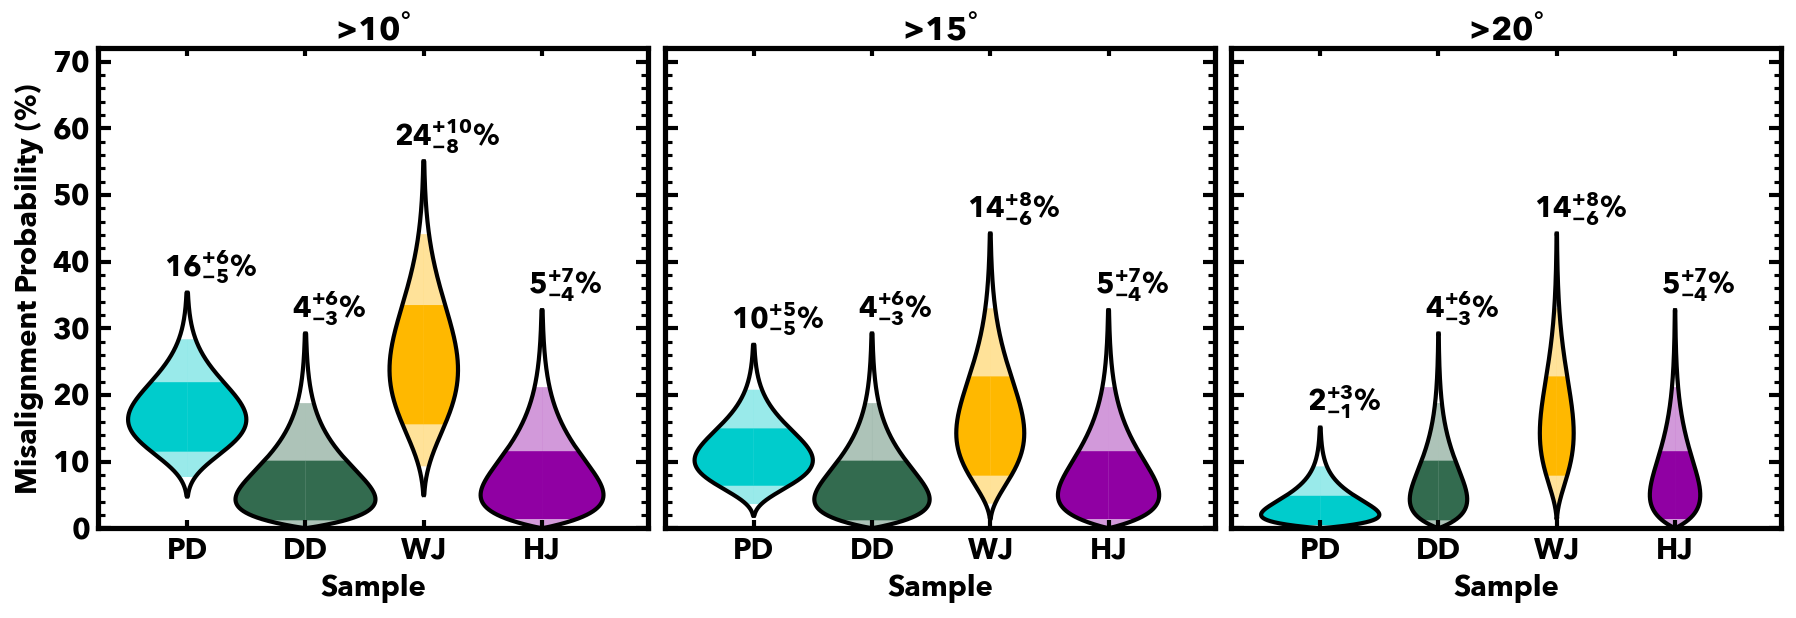

In [242]:
misalignment_method = 'Individual Precision'
misalignment_method = 'Global Threshold'

fraction_fontsize = 12
ax_letters = ['b', 'c', 'd']

misalignment_fractions = {}
for which_dataset in datasets:
    misalignment_fractions[which_dataset] = {'{:d} deg'.format(misalignment_thresholds[0]): {},
                                             '{:d} deg'.format(misalignment_thresholds[1]): {},
                                             '{:d} deg'.format(misalignment_thresholds[2]): {},
                                             }

fig = plt.figure(figsize=(12, 4))
axes = fig.subplot_mosaic(
    """
    bcd
    """,
    gridspec_kw={'height_ratios': [1], 'width_ratios': [1, 1, 1], "bottom": 0.14, "top": 0.94, "left": 0.055, "right": 0.99, "wspace": 0.03, "hspace": 0.06}
)

misalignment_thresholds2 = [misalignment_thresholds[0], misalignment_thresholds[1], misalignment_thresholds[2]]
# print(misalignment_thresholds2)

if only_multis_PD == True or only_multis_DD == True or only_multis_WJ == True or only_multis_HJ == True:
    yticks = [0, 10, 20, 30, 40, 50, 60, 70, 80]
    ymax = 84
else:
    yticks = [0, 10, 20, 30, 40, 50, 60, 70]
    ymax = 72

for mis_panel, mis in enumerate(misalignment_thresholds2):
    test_mis = 9
    do_test_mis = False
    
    ax = axes[ax_letters[mis_panel]]

    ax.minorticks_on()

    if ax_letters[mis_panel] == 'a':
        ax.set_title('> Ind. Pr.', fontsize=16)
    else:
        ax.set_title('>' + str(mis) + r'$^{\degree}$', fontsize=16)
    # 9.79453829322449
    # 8.181023012229167
    # 11.02366249604496
    # 12.39083335661888

    ax.set_yticks(yticks)
    if ax_letters[mis_panel] == 'b':
        ax.set_ylabel(r'Misalignment Probability (%)', fontsize=14)
        ax.set_yticklabels(yticks, fontsize=14)
    else:
        ax.set_yticklabels([], fontsize=14)
    ax.set_xlabel('Sample', fontsize=14)

    for data_i, which_dataset in enumerate(datasets):
        confidence = 90

        if which_dataset == 'PD':
            test_df = df_PD
            ccombonum = 1
            multis_list = PD_multis
            nonmultis_list = PD_nonmultis
            only_multis = only_multis_PD
            only_nonmultis = only_nonmultis_PD
        if which_dataset == 'DD':
            test_df = df_DD
            ccombonum = 2
            multis_list = DD_multis
            nonmultis_list = DD_nonmultis
            only_multis = only_multis_DD
            only_nonmultis = only_nonmultis_DD
        if which_dataset == 'WJ':
            test_df = df_WJ
            ccombonum = 3
            multis_list = WJ_multis
            nonmultis_list = WJ_nonmultis
            only_multis = only_multis_WJ
            only_nonmultis = only_nonmultis_WJ
        if which_dataset == 'HJ':
            test_df = df_HJ
            ccombonum = 4
            multis_list = HJ_multis
            nonmultis_list = HJ_nonmultis
            only_multis = only_multis_HJ
            only_nonmultis = only_nonmultis_HJ


        if only_multis == True:
            only_nonmultis = False

        if only_multis == False and only_nonmultis == False:
            sample_size = len(test_df['Target'].values)
        if only_multis == True:
            sample_size = len(multis_list)
        if only_nonmultis == True:
            sample_size = len(nonmultis_list)

        # if ccombonum == 1:
        #     ccombo = ['#008fc7', '#6a3dff', '#9000a3'] 
        # elif ccombonum == 2:
        #     ccombo = ['#ff6600', '#006666', '#739900']
        # elif ccombonum == 3:
        #     ccombo = ['#cc6600', '#cc3300', '#cc6600'] 
        # elif ccombonum == 4:
        #     ccombo = ['#0000cc', '#808080', '#00cc90']

        if ccombonum == 1:
            ccombo = ['#008fc7', '#6a3dff', pd_color] 
        elif ccombonum == 2:
            ccombo = ['#ff6600', '#006666', dd_color]
        elif ccombonum == 3:
            ccombo = ['#cc6600', '#cc3300', WJ_color] 
        elif ccombonum == 4:
            ccombo = ['#0000cc', '#808080', HJ_color]


        p90_color = ccombo[2]            
        
        x = np.linspace(0, 1, 10000)
        n = sample_size

        # print(str(mis) + ' deg: ')
        if misalignment_method == 'Individual Precision':
            k = len(misaligned_lists[which_dataset][str(mis) + ' deg'])
        if misalignment_method == 'Global Threshold':
            k = len(misaligned_lists_global_threshold[which_dataset][str(mis) + ' deg'])


        prob_dist = bb_binomial_ppd(x, k, n, normapprox=False)

        if which_dataset == 'PD':
            max_dist = max(prob_dist)

    
        misaligned_MAP, sig1_misaligned_m, sig1_misaligned_p, _, _ = highest_density_interval(x=x, pdf_y=prob_dist, sigma=0.6827, return_pdf=True)
        _, sig2_misaligned_m, sig2_misaligned_p, _, _ = highest_density_interval(x=x, pdf_y=prob_dist, sigma=0.9545, return_pdf=True)
        _, sig3_misaligned_m, sig3_misaligned_p, _, _ = highest_density_interval(x=x, pdf_y=prob_dist, sigma=0.9973, return_pdf=True)

        # if ax_letters[mis_panel] == 'a':
        misalignment_fractions[which_dataset][str(mis) + ' deg'][str(confidence)] = misaligned_MAP*100
        misalignment_fractions[which_dataset][str(mis) + ' deg'][str(confidence) + '+'] = sig1_misaligned_p*100
        misalignment_fractions[which_dataset][str(mis) + ' deg'][str(confidence) + '-'] = sig1_misaligned_m*100

        fill_x = x[np.where((x >= misaligned_MAP - sig1_misaligned_m) & (x <= misaligned_MAP + sig1_misaligned_p))[0]] * 100
        fill_y = prob_dist[np.where((x >= misaligned_MAP - sig1_misaligned_m) & (x <= misaligned_MAP + sig1_misaligned_p))[0]]/max_dist*0.5

        fill_x = np.concatenate(([fill_x[0]], fill_x, [fill_x[-1]]))
        fill_y = np.concatenate(([0], fill_y, [0]))

        fill_x2 = x[np.where((x >= misaligned_MAP - sig2_misaligned_m) & (x <= misaligned_MAP + sig2_misaligned_p))[0]] * 100
        fill_y2 = prob_dist[np.where((x >= misaligned_MAP - sig2_misaligned_m) & (x <= misaligned_MAP + sig2_misaligned_p))[0]]/max_dist*0.5

        fill_x2 = np.concatenate(([fill_x2[0]], fill_x2, [fill_x2[-1]]))
        fill_y2 = np.concatenate(([0], fill_y2, [0]))

        # plot_x = x[np.where((x >= misaligned_MAP - sig2_misaligned_m) & (x <= misaligned_MAP + sig2_misaligned_p))[0]] * 100
        # plot_y = prob_dist[np.where((x >= misaligned_MAP - sig2_misaligned_m) & (x <= misaligned_MAP + sig2_misaligned_p))[0]]/max_dist*0.5

        plot_x = x[np.where((x >= misaligned_MAP - sig3_misaligned_m) & (x <= misaligned_MAP + sig3_misaligned_p))[0]] * 100
        plot_y = prob_dist[np.where((x >= misaligned_MAP - sig3_misaligned_m) & (x <= misaligned_MAP + sig3_misaligned_p))[0]]/max_dist*0.5

        plot_x = np.concatenate(([plot_x[0]], plot_x, [plot_x[-1]]))
        plot_y = np.concatenate(([0], plot_y, [0]))

        ax.plot(plot_y + ccombonum, plot_x, color='#000000', lw=2.0)
        ax.plot((-plot_y) + ccombonum, plot_x, color='#000000', lw=2.0)
        
        ax.fill_between(x=fill_y + ccombonum, y1=fill_x, y2=0, facecolor=p90_color, alpha=1, zorder=-1)
        fill_y = -fill_y
        fill_y[0] += 0.0011
        fill_y[-1] += 0.0011
        ax.fill_between(x=fill_y + ccombonum, y1=fill_x, y2=0, facecolor=p90_color, alpha=1, zorder=-1)
        
        ax.fill_between(x=fill_y2 + ccombonum, y1=fill_x2, y2=0, facecolor=p90_color, alpha=0.4, zorder=-2)
        fill_y2 = -fill_y2
        fill_y2[0] += 0.0011
        fill_y2[-1] += 0.0011
        ax.fill_between(x=fill_y2 + ccombonum, y1=fill_x2, y2=0, facecolor=p90_color, alpha=0.4, zorder=-2)


        plt.rcParams['mathtext.default'] = 'regular'
        if which_dataset == 'PD' and mis == misalignment_thresholds[1]:
            fraction_text = r"${:d}^{{+{:d}}}_{{-{:d}}}\%$".format(round(misaligned_MAP*100), round(sig1_misaligned_p*100), 5)
        else:
            fraction_text = r"${:d}^{{+{:d}}}_{{-{:d}}}\%$".format(round(misaligned_MAP*100), round(sig1_misaligned_p*100), round(sig1_misaligned_m*100))
            
        ax.text(ccombonum + 0.2, max(plot_x) + 1, fraction_text, horizontalalignment='center', verticalalignment='bottom', fontsize=fraction_fontsize+2)  # , transform=ax.transAxes)

        # plt.savefig(test_figures_directory + 'Misalignment_Fraction_Distributions/' + which_dataset + '_15deg_' + str(90) + 'percent.pdf', dpi=300)

        # sum_of_Prob_k_given_p_and_n = np.trapz(y=Prob_k_given_p_and_n, x=k_values)

        # Prob = round(1. - sum_of_Prob_k_given_p_and_n, 3)

        xticks = [1, 2, 3, 4]
        xlabs = ['PD', 'DD', 'WJ', 'HJ']
        ax.set_xticks(xticks)
        ax.set_xticklabels(xlabs)

        ax.set_xlim(0.35, 4.65)

        ax.tick_params(axis='both', which='major', length=5, width=2.5)
        ax.tick_params(axis='both', which='minor', length=4, width=1.5, bottom=False, top=False)

        fraction_text2 = "{:d} +{:d},-{:d} %".format(round(misaligned_MAP*100), round(sig1_misaligned_p*100), round(sig1_misaligned_m*100))

        # print(which_dataset + ':')
        # print('fraction of sample: {:d}/{:d} = {:.3f}'.format(k, n, k/n))
        # print(fraction_text2)
        # print('k = ', k)
        # print('N = ', n)

    ax.tick_params(axis='x', which='major', length=4, width=2, labelsize=14)
    ax.tick_params(axis='y', which='major', length=6, width=2, labelsize=14) 
    ax.tick_params(axis='x', which='minor', length=0, width=1.5, labelsize=14)
    ax.tick_params(axis='y', which='minor', length=3.5, width=1.5, labelsize=14) 
    for spine_location in ['top', 'bottom', 'left', 'right']:
        ax.spines[spine_location].set_linewidth(2.5)

    ax.set_ylim(0, ymax)
    ax.set_xlim(0.25, 4.9)
    
    # print(' ')

# SAVE THE FIGURE
save_par_vs_stacked_residuals = 'Misalignment_Thresholds_' + light_or_dark_dext + '_' + transparent_text + '_' + date_str + '.pdf'
fig.savefig('/Users/lb8137/PROJECTS/OBLIQUITY_SYNTHESIS/Test_Figures/' + save_par_vs_stacked_residuals, dpi=300, transparent=False)
plt.show()
plt.close()

In [257]:
df_PD, df_DD, df_WJ, df_HJ = read_datafiles()

OPENING FILES...
/Users/lb8137/Projects/OBLIQUITY_SYNTHESIS/Tables/Sample_Weighted_Mean/adopted_highRes_PD_2025-Oct-24.csv
/Users/lb8137/Projects/OBLIQUITY_SYNTHESIS/Tables/Sample_Weighted_Mean/adopted_highRes_DD_2025-Oct-24.csv
/Users/lb8137/Projects/OBLIQUITY_SYNTHESIS/Tables/Sample_Weighted_Mean/adopted_highRes_WJ_2025-Oct-24.csv
/Users/lb8137/Projects/OBLIQUITY_SYNTHESIS/Tables/Sample_Weighted_Mean/adopted_highRes_HJ_2025-Oct-24.csv


/var/folders/pg/0b1t4t0s1vn5zbtl748n1dhh0000gn/T/ipykernel_87543/3694188868.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_PD['vsini Unc'].replace('ulimit', 0.0000, inplace=True)
/var/folders/pg/0b1t4t0s1vn5zbtl748n1dhh0000gn/T/ipykernel_87543/3694188868.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting 

PD
DD
WJ
HJ


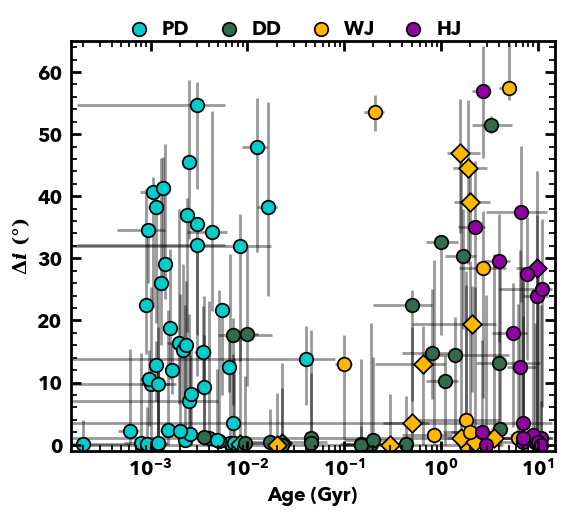

In [350]:
fig = plt.figure(figsize=(5.5, 5), dpi=100)
ax = fig.add_axes(111)
ax.minorticks_on()
ax.set_xlabel('Age (Gyr)', fontsize=14) # , labelpad=8)
ax.yaxis.label.set_family("DejaVu Serif")
ax.set_ylabel(r'$\mathit{\Delta i}$ ($\degree$)', fontsize=14, weight='semibold') # , labelpad=8)

# ax.scatter([], [], color='#ffffff', edgecolors='#000000', marker='D', linewidth=1.25, s=90, linestyle='None', zorder=-4, label='Multiple Known Planets')

edge_color = "#000000"

for which_dataset in datasets:
    

    print(which_dataset)

    if which_dataset == 'PD':
        plot_df = df_PD
        point_color = pd_color
        multis_list = PD_multis
    if which_dataset == 'DD':
        plot_df = df_DD
        point_color = dd_color
        multis_list = DD_multis
    if which_dataset == 'WJ':
        plot_df = df_WJ
        point_color = WJ_color
        multis_list = WJ_multis
    if which_dataset == 'HJ':
        plot_df = df_HJ
        point_color = HJ_color
        multis_list = HJ_multis

    targets_list = np.array(plot_df['Target'].values)

    x_data = np.array(plot_df['Age (Myr)'].values) * 1e-3
    x_err_m = np.array(plot_df['Age -Unc'].values) * 1e-3
    x_err_p = np.array(plot_df['Age +Unc'].values) * 1e-3

    y_data = np.array(plot_df['disk diff'].values)
    y_err_m = np.array(plot_df['disk diff -Unc'].values)
    y_err_p = np.array(plot_df['disk diff +Unc'].values)

    for bep_i in range(len(targets_list)):
        if targets_list[bep_i] in multis_list:
            point_shape = 'D'
            point_size_number = 90
        else:
            point_shape = 'o'
            point_size_number = np.pi*5.5**2

        if bep_i == 0:
            ax.scatter(x_data[bep_i], y_data[bep_i], color=point_color, edgecolors=edge_color, marker=point_shape, linewidth=1.25, s=point_size_number, linestyle='None', zorder=-4, label=which_dataset)
        else:
            ax.scatter(x_data[bep_i], y_data[bep_i], color=point_color, edgecolors=edge_color, marker=point_shape, linewidth=1.25, s=point_size_number, linestyle='None', zorder=-4)
        ax.errorbar(x_data[bep_i], y_data[bep_i], xerr=[[x_err_m[bep_i]], [x_err_p[bep_i]]], yerr=[[y_err_m[bep_i]], [y_err_p[bep_i]]], elinewidth=2, linewidth=0, capsize=0, ecolor=edge_color, capthick=0, zorder=-10, alpha=0.4)

ax.set_xlim(1.5e-4, 15)
ax.set_ylim(-1, 65)

xticks = (1e-3, 1e-2, 1e-1, 1e0, 1e1)
ax.set_xticks(xticks)
ax.set_xticklabels(xticks)

ax.set_xscale('log')

ax.tick_params(axis='x', which='major', labelsize=14, length=7, width=2, pad=6)
ax.tick_params(axis='y', which='major', labelsize=14, length=7, width=2, pad=6)
ax.tick_params(axis='x', which='minor', length=4, width=1.25)
ax.tick_params(axis='y', which='minor', length=4, width=1.25)

for spine1 in ax.spines.values():
        spine1.set_linewidth(2)

ax.legend(loc='upper left', ncol=4, handletextpad=0.2, frameon=False, framealpha=1, bbox_to_anchor=(0.06, 1.10), fontsize=14)

plt.subplots_adjust(bottom=0.12, top=0.94, left=0.11, right=0.99)

# SAVE THE FIGURE
save_age_vs_Deltai_string = 'Age_vs_Deltai_' + light_or_dark_dext + '_' + transparent_text + '_' + date_str + '.pdf'

fig.savefig('/Users/lb8137/PROJECTS/OBLIQUITY_SYNTHESIS/Test_Figures/' + save_age_vs_Deltai_string, dpi=300, transparent=False)

plt.show()
plt.close()


49
23
21
20


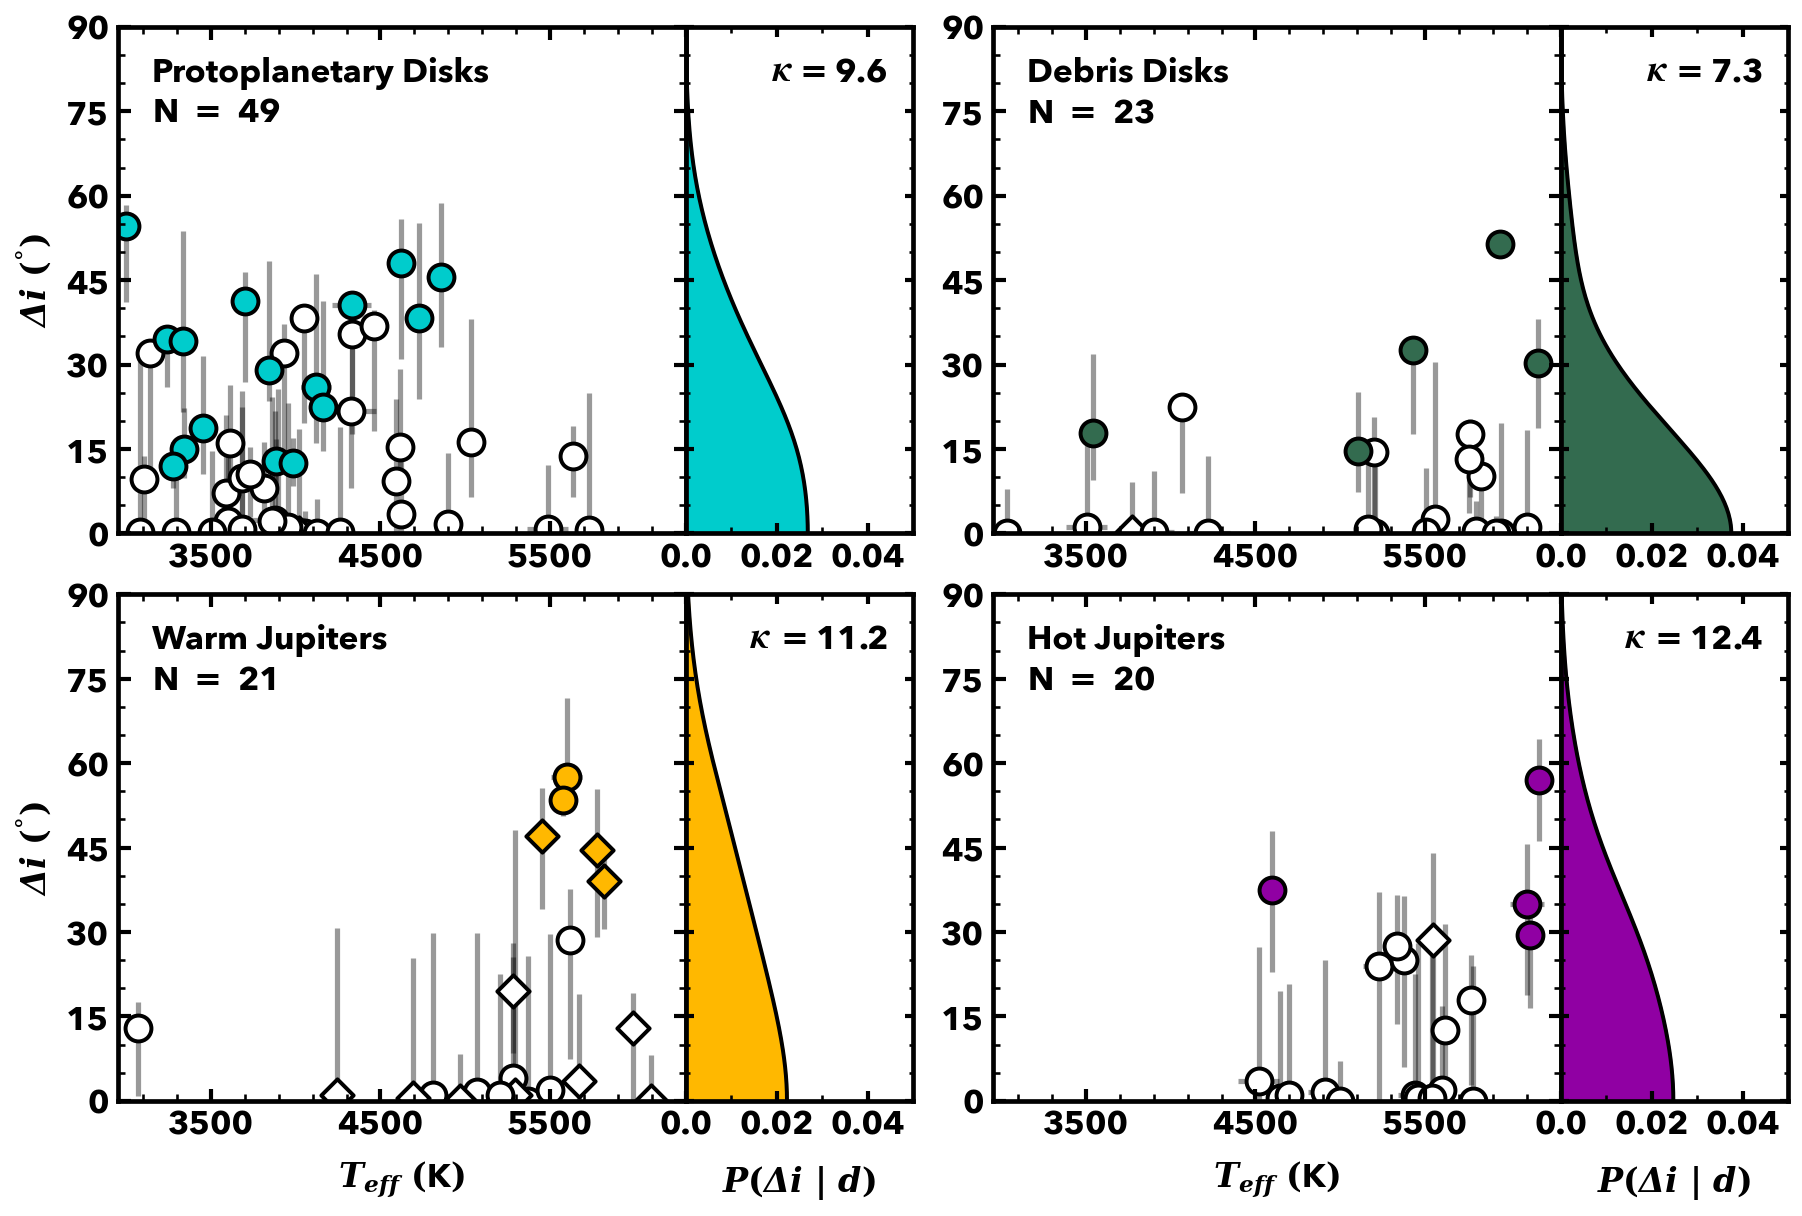

In [281]:

plt.rcParams['mathtext.default'] = 'bfit'

x_column = 'SpType Decimal'
x_column = 'Teff (K)'

if x_column == 'SpType Decimal':
    x_column_err_p = 'SpType Decimal Unc'
    x_column_err_m = 'SpType Decimal Unc'
    x_label = 'SpType'
    xlims = [2.25, 5.75]
    x_text = 'SpT'

if x_column == 'Teff (K)':
    x_column_err_p = 'Teff Unc'
    x_column_err_m = 'Teff Unc'
    x_label = r'$T_{eff}~\mathrm{(}$K$\mathrm{)}$'
    xlims = [2950, 6300]
    dx1 = 1000
    x_text = 'Teff'

y_column = 'disk diff'
y_column_err_p = 'disk diff +Unc'
y_column_err_m = 'disk diff -Unc'
y_label = r'$\Delta i$ ($^\degree$)'
ylims = [-2, 90]
y_text = 'Delta_i'

z_column = 'i star (deg)'
z_column_err_p = 'i star -Unc'
z_column_err_m = 'i star +Unc'
z_label = r'$i_{*}$ ($^\degree$)'
zlims = [0, 90]
z_text = 'i_Star'

parameter_z_norm = plt.Normalize(zlims[0], zlims[1])


datasets = ['PD', 'DD', 'WJ', 'HJ']




fig = plt.figure(figsize=(12, 8))
axes = fig.subplot_mosaic(
    """
    ab.cd
    ef.gh
    """,
    gridspec_kw={'height_ratios': [1, 1], 'width_ratios': [1, 0.4, 0.14, 1, 0.4], "bottom": 0.085, "top": 0.98, "left": 0.062, "right": 0.99, "wspace": 0.0, "hspace": 0.12}
)

for which_dataset in datasets:


    if which_dataset == 'PD':
        plot_df = df_PD
    if which_dataset == 'DD':
        plot_df = df_DD
    if which_dataset == 'WJ':
        plot_df = df_WJ
    if which_dataset == 'HJ':
        plot_df = df_HJ

    parameter_x = np.array(plot_df[x_column].values)
    parameter_x_err_p = np.array(plot_df[x_column_err_p].values)
    parameter_x_err_m = np.array(plot_df[x_column_err_m].values)
    parameter_y = np.array(plot_df[y_column].values)
    parameter_y_err_p = np.array(plot_df[y_column_err_p].values)
    parameter_y_err_m = np.array(plot_df[y_column_err_m].values)
    parameter_z = np.array(plot_df[z_column].values)
    parameter_z_err_p = np.array(plot_df[z_column_err_p].values)
    parameter_z_err_m = np.array(plot_df[z_column_err_m].values)
    targets_list = np.array(plot_df['Target'].values)

    parameter_x_err = [parameter_x_err_m, parameter_x_err_p]
    parameter_y_err = [parameter_y_err_m, parameter_y_err_p]
    parameter_z_err = [parameter_z_err_m, parameter_z_err_p]

    if which_dataset == 'PD':
        dataset_type = 'Protoplanetary Disks'
        dataset_author = '(Biddle et al. 2025)'
        # colormap = choose_cmap('primordial disks', reverse_cmap=False)
        kde_color = pd_color
        kde_linecolor = pd_linecolor
        dx2 = 0.02
        kde_alpha = 1
        density_estimation_total_positive_x = density_estimation_total_positive_x_PD
        if x_column == 'SpType Decimal':
            x2min = dx2
        if x_column == 'Teff (K)':
            x2min = 0.0
        ax_letters = ['a', 'b']
        ax2_bandwidth = band_width_PD
        multis_list = PD_multis
    if which_dataset == 'DD':
        dataset_type = 'Debris Disks'
        dataset_author = r'(Hurt & MacGregor 2023)'
        # colormap = choose_cmap('debris disks', reverse_cmap=False)
        kde_color = dd_color
        kde_linecolor = dd_linecolor
        dx2 = 0.02
        kde_alpha = 1
        density_estimation_total_positive_x = density_estimation_total_positive_x_DD
        if x_column == 'SpType Decimal':
            x2min = dx2
        if x_column == 'Teff (K)':
            x2min = 0.0
        ax_letters = ['c', 'd']
        ax2_bandwidth = band_width_DD
        multis_list = DD_multis
    if which_dataset == 'WJ':
        dataset_type = 'Warm Jupiters'
        dataset_author = '(Morgan et al. 2024)'
        # colormap = choose_cmap('warm jupiters', reverse_cmap=False)
        kde_color = WJ_color
        kde_linecolor = WJ_linecolor
        dx2 = 0.02
        kde_alpha = 1
        density_estimation_total_positive_x = density_estimation_total_positive_x_WJ
        if x_column == 'SpType Decimal':
            x2min = dx2
        if x_column == 'Teff (K)':
            x2min = 0.0
        ax_letters = ['e', 'f']
        ax2_bandwidth = band_width_WJ
        multis_list = WJ_multis
    if which_dataset == 'HJ':
        dataset_type = 'Hot Jupiters'
        dataset_author = '(Morgan et al. 2024)'
        # colormap = plt.get_cmap('bone')
        kde_color = HJ_color
        kde_linecolor = HJ_linecolor
        dx2 = 0.02
        kde_alpha = 1
        density_estimation_total_positive_x = density_estimation_total_positive_x_HJ
        if x_column == 'SpType Decimal':
            x2min = dx2
        if x_column == 'Teff (K)':
            x2min = 0.01
        ax_letters = ['g', 'h']
        ax2_bandwidth = band_width_HJ
        multis_list = HJ_multis


    err_alpha = 0.4

    grid_height = 2
    grid_width = 2

    original_fig_width = 8
    original_fig_height = 6.5

    original_width_ratios = [1, 0.40]
    original_height_ratios = [0.05, 1]


    fig_width = 8.25
    fig_height = 5.80

    try_width_ratios = [1, 0.65]
    try_height_ratios = [0.05, 1]


    single_parplot_fontsize = 16

    target_labels_on = False

    point_size = 7

    z_colors_on = True

    include_HBM_models = True

    zorder_shift = 10



    # fig = plt.figure(figsize=(fig_width, fig_height), dpi=150)
    # gs = gridspec.GridSpec(grid_height , grid_width , width_ratios=try_width_ratios, height_ratios=try_height_ratios)
    # axes = [fig.add_subplot(gs[ii, jj]) for ii in range(grid_height) for jj in range(grid_width)]
    # cbar_ax = axes[0]
    # blank_ax = axes[1]
    ax1 = axes[ax_letters[0]]
    ax2 = axes[ax_letters[1]]


    # MAKE INVISIBLE AXES SPINES
    for spine1 in ax1.spines.values():
        spine1.set_linewidth(2.25)
    for spine2 in ax2.spines.values():
        spine2.set_linewidth(2.25)



    ax1.minorticks_on()
    ax2.minorticks_on()

    if ax_letters[0] == 'e' or ax_letters[0] == 'g':
        ax1.set_xlabel(x_label, fontsize=single_parplot_fontsize, labelpad=8)
        ax2.set_xlabel(r'$P\mathrm{(}\Delta i~|~d\mathrm{)}$', fontsize=single_parplot_fontsize, labelpad=10)
    if ax_letters[0] == 'a' or ax_letters[0] == 'e':
        ax1.set_ylabel(r'$\Delta i~\mathrm{(}^\degree\mathrm{)}$', fontsize=single_parplot_fontsize, labelpad=6)


    # point_colors = [colormap(parameter_z_norm(bep)) for bep in parameter_z]
    # point_edgecolors = [kde_linecolor]*len(point_colors)  # [edge_color]*len(point_colors)
    # if z_colors_on == True:
    #     point_colors = [colormap(parameter_z_norm(bep)) for bep in parameter_z]
    # else:
    #     point_colors = [point_color_no_z]*len(point_colors)

    point_colors = [kde_color] * len(parameter_y)

    print(len(parameter_y))

    # -------------------------------------- THE SAMPLE ---------------------------------------  #
    for par_i in range(0, len(parameter_y)):
        if parameter_z[par_i] == 90.0:
            zord = -4
        if parameter_z[par_i] < 90:
            zord = -1
        if targets_list[par_i] in multis_list:
            point_shape = 'D'
            point_size_number = 120
        else:
            point_shape = 'o'
            point_size_number = np.pi*point_size**2
        if targets_list[par_i].replace(' ', '') in misaligned_lists[which_dataset]['ALL']:
            point_color = kde_color
        else:
            point_color = '#ffffff'
            
        edge_color = '#000000'
        
        # print([parameter_x[par_i]], [parameter_y[par_i]])
        ax1.scatter([parameter_x[par_i]], [parameter_y[par_i]], marker=point_shape, color=point_color, edgecolors=edge_color, linewidth=1.9, s=point_size_number, linestyle='None', zorder=zord)
        ax1.errorbar([parameter_x[par_i]], [parameter_y[par_i]], xerr=[[parameter_x_err[0][par_i]],[parameter_x_err[1][par_i]]], yerr=[[parameter_y_err[0][par_i]], [parameter_y_err[1][par_i]]],
                    elinewidth=2.5, linewidth=0, capsize=0, ecolor=edge_color, capthick=0, zorder=-5, alpha=err_alpha)
    # ---------------------------------------------------------------------------------------- #


    # --------------------------------------- COLORBAR --------------------------------------- #
    # if z_colors_on == True:
    #     # Add a single colorbar
    #     cbar = plt.colorbar(mpl.cm.ScalarMappable(norm=parameter_z_norm, cmap=colormap), cax=cbar_ax, orientation='horizontal') # , use_gridspec=True, shrink=1., fraction=0.05, pad=0.02)  # location='top', 
    #     cbar.set_label(z_label, labelpad=12, fontsize=single_parplot_fontsize, weight='bold')  # rotation=270
    #     cbar_ticks = np.arange(0, 105, 15)
    #     cbar.set_ticks(cbar_ticks)
    #     cbar.set_ticklabels(cbar_ticks, fontsize=single_parplot_fontsize)
    #     cbar.ax.xaxis.set_ticks_position('top')
    #     cbar.ax.xaxis.set_label_position('top')
    #     Number_of_minor_ticks_between_major_ticks_cbar = 3
    #     yticks_minor_cbar = AutoMinorLocator(Number_of_minor_ticks_between_major_ticks_cbar)
    #     cbar.minorticks_on()
    #     cbar.ax.xaxis.set_minor_locator(yticks_minor_cbar)
    #     cbar.ax.tick_params(which='minor', length=4.5, width=2)
    #     cbar.ax.tick_params(which='major', length=7.5, width=2.5, pad=2)
    # ---------------------------------------------------------------------------------------- #



    # ------------------------------ KERNEL DENSITY ESTIMATION ------------------------------- #
    ax2.fill_between(density_estimation_total_positive_x, x_grid_plot, color=kde_color, alpha=kde_alpha, label='Gaussian KDE', zorder=1-zorder_shift)
    ax2.plot(density_estimation_total_positive_x, x_grid_plot, color='#000000', linewidth=1.9, alpha=kde_alpha, zorder=1-zorder_shift+1)
    # ---------------------------------------------------------------------------------------- #


    # ---------------------------------------- THE SUN ---------------------------------------  #
    Solar_SpType = 4.98  # 4.6
    Solar_SpType_err = 0.1
    Solar_obliquity = 7.155
    Solar_obliquity_err = 0.002
    Solar_point_size = 750

    sun_color = '#ffff80'  # '#ace600'
    sun_edgecolor = '#26004d'  # '#001a33'
    ax1.scatter([Solar_SpType], [Solar_obliquity], marker='*', color=sun_color, edgecolors=sun_edgecolor, linewidth=2.5, s=Solar_point_size, linestyle='None')  # , label='The Pre-main Sequence Sun')
    # ax1.errorbar([Solar_SpType], [Solar_obliquity], xerr=[Solar_SpType_err], yerr=[Solar_obliquity_err], elinewidth=3, linewidth=0, capsize=0, ecolor='#001a33', capthick=0, zorder=-1)   
    # ---------------------------------------------------------------------------------------- #

    for spine in ax2.spines.values():
        spine.set_zorder(100)


    if x_column == 'SpType Decimal':
        sptype_designations = {'0': 'B',
                            '0.5': 'B5',
                            '1': 'A0',
                            '1.5': 'A5',
                            '2': 'F0',
                            '2.5': 'F5',
                            '3': 'G0',
                            '3.5': 'G5',
                            '4': 'K0',
                            '4.5': 'K5',
                            '5': 'M0',
                            '5.5': 'M5',
                            }

        xtickvals = [2.5, 3., 3.5, 4, 4.5, 5, 5.5]  # np.arange(xlims[0], xlims[1]+0.25, 0.25)
        xticklabs = []
        xticks = []
        for xtick in xtickvals:
            if xtick < xlims[1]:
                if (np.mod(xtick,1) == 0) and (xtick >= xlims[0]):
                    xticks.append(xtick)
                    xticklabs.append(sptype_designations[str(int(xtick))])
                elif (np.mod(xtick,0.5) == 0) and (xtick >= xlims[0]):
                    xticks.append(xtick)
                    xticklabs.append(sptype_designations['{:.1f}'.format(xtick)])
        ax1.set_xticks(xticks)
        xticklabels = ax1.set_xticklabels(xticklabs, fontsize=single_parplot_fontsize)

    if x_column == 'Teff (K)':
        xticks = [3500, 4500, 5500]
        if ax_letters[0] == 'e' or ax_letters[0] == 'g' or ax_letters[0] == 'a' or ax_letters[0] == 'c':
            ax1.set_xticks(xticks)
            xticklabels = ax1.set_xticklabels(xticks, fontsize=single_parplot_fontsize)
        # if ax_letters[0] == 'a' or ax_letters[0] == 'c': 
            # ax1.set_xticks(xticks)
            # xticklabels = ax1.set_xticklabels([], fontsize=single_parplot_fontsize)


    x2lim = 0.05  # 1.15 * max(density_estimation_total_positive_x)
    ax2_xtickvals = [0.0, 0.02, 0.04]
    if ax_letters[1] == 'f' or ax_letters[1] == 'h' or ax_letters[1] == 'b' or ax_letters[1] == 'd':
        ax2.set_xticks(ax2_xtickvals)
        ax2_xtickvals = ['0.0', '0.02', '0.04']
        ax2.set_xticklabels(ax2_xtickvals, fontsize=single_parplot_fontsize)


    ytickvals_major = np.arange(0, 105, 15)
    yticks_major = [int(ytick) for ytick in ytickvals_major]
    ax1.set_yticks(yticks_major, minor=False)
    ax2.set_yticks(yticks_major, minor=False)
    if ax_letters[0] == 'a' or ax_letters[0] == 'e' or ax_letters[0] != 'a' and ax_letters[0] != 'e':
        yticklabels = ax1.set_yticklabels(yticks_major, fontsize=single_parplot_fontsize)
        ax2.set_yticklabels([]) 


    xticks_minor1 = AutoMinorLocator(5)
    ax1.xaxis.set_minor_locator(xticks_minor1)
    xticks_minor2 = AutoMinorLocator(2)
    ax2.xaxis.set_minor_locator(xticks_minor2)
    yticks_minor = AutoMinorLocator(3)
    ax1.yaxis.set_minor_locator(yticks_minor)
    ax2.yaxis.set_minor_locator(yticks_minor)


    ax1.set_xlim(xlims)
    ax1.set_ylim(0, 90)
    ax2.set_ylim(0, 90)
    ax2.set_xlim(0, x2lim)

    ax1.set_rasterized(True)

    ax1.tick_params(which='major', length=6, width=2, pad=4)
    ax1.tick_params(which='minor', length=3.5, width=1.25)

    ax2.tick_params(labelsize=single_parplot_fontsize)

    ax2.tick_params(axis='x', which='major', length=5, width=2, pad=4)
    ax2.tick_params(axis='x', which='minor', length=3, width=1.25)
    ax2.tick_params(axis='y', which='major', length=4, width=2, pad=4)
    ax2.tick_params(axis='y', which='minor', length=2, width=1.25)




    # ax2.text(0.50, 0.92, dataset_type, horizontalalignment='center', verticalalignment='center', fontsize=single_parplot_fontsize, transform=ax2.transAxes)
    # ax2.text(0.50, 0.86, dataset_author, horizontalalignment='center', verticalalignment='center', fontsize=0.8*single_parplot_fontsize, transform=ax2.transAxes)

    ax1.text(0.06, 0.91, dataset_type, horizontalalignment='left', verticalalignment='center', fontsize=single_parplot_fontsize, transform=ax1.transAxes)
    # ax1.text(0.06, 0.86, dataset_author, horizontalalignment='left', verticalalignment='center', fontsize=0.8*single_parplot_fontsize, transform=ax1.transAxes)
    ax1.text(0.06, 0.83, r"N $=$ {:d}".format(len(parameter_y)), horizontalalignment='left', verticalalignment='center', fontsize=single_parplot_fontsize, transform=ax1.transAxes)

    # ax2.text(0.89, 0.91, r'$\kappa = $' + str(np.round(ax2_bandwidth, 1)), horizontalalignment='right', verticalalignment='center', fontsize=single_parplot_fontsize, transform=ax2.transAxes)


    mpl.rcParams['mathtext.fontset'] = 'stix'
    if which_dataset == 'PD' or which_dataset == 'DD':
        ax2.text(0.475, 0.915, r'$\kappa$', horizontalalignment='right', verticalalignment='center', fontsize=single_parplot_fontsize+2, transform=ax2.transAxes, color='#000000')
    else:
        ax2.text(0.38, 0.915, r'$\kappa$', horizontalalignment='right', verticalalignment='center', fontsize=single_parplot_fontsize+2, transform=ax2.transAxes, color='#000000')
    mpl.rcParams['mathtext.fontset'] = 'dejavuserif'
    ax2.text(0.89, 0.91, r"$=$" + str(np.round(ax2_bandwidth, 1)), horizontalalignment='right', verticalalignment='center', fontsize=single_parplot_fontsize, transform=ax2.transAxes, weight='semibold', color='#000000')


    # fig.subplots_adjust(left=0.085, bottom=0.11, right=0.99, top=0.89, wspace=0.02, hspace=0.02)
    # labels_text = 'bep'


# SAVE THE FIGURE
save_par_vs_Deltai_string = 'Deltai_' + light_or_dark_dext + '_' + transparent_text + '_' + date_str + '.pdf'

fig.savefig('/Users/lb8137/PROJECTS/OBLIQUITY_SYNTHESIS/Test_Figures/' + save_par_vs_Deltai_string, dpi=300, transparent=False)

plt.show()
plt.close()

In [220]:
df_WJ['Target'].values

array(['K2-139', 'K2-281', 'K2-329', 'K2-77', 'Kepler-1654', 'Kepler-27',
       'Kepler-28', 'Kepler-289', 'Kepler-30', 'Kepler-447', 'Kepler-468',
       'Kepler-51', 'Kepler-52', 'Kepler-539', 'Kepler-63', 'Kepler-75',
       'Kepler-9', 'TOI-1227', 'TOI-4562', 'V1298 Tau', 'WASP-84'],
      dtype=object)

9.646476067520407
7.2608858014347835
11.246671484452381
12.422191297800001


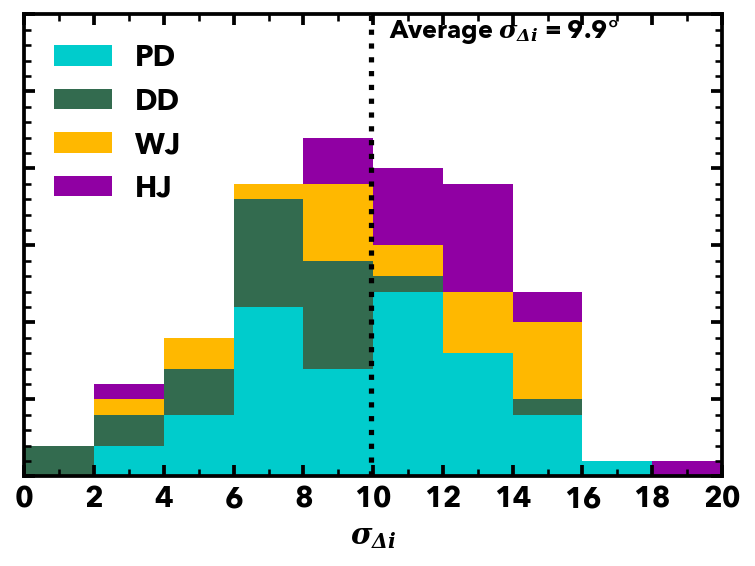

mean Deltai uncertainty among all samples: 9.949571928061946


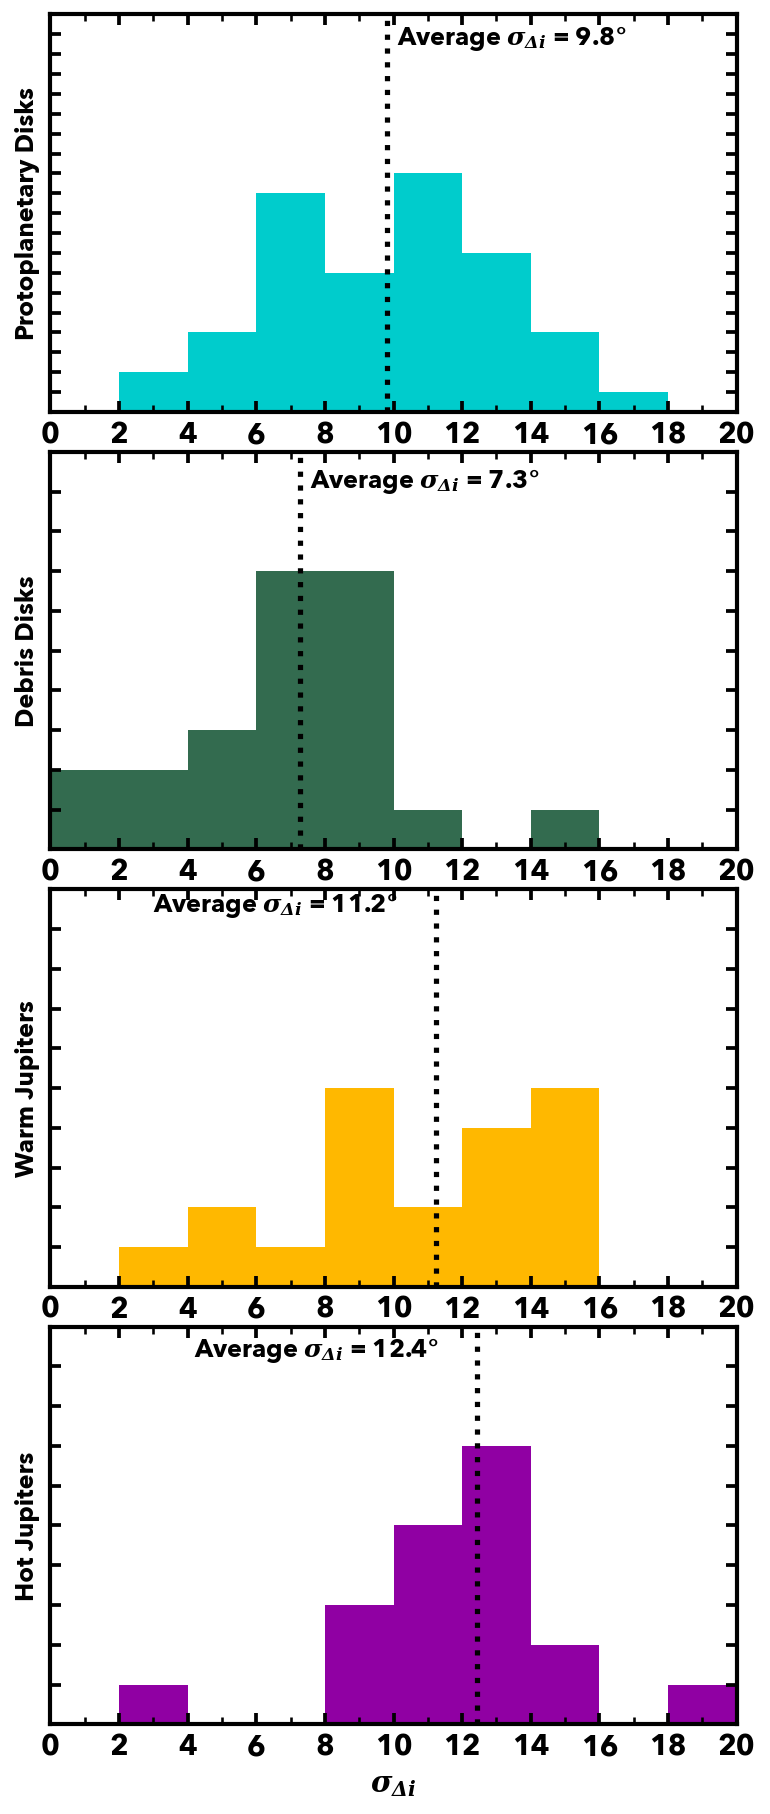

In [202]:
mean_Deltai_err_PD = (df_PD['disk diff +Unc'].values + df_PD['disk diff -Unc'].values) / 2.
mean_Deltai_err_DD = (df_DD['disk diff +Unc'].values + df_DD['disk diff -Unc'].values) / 2.
mean_Deltai_err_WJ = (df_WJ['disk diff +Unc'].values + df_WJ['disk diff -Unc'].values) / 2.
mean_Deltai_err_HJ = (df_HJ['disk diff +Unc'].values + df_HJ['disk diff -Unc'].values) / 2.

print(np.mean(mean_Deltai_err_PD))
print(np.mean(mean_Deltai_err_DD))
print(np.mean(mean_Deltai_err_WJ))
print(np.mean(mean_Deltai_err_HJ))

single_list = np.concatenate((mean_Deltai_err_PD, mean_Deltai_err_DD, mean_Deltai_err_WJ, mean_Deltai_err_HJ))
mean_sigma_Deltai_all = np.nanmean(single_list)



do_bins = np.arange(0, 22, 2)



fig = plt.figure(figsize=(6,4), dpi=150)
ax = fig.add_subplot(111)
ax.minorticks_on()
ax.set_xlabel(r'$\sigma_{\Delta i}$', fontsize=14)
ylims = 0, 30
xlims = 0, 20
hist_colors = [pd_color, dd_color, WJ_color, HJ_color]
hist_labels = ['PD', 'DD', 'WJ', 'HJ']
hist_stacks = [mean_Deltai_err_PD, mean_Deltai_err_DD, mean_Deltai_err_WJ, mean_Deltai_err_HJ]
ax.hist(hist_stacks, align='mid', bins=do_bins, histtype='bar', stacked=True, color=hist_colors, lw=0, label=hist_labels)
ax.plot([mean_sigma_Deltai_all, mean_sigma_Deltai_all], ylims, ':', color='#000000', lw=2.5)
ax.text(mean_sigma_Deltai_all+0.5, ylims[1]-1.5, r'Average $\sigma_{\Delta i}$ = ' + str(np.round(mean_sigma_Deltai_all, 1)) + r'$\degree$', fontsize=12)
ax.set_ylim(ylims)
ax.set_xlim(xlims)
xticks = np.arange(xlims[0], xlims[1] + 2, 2)
ax.set_xticks(xticks)
ax.set_xticklabels(xticks)
ax.set_yticklabels([])
xticks_minor = AutoMinorLocator(2)
ax.xaxis.set_minor_locator(xticks_minor)
ax.legend(loc='upper left')
plt.savefig('/Users/lb8137/PROJECTS/OBLIQUITY_SYNTHESIS/Test_Figures/sigmaDi_precision_histogram_all.pdf')
plt.show()
plt.close()


print('mean Deltai uncertainty among all samples: ' + str(mean_sigma_Deltai_all))

fig = plt.figure(figsize=(5,12), dpi=150)
axes = fig.subplot_mosaic(
    """
    a
    b
    c
    d
    """,
    gridspec_kw={'height_ratios': [1, 1, 1, 1], 'width_ratios': [1], "bottom": 0.04, "top": 0.99, "left": 0.06, "right": 0.975, "wspace": 0.54, "hspace": 0.10,}
)


ax = axes['a']
ax.minorticks_off()
ylims = 0, 20
ax.set_ylabel('Protoplanetary Disks', labelpad=1, fontsize=12)
# ax.set_xlabel(r'$\sigma_{\Delta i}$', fontsize=14)
ax.hist(mean_Deltai_err_PD, align='mid', bins=do_bins, histtype='bar', stacked=True, color=pd_color, lw=0)
ax.plot([9.8, 9.8], ylims, ':', color='#000000', lw=2.5)
ax.text(9.8+0.3, ylims[1]-1.5, r'Average $\sigma_{\Delta i}$ = ' + str('9.8') + r'$\degree$', fontsize=12)
# ax.plot([np.mean(mean_Deltai_err_PD), np.mean(mean_Deltai_err_PD)], ylims, ':', color='#000000', lw=2.5)
# ax.text(np.mean(mean_Deltai_err_PD)+0.3, ylims[1]-1.5, r'Average $\sigma_{\Delta i}$ = ' + str(np.round(np.mean(mean_Deltai_err_PD), 1)) + r'$\degree$', fontsize=12)
ax.set_xlim(xlims)
ax.set_ylim(ylims)
xticks = np.arange(xlims[0], xlims[1] + 2, 2)
ax.set_xticks(xticks)
ax.set_xticklabels(xticks)
yticks = np.arange(ylims[0], ylims[1] + 1, 1)
ax.set_yticks(yticks)
ax.set_yticklabels([])
xticks_minor = AutoMinorLocator(2)
ax.xaxis.set_minor_locator(xticks_minor)

for spine in ax.spines.values():
    spine.set_linewidth(2.0)

ax = axes['b']
ax.minorticks_off()
ylims = 0, 10
ax.set_ylabel('Debris Disks', labelpad=1, fontsize=12)
# ax.set_xlabel(r'$\sigma_{\Delta i}$', fontsize=14)
ax.hist(mean_Deltai_err_DD, align='mid', bins=do_bins, histtype='bar', stacked=True, color=dd_color, lw=0)
ax.plot([np.mean(mean_Deltai_err_DD), np.mean(mean_Deltai_err_DD)], ylims, ':', color='#000000', lw=2.5)
ax.text(np.mean(mean_Deltai_err_DD)+0.3, ylims[1]-0.9, r'Average $\sigma_{\Delta i}$ = ' + str(np.round(np.mean(mean_Deltai_err_DD), 1)) + r'$\degree$', fontsize=12)
ax.set_xlim(xlims)
ax.set_ylim(ylims)
xticks = np.arange(xlims[0], xlims[1] + 2, 2)
ax.set_xticks(xticks)
ax.set_xticklabels(xticks)
yticks = np.arange(ylims[0], ylims[1] + 1, 1)
ax.set_yticks(yticks)
ax.set_yticklabels([])
xticks_minor = AutoMinorLocator(2)
ax.xaxis.set_minor_locator(xticks_minor)

for spine in ax.spines.values():
    spine.set_linewidth(2.0)

ax = axes['c']
ax.minorticks_off()
ylims = 0, 10
ax.set_ylabel('Warm Jupiters', labelpad=1, fontsize=12)
# ax.set_xlabel(r'$\sigma_{\Delta i}$', fontsize=14)
ax.hist(mean_Deltai_err_WJ, align='mid', bins=do_bins, histtype='bar', stacked=True, color=WJ_color, lw=0)
ax.plot([np.mean(mean_Deltai_err_WJ), np.mean(mean_Deltai_err_WJ)], ylims, ':', color='#000000', lw=2.5)
ax.text(np.mean(mean_Deltai_err_WJ)-8.25, ylims[1]-0.55, r'Average $\sigma_{\Delta i}$ = ' + str(np.round(np.mean(mean_Deltai_err_WJ), 1)) + r'$\degree$', fontsize=12)
ax.set_xlim(xlims)
ax.set_ylim(ylims)
xticks = np.arange(xlims[0], xlims[1] + 2, 2)
ax.set_xticks(xticks)
ax.set_xticklabels(xticks)
yticks = np.arange(ylims[0], ylims[1] + 1, 1)
ax.set_yticks(yticks)
ax.set_yticklabels([])
xticks_minor = AutoMinorLocator(2)
ax.xaxis.set_minor_locator(xticks_minor)

for spine in ax.spines.values():
    spine.set_linewidth(2.0)

ax = axes['d']
ax.minorticks_off()
ylims = 0, 10
ax.set_ylabel('Hot Jupiters', labelpad=1, fontsize=12)
ax.set_xlabel(r'$\sigma_{\Delta i}$', fontsize=14)
ax.hist(mean_Deltai_err_HJ, align='mid', bins=do_bins, histtype='bar', stacked=True, color=HJ_color, lw=0)
ax.plot([np.mean(mean_Deltai_err_HJ), np.mean(mean_Deltai_err_HJ)], ylims, ':', color='#000000', lw=2.5)
ax.text(np.mean(mean_Deltai_err_HJ)-8.25, ylims[1]-0.75, r'Average $\sigma_{\Delta i}$ = ' + str(np.round(np.mean(mean_Deltai_err_HJ), 1)) + r'$\degree$', fontsize=12)
ax.set_xlim(xlims)
ax.set_ylim(ylims)
xticks = np.arange(xlims[0], xlims[1] + 2, 2)
ax.set_xticks(xticks)
ax.set_xticklabels(xticks)
yticks = np.arange(ylims[0], ylims[1] + 1, 1)
ax.set_yticks(yticks)
ax.set_yticklabels([])
xticks_minor = AutoMinorLocator(2)
ax.xaxis.set_minor_locator(xticks_minor)

for spine in ax.spines.values():
    spine.set_linewidth(2.0)


plt.savefig('/Users/lb8137/PROJECTS/OBLIQUITY_SYNTHESIS/Test_Figures/sigmaDi_precision_histograms.pdf')
plt.show()
plt.close()

single_list = np.concatenate((mean_Deltai_err_PD, mean_Deltai_err_DD, mean_Deltai_err_WJ, mean_Deltai_err_HJ))
mis_thres = np.round(np.nanmean(single_list))
# print('mean Deltai uncertainty among all samples: ' + str(np.nanmean(single_list)))

2MASSJ04124068+2438157
2MASSJ11004022-7619280
2MASSJ16083070-3828268
AS209
BPTau
CIDA-7
DNTau
FTTau
IMLup
RXJ1615.3-3255
RXJ1842.9-3532
RXJ1852.3-3700
Sz114
TWHya
V836Tau
WSB52


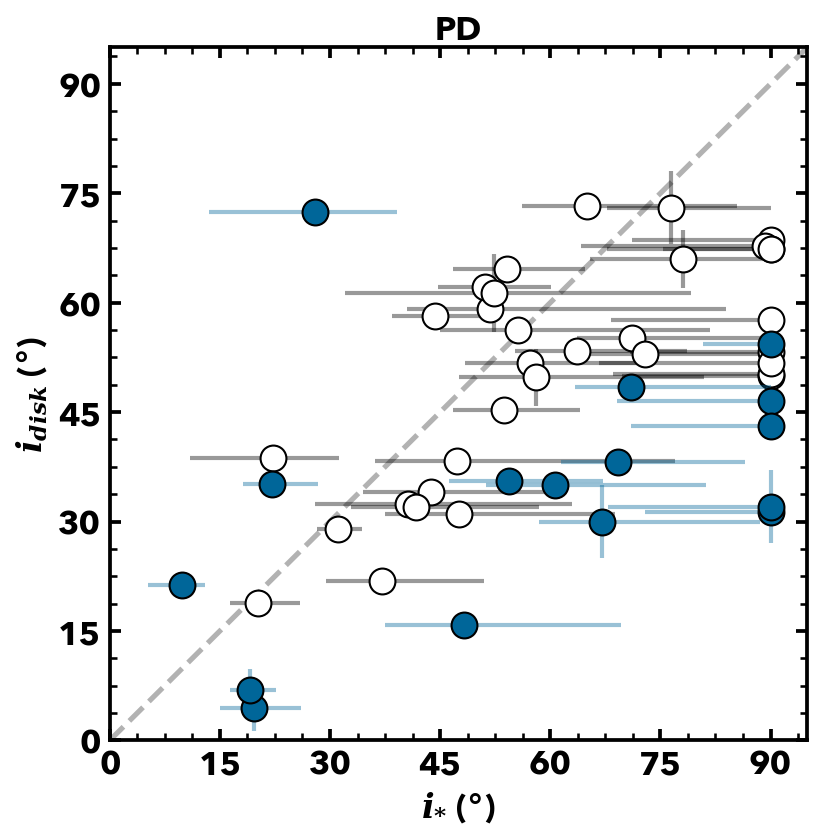

HD10647
HD207129
HD53143
TWA7
epsilonEridani


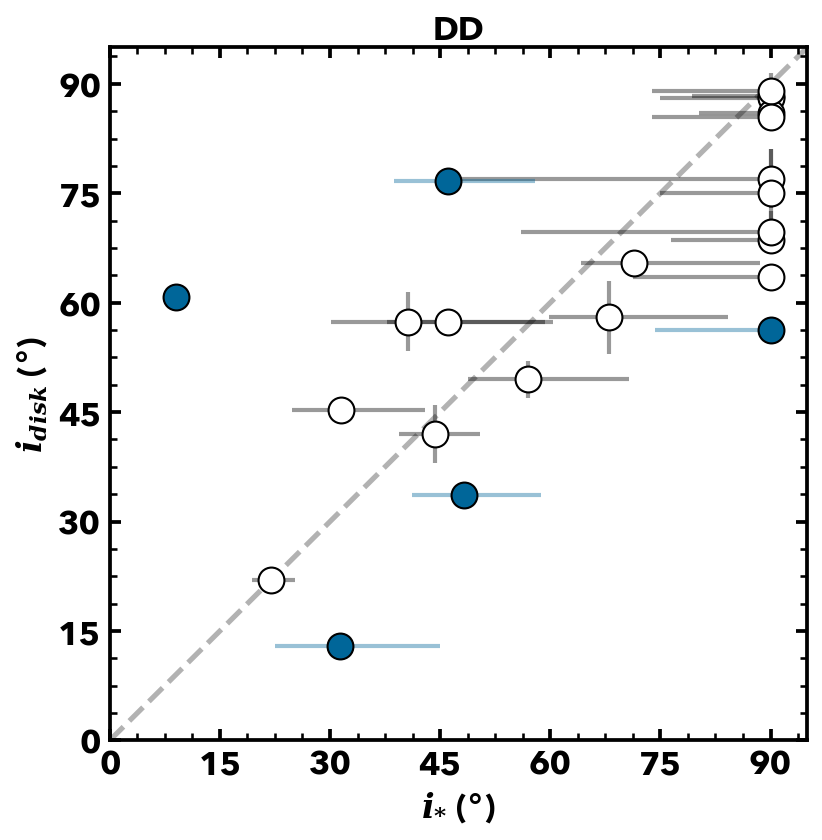

In [203]:

single_parplot_fontsize = 16
point_size = 7
edge_width = 1

colormap = choose_cmap('black limeaid', reverse_cmap=False)
# colormap = plt.set_cmap('managua')
# colormap = plt.set_cmap('BrBG')


which_misalignment_test = 'Individual Precision'  
# which_misalignment_test = '>10 deg'

do_colorbar = False

plot_istar_vs_idisk_list = ['PD', 'DD']


for which_dataset in plot_istar_vs_idisk_list:
    

    if which_misalignment_test == 'Individual Precision':
        misalignment_test_array = misaligned_lists[which_dataset]['ALL']
    if which_misalignment_test == '>10 deg':
        misalignment_test_array = misaligned_lists[which_dataset]['10 deg']

    if which_dataset == 'PD':
        plot_df = df_PD
    if which_dataset == 'DD':
        plot_df = df_DD
    if which_dataset == 'WJ':
        plot_df = df_WJ
    if which_dataset == 'HJ':
        plot_df = df_HJ


    fig = plt.figure(figsize=(6, 6), dpi=150)
    ax = fig.add_subplot(111)
    ax.minorticks_on()
    ax.set_title(which_dataset, fontsize=single_parplot_fontsize)
    ax.set_xlabel(r'$i_{*}$ ($\degree$)', fontsize=single_parplot_fontsize)
    ax.set_ylabel(r'$i_{disk}$ ($\degree$)', fontsize=single_parplot_fontsize)

    colorbar_norm = plt.Normalize(0, 60)
    point_colors = [colormap(colorbar_norm(bep)) for bep in plot_df['disk diff'].values]

    xmin, xmax = 0, 95
    ymin, ymax = 0, 95

    ax.plot([xmin, xmax], [ymin, ymax], '--', color='#000000', alpha=0.3, zorder=-150)


    for point_i in range(len(plot_df['Simbad Name'].values)):

        # print(' ')
        # print(plot_df['Simbad Name'].values[point_i])
        target_str = plot_df['Simbad Name'].values[point_i].replace(' ', '')
        # print(target_str)


        if do_colorbar == False:
            if target_str in misalignment_test_array:
                point_color = '#006699'
                point_ecolor = point_color
                print(target_str)
                # print(target_str , plot_df['Simbad Name'][point_i])
                # print('istar: ', plot_df['i star (deg)'][point_i])
                # print('idisk: ', plot_df['i disk (deg)'][point_i])
                # print('Delta i: ', plot_df['disk diff'][point_i], MAP_Delta_i)
                # print(' ')
                point_zorder = -1
            else:
                point_color = '#ffffff'
                point_ecolor = '#000000'
                point_zorder = -100
        if do_colorbar == True:
            point_color = point_colors[point_i]
            point_ecolor = '#000000'
            point_zorder = -1

        # print('istar uncertainties (-,+): ', plot_df['i star -Unc'][point_i], plot_df['i star +Unc'][point_i])
        # print('idisk uncertainty: ', plot_df['i disk Unc'][point_i])

        # print(type(plot_df['i disk (deg)'][point_i]))
        # print(plot_df['i disk (deg)'][point_i])

        if type(plot_df['i disk (deg)'].values[point_i]) != str:
            y_value = plot_df['i disk (deg)'].values[point_i]
            y_error = plot_df['i disk Unc'].values[point_i]
        if type(plot_df['i disk (deg)'].values[point_i]) == str:
            if '[' in plot_df['i disk (deg)'].values[point_i]:
                y_value = plot_df['i disk (deg)'].values[point_i].replace('[','')
                y_value = y_value.replace(']','')
                y_value = y_value.split(',')
                y_value1 = float(y_value[0])
                y_value2 = float(y_value[1])
                y_value = np.mean([y_value1, y_value2])
                y_error = abs(y_value1 - y_value)
            else:
                y_value = float(plot_df['i disk (deg)'].values[point_i])
                y_error = float(plot_df['i disk Unc'].values[point_i])

        ax.scatter([plot_df['i star (deg)'].values[point_i]], [y_value], color=point_color, edgecolors='#000000',
                s=np.pi*point_size**2, linewidth=edge_width, linestyle='None', zorder=point_zorder-1)
        ax.errorbar([plot_df['i star (deg)'].values[point_i]], [y_value],
                    xerr=[[plot_df['i star -Unc'].values[point_i]],[plot_df['i star +Unc'].values[point_i]]],
                    yerr=[y_error],
                    elinewidth=2, linewidth=0, capsize=0, ecolor=point_ecolor, capthick=1, alpha=0.4, zorder=point_zorder-2)
        
        # ax.text(plot_df['i star (deg)'][point_i], plot_df['i disk (deg)'][point_i]+3, plot_df['Simbad Name'][point_i], horizontalalignment='center', fontsize=10)

    # ax.text(4, 85, 'Blue = Misaligned', horizontalalignment='left', fontsize=single_parplot_fontsize)

    # ax.scatter([], [], color='#006699', edgecolors='#000000', s=np.pi*point_size**2, linewidth=edge_width, linestyle='None', label='Misaligned', zorder=-1)

    if do_colorbar == True:
        cbar = plt.colorbar(mpl.cm.ScalarMappable(norm=colorbar_norm, cmap=colormap), orientation='horizontal', location='top') # cax=cbar_ax, # , use_gridspec=True, shrink=1., fraction=0.05, pad=0.02)  # location='top', 
        cbar.set_label(r'$\Delta i$ ($\degree$)', labelpad=12, fontsize=single_parplot_fontsize, weight='bold')  # rotation=270
        cbar_ticks = np.arange(0, 70, 10)
        cbar.set_ticks(cbar_ticks)
        cbar.set_ticklabels(cbar_ticks, fontsize=single_parplot_fontsize)
        cbar.ax.xaxis.set_ticks_position('top')
        cbar.ax.xaxis.set_label_position('top')
        Number_of_minor_ticks_between_major_ticks_cbar = 3
        yticks_minor_cbar = AutoMinorLocator(Number_of_minor_ticks_between_major_ticks_cbar)
        cbar.minorticks_on()
        cbar.ax.xaxis.set_minor_locator(yticks_minor_cbar)
        cbar.ax.tick_params(which='minor', length=4.5, width=2)
        cbar.ax.tick_params(which='major', length=7.5, width=2.5, pad=2)

    ax.tick_params(labelsize=single_parplot_fontsize)

    tickvals = [0, 15, 30, 45, 60, 75, 90]
    ax.set_xticks(tickvals)
    ax.set_yticks(tickvals)
    ax.set_xticklabels(tickvals, fontsize=single_parplot_fontsize)
    ax.set_yticklabels(tickvals, fontsize=single_parplot_fontsize)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    # ax.legend(loc='upper left')

    plt.show()


In [204]:

# x_column = 'SpType Decimal'
# x_column = 'Teff (K)'

# if x_column == 'SpType Decimal':
#     x_column_err_p = 'SpType Decimal Unc'
#     x_column_err_m = 'SpType Decimal Unc'
#     x_label = 'SpType'
#     xlims = [2.25, 5.75]
#     x_text = 'SpT'

# if x_column == 'Teff (K)':
#     x_column_err_p = 'Teff Unc'
#     x_column_err_m = 'Teff Unc'
#     x_label = r'$T_{eff}$ (K)'
#     xlims = [2950, 6300]
#     dx1 = 1000
#     x_text = 'Teff'

# y_column = 'disk diff'
# y_column_err_p = 'disk diff +Unc'
# y_column_err_m = 'disk diff -Unc'
# y_label = r'$\Delta i$ ($^\degree$)'
# ylims = [-2, 90]
# y_text = 'Delta_i'

# z_column = 'i star (deg)'
# z_column_err_p = 'i star -Unc'
# z_column_err_m = 'i star +Unc'
# z_label = r'$i_{*}$ ($^\degree$)'
# zlims = [0, 90]
# z_text = 'i_Star'

# parameter_z_norm = plt.Normalize(zlims[0], zlims[1])


# datasets = ['PD', 'DD', 'WJ', 'HJ']




# fig = plt.figure(figsize=(4, 10))
# axes = fig.subplot_mosaic(
#     """
#     ab
#     cd
#     ef
#     gh
#     """,
#     gridspec_kw={'height_ratios': [1, 1, 1, 1], 'width_ratios': [1, 0.4], "bottom": 0.055, "top": 0.99, "left": 0.15, "right": 0.99, "wspace": 0.0, "hspace": 0.035}
# )

# for which_dataset in datasets:


#     if which_dataset == 'PD':
#         plot_df = df_PD
#     if which_dataset == 'DD':
#         plot_df = df_DD
#     if which_dataset == 'WJ':
#         plot_df = df_WJ
#     if which_dataset == 'HJ':
#         plot_df = df_HJ

#     parameter_x = np.array(plot_df[x_column].values)
#     parameter_x_err_p = np.array(plot_df[x_column_err_p].values)
#     parameter_x_err_m = np.array(plot_df[x_column_err_m].values)
#     parameter_y = np.array(plot_df[y_column].values)
#     parameter_y_err_p = np.array(plot_df[y_column_err_p].values)
#     parameter_y_err_m = np.array(plot_df[y_column_err_m].values)
#     parameter_z = np.array(plot_df[z_column].values)
#     parameter_z_err_p = np.array(plot_df[z_column_err_p].values)
#     parameter_z_err_m = np.array(plot_df[z_column_err_m].values)
#     targets_list = np.array(plot_df['Target'].values)

#     parameter_x_err = [parameter_x_err_m, parameter_x_err_p]
#     parameter_y_err = [parameter_y_err_m, parameter_y_err_p]
#     parameter_z_err = [parameter_z_err_m, parameter_z_err_p]

#     if which_dataset == 'PD':
#         dataset_type = 'Protoplanetary Disks'
#         dataset_author = '(Biddle et al. 2025)'
#         # colormap = choose_cmap('primordial disks', reverse_cmap=False)
#         kde_color = pd_color
#         kde_linecolor = pd_linecolor
#         dx2 = 0.02
#         kde_alpha = 1
#         density_estimation_total_positive_x = density_estimation_total_positive_x_PD
#         if x_column == 'SpType Decimal':
#             x2min = dx2
#         if x_column == 'Teff (K)':
#             x2min = 0.0
#         ax_letters = ['a', 'b']
#     if which_dataset == 'DD':
#         dataset_type = 'Debris Disks'
#         dataset_author = r'(Hurt & MacGregor 2023)'
#         # colormap = choose_cmap('debris disks', reverse_cmap=False)
#         kde_color = dd_color
#         kde_linecolor = dd_linecolor
#         dx2 = 0.02
#         kde_alpha = 1
#         density_estimation_total_positive_x = density_estimation_total_positive_x_DD
#         if x_column == 'SpType Decimal':
#             x2min = dx2
#         if x_column == 'Teff (K)':
#             x2min = 0.0
#         ax_letters = ['c', 'd']
#     if which_dataset == 'WJ':
#         dataset_type = 'Warm Jupiters'
#         dataset_author = '(Morgan et al. 2024)'
#         # colormap = choose_cmap('warm jupiters', reverse_cmap=False)
#         kde_color = WJ_color
#         kde_linecolor = WJ_linecolor
#         dx2 = 0.02
#         kde_alpha = 1
#         density_estimation_total_positive_x = density_estimation_total_positive_x_WJ
#         if x_column == 'SpType Decimal':
#             x2min = dx2
#         if x_column == 'Teff (K)':
#             x2min = 0.0
#         ax_letters = ['e', 'f']
#     if which_dataset == 'HJ':
#         dataset_type = 'Hot Jupiters'
#         dataset_author = '(Morgan et al. 2024)'
#         # colormap = plt.get_cmap('bone')
#         kde_color = HJ_color
#         kde_linecolor = HJ_linecolor
#         dx2 = 0.02
#         kde_alpha = 1
#         density_estimation_total_positive_x = density_estimation_total_positive_x_HJ
#         if x_column == 'SpType Decimal':
#             x2min = dx2
#         if x_column == 'Teff (K)':
#             x2min = 0.01
#         ax_letters = ['g', 'h']


#     err_alpha = 0.4

#     grid_height = 2
#     grid_width = 2

#     original_fig_width = 8
#     original_fig_height = 6.5

#     original_width_ratios = [1, 0.40]
#     original_height_ratios = [0.05, 1]


#     fig_width = 8.25
#     fig_height = 5.80

#     try_width_ratios = [1, 0.65]
#     try_height_ratios = [0.05, 1]


#     single_parplot_fontsize = 14

#     target_labels_on = False

#     point_size = 5

#     z_colors_on = True

#     include_HBM_models = True

#     zorder_shift = 10


#     ax1 = axes[ax_letters[0]]
#     ax2 = axes[ax_letters[1]]


#     ax1.minorticks_on()
#     ax2.minorticks_on()

#     if ax_letters[1] == 'h':
#         ax1.set_xlabel(x_label, fontsize=single_parplot_fontsize-2, labelpad=8)
#         ax2.set_xlabel(r'$P$ $(\Delta i$ | $d)$', fontsize=single_parplot_fontsize-2, labelpad=8)
#     if ax_letters[0] == 'g':
#         ax1.set_xlabel(x_label, fontsize=single_parplot_fontsize-2, labelpad=8)
#     if ax_letters[0] == 'a' or ax_letters[0] == 'c' or ax_letters[0] == 'e' or ax_letters[0] == 'g':
#         ax1.set_ylabel(r'$\Delta i$ ($^\degree$)', fontsize=single_parplot_fontsize-2, labelpad=6)


#     # point_colors = [colormap(parameter_z_norm(bep)) for bep in parameter_z]
#     # point_edgecolors = [kde_linecolor]*len(point_colors)  # [edge_color]*len(point_colors)
#     # if z_colors_on == True:
#     #     point_colors = [colormap(parameter_z_norm(bep)) for bep in parameter_z]
#     # else:
#     #     point_colors = [point_color_no_z]*len(point_colors)

#     point_colors = [kde_color] * len(parameter_y)

#     print(len(parameter_y))

#     # -------------------------------------- THE SAMPLE ---------------------------------------  #
#     for par_i in range(0, len(parameter_y)):
#         if parameter_z[par_i] == 90.0:
#             zord = -4
#         if parameter_z[par_i] < 90:
#             zord = -1
#         # print([parameter_x[par_i]], [parameter_y[par_i]])
#         ax1.scatter([parameter_x[par_i]], [parameter_y[par_i]], color=point_colors[par_i], edgecolors=['#000000'], linewidth=1.75, s=np.pi*point_size**2, linestyle='None', zorder=zord)
#         ax1.errorbar([parameter_x[par_i]], [parameter_y[par_i]], xerr=[[parameter_x_err[0][par_i]],[parameter_x_err[1][par_i]]], yerr=[[parameter_y_err[0][par_i]], [parameter_y_err[1][par_i]]],
#                     elinewidth=2.5, linewidth=0, capsize=0, ecolor=['#000000'], capthick=0, zorder=-5, alpha=err_alpha)
#     # ---------------------------------------------------------------------------------------- #



#     # ------------------------------ KERNEL DENSITY ESTIMATION ------------------------------- #
#     ax2.fill_between(density_estimation_total_positive_x, x_grid_plot, color=kde_color, alpha=kde_alpha, label='Gaussian KDE', zorder=1-zorder_shift)
#     ax2.plot(density_estimation_total_positive_x, x_grid_plot, color='#000000', linewidth=1.75, alpha=kde_alpha, zorder=1-zorder_shift+1)
#     # ---------------------------------------------------------------------------------------- #


#     # ---------------------------------------- THE SUN ---------------------------------------  #
#     Solar_SpType = 4.98  # 4.6
#     Solar_SpType_err = 0.1
#     Solar_obliquity = 7.155
#     Solar_obliquity_err = 0.002
#     Solar_point_size = 750

#     sun_color = '#ffff80'  # '#ace600'
#     sun_edgecolor = '#26004d'  # '#001a33'
#     ax1.scatter([Solar_SpType], [Solar_obliquity], marker='*', color=sun_color, edgecolors=sun_edgecolor, linewidth=2.5, s=Solar_point_size, linestyle='None')  # , label='The Pre-main Sequence Sun')
#     # ax1.errorbar([Solar_SpType], [Solar_obliquity], xerr=[Solar_SpType_err], yerr=[Solar_obliquity_err], elinewidth=3, linewidth=0, capsize=0, ecolor='#001a33', capthick=0, zorder=-1)   
#     # ---------------------------------------------------------------------------------------- #

#     for spine in ax2.spines.values():
#         spine.set_zorder(100)


#     ax1.set_xlim(xlims)
#     ax1.set_ylim(0, 90)
#     ax2.set_ylim(0, 90)
#     ax2.set_xlim(0, x2lim)


#     if x_column == 'Teff (K)':
#         xticks = [3500, 4500, 5500]
#         if ax_letters[0] == 'a' or ax_letters[0] == 'c' or ax_letters[0] == 'e' or ax_letters[0] == 'g':
#             ax1.set_xticks(xticks)
#             xticklabels = ax1.set_xticklabels([])
#         if ax_letters[0] == 'g':
#             ax1.set_xticks(xticks)
#             xticklabels = ax1.set_xticklabels(xticks, fontsize=single_parplot_fontsize-2)


#     x2lim = 0.05  # 1.15 * max(density_estimation_total_positive_x)
#     ax2_xtickvals = [0.0, 0.03]
#     if ax_letters[1] == 'b' or ax_letters[1] == 'd' or ax_letters[1] == 'f' or ax_letters[1] == 'h':
#         ax2.set_xticks(ax2_xtickvals)
#     if ax_letters[1] == 'h':
#         ax2_xtickvals = ['0.0', '0.03']
#         ax2.set_xticklabels(ax2_xtickvals, fontsize=single_parplot_fontsize-2)
#     if ax_letters[1] == 'b' or ax_letters[1] == 'd' or ax_letters[1] == 'f':
#         ax2.set_xticklabels([])


#     xticks_minor1 = AutoMinorLocator(5)
#     ax1.xaxis.set_minor_locator(xticks_minor1)
#     xticks_minor2 = AutoMinorLocator(3)
#     ax2.xaxis.set_minor_locator(xticks_minor2)
        
#     # if ax_letters[1] == 'b' or ax_letters[1] == 'd' or ax_letters[1] == 'f' or ax_letters[1] == 'h':
#     #     ax2.set_yticklabels([]) 

#     yticks_minor = AutoMinorLocator(3)
#     ax1.yaxis.set_minor_locator(yticks_minor)
#     ax2.yaxis.set_minor_locator(yticks_minor)

#     ytickvals_major = np.arange(0, 105, 15)
#     yticks_major = [int(ytick) for ytick in ytickvals_major]
#     ax1.set_yticks(yticks_major, minor=False)
#     ax2.set_yticks(yticks_major, minor=False)
#     if ax_letters[0] == 'a':
#         yticks_major_labels = ['0', '15', '30', '45', '60', '75', '90']
#         yticklabels = ax1.set_yticklabels(yticks_major, fontsize=single_parplot_fontsize-2)
#     if ax_letters[0] == 'c':
#         yticks_major_labels = ['0', '15', '30', '45', '60', '75', ' ']
#         yticklabels = ax1.set_yticklabels(yticks_major_labels, fontsize=single_parplot_fontsize-2)
#     if ax_letters[0] == 'e':
#         yticks_major_labels = ['0', '15', '30', '45', '60', '75', ' ']
#         yticklabels = ax1.set_yticklabels(yticks_major_labels, fontsize=single_parplot_fontsize-2)
#     if ax_letters[0] == 'g':
#         yticks_major_labels = ['0', '15', '30', '45', '60', '75', ' ']
#         yticklabels = ax1.set_yticklabels(yticks_major_labels, fontsize=single_parplot_fontsize-2)
        
#     ax2.set_yticklabels([])


#     ax1.set_rasterized(True)

#     ax1.tick_params(which='major', length=5.75, width=2.5, pad=6)
#     ax1.tick_params(which='minor', length=3.75, width=1.5)

#     ax2.tick_params(labelsize=single_parplot_fontsize-2)

#     ax2.tick_params(axis='x', which='major', length=5.75, width=2.5, pad=6)
#     ax2.tick_params(axis='x', which='minor', length=3.75, width=1.5)
#     ax2.tick_params(axis='y', which='major', length=3.5, width=2.5, pad=6)
#     ax2.tick_params(axis='y', which='minor', length=3.0, width=1.5)


#     ax1.text(0.06, 0.91, dataset_type, horizontalalignment='left', verticalalignment='center', fontsize=single_parplot_fontsize-2, transform=ax1.transAxes)
#     ax1.text(0.06, 0.83, 'N = {:d}'.format(len(parameter_y)), horizontalalignment='left', verticalalignment='center', fontsize=single_parplot_fontsize-2, transform=ax1.transAxes)


# # SAVE THE FIGURE
# save_par_vs_Deltai_string = 'Deltai_' + light_or_dark_dext + '_' + transparent_text + '_' + date_str + '_Tall.pdf'

# fig.savefig('/Users/lb8137/PROJECTS/OBLIQUITY_SYNTHESIS/Test_Figures/' + save_par_vs_Deltai_string, dpi=300, transparent=False)

# plt.show()
# plt.close()

In [205]:
# hist_fontsize = 17
# hist_title_fontsize = 17
# hist_color = '#958bda'  # '#669999'
# hist_ylabel = r'% of Sample'
# hist_linecolor = '#2f0431'


# pd_color = '#00cccc'  
# pd_linecolor = pd_color  
# dd_color = '#336b4f'  # '#859d00'  
# dd_linecolor = dd_color  
# WJ_color = '#ffb800'  
# WJ_linecolor = WJ_color  
# HJ_color = '#9000a3'  
# HJ_linecolor = HJ_color  





# hists_to_create = {'SpType Decimal': {'Title': 'SpType',
#                                       'Label': 'SpType',
#                                       'Save Text': 'SpType',
#                                       'Bin Width': 0.20,
#                                       'Bin Range': [2.25, 6.0]  # [3.80, 5.65]
#                                       },
#                             'Mstar (Msun)': {'Title': 'Stellar Mass',
#                                             'Label': r'$M_{*}$  $(M_{\odot}$)',
#                                             'Save Text': 'Mstar_distribution_stassun_',
#                                             'Bin Width': 0.10,
#                                             'Bin Range': [0, 2.25]
#                                             },
#                             'Teff (K)': {'Title': r'Stellar $T_{eff}$',
#                                             'Label': r'$T_{eff}$  (K)',
#                                             'Save Text': 'Teff_distribution_stassun_',
#                                             'Bin Width': 250,
#                                             'Bin Range': [3000, 7500]  # [2750, 5250]
#                                             },
#                             'Rstar (Rsun)': {'Title': 'Stellar Radius',
#                                             'Label': r'$R_{*}$  $(R_{\odot}$)',
#                                             'Save Text': 'radii_distribution_stassun_',
#                                             'Bin Width': 0.12,
#                                             'Bin Range': [0.20, 3.7]  # [0.30, 3.60]
#                                             },
#                             'Prot (d)': {'Title': 'Rotation Period',
#                                         'Label': r'$P_{rot}$ (d)',
#                                         'Save Text': 'Prot_distribution_stassun_',
#                                         'Bin Width': 1.0,  # 2.5,
#                                         'Bin Range': [0, 35]
#                                         },
#                             'vsini (km/s)': {'Title': r'Stellar $v\mathrm{sin}i_{*}$',
#                                             'Label': r'$v\mathrm{sin}i_{*}$ (km s$^{-1}$)',
#                                             'Save Text': 'vsini_distribution_stassun_',
#                                             'Bin Width': 1,
#                                             'Bin Range': [0, 55]  # [3, 38]
#                                             },
#                             'i disk (deg)': {'Title': 'Disk Incl',
#                                              'Label': r'$i_{disk}$ ($^\degree$)',
#                                              'Save Text': 'iDisk_distribution_stassun_',
#                                              'Bin Width': 8.6,
#                                              'Bin Range': [0, 90]
#                                              },
#                             'i star (deg)': {'Title': 'Stellar Incl',
#                                             'Label': r'$i_{*}$ ($^\degree$)',
#                                             'Save Text': 'iStar_distribution_stassun_',
#                                             'Bin Width': 9,
#                                             'Bin Range': [0, 90]
#                                             },
#                            }

# grid_width = 4
# grid_height = 2

# ymin, ymax = 0, 58  # 14  # 1.15*max(bin_vals)

# fig = plt.figure(figsize=(11.5, 7), dpi=150)
# gs = gridspec.GridSpec(grid_height , grid_width , width_ratios=[1, 1, 1, 1])
# axes = [fig.add_subplot(gs[ii, jj]) for ii in range(grid_height ) for jj in range(grid_width )]
# ax_keys = list(hists_to_create.keys())

# plot_lit_flag = False

# for ax_i, ax in enumerate(axes):

#     ax.minorticks_on()

#     bin_width = hists_to_create[ax_keys[ax_i]]['Bin Width']
#     hist_bins = np.arange(hists_to_create[ax_keys[ax_i]]['Bin Range'][0], hists_to_create[ax_keys[ax_i]]['Bin Range'][1] + bin_width, bin_width)

    
#     # print(df_DD[ax_keys[ax_i]].values)
#     DD_values = []
#     for value in df_DD[ax_keys[ax_i]].values:
#         if type(value) == str:
#             if '[' in value:
#                 val1 = float(value.replace('[', '').replace(']', '').split(',')[0])
#                 val2 = float(value.replace('[', '').replace(']', '').split(',')[1])
#                 value = np.mean([val1, val2])
#                 val_err = abs(value - val1)
#         DD_values.append(float(value))
#     bin_vals_PD, bin_edges = np.histogram(df_PD[ax_keys[ax_i]].values, bins=hist_bins)
#     bin_vals_DD, bin_edges = np.histogram(DD_values, bins=hist_bins)
#     bin_vals_HJ, bin_edges = np.histogram(df_HJ[ax_keys[ax_i]].values, bins=hist_bins)
#     bin_vals_WJ, bin_edges = np.histogram(df_WJ[ax_keys[ax_i]].values, bins=hist_bins)

#     bin_vals_percent_PD = (bin_vals_PD / sum(bin_vals_PD))*100
#     bin_vals_percent_DD = (bin_vals_DD / sum(bin_vals_DD))*100
#     bin_vals_percent_HJ = (bin_vals_HJ / sum(bin_vals_HJ))*100
#     bin_vals_percent_WJ = (bin_vals_WJ / sum(bin_vals_WJ))*100

#     ax.set_xlabel(hists_to_create[ax_keys[ax_i]]['Label'], fontsize=hist_fontsize, labelpad=8)
#     if np.mod(ax_i, grid_width ) == 0:
#         ax.set_ylabel(hist_ylabel, fontsize=hist_fontsize, labelpad=8)
#         ytick_diff = 10
#         ytickvals = [int(ytickval) for ytickval in np.arange(ymin, ymax + ytick_diff, ytick_diff)]
#         ax.set_yticks(ytickvals)
#         ax.set_yticklabels(ytickvals, fontsize=hist_fontsize)
#     else:
#         ax.set_yticklabels([])

#     mpl.rcParams['hatch.linewidth'] = 2
    
#     ax.bar(bin_edges[:-1] + 0.5*bin_width , bin_vals_percent_PD, edgecolor=pd_linecolor, color=pd_color, lw=2.5, width=bin_width, align='center', label='PDs', alpha=1)
#     # ax.bar(bin_edges[:-1] + 0.5*bin_width , bin_vals_percent_DD, edgecolor=dd_linecolor, color=dd_color, lw=3, width=bin_width, align='center', label='DDs', alpha=0.6)
#     ax.bar(bin_edges[:-1] + 0.5*bin_width , bin_vals_percent_DD, hatch='||', edgecolor=dd_color, color='None', lw=2.5, width=bin_width, align='center', label='DDs', alpha=1)
#     if ax_keys[ax_i] != 'i disk (deg)':
#         ax.bar(bin_edges[:-1] + 0.5*bin_width , bin_vals_percent_WJ, hatch='///', edgecolor=WJ_color, color='None', lw=2.5, width=bin_width, align='center', label='WJs', alpha=1)
#         ax.bar(bin_edges[:-1] + 0.5*bin_width , bin_vals_percent_HJ, hatch='\\\\', edgecolor=HJ_color, color='None', lw=2.5, width=bin_width, align='center', label='HJs', alpha=1)
#         # ax.bar(bin_edges[:-1] + 0.5*bin_width , bin_vals_percent_WJ, edgecolor=WJ_linecolor, color=WJ_color, lw=3, width=bin_width, align='center', label='WJs', alpha=0.4)
#         # ax.bar(bin_edges[:-1] + 0.5*bin_width , bin_vals_percent_HJ, edgecolor=HJ_linecolor, color=HJ_color, lw=3, width=bin_width, align='center', label='HJs', alpha=0.4)

        
#     if (ax_keys[ax_i] == 'i disk (deg)') or (ax_keys[ax_i] == 'i star (deg)'):
#         xmin, xmax = 0, 90
#     else:
#         xmin, xmax = min(hist_bins), max(hist_bins)


#     if ax_keys[ax_i] == 'SpType Decimal':
#         sptype_designations = {'2.25': 'F2.5',
#                                '2.50': 'F5',
#                                '2.75': 'F7.5',
#                                '3.00': 'G0',
#                                '3.25': 'G2.5',
#                                '3.50': 'G5',
#                                '3.75': 'G7.5',
#                                '4.00': 'K0',
#                                '4.25': 'K2.5',
#                                '4.50': 'K5',
#                                '4.75': 'K7.5',
#                                '5.00': 'M0',
#                                '5.25': 'M2.5',
#                                '5.50': 'M5',
#                                '5.75': 'M7.5',
#                                }
#         keys_list = list(sptype_designations.keys())
#         xtickvals = [float(key) for key in keys_list]
#         xticklabs = []
#         xticks = []
#         for xtick_i, xtick in enumerate(xtickvals):
#             if (np.mod(xtick,1) == 0):  #  and (xtick >= xlims[0]):
#                 xticks.append(xtick)
#                 xticklabs.append(sptype_designations[keys_list[xtick_i]])
#         ax.set_xticks(xticks)
#         ax.set_xticklabels(xticklabs, fontsize=hist_fontsize)

#     if ax_keys[ax_i] == 'Mstar (Msun)':
#         xtickvals = [0, 0.5, 1, 1.5, 2.0]
#         ax.set_xticks(xtickvals)
#         ax.set_xticklabels(xtickvals, fontsize=hist_fontsize)

#     if ax_keys[ax_i] == 'Rstar (Rsun)':
#         xtickvals = [1.0, 2.0, 3.0]
#         ax.set_xticks(xtickvals)
#         ax.set_xticklabels(xtickvals, fontsize=hist_fontsize)

#     if ax_keys[ax_i] == 'Prot (d)':
#         xtickvals = [0, 10, 20, 30]
#         ax.set_xticks(xtickvals)
#         ax.set_xticklabels(xtickvals, fontsize=hist_fontsize)

#     if (ax_keys[ax_i] == 'i disk (deg)') or (ax_keys[ax_i] == 'i star (deg)'):
#         # xtickvals = [0, 30, 60]
#         xtickvals = [0, 25, 50, 75]
#         ax.set_xticks(xtickvals)
#         ax.set_xticklabels(xtickvals, fontsize=hist_fontsize)
        

#     if ax_keys[ax_i] == 'vsini (km/s)':
#         # xtickvals = [0, 15, 30, 45, 60]
#         xtickvals = [0, 15, 30, 45]
#         ax.set_xticks(xtickvals)
#         ax.set_xticklabels(xtickvals, fontsize=hist_fontsize)

#     if ax_keys[ax_i] == 'Teff (K)':
#         xtickvals = [4000, 5500, 7000]
#         ax.set_xticks(xtickvals)
#         ax.set_xticklabels(xtickvals, fontsize=hist_fontsize)

#         ax.legend(loc='upper left', prop={'size': 0.8*hist_fontsize}, ncol=1, markerfirst=True)


#     ax.set_xlim(xmin, xmax)
#     ax.set_ylim(ymin, ymax)


#     ax.tick_params(labelsize=hist_fontsize)

#     ax.set_rasterized(True)


# fig.subplots_adjust(left=0.07, bottom=0.12, right=0.99, top=0.93, wspace=0.08, hspace=0.50)

# save_hist_string = 'Histograms_' + resolution_text + '_' + light_or_dark_dext + '_' + transparent_text + '_' + date_str + '.pdf'

# if plot_transparent == True:
#     fig.savefig(test_figures_directory + save_hist_string, dpi=300, transparent=True)
# else:
#     fig.savefig(test_figures_directory + save_hist_string, dpi=300, transparent=False)

# plt.show()
# plt.close()


In [206]:
# x_spacing = 1
# point_size = 8
# veq_vsini_fontsize = 18.5
# veq_vsini_labelpad = 8

# axes_letters = ['a', 'b', 'c', 'd']
# axes_dict = {'a': {},
#              'b': {},
#              'c': {},
#              'd': {},
#              }

# axes_dict['a']['df'] = df_PD
# axes_dict['b']['df'] = df_DD
# axes_dict['c']['df'] = df_WJ
# axes_dict['d']['df'] = df_HJ

# axes_dict['a']['plot_text'] = 'Protoplanetary Disks'
# axes_dict['b']['plot_text'] = 'Debris Disks'
# axes_dict['c']['plot_text'] = 'Warm Jupiters'
# axes_dict['d']['plot_text'] = 'Hot Jupiters'

# axes_dict['a']['ylims'] = [-8, 32]
# axes_dict['b']['ylims'] = [-9, 20]
# axes_dict['c']['ylims'] = [-2.5, 4.0]
# axes_dict['d']['ylims'] = [-2.0, 4.0]

# z_label = r'$P_{\mathrm{rot}}$ (d)'

# axes_dict['a']['zlims'] = [0, 30]
# axes_dict['b']['zlims'] = [0, 30]
# axes_dict['c']['zlims'] = [0, 30]
# axes_dict['d']['zlims'] = [0, 30]

# benchmark_radii = np.arange(0.5, 3.5, 0.5)
# benchmark_sizes = np.pi*(5.5 * benchmark_radii)**2

# x_array_PD = np.arange(0, x_spacing*len(df_PD), x_spacing)
# benchmark_x_array = np.linspace(0.15*x_array_PD[-1], 0.85*x_array_PD[-1], len(benchmark_radii))


# for letter_i in axes_letters:

#     df_letter = axes_dict[letter_i]['df']

#     # colormap = choose_cmap('cyber grape', reverse_cmap=False)
#     colormap = choose_cmap('raspberry punch2', reverse_cmap=False)

#     z_min, z_max = axes_dict[letter_i]['zlims']
#     parameter_z_norm = plt.Normalize(z_min, z_max)
#     axes_dict[letter_i]['parameter_z_norm'] = parameter_z_norm

#     point_colors = [colormap(parameter_z_norm(bep)) for bep in df_letter['Prot (d)'].values]
#     axes_dict[letter_i]['point_colors'] = point_colors

#     point_sizes = []
#     for Rstar_i in range(len(df_letter['Rstar (Rsun)'].values)):
#         Rstar = df_letter['Rstar (Rsun)'].values[Rstar_i]
#         point_sizes.append(np.pi*(5.5 * Rstar)**2)
#     axes_dict[letter_i]['point_sizes'] = point_sizes

#     vsinis_letter = np.array(df_letter['vsini (km/s)'].values)
#     vsini_errs_letter = np.array(df_letter['vsini Unc'].values)
#     veqs_letter = np.array(df_letter['Veq'].values)
#     veq_errs_letter = np.array(df_letter['Veq Unc'].values)
#     masses_letter = np.array(df_letter['Mstar (Msun)'].values)
#     masses_err_letter = np.array(df_letter['Mstar Unc'].values)
#     radii_letter = np.array(df_letter['Rstar (Rsun)'].values)
#     radii_err_letter = np.array(df_letter['Rstar Unc'].values)
#     Prots_letter = np.array(df_letter['Prot (d)'].values)
#     Prots_err_letter = np.array(df_letter['Prot (d)'].values)

#     vlimit_letter = np.sqrt((6.674e-20 * masses_letter * 1.989e30) / (radii_letter * 6.96e5))

#     veqs_minus_vsinis_letter = veqs_letter - vsinis_letter
#     veqs_minus_vsinis_err_letter_1sig = []
#     veqs_minus_vsinis_err_letter_2sig = []
#     for vsini_err_i in range(len(vsinis_letter)):
#         veqs_minus_vsinis_err_letter_1sig.append(np.sqrt(float(vsini_errs_letter[vsini_err_i])**2 + veq_errs_letter[vsini_err_i]**2))
#         veqs_minus_vsinis_err_letter_2sig.append(2*np.sqrt(float(vsini_errs_letter[vsini_err_i])**2 + veq_errs_letter[vsini_err_i]**2))
        

#     axes_dict[letter_i]['veqs_minus_vsinis'] = veqs_minus_vsinis_letter
#     axes_dict[letter_i]['veqs_minus_vsinis_1sig'] = veqs_minus_vsinis_err_letter_1sig
#     axes_dict[letter_i]['veqs_minus_vsinis_2sig'] = veqs_minus_vsinis_err_letter_2sig


#     x_array = np.arange(0, x_spacing*len(df_letter), x_spacing)
#     xmin, xmax = min(x_array) - x_spacing, max(x_array) + x_spacing

#     axes_dict[letter_i]['x_array'] = x_array
#     axes_dict[letter_i]['xlims'] = xmin, xmax


# ulimit_objects = ['GJ 581', 'HD 23484', 'GW Lup', 'Sz 114', 'Sz 130', 'V1094 Sco', 'Kepler-1654']

# veq_vsini_figwidth, veq_vsini_figheight = 13, 28

# fig = plt.figure(figsize=(veq_vsini_figwidth, veq_vsini_figheight), dpi=150)
# axes = fig.subplot_mosaic(
#     """
#     a
#     b
#     c
#     d
#     """,
#     gridspec_kw={'height_ratios': [1, 1, 1, 1], 'width_ratios': [1], "bottom": 0.075, "top": 0.95, "left": 0.10, "right": 0.955, "wspace": 0.44, "hspace": 0.44,}
# )

# for letter_i in axes_letters:

#     df_letter = axes_dict[letter_i]['df']

#     axes[letter_i].minorticks_on()

#     axes[letter_i].set_ylabel(r'$v_{\mathrm{eq}}$ - $v\mathrm{sin}i$  (km s$^{-1}$)', fontsize=veq_vsini_fontsize, labelpad=veq_vsini_labelpad)
#     axes[letter_i].yaxis.set_label_coords(-0.075, 0.50)

#     axes[letter_i].text(0.04, 0.90, axes_dict[letter_i]['plot_text'], horizontalalignment='left', verticalalignment='center', fontsize=veq_vsini_fontsize, transform=axes[letter_i].transAxes)

#     axes[letter_i].set_xlim(axes_dict[letter_i]['xlims'])
#     axes[letter_i].set_ylim(axes_dict[letter_i]['ylims'])

#     if letter_i == 'a':
#         for benchmark_i in range(len(benchmark_x_array)):
#             axes[letter_i].scatter([benchmark_x_array[benchmark_i]], [1.15*axes_dict[letter_i]['ylims'][1]], color='#ffffff', edgecolors='#000000', s=benchmark_sizes[benchmark_i], linewidth=2.5, clip_on=False, zorder=100)
#             axes[letter_i].text(benchmark_x_array[benchmark_i], 1.25*axes_dict[letter_i]['ylims'][1], str(round(benchmark_radii[benchmark_i], 2)) + r'$R_{\odot}$', horizontalalignment='center', verticalalignment='center', clip_on=False)


#     vsini_fill_color = '#ffd7e5'  # '#ece6ff'  # '#ffd7cb'  # '#ccffee'  # '#ffd7e5'
#     axes[letter_i].plot(axes_dict[letter_i]['xlims'], [0, 0], linestyle=':', color=zeroline_color, lw=4, alpha=0.7, zorder=-3)
#     axes[letter_i].fill_between(axes_dict[letter_i]['xlims'], [axes_dict[letter_i]['ylims'][0], axes_dict[letter_i]['ylims'][0]], color=vsini_fill_color, alpha=0.5, zorder=-6)
    
#     for point_i in range(len(axes_dict[letter_i]['veqs_minus_vsinis'])):
#         if df_letter['Target'].values[point_i] not in ulimit_objects: 
#             axes[letter_i].scatter([axes_dict[letter_i]['x_array'][point_i]], [axes_dict[letter_i]['veqs_minus_vsinis'][point_i]], edgecolors='#000000', linewidth=2, s=axes_dict[letter_i]['point_sizes'][point_i], color=axes_dict[letter_i]['point_colors'][point_i], linestyle='None')
#             axes[letter_i].errorbar([axes_dict[letter_i]['x_array'][point_i]], [axes_dict[letter_i]['veqs_minus_vsinis'][point_i]], yerr=[axes_dict[letter_i]['veqs_minus_vsinis_1sig'][point_i]], elinewidth=3, linewidth=0, capsize=0, ecolor='#000000', capthick=12, zorder=-1)
#             axes[letter_i].errorbar([axes_dict[letter_i]['x_array'][point_i]], [axes_dict[letter_i]['veqs_minus_vsinis'][point_i]], yerr=[axes_dict[letter_i]['veqs_minus_vsinis_2sig'][point_i]], elinewidth=3, linewidth=0, capsize=0, ecolor='#000000', capthick=12, alpha=0.3, zorder=-2)
#         else:
#             if axes_dict[letter_i]['veqs_minus_vsinis'][point_i] < 0:
#                 axes[letter_i].scatter([axes_dict[letter_i]['x_array'][point_i]], [axes_dict[letter_i]['veqs_minus_vsinis'][point_i]], edgecolors='#000000', linewidth=2, s=axes_dict[letter_i]['point_sizes'][point_i], color=axes_dict[letter_i]['point_colors'][point_i], linestyle='None')
#                 axes[letter_i].errorbar([axes_dict[letter_i]['x_array'][point_i]], [axes_dict[letter_i]['veqs_minus_vsinis'][point_i]], yerr=[[axes_dict[letter_i]['veqs_minus_vsinis_1sig'][point_i]], [axes_dict[letter_i]['veqs_minus_vsinis_1sig'][point_i] + df_letter['vsini (km/s)'].values[point_i]]], elinewidth=3, linewidth=0, capsize=0, ecolor='#000000', capthick=12, zorder=-1)
#                 axes[letter_i].errorbar([axes_dict[letter_i]['x_array'][point_i]], [axes_dict[letter_i]['veqs_minus_vsinis'][point_i]], yerr=[[axes_dict[letter_i]['veqs_minus_vsinis_2sig'][point_i]], [axes_dict[letter_i]['veqs_minus_vsinis_2sig'][point_i] + df_letter['vsini (km/s)'].values[point_i]]], elinewidth=3, linewidth=0, capsize=0, ecolor='#000000', capthick=12, alpha=0.3, zorder=-2)
#             if axes_dict[letter_i]['veqs_minus_vsinis'][point_i] >= 0:
#                 axes[letter_i].scatter([axes_dict[letter_i]['x_array'][point_i]], [axes_dict[letter_i]['veqs_minus_vsinis'][point_i]], edgecolors='#000000', linewidth=2, s=axes_dict[letter_i]['point_sizes'][point_i], color=axes_dict[letter_i]['point_colors'][point_i], linestyle='None')
#                 axes[letter_i].errorbar([axes_dict[letter_i]['x_array'][point_i]], [axes_dict[letter_i]['veqs_minus_vsinis'][point_i]], yerr=[[axes_dict[letter_i]['veqs_minus_vsinis_1sig'][point_i] + df_letter['vsini (km/s)'].values[point_i]], [axes_dict[letter_i]['veqs_minus_vsinis_1sig'][point_i]]], elinewidth=3, linewidth=0, capsize=0, ecolor='#000000', capthick=12, zorder=-1)
#                 axes[letter_i].errorbar([axes_dict[letter_i]['x_array'][point_i]], [axes_dict[letter_i]['veqs_minus_vsinis'][point_i]], yerr=[[axes_dict[letter_i]['veqs_minus_vsinis_2sig'][point_i] + df_letter['vsini (km/s)'].values[point_i]], [axes_dict[letter_i]['veqs_minus_vsinis_2sig'][point_i]]], elinewidth=3, linewidth=0, capsize=0, ecolor='#000000', capthick=12, alpha=0.3, zorder=-2)

#     # axes_dict[letter_i]['veqs_minus_vsinis_1sig'][point_i], axes_dict[letter_i]['veqs_minus_vsinis_1sig'][point_i] + df_letter['vsini (km/s)'].values[point_i]
#     # df_letter['vsini (km/s)'].values[point_i]

#     cbar_extend = 'neither'
#     cbar = plt.colorbar(mpl.cm.ScalarMappable(norm=axes_dict[letter_i]['parameter_z_norm'], cmap=colormap), ax=axes[letter_i], use_gridspec=True, shrink=1., fraction=0.05, pad=0.02, extend=cbar_extend)
#     cbar.set_label(z_label, labelpad=24, rotation=270, fontsize=veq_vsini_fontsize, weight='bold')
#     # cbar_max = int(np.ceil(max(df_letter['Prot (d)'].values)))
#     cbar_ticks = [5, 10, 15, 20, 25, 30]
#     cbar.set_ticks(cbar_ticks)
#     cbar_ticklabels = [str(cbar_tick) for cbar_tick in cbar_ticks]
#     cbar.set_ticklabels(cbar_ticklabels, fontsize=veq_vsini_fontsize)
#     cbar.minorticks_on()

#     axes[letter_i].tick_params(axis='y', which='minor', length=3.2, width=1.25)
#     axes[letter_i].tick_params(axis='x', which='minor', length=0, width=0)
#     axes[letter_i].tick_params(which='major', length=5, width=2, labelsize=veq_vsini_fontsize)

#     axes[letter_i].set_xticks(axes_dict[letter_i]['x_array'])
#     xlabels = []

#     # xlabels_1 = df_letter['Target'].values
#     xlabels_1 = []
#     for targ_name in df_letter['Target'].values:
#         if type(targ_name) == str:
#             xlabels_1.append(targ_name)

#     for xlabel_i in range(len(xlabels_1)):
#         if '(' in xlabels_1[xlabel_i]:
#             xlabels_1[xlabel_i] = xlabels_1[xlabel_i].split('(')[0]
#         if '2MASS' in xlabels_1[xlabel_i]:
#             x_label_name = xlabels_1[xlabel_i].split(' ')[-1][0:5]
#         elif 'RX ' in xlabels_1[xlabel_i]:
#             x_label_name = xlabels_1[xlabel_i].split('-')[0][0:8]
#         elif 'Eridani' in xlabels_1[xlabel_i]:
#             x_label_name = r'$\epsilon$ Eridani'
#         elif ' Ceti' in xlabels_1[xlabel_i]:
#             x_label_name = r'$\tau$ Ceti'
#         else:
#             x_label_name = xlabels_1[xlabel_i]
#         xlabels.append(x_label_name)
#     xticklabels = axes[letter_i].set_xticklabels(xlabels, fontsize=veq_vsini_fontsize - 1, rotation=90)

#     axes[letter_i].set_rasterized(False)



# save_veq_vsini_string = 'veq_vsini_' + resolution_text + '_' +  light_or_dark_dext + '_' + transparent_text + '_' + date_str + '.pdf'

# fig.savefig(test_figures_directory + save_veq_vsini_string, dpi=300, transparent=False)






In [ ]:
# datasets = ['PD', 'DD', 'WJ', 'HJ']
# print('©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©')
# for which_dataset in datasets:

#     if which_dataset == 'PD':
#         test_df = df_PD
#     if which_dataset == 'DD':
#         test_df = df_DD
#     if which_dataset == 'WJ':
#         test_df = df_WJ
#     if which_dataset == 'HJ':
#         test_df = df_HJ

#     df_lo_vsini = test_df[test_df['vsini (km/s)'] <= 3]

#     num_lo_vsini = len(df_lo_vsini)
#     num_all_vsini = len(test_df)

#     lo_vsini_fraction = num_lo_vsini / num_all_vsini

#     print('fraction of ' + which_dataset + ' sample: {:d}/{:d} = {:.3f}'.format(num_lo_vsini, num_all_vsini, lo_vsini_fraction))

    

# datasets = ['PD', 'DD', 'WJ', 'HJ']
# print('©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©')
# for which_dataset in datasets:

#     if which_dataset == 'PD':
#         test_df = df_PD
#     if which_dataset == 'DD':
#         test_df = df_DD
#     if which_dataset == 'WJ':
#         test_df = df_WJ
#     if which_dataset == 'HJ':
#         test_df = df_HJ

#     df_hi_i = test_df[test_df['i star (deg)'] > 80]
#     df_lo_i = test_df[test_df['i star (deg)'] <= 80]

#     vsini_hi_i = np.array(df_hi_i['vsini (km/s)'].values)
#     vsini_lo_i = np.array(df_lo_i['vsini (km/s)'].values)

#     sigma_vsini_hi_i = np.array(df_hi_i['vsini Unc'].values)
#     sigma_vsini_lo_i = np.array(df_lo_i['vsini Unc'].values)

#     ratio_vsini_hi_i = sigma_vsini_hi_i/vsini_hi_i
#     ratio_vsini_lo_i = sigma_vsini_lo_i/vsini_lo_i

#     mean_ratio_hi_i = np.mean(ratio_vsini_hi_i)
#     mean_ratio_lo_i = np.mean(ratio_vsini_lo_i)
#     std_ratio_hi_i = np.std(ratio_vsini_hi_i, ddof=1)
#     std_ratio_lo_i = np.std(ratio_vsini_lo_i, ddof=1)

#     print(which_dataset + ':')
#     print('sigma_vsini/vsini for istar > 80 deg: {:.2f} +/- {:.2f}'.format(mean_ratio_hi_i, std_ratio_hi_i))
#     print('sigma_vsini/vsini for istar <= 80 deg: {:.2f} +/- {:.2f}'.format(mean_ratio_lo_i, std_ratio_lo_i))
#     print('©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©')


# print('©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©')
# for which_dataset in datasets:

#     if which_dataset == 'PD':
#         test_df = df_PD
#     if which_dataset == 'DD':
#         test_df = df_DD
#     if which_dataset == 'WJ':
#         test_df = df_WJ
#     if which_dataset == 'HJ':
#         test_df = df_HJ
    
#     df_hi = test_df[test_df['i star (deg)'] > 80]
#     num_istars_gt_80 = len(df_hi)
#     num_istars = len(test_df)

#     # x = np.linspace(0, 1, 1000)
#     # prob_dist = bb_binomial_ppd(x, k=num_istars_gt_80, n=num_istars, normapprox=False)

#     # print(df_hi['Target'])

#     k_values = np.arange(0, (num_istars_gt_80 - 1) + 1, 1)
#     p = 0.174
#     n = num_istars

#     Prob_k_given_p_and_n = []
#     for k_i, k in enumerate(k_values):
#         Prob_k = (factorial(n) / (factorial(k) * factorial(n - k))) * p**k * (1. - p)**(n - k)
#         Prob_k_given_p_and_n.append(Prob_k)

#     fig = plt.figure(figsize=(6,4))
#     ax = fig.add_subplot(111)
#     ax.set_title(which_dataset)
#     ax.set_xlabel('k', fontsize=14)
#     ax.set_ylabel('Probability', fontsize=14)
#     ax.plot(k_values, np.array(Prob_k_given_p_and_n), lw=3)  # , color='blue', label='old way')
#     # ax.plot(x, prob_dist, lw=3, color='red', label='new way')
#     ax.legend(loc='upper left')
#     plt.show()
#     plt.close()

#     sum_of_Prob_k_given_p_and_n = np.trapz(y=Prob_k_given_p_and_n, x=k_values)
#     # sum_of_new_prob = np.trapz(y=prob_dist, x=x)

#     Prob = round(1. - sum_of_Prob_k_given_p_and_n, 3)

#     print(which_dataset + ':')
#     print('number of high incl stars: ', num_istars_gt_80)
#     print('fraction of sample: {:d}/{:d} = {:.3f}'.format(num_istars_gt_80, num_istars, num_istars_gt_80/num_istars))
#     print('expectation value for random orientations: 0.174 * {:d} = {:.3f}'.format(num_istars, 0.174*(num_istars)))
#     print('k = ', num_istars_gt_80)
#     print('N = ', num_istars)
#     print('Probability = ', Prob)



In [189]:
# mean_Deltai_err_PD = (df_PD['disk diff +Unc'].values + df_PD['disk diff -Unc'].values) / 2.
# mean_Deltai_err_DD = (df_DD['disk diff +Unc'].values + df_DD['disk diff -Unc'].values) / 2.
# mean_Deltai_err_WJ = (df_WJ['disk diff +Unc'].values + df_WJ['disk diff -Unc'].values) / 2.
# mean_Deltai_err_HJ = (df_HJ['disk diff +Unc'].values + df_HJ['disk diff -Unc'].values) / 2.

# print(np.mean(mean_Deltai_err_PD))
# print(np.mean(mean_Deltai_err_DD))
# print(np.mean(mean_Deltai_err_WJ))
# print(np.mean(mean_Deltai_err_HJ))

# single_list = np.concatenate((mean_Deltai_err_PD, mean_Deltai_err_DD, mean_Deltai_err_WJ, mean_Deltai_err_HJ))
# mean_sigma_Deltai_all = np.nanmean(single_list)



# do_bins = np.arange(0, 22, 1)



# fig = plt.figure(figsize=(6,4), dpi=150)
# ax = fig.add_subplot(111)
# ax.minorticks_on()
# ax.set_xlabel(r'$\sigma_{\Delta i}$', fontsize=14)
# ylims = 0, 15
# xlims = 0, 20
# hist_colors = [pd_color, dd_color, WJ_color, HJ_color]
# hist_labels = ['PD', 'DD', 'WJ', 'HJ']
# hist_stacks = [mean_Deltai_err_PD, mean_Deltai_err_DD, mean_Deltai_err_WJ, mean_Deltai_err_HJ]
# ax.hist(hist_stacks, align='mid', bins=do_bins, histtype='bar', stacked=True, color=hist_colors, lw=0, label=hist_labels)
# ax.plot([mean_sigma_Deltai_all, mean_sigma_Deltai_all], ylims, ':', color='#000000', lw=2.5)
# ax.text(mean_sigma_Deltai_all+0.5, ylims[1]-1.5, r'Average $\sigma_{\Delta i}$ = ' + str(np.round(mean_sigma_Deltai_all, 1)) + r'$\degree$', fontsize=12)
# ax.set_ylim(ylims)
# ax.set_xlim(xlims)
# xticks = np.arange(xlims[0], xlims[1] + 2, 2)
# ax.set_xticks(xticks)
# ax.set_xticklabels(xticks)
# ax.set_yticklabels([])
# xticks_minor = AutoMinorLocator(2)
# ax.xaxis.set_minor_locator(xticks_minor)
# ax.legend(loc='upper left')
# # [i.set_linewidth(2) for i in ax.spines.values()]
# # ax.tick_params(which='major', length=6, width=2, labelsize=14)
# # fig.subplots_adjust(bottom=0.14, top=0.97, left=0.08, right=0.97)
# plt.savefig('/Users/lb8137/PROJECTS/OBLIQUITY_SYNTHESIS/Test_Figures/sigmaDi_precision_histogram_all.pdf')
# plt.show()
# plt.close()


# print('mean Deltai uncertainty among all samples: ' + str(mean_sigma_Deltai_all))


# fig = plt.figure(figsize=(6,4), dpi=150)
# ax = fig.add_subplot(111)
# ax.minorticks_on()
# ylims = 0, 10
# ax.set_title('Protoplanetary Disks')
# ax.set_xlabel(r'$\sigma_{\Delta i}$', fontsize=14)
# ax.hist(mean_Deltai_err_PD, align='mid', bins=do_bins, histtype='bar', stacked=True, color=pd_color, lw=0)
# ax.plot([np.mean(mean_Deltai_err_PD), np.mean(mean_Deltai_err_PD)], ylims, ':', color='#000000', lw=2.5)
# ax.text(np.mean(mean_Deltai_err_PD)+0.5, ylims[1]-1.5, r'Average $\sigma_{\Delta i}$ = ' + str(np.round(np.mean(mean_Deltai_err_PD), 1)) + r'$\degree$', fontsize=12)
# ax.set_xlim(xlims)
# ax.set_ylim(ylims)
# xticks = np.arange(xlims[0], xlims[1] + 2, 2)
# ax.set_xticks(xticks)
# ax.set_xticklabels(xticks)
# ax.set_yticklabels([])
# xticks_minor = AutoMinorLocator(2)
# ax.xaxis.set_minor_locator(xticks_minor)
# plt.savefig('/Users/lb8137/PROJECTS/OBLIQUITY_SYNTHESIS/Test_Figures/sigmaDi_precision_histogram_PD.pdf')
# plt.show()
# plt.close()


# fig = plt.figure(figsize=(6,4), dpi=150)
# ax = fig.add_subplot(111)
# ax.minorticks_on()
# ylims = 0, 10
# ax.set_title('Debris Disks')
# ax.set_xlabel(r'$\sigma_{\Delta i}$', fontsize=14)
# ax.hist(mean_Deltai_err_DD, align='mid', bins=do_bins, histtype='bar', stacked=True, color=dd_color, lw=0)
# ax.plot([np.mean(mean_Deltai_err_DD), np.mean(mean_Deltai_err_DD)], ylims, ':', color='#000000', lw=2.5)
# ax.text(np.mean(mean_Deltai_err_DD)+0.5, ylims[1]-1.5, r'Average $\sigma_{\Delta i}$ = ' + str(np.round(np.mean(mean_Deltai_err_DD), 1)) + r'$\degree$', fontsize=12)
# ax.set_xlim(xlims)
# ax.set_ylim(ylims)
# xticks = np.arange(xlims[0], xlims[1] + 2, 2)
# ax.set_xticks(xticks)
# ax.set_xticklabels(xticks)
# ax.set_yticklabels([])
# xticks_minor = AutoMinorLocator(2)
# ax.xaxis.set_minor_locator(xticks_minor)
# plt.savefig('/Users/lb8137/PROJECTS/OBLIQUITY_SYNTHESIS/Test_Figures/sigmaDi_precision_histogram_DD.pdf')
# plt.show()
# plt.close()

# fig = plt.figure(figsize=(6,4), dpi=150)
# ax = fig.add_subplot(111)
# ax.minorticks_on()
# ylims = 0, 8
# ax.set_title('Warm Jupiters')
# ax.set_xlabel(r'$\sigma_{\Delta i}$', fontsize=14)
# ax.hist(mean_Deltai_err_WJ, align='mid', bins=do_bins, histtype='bar', stacked=True, color=WJ_color, lw=0)
# ax.plot([np.mean(mean_Deltai_err_WJ), np.mean(mean_Deltai_err_WJ)], ylims, ':', color='#000000', lw=2.5)
# ax.text(np.mean(mean_Deltai_err_WJ)+0.5, ylims[1]-1.5, r'Average $\sigma_{\Delta i}$ = ' + str(np.round(np.mean(mean_Deltai_err_WJ), 1)) + r'$\degree$', fontsize=12)
# ax.set_xlim(xlims)
# ax.set_ylim(ylims)
# xticks = np.arange(xlims[0], xlims[1] + 2, 2)
# ax.set_xticks(xticks)
# ax.set_xticklabels(xticks)
# ax.set_yticklabels([])
# xticks_minor = AutoMinorLocator(2)
# ax.xaxis.set_minor_locator(xticks_minor)
# plt.savefig('/Users/lb8137/PROJECTS/OBLIQUITY_SYNTHESIS/Test_Figures/sigmaDi_precision_histogram_WJ.pdf')
# plt.show()
# plt.close()

# fig = plt.figure(figsize=(6,4), dpi=150)
# ax = fig.add_subplot(111)
# ax.minorticks_on()
# ylims = 0, 8
# ax.set_title('Hot Jupiters')
# ax.set_xlabel(r'$\sigma_{\Delta i}$', fontsize=14)
# ax.hist(mean_Deltai_err_HJ, align='mid', bins=do_bins, histtype='bar', stacked=True, color=HJ_color, lw=0)
# ax.plot([np.mean(mean_Deltai_err_HJ), np.mean(mean_Deltai_err_HJ)], ylims, ':', color='#000000', lw=2.5)
# ax.text(np.mean(mean_Deltai_err_HJ)-8.5, ylims[1]-1.5, r'Average $\sigma_{\Delta i}$ = ' + str(np.round(np.mean(mean_Deltai_err_HJ), 1)) + r'$\degree$', fontsize=12)
# ax.set_xlim(xlims)
# ax.set_ylim(ylims)
# xticks = np.arange(xlims[0], xlims[1] + 2, 2)
# ax.set_xticks(xticks)
# ax.set_xticklabels(xticks)
# ax.set_yticklabels([])
# xticks_minor = AutoMinorLocator(2)
# ax.xaxis.set_minor_locator(xticks_minor)
# plt.savefig('/Users/lb8137/PROJECTS/OBLIQUITY_SYNTHESIS/Test_Figures/sigmaDi_precision_histogram_HJ.pdf')
# plt.show()
# plt.close()

# single_list = np.concatenate((mean_Deltai_err_PD, mean_Deltai_err_DD, mean_Deltai_err_WJ, mean_Deltai_err_HJ))
# mis_thres = np.round(np.nanmean(single_list))
# # print('mean Deltai uncertainty among all samples: ' + str(np.nanmean(single_list)))

In [190]:
# x = np.linspace(0, 1, 1000)
# n = sample_size

# ncol = 4
# nrow_10 = int(np.ceil(len(MAP_gt_10)/ncol))
# # nrow_15 = int(np.ceil(len(MAP_gt_15)/ncol))
# # nrow_20 = int(np.ceil(len(MAP_gt_20)/ncol))

# fig_10_2sig = plt.figure(figsize=(ncol*2.5, nrow_10*1.1))  # , dpi=150)
# # fig_15_2sig = plt.figure(figsize=(ncol*2.5, nrow_15*2.2), dpi=150)
# # fig_20_2sig = plt.figure(figsize=(ncol*2.5, nrow_20*2.2), dpi=150)

# done_10 = []
# done_15 = []
# done_20 = []

# for cell_i in range(int(nrow_10*ncol)):
#     ax_10 = fig_10_2sig.add_subplot(nrow_10, ncol, cell_i + 1)

#     print(cell_i + 1)

#     if cell_i + 1 < len(MAP_gt_10):
#         ax_10.set_xlabel(r'$\Delta i$ ($^\degree$)')
#         ax_10.set_ylabel(r'$P(\Delta i$ | $i_{disk}, i_{*}$)')
#         ax_10.minorticks_on()

#         for object_i in MAP_gt_10.keys():
#             if object_i in MAP_gt_10_2sig:
#                 ax_10.set_title(object_i)

#                 i_values_plot = np.arange(0, 90.1, 0.1)
#                 objProb = np.interp(i_values_plot, i_values_PD, np.array(MAP_gt_10[object_i]))

#                 MAPval, sig1_m, sig1_p, _, _ = highest_density_interval(x=i_values_plot, pdf_y=objProb, sigma=0.6827, return_pdf=True)

#                 fill_x1 = i_values_plot[np.where((i_values_plot >= MAPval - sig1_m) & (i_values_plot <= MAPval + sig1_p))[0]] * 100
#                 fill_y1 = objProb[np.where((i_values_plot >= MAPval - sig1_m) & (i_values_plot <= MAPval + sig1_p))[0]]

#                 ax_10.plot(i_values_plot, objProb, color='#000000', lw=2, zorder=-10)
#                 ax_10.fill_between(fill_x1, fill_y1, color='#000000', alpha=0.10, zorder=-11)  #9000a3

#                 ax_10.plot([min(fill_x1), max(fill_x1)], [1.10*max(objProb), 1.10*max(objProb)], color='#000000', lw=1.5, zorder=-12)
#                 ax_10.scatter([MAPval], [1.10*max(objProb)], color='#006699', linewidths=1.5, edgecolors='#000000', zorder=-9)

#                 str_10 = '{:d}'.format(int(np.round(MAPval)))
#                 str_10_m = '-{:d}'.format(int(np.round(sig1_m)))
#                 str_10_p = '+{:d}'.format(int(np.round(sig1_p)))
#                 ax_10.text(MAPval, 1.15*max(objProb), str_10, horizontalalignment='center')
#                 ax_10.text(((MAPval - sig1_m) + MAPval)/2, 1.15*max(objProb), str_10_m, horizontalalignment='center')
#                 ax_10.text(((MAPval + sig1_p) + MAPval)/2, 1.15*max(objProb), str_10_p, horizontalalignment='center')

#                 ymin, ymax = 0, 1.25*max(objProb)

#                 ax_10.set_xlim(0, 90)
#                 ax_10.set_xlim(ymin, ymax)

#                 done_10.append(object_i)

#         for object_j in MAP_gt_10.keys():
#             if object_j not in done_10:
#                 ax_10.set_title(object_j)

#                 i_values_plot = np.arange(0, 90.1, 0.1)
#                 objProb = np.interp(i_values_plot, i_values_PD, np.array(MAP_gt_10[object_i]))
                
#                 MAPval, sig1_m, sig1_p, _, _ = highest_density_interval(x=i_values_plot, pdf_y=objProb, sigma=0.6827, return_pdf=True)

#                 fill_x1 = i_values_plot[np.where((i_values_plot >= MAPval - sig1_m) & (i_values_plot <= MAPval + sig1_p))[0]] * 100
#                 fill_y1 = objProb[np.where((i_values_plot >= MAPval - sig1_m) & (i_values_plot <= MAPval + sig1_p))[0]]

#                 ax_10.plot(i_values_plot, objProb, color='#000000', lw=2, zorder=-10)
#                 ax_10.fill_between(fill_x1, fill_y1, color='#000000', alpha=0.10, zorder=-11)  #9000a3

#                 ax_10.plot([min(fill_x1), max(fill_x1)], [1.10*max(objProb), 1.10*max(objProb)], color='#000000', lw=1.5, zorder=-12)
#                 ax_10.scatter([MAPval], [1.10*max(objProb)], color='#ffffff', linewidths=1.5, edgecolors='#000000', zorder=-9)

#                 str_10 = '{:d}'.format(int(np.round(MAPval)))
#                 str_10_m = '-{:d}'.format(int(np.round(sig1_m)))
#                 str_10_p = '+{:d}'.format(int(np.round(sig1_p)))
#                 ax_10.text(MAPval, 1.15*max(objProb), str_10, horizontalalignment='center')
#                 ax_10.text(((MAPval - sig1_m) + MAPval)/2, 1.15*max(objProb), str_10_m, horizontalalignment='center')
#                 ax_10.text(((MAPval + sig1_p) + MAPval)/2, 1.15*max(objProb), str_10_p, horizontalalignment='center')

#                 ymin, ymax = 0, 1.25*max(objProb)

#                 ax_10.set_xlim(0, 90)
#                 ax_10.set_xlim(ymin, ymax)

#                 done_10.append(object_i)
                 
#     else:
#         ax_10.set_xlabel('')
#         ax_10.set_ylabel('')
#         ax_10.set_title('')
#         ax_10.set_xticks([])
#         ax_10.set_yticks([])

#         for spine in ax_10.spines.values():
#             spine.set_edgecolor('#ffffff')
#         ax_10.tick_params(axis='both', which='both', color='#ffffff')

# fig_10_2sig.tight_layout()
# plt.show()
